# Notebook 3 of 3 -- Project Walkthrough, Part 2: Certify what gets auto-accepted (cfBH, SCoRE, Mondrian LTT) on the Notebook-2 pipeline

This is the third notebook of a three-part portfolio series built around an Upwork job for a fintech SaaS that wants a
document pipeline that classifies, extracts and validates financial documents and **"flags low-confidence extractions for
human review instead of failing silently"**, with **"documentation of extraction accuracy and confidence thresholds"**.

**Framing (read first).** This is a **draft scaffold for a human to extend into their own profile project**, not a record of
production work. Everything runs on the **synthetic** corpus of Notebook 2 (exact latent truth, a *simulated* extractor for
the full corpus, and only a 40-document real-LLM smoke test), so every coverage/risk number below describes this synthetic
setup. The simulated confidence signals are, by Notebook 2's own honest assessment, probably **more informative than a real
extractor's**, so read coverage numbers as optimistic. The "Limitations and open engineering choices" list at the end says what is missing.

**What this notebook adds.** Notebook 1 derived and Monte-Carlo-verified three papers' guarantees on toy data. Here they are
applied to the Notebook-2 pipeline (reloaded, not rebuilt):

| paper | tool | what it promises | unit used here |
| --- | --- | --- | --- |
| P1 cfBH (Jin & Candes 2023) | conformal p-values + BH | E[fraction of auto-accepted items that are wrong] <= q | **document** (derived here) |
| P2 SCoRE (Bai & Jin 2026) | risk-adjusted e-values | MDR / SDR of a bounded, amount-weighted loss, in expectation | **document** (derived here) |
| P3 Gurram 2026 | add-one rule, fit/val protocol, Mondrian LTT tiers | tiers 1-2 expectation; tiers 3-4 PAC (probability >= 1-delta) | field (tiers 1-3) and document (tier 4) |

Rules every section follows (from `research/notebook-research-context.md`, re-read per section via `research/reread.py`):

- "Certificate" is reserved for the PAC tiers (Gurram tiers 3-4). cfBH FDR, SCoRE SDR/MDR and tiers 1-2 are expectation guarantees.
- SCoRE **MDR** is a marginal budget, **not** "at most alpha of accepted items are wrong".
- cfBH and SCoRE are silent about documents; applying them at the **document** unit is our (safe) choice, marked **derived here**.
- Any score or fusion model is trained on documents disjoint from the calibration and test documents.
- Paper numbers appear only in quoted markdown with their `idpfin-qN` slug; every printed number below is ours.
- Synthetic labels are exact, real calibration labels are not (Gurram's audit found automatic labels err one-sidedly pessimistic).

Cell shape per section: markdown claim, computation cell(s) printing numbered self-checks (never plotting), a
"How to read this chart" markdown, then a visualization-only cell.


## 1. Reload Notebook 2's pipeline (not rebuilt)

Notebook 2's cells tagged `core` are executed verbatim in this kernel (they rebuild the corpus, classifier, extractor,
rules and signals from fixed seeds; the DeepSeek smoke test is served entirely from the disk cache, so this makes **zero
live API calls**). Nothing is re-implemented here.


In [1]:
%matplotlib inline
import contextlib, io, json, math, time
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

NB2_PATH = Path("02_project_walkthrough_part1.ipynb")
_nb2 = json.load(open(NB2_PATH))
_buf, _t0, _ran = io.StringIO(), time.time(), 0
for _i, _c in enumerate(_nb2["cells"]):
    if _c["cell_type"] == "code" and "core" in _c.get("metadata", {}).get("tags", []):
        with contextlib.redirect_stdout(_buf):
            _r = get_ipython().run_cell("".join(_c["source"]), silent=True)
        _ran += 1
        if not _r.success:
            raise RuntimeError(f"Notebook 2 core cell {_i} failed: {_r.error_in_exec!r}")
_out = _buf.getvalue()
print(f"re-executed {_ran} Notebook-2 core cells in {time.time() - _t0:.1f}s ({len(_out.splitlines())} lines of NB2 output suppressed)")
print(f"DOCS={len(DOCS)}  FIELDS={len(FIELDS)}  splits={ {k: len(v) for k, v in SPLITS.items()} }")
print(f"LLM_STATS after reload: {LLM_STATS}")

_exp_rows = sum(1 for _ in open(Path("../data/nb2/fields.csv"))) - 1
check("S1.1 reloaded FIELDS matches the row count Notebook 2 exported to data/nb2/fields.csv",
      len(FIELDS) == _exp_rows, f"{len(FIELDS)} vs {_exp_rows}")
check("S1.2 the reload made ZERO live LLM calls (smoke test served from cache)",
      LLM_STATS["live_calls"] == 0, f"live_calls={LLM_STATS['live_calls']}")
check("S1.3 document-level splits are disjoint and cover every document",
      sum(len(v) for v in SPLITS.values()) == len(DOCS) and len({d for v in SPLITS.values() for d in v}) == len(DOCS))


re-executed 11 Notebook-2 core cells in 12.2s (19 lines of NB2 output suppressed)
DOCS=3500  FIELDS=28032  splits={'train': 900, 'calib': 1049, 'test': 1051, 'shift': 500}
LLM_STATS after reload: {'live_calls': 0, 'cache_hits': 139, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 0, 'completion_tokens': 0, 'http_retries': 0, 'cached_completion_tokens': 298454}
[PASS] S1.1 reloaded FIELDS matches the row count Notebook 2 exported to data/nb2/fields.csv -- 28032 vs 28032
[PASS] S1.2 the reload made ZERO live LLM calls (smoke test served from cache) -- live_calls=0
[PASS] S1.3 document-level splits are disjoint and cover every document


True

## 2. Shared definitions: the document-level outcome, a bounded amount-weighted loss, and independently-fit score models

The three papers need three ingredients that Notebook 2 does not define. They are defined **once, here**, so every later
section uses the same objects. All of it is **derived here** (none of it is in the papers).

**Critical fields.** The fields whose error would matter to the client's core system: amounts and IBAN/currency for
invoices and statements, identity fields for KYC, and flag/amount fields for compliance reports.

**Document outcome `y_ok`.** A document is *good* if **every critical field is correct**. This is the unit for cfBH: "auto-post
the document" is only safe if all its critical fields are right, and documents (not fields) are the exchangeable unit
(Gurram's Failure Mode 1, quoted in Notebook 2 §7 from `idpfin-q7`).

**Bounded document loss `L_doc` in [0,1] (amount-weighted).** Notebook 2's `amount_loss` is in raw currency units (up to 1.6e8)
and is null for some money fields, so it cannot be used by SCoRE, which needs a bounded loss. Instead, for documents with at
least one money field, `L_doc = min(1, sum_i |pred_i - truth_i| / max(sum_i |truth_i|, 1))` over the money fields, where a null
prediction counts as an error of `|truth_i|` and a filled prediction for an absent field counts as `|pred_i|`. This is the
fraction of the document's monetary value that is wrong, clipped at 1. KYC forms have no money fields, so amount-weighted
sections exclude them.

**Independence (P1 section 2.4, P2 assumption, P3 section 5.1; quoted in `idpfin-q12`).** Every score model below is fit on `train`
documents only. Thresholds are set on `calib`, and everything is evaluated on `test` (and `shift`). For the document-level
models the per-field score fed in for *train* documents is **cross-fitted** (5-fold, grouped by document) so the second-stage
model does not train on the first stage's in-sample optimism (Gurram's "score-refit leakage", Failure Mode 2).


In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED3 = 20260920
DOC_TYPES = ["invoice", "bank_statement", "kyc_form", "compliance_report"]
CRITICAL_FIELDS = {
    "invoice": ["subtotal", "tax_amount", "total_amount", "iban", "currency"],
    "bank_statement": ["iban", "opening_balance", "total_credits", "total_debits", "closing_balance"],
    "kyc_form": ["full_name", "date_of_birth", "id_number", "id_expiry", "pep_flag"],
    "compliance_report": ["risk_rating", "sar_filed", "total_flagged_amount"],
}
MONEY_FIELDS = {
    "invoice": ["subtotal", "tax_amount", "total_amount"],
    "bank_statement": ["opening_balance", "total_credits", "total_debits", "closing_balance"],
    "kyc_form": [],
    "compliance_report": ["total_flagged_amount"],
}
DOC_IDS = [d["doc_id"] for d in DOCS]
DIDX = {i: k for k, i in enumerate(DOC_IDS)}
DOC_SPLIT = np.array([d["split"] for d in DOCS])
DOC_TYPE_ARR = np.array([d["doc_type"] for d in DOCS])
DOC_TYPE_IDX = np.array([DOC_TYPES.index(d["doc_type"]) for d in DOCS])
DOC_IS_SHIFT = np.array([bool(d["is_shift"]) for d in DOCS])

# ---- field-level arrays aligned with FIELDS -------------------------------------------------
FIELD_NAMES = sorted({f["field"] for f in FIELDS})
FA_doc = np.array([DIDX[f["doc_id"]] for f in FIELDS])
FA_correct = np.array([int(f["correct"]) for f in FIELDS])
FA_crit = np.array([f["field"] in CRITICAL_FIELDS[f["doc_type"]] for f in FIELDS])
FA_verb = np.array([f["verbalized_confidence"] for f in FIELDS], dtype=float)


def _feat_field(f):
    row = [f["verbalized_confidence"], f["self_consistency"], f["grounded"], f["support_score"],
           f["rule_failed"], f["classifier_confidence"]]
    row += [1.0 if f["doc_type"] == t else 0.0 for t in DOC_TYPES]
    row += [1.0 if f["field"] == n else 0.0 for n in FIELD_NAMES]
    row += [1.0 if f["field"] in CRITICAL_FIELDS[f["doc_type"]] else 0.0]
    return row


X_field = np.array([_feat_field(f) for f in FIELDS], dtype=float)
X_field_5sig = X_field[:, :6]  # the raw signals Notebook 2 computed (no doc-type / field one-hots)
_train_docs = DOC_SPLIT == "train"
_is_train_field = _train_docs[FA_doc]


def _hgb():
    return HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.08, min_samples_leaf=40,
                                          l2_regularization=1.0, random_state=SEED3)


def _lr():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1.0))


# first-stage models, fit on TRAIN documents' fields only
FUSION_HGB = _hgb().fit(X_field[_is_train_field], FA_correct[_is_train_field])          # "learned fusion" (P3 tier-1 analogue)
FUSION_LR = _lr().fit(X_field_5sig[_is_train_field], FA_correct[_is_train_field])       # "shared low-capacity fusion" (P3 tier-2 analogue)
# "weak-signal" pessimistic score: only what a real LLM extractor plausibly exposes (verbalized confidence, rule failure,
# classifier confidence, doc type). Notebook 2 found the simulated grounding/self-consistency signals more informative than DeepSeek's.
_WEAK_COLS = [0, 4, 5, 6, 7, 8, 9]
FUSION_WEAK = _lr().fit(X_field[_is_train_field][:, _WEAK_COLS], FA_correct[_is_train_field])
FA_p_weak = FUSION_WEAK.predict_proba(X_field[:, _WEAK_COLS])[:, 1]
FA_p_hgb = FUSION_HGB.predict_proba(X_field)[:, 1]   # deployment-time score for calib/test/shift (and in-sample for train)
FA_p_lr = FUSION_LR.predict_proba(X_field_5sig)[:, 1]

# cross-fitted score for TRAIN fields only (used to train the document-level models without in-sample optimism)
FA_p_hgb_oof = FA_p_hgb.copy()
_tr_idx = np.where(_is_train_field)[0]
for _a, _b in GroupKFold(n_splits=5).split(_tr_idx, groups=FA_doc[_tr_idx]):
    _m = _hgb().fit(X_field[_tr_idx[_a]], FA_correct[_tr_idx[_a]])
    FA_p_hgb_oof[_tr_idx[_b]] = _m.predict_proba(X_field[_tr_idx[_b]])[:, 1]
for _k, _f in enumerate(FIELDS):
    _f["p_hgb"], _f["p_lr"], _f["p_weak"] = float(FA_p_hgb[_k]), float(FA_p_lr[_k]), float(FA_p_weak[_k])

FIELD_IDX_BY_DOC = defaultdict(list)
for _k, _di in enumerate(FA_doc):
    FIELD_IDX_BY_DOC[int(_di)].append(_k)


# ---- document table: outcome, bounded loss, document-level features -------------------------------
def _num(x):
    try:
        return None if x is None else float(x)
    except (TypeError, ValueError):
        return None


N_DOC = len(DOCS)
DA_y_ok = np.ones(N_DOC, dtype=int)         # 1 iff every critical field correct
DA_n_crit = np.zeros(N_DOC, dtype=int)
DA_has_money = np.zeros(N_DOC, dtype=bool)
DA_L = np.full(N_DOC, np.nan)               # bounded amount-weighted loss (money docs only)
_num_err, _num_den = np.zeros(N_DOC), np.zeros(N_DOC)
for _k, _f in enumerate(FIELDS):
    _di, _t = FA_doc[_k], _f["doc_type"]
    if FA_crit[_k]:
        DA_n_crit[_di] += 1
        if FA_correct[_k] == 0:
            DA_y_ok[_di] = 0
    if _f["field"] in MONEY_FIELDS[_t]:
        DA_has_money[_di] = True
        tr, pr = _num(_f["truth"]), _num(_f["predicted"])
        if tr is None:
            _num_err[_di] += abs(pr) if pr is not None else 0.0
        else:
            _num_den[_di] += abs(tr)
            _num_err[_di] += abs(pr - tr) if pr is not None else abs(tr)
DA_L[DA_has_money] = np.minimum(1.0, _num_err[DA_has_money] / np.maximum(_num_den[DA_has_money], 1.0))


def _feat_doc(p_field):
    rows = []
    for di in range(N_DOC):
        ix = FIELD_IDX_BY_DOC[di]
        crit = [k for k in ix if FA_crit[k]]
        pc = p_field[crit] if crit else np.array([1.0])
        rows.append([pc.min(), pc.mean(), float(np.sum(np.log(np.clip(pc, 1e-6, 1)))), len(crit),
                     FA_verb[crit].min() if crit else 1.0,
                     float(sum(FIELDS[k]["rule_failed"] for k in crit)),
                     float(DOCS[di]["classifier_confidence"]), float(p_field[ix].mean())]
                    + [1.0 if DOC_TYPE_IDX[di] == j else 0.0 for j in range(4)])
    return np.array(rows, dtype=float)


X_doc = _feat_doc(FA_p_hgb)                # what deployment sees (train-fitted first stage)
X_doc_oof = _feat_doc(FA_p_hgb_oof)        # cross-fitted first stage, used ONLY to train on train docs
_tr_docs = np.where(DOC_SPLIT == "train")[0]
_tr_money = np.array([i for i in _tr_docs if DA_has_money[i]])

DOC_MODEL_Y = HistGradientBoostingClassifier(max_depth=3, max_iter=120, learning_rate=0.06, min_samples_leaf=25,
                                             l2_regularization=1.0, random_state=SEED3).fit(X_doc_oof[_tr_docs], DA_y_ok[_tr_docs])
DOC_MODEL_L = HistGradientBoostingRegressor(max_depth=3, max_iter=120, learning_rate=0.06, min_samples_leaf=25,
                                            l2_regularization=1.0, random_state=SEED3).fit(X_doc_oof[_tr_money], DA_L[_tr_money])
X_doc_weak = _feat_doc(FA_p_weak)          # weak first stage is a 7-parameter LR: in-sample ~ out-of-sample, so no cross-fit
DOC_MODEL_Y_WEAK = HistGradientBoostingClassifier(max_depth=3, max_iter=120, learning_rate=0.06, min_samples_leaf=25,
                                                  l2_regularization=1.0, random_state=SEED3).fit(X_doc_weak[_tr_docs], DA_y_ok[_tr_docs])
DOC_MODEL_L_WEAK = HistGradientBoostingRegressor(max_depth=3, max_iter=120, learning_rate=0.06, min_samples_leaf=25,
                                                 l2_regularization=1.0, random_state=SEED3).fit(X_doc_weak[_tr_money], DA_L[_tr_money])
DA_mu_weak = DOC_MODEL_Y_WEAK.predict_proba(X_doc_weak)[:, 1]
DA_risk_weak = np.clip(DOC_MODEL_L_WEAK.predict(X_doc_weak), 0.0, 1.0)
DA_mu = DOC_MODEL_Y.predict_proba(X_doc)[:, 1]                       # P(all critical fields correct | x)
DA_risk = np.clip(DOC_MODEL_L.predict(X_doc), 0.0, 1.0)              # predicted E[L_doc | x] (a RISK score: low = trusted)


def resplit(seed, frac=0.5):
    """Random document-level split of the calib+test pool (stratified by document type) into (cal_idx, test_idx)."""
    rng = np.random.default_rng([SEED3, int(seed)])
    pool = np.where(np.isin(DOC_SPLIT, ["calib", "test"]))[0]
    cal, tst = [], []
    for j in range(4):
        ids = pool[DOC_TYPE_IDX[pool] == j].copy()
        rng.shuffle(ids)
        h = int(round(len(ids) * frac))
        cal += list(ids[:h]); tst += list(ids[h:])
    return np.array(sorted(cal)), np.array(sorted(tst))


def add_one_threshold(scores, errors, alpha):
    """P3 section 4 add-one rule on a HIGHER-IS-MORE-TRUSTED score: smallest t whose smoothed accepted-set error
    (1 + #err) / (1 + #accepted) is <= alpha; returns +inf (review everything) if none qualifies."""
    order = np.argsort(-scores, kind="stable")
    s, e = scores[order], errors[order]
    cum_err, cum_n = np.cumsum(e), np.arange(1, len(s) + 1)
    ok = (1 + cum_err) / (1 + cum_n) <= alpha
    # candidate thresholds must sit on distinct-value boundaries (ties are accepted or rejected whole)
    last_of_tie = np.r_[s[1:] != s[:-1], True]
    ok &= last_of_tie
    return float(s[np.where(ok)[0].max()]) if ok.any() else float("inf")


# ---- self-checks ---------------------------------------------------------------------------------
_used_docs = set(DOC_SPLIT[FA_doc[_is_train_field]])
check("S2.1 first-stage fusion models were fit ONLY on train-split documents", _used_docs == {"train"}, f"{_used_docs}")
check("S2.2 cross-fitted train scores differ from in-sample ones (leakage guard is doing something)",
      float(np.mean(np.abs(FA_p_hgb_oof[_tr_idx] - FA_p_hgb[_tr_idx]))) > 1e-3,
      f"mean |oof-insample| = {np.mean(np.abs(FA_p_hgb_oof[_tr_idx] - FA_p_hgb[_tr_idx])):.4f}")
check("S2.3 L_doc is bounded in [0,1] on every money document",
      np.nanmin(DA_L) >= 0 and np.nanmax(DA_L) <= 1, f"min={np.nanmin(DA_L):.3f} max={np.nanmax(DA_L):.3f}, n_money_docs={DA_has_money.sum()}")
check("S2.4 every document has at least one critical field and a defined outcome", bool((DA_n_crit > 0).all()))
_ev = np.isin(DOC_SPLIT, ["calib", "test"])
_gauc = lambda y, s: stats.mannwhitneyu(s[y == 1], s[y == 0]).statistic / (np.sum(y == 1) * np.sum(y == 0))
_f_ev = _ev[FA_doc]
_auc_v = _gauc(FA_correct[_f_ev], FA_verb[_f_ev]); _auc_lr = _gauc(FA_correct[_f_ev], FA_p_lr[_f_ev]); _auc_h = _gauc(FA_correct[_f_ev], FA_p_hgb[_f_ev])
print(f"field AUROC on calib+test (never seen by the fusion models): verbalized {_auc_v:.3f} | LR fusion {_auc_lr:.3f} | HGB fusion {_auc_h:.3f}")
check("S2.5 the learned fusion beats the raw verbalized confidence out-of-sample", _auc_h > _auc_v, f"{_auc_h:.3f} vs {_auc_v:.3f}")
_auc_w = _gauc(FA_correct[_f_ev], FA_p_weak[_f_ev])
print(f"weak-signal (pessimistic) score field AUROC on calib+test: {_auc_w:.3f}")
check("S2.5b the weak score is informative (>0.5) but clearly weaker than the full fusion", 0.5 < _auc_w < _auc_h - 0.05, f"{_auc_w:.3f} vs {_auc_h:.3f}")
_auc_doc = _gauc(DA_y_ok[_ev], DA_mu[_ev])
print(f"document-level: P(y_ok=1) by split: " + ", ".join(f"{s} {DA_y_ok[DOC_SPLIT == s].mean():.3f}" for s in ['train', 'calib', 'test', 'shift'])
      + f" | doc-score AUROC on calib+test {_auc_doc:.3f}")
check("S2.6 the document score separates good from bad documents out-of-sample", _auc_doc > 0.6, f"AUROC={_auc_doc:.3f}")
_auc_doc_w = _gauc(DA_y_ok[_ev], DA_mu_weak[_ev])
print(f"document-level weak-score AUROC on calib+test: {_auc_doc_w:.3f}")
check("S2.6b the weak document score is informative but weaker than the full one", 0.5 < _auc_doc_w < _auc_doc, f"{_auc_doc_w:.3f} vs {_auc_doc:.3f}")
_c, _t = resplit(7)
check("S2.7 resplit() is a disjoint 50/50 document split of the calib+test pool, deterministic per seed",
      len(set(_c) & set(_t)) == 0 and len(_c) + len(_t) == _ev.sum() and np.array_equal(resplit(7)[0], _c),
      f"{len(_c)} calib / {len(_t)} test docs")
print("base rates by doc type (calib+test): " + ", ".join(f"{t} y_ok={DA_y_ok[_ev & (DOC_TYPE_ARR == t)].mean():.3f} (n={(_ev & (DOC_TYPE_ARR == t)).sum()})" for t in DOC_TYPES))
print("money docs by doc type (calib+test): " + ", ".join(f"{t}={(_ev & DA_has_money & (DOC_TYPE_ARR == t)).sum()}" for t in DOC_TYPES))
print("mean L_doc on money docs (calib+test): %.3f ; share of money docs with L_doc > 0: %.3f" % (
    np.nanmean(DA_L[_ev & DA_has_money]), np.mean(DA_L[_ev & DA_has_money] > 0)))


[PASS] S2.1 first-stage fusion models were fit ONLY on train-split documents -- {np.str_('train')}
[PASS] S2.2 cross-fitted train scores differ from in-sample ones (leakage guard is doing something) -- mean |oof-insample| = 0.0200
[PASS] S2.3 L_doc is bounded in [0,1] on every money document -- min=0.000 max=1.000, n_money_docs=2657
[PASS] S2.4 every document has at least one critical field and a defined outcome
field AUROC on calib+test (never seen by the fusion models): verbalized 0.763 | LR fusion 0.953 | HGB fusion 0.962
[PASS] S2.5 the learned fusion beats the raw verbalized confidence out-of-sample -- 0.962 vs 0.763
weak-signal (pessimistic) score field AUROC on calib+test: 0.782
[PASS] S2.5b the weak score is informative (>0.5) but clearly weaker than the full fusion -- 0.782 vs 0.962
document-level: P(y_ok=1) by split: train 0.360, calib 0.356, test 0.330, shift 0.186 | doc-score AUROC on calib+test 0.961
[PASS] S2.6 the document score separates good from bad documents out-of-s

**How to read this chart.** Left: how well each field score separates correct from incorrect fields on documents the models
never saw (calib+test); a higher bar is a better ranking of fields for the review queue. The learned fusion combines Notebook 2's
signals with document/field type and should beat the raw verbalized confidence the "current system" uses. Right: the document
score's reliability on calib+test documents. Points near the diagonal mean the predicted probability that *all critical fields
are right* is roughly honest. **The guarantees in later sections do not depend on this calibration** (cfBH and SCoRE stay valid for
any score); calibration only changes how many documents get certified. Remember the caveat above: the simulated signals are
probably easier to rank than a real extractor's.


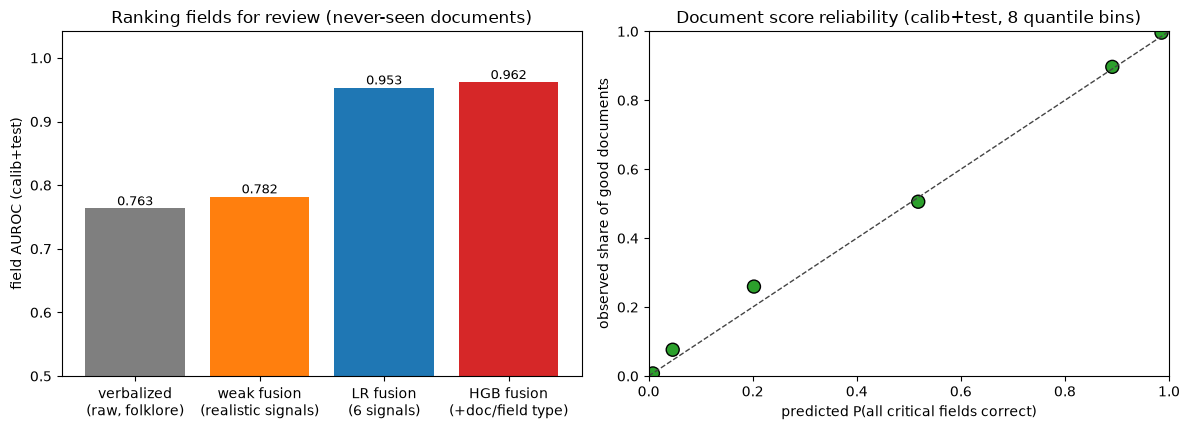

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
PAL3 = {"raw": "#7f7f7f", "lr": "#1f77b4", "hgb": "#d62728", "diag": "#444444", "doc": "#2ca02c"}
ax = axes[0]
names, vals, cols = ["verbalized\n(raw, folklore)", "weak fusion\n(realistic signals)", "LR fusion\n(6 signals)", "HGB fusion\n(+doc/field type)"], [_auc_v, _auc_w, _auc_lr, _auc_h], [PAL3["raw"], "#ff7f0e", PAL3["lr"], PAL3["hgb"]]
ax.bar(names, vals, color=cols)
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylim(0.5, max(vals) + 0.08); ax.set_ylabel("field AUROC (calib+test)"); ax.set_title("Ranking fields for review (never-seen documents)")
ax = axes[1]
_m, _y = DA_mu[_ev], DA_y_ok[_ev]
_edges = np.quantile(_m, np.linspace(0, 1, 9)); _edges[0] -= 1e-9; _edges[-1] += 1e-9
_bx, _by, _bn = [], [], []
for lo, hi in zip(_edges[:-1], _edges[1:]):
    sel = (_m > lo) & (_m <= hi)
    _bx.append(_m[sel].mean()); _by.append(_y[sel].mean()); _bn.append(sel.sum())
ax.plot([0, 1], [0, 1], "--", color=PAL3["diag"], lw=1)
ax.scatter(_bx, _by, s=np.array(_bn) / 3, color=PAL3["doc"], edgecolor="k")
ax.set_xlabel("predicted P(all critical fields correct)"); ax.set_ylabel("observed share of good documents")
ax.set_title("Document score reliability (calib+test, 8 quantile bins)"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


**CONTRACT: shared objects available to every later section** (defined above; do not redefine or shadow them).

- From Notebook 2: `DOCS`, `FIELDS`, `SPLITS`, `CLASSIFIER`, `USAGE_LEDGER`, `LLM_STATS`, and helpers `check`, `wilson_ci`, `fmt_ci`, `design_effect`, `cluster_bootstrap_ci`, `llm_cost_usd`, `ledger_cost_usd`, `score_field`.
- Constants: `SEED3`, `DOC_TYPES`, `CRITICAL_FIELDS`, `MONEY_FIELDS`, `PAL3` (palette; sections may add keys under their own prefix).
- Document arrays (length `N_DOC`, index = position in `DOCS`): `DOC_SPLIT`, `DOC_TYPE_ARR`, `DOC_TYPE_IDX`, `DOC_IS_SHIFT`, `DA_y_ok` (all critical fields correct), `DA_n_crit`, `DA_has_money`, `DA_L` (bounded amount-weighted loss, `nan` for KYC), `DA_mu` (predicted P(y_ok=1)), `DA_risk` (predicted E[L_doc], low = trusted), and the pessimistic-score twins `DA_mu_weak`, `DA_risk_weak`.
- Field arrays (length `len(FIELDS)`): `FA_doc` (document index), `FA_correct`, `FA_crit`, `FA_verb` (raw verbalized confidence), `FA_p_hgb`, `FA_p_lr`, `FA_p_weak` (train-fitted fusion scores: optimistic learned / low-capacity / pessimistic weak-signal), `FA_p_hgb_oof` (cross-fitted, train docs only), `X_field`, `FIELD_IDX_BY_DOC`. Each `FIELDS` row also carries `p_hgb`, `p_lr`, `p_weak`.
- Models: `FUSION_HGB`, `FUSION_LR`, `FUSION_WEAK`, `DOC_MODEL_Y`, `DOC_MODEL_L`, `DOC_MODEL_Y_WEAK`, `DOC_MODEL_L_WEAK` (all fit on `train` documents only).
- Helpers: `resplit(seed)` returns `(cal_doc_idx, test_doc_idx)`, a 50/50 document-level split of the calib+test pool stratified by document type; `add_one_threshold(scores, errors, alpha)` is the P3 section 4 rule on a higher-is-more-trusted score.


## 3. Why the folklore / add-one rule breaks on OUR documents (P3 section 4, reproduced *qualitatively* on the Notebook-2 data)

**What Gurram's paper says** (re-read from `idpfin-q7`, verbatim). The add-one rule:

> "The add-one rule picks the smallest threshold $\tau$ whose smoothed empirical selective risk on calibration is $\le \alpha$:"
> $$\tau = \min \left\{ t : \frac{1 + \#\{i: c_i \ge t, \text{err}_i\}}{1 + \#\{i: c_i \ge t\}} \le \alpha \right\}, \quad \tau = \infty \text{ (review everything) if none qualifies.}$$ (idpfin-q7)

and the three diagnosed failure modes (Table 3 of the paper, "each pinned by a counterfactual", idpfin-q7):

1. **Document clustering.** "At the add-one threshold the estimated design effect is 2.15 (CORD), 1.84 (FUNSD), 2.04 (XFUND-de) -- up to 2.45 at other thresholds -- so the effective calibration sample is roughly half its nominal size." (idpfin-q7)
2. **Score-refit leakage.** "Fitting a high-capacity score and its threshold on the same calibration fields transfers the score's optimism into the threshold. [...] A 5-parameter logistic fusion barely overfits (risk 0.105)..." (idpfin-q7)
3. **Tie-mass pathology.** "A threshold accepts a tie mass whole or not at all: the smallest reachable candidate accepted $n=245$ fields at empirical risk $0.114 > \alpha$, so no certificate existed at any confidence level." (idpfin-q7)

And the repair for tiers 1-2, the fit/val protocol: "Fit the score model and every data-dependent transform [...] on the fit half only; compute the add-one threshold and all Mondrian bin edges on the untouched val half; never touch test. This restores score-threshold independence -- it does not restore exchangeability, so document clustering remains and tiers 1-2 stay marginal, on-average guarantees." (idpfin-q7)

**What we do here.** Apply the add-one rule (`add_one_threshold`, from the prelude) to the Notebook-2 pipeline at $\alpha = 0.10$ with the
**optimistic** score (`FA_p_hgb`) and the **pessimistic** score (`FA_p_weak`), on **fields** (all fields of the calibration documents), and see
which of the three failure modes are visible on *our* synthetic data. Rules of engagement: paper numbers appear only in the quotes above;
every number printed below is ours; where an effect is *not* visible we say so, and no threshold below was adjusted after looking at results.
The folklore rule of Notebook 2 (verbalized confidence $\ge 0.9$ and no rule failure) is a fixed, un-calibrated cousin of this rule and is
compared in section 4.

**Vocabulary.** The add-one rule is a **tier-1 expectation** procedure (Table 4 of the paper: "tiers 1-2 control expected selective risk; only tiers 3-4 certify", idpfin-q8). Nothing in this section is a certificate.


### 3a. Failure mode 1 -- document clustering: 40 (and 200) document-level resplits versus a field-level-split control

Protocol (each split): take `resplit(seed)` (a 50/50 **document** split of the calib+test pool, stratified by document type); calibrate the add-one threshold on **all fields of the
calibration documents**; evaluate on **all fields of the test documents**. Reported per score: mean coverage (fraction of test fields accepted), mean achieved
selective risk (error rate among accepted test fields), the fraction of splits whose risk exceeds $\alpha$ ("violation"), and the count of zero-coverage splits.

**Control.** The same pool of fields split at random **by field** (stratified by document type too, so only the *clustering* differs), seeds paired with the document splits.
If document clustering matters, the document splits should be more variable than the field control at the same mean; and the **design effect**
(Kish; Notebook 2's `design_effect`) on the pool and on the accepted set says how much smaller the effective sample is than the nominal one:
$\text{deff} = 1 + (\bar n - 1)\rho$, $n_{\text{eff}} = n / \text{deff}$.

**Zero-coverage convention (disclosed).** When the rule returns $\tau=\infty$ (nothing accepted) the split's risk is set to **0**, so the plain mean risk is a *zero-filled mean*.
The paper's Table 4 does the same and says so: "0.020 is the zero-filled mean -- conditional on certifying anything, achieved risk is 0.038. Report both." (idpfin-q8).
We therefore also print the mean risk **conditional on non-zero coverage**. (The exact phrase "zero-coverage splits contribute risk 0" is not in the traces; the footnote above is the closest wording.)


In [4]:
# ---- Part A shared helpers (all A_-prefixed) --------------------------------------------------------------------------
A_ALPHA = 0.10
A_ERR = (1 - FA_correct).astype(float)                       # 1 = the field is wrong
A_POOL_FIELDS = np.where(np.isin(DOC_SPLIT, ["calib", "test"])[FA_doc])[0]   # every field of every calib+test document
A_FTYPE = DOC_TYPE_IDX[FA_doc]
A_SCORES = {"opt": FA_p_hgb, "weak": FA_p_weak}
A_LABEL = {"opt": "optimistic (learned HGB fusion)", "weak": "pessimistic (weak-signal LR)"}
A_WEAK_COLS = [0, 4, 5, 6, 7, 8, 9]                          # same columns as the prelude's weak-signal score
PAL3.update({"a_opt": "#d62728", "a_weak": "#ff7f0e", "a_doc": "#1f77b4", "a_field": "#7f7f7f", "a_ok": "#2ca02c", "a_bad": "#9467bd", "a_folk": "#8c564b"})


def A_cp_upper(k, n, conf=0.95):
    """One-sided Clopper-Pearson upper bound for a proportion k/n."""
    return 1.0 if k >= n else float(stats.beta.ppf(conf, k + 1, n - k))


def A_cp_lower(k, n, conf=0.95):
    return 0.0 if k <= 0 else float(stats.beta.ppf(1 - conf, k, n - k + 1))


def A_deff(doc_ids, err):
    """Vectorised one-way-ANOVA (Kish) design effect, identical formula to Notebook 2's design_effect; returns (deff, icc, avg_cluster_size)."""
    _u, _inv = np.unique(doc_ids, return_inverse=True)
    _ns = np.bincount(_inv).astype(float)
    _means = np.bincount(_inv, weights=err) / _ns
    _n, _k = _ns.sum(), len(_ns)
    if _k < 2 or _n <= _k:
        return 1.0, 0.0, _n / max(_k, 1)
    _gm = err.sum() / _n
    _n0 = (_n - (_ns ** 2).sum() / _n) / (_k - 1)
    _msb = (_ns * (_means - _gm) ** 2).sum() / (_k - 1)
    _msw = ((err - _means[_inv]) ** 2).sum() / (_n - _k)
    _den = _msb + (_n0 - 1) * _msw
    _icc = max(0.0, (_msb - _msw) / _den) if _den > 0 else 0.0
    return max(1.0, 1 + (_n / _k - 1) * _icc), _icc, _n / _k


def A_pipe(header, rows):
    """Print a Markdown pipe table."""
    print("| " + " | ".join(header) + " |")
    print("| " + " | ".join(["---"] * len(header)) + " |")
    for _r in rows:
        print("| " + " | ".join(str(_x) for _x in _r) + " |")


def A_doc_split_fields(seed):
    _c, _t = resplit(seed)
    return np.where(np.isin(FA_doc, _c))[0], np.where(np.isin(FA_doc, _t))[0]


def A_field_split_fields(seed):
    """Control: random 50/50 split of the SAME pool of fields, stratified by document type, ignoring which document a field belongs to."""
    _rng = np.random.default_rng([SEED3, 777, int(seed)])
    _ic, _it = [], []
    for _j in range(4):
        _ids = A_POOL_FIELDS[A_FTYPE[A_POOL_FIELDS] == _j].copy()
        _rng.shuffle(_ids)
        _h = int(round(len(_ids) * 0.5))
        _ic += list(_ids[:_h]); _it += list(_ids[_h:])
    return np.array(sorted(_ic)), np.array(sorted(_it))


def A_addone_eval(score_cal, ic, score_test, it, alpha=A_ALPHA):
    """Add-one threshold on calibration fields ic (scores score_cal), evaluated on test fields it (scores score_test)."""
    _tau = add_one_threshold(score_cal, A_ERR[ic], alpha)
    _acc = score_test >= _tau
    _na = int(_acc.sum())
    _ac = score_cal >= _tau
    return dict(tau=_tau, n_acc=_na, cov=_na / len(it), risk=float(A_ERR[it][_acc].mean()) if _na else 0.0, zero=(_na == 0),
                cal_risk=float(A_ERR[ic][_ac].mean()) if _ac.any() else 0.0, cal_cov=float(_ac.mean()),
                acc_idx=it[_acc])


def A_arr(rows, key):
    return np.array([_r[key] for _r in rows], dtype=float)


A_N_LONG, A_N_SHORT = 200, 40
A_res3a = {}
_t0 = time.time()
for _k, _sc in A_SCORES.items():
    for _mode, _fn in (("doc", A_doc_split_fields), ("field", A_field_split_fields)):
        _rows = []
        for _seed in range(A_N_LONG):
            _ic, _it = _fn(_seed)
            _r = A_addone_eval(_sc[_ic], _ic, _sc[_it], _it)
            # z-statistic: (test risk - calib risk) on the accepted sets, scaled by the plain binomial standard error
            _at = _r["acc_idx"]
            _ac = _ic[_sc[_ic] >= _r["tau"]]
            if len(_ac) and len(_at):
                _p = (A_ERR[_ac].sum() + A_ERR[_at].sum()) / (len(_ac) + len(_at))
                _r["z"] = (A_ERR[_at].mean() - A_ERR[_ac].mean()) / np.sqrt(_p * (1 - _p) * (1 / len(_ac) + 1 / len(_at)))
            else:
                _r["z"] = np.nan
            if _mode == "doc":
                _r["deff_pool"], _r["icc_pool"], _r["nbar_pool"] = A_deff(FA_doc[_it], A_ERR[_it])
                _r["deff_acc"], _r["icc_acc"], _r["nbar_acc"] = A_deff(FA_doc[_at], A_ERR[_at]) if len(_at) > 1 else (1.0, 0.0, 1.0)
            _rows.append(_r)
        A_res3a[(_k, _mode)] = _rows
print(f"add-one runs: 2 scores x 2 split types x {A_N_LONG} splits in {time.time() - _t0:.1f}s\n")


def A_summ(rows, n):
    _r = rows[:n]
    _risk, _cov, _zero = A_arr(_r, "risk"), A_arr(_r, "cov"), A_arr(_r, "zero").astype(bool)
    _nz = ~_zero
    return dict(n=n, cov=_cov.mean(), cov_sd=_cov.std(ddof=1), risk=_risk.mean(), risk_sd=_risk.std(ddof=1),
                risk_nz=_risk[_nz].mean() if _nz.any() else float("nan"), viol=float((_risk > A_ALPHA).mean()), nviol=int((_risk > A_ALPHA).sum()),
                zero=int(_zero.sum()))


A_tab3a = {(k, m, n): A_summ(A_res3a[(k, m)], n) for k in A_SCORES for m in ("doc", "field") for n in (A_N_SHORT, A_N_LONG)}
_rows = []
for _k in A_SCORES:
    for _m in ("doc", "field"):
        for _n in (A_N_SHORT, A_N_LONG):
            _s = A_tab3a[(_k, _m, _n)]
            _rows.append([A_LABEL[_k].split(" (")[0], "by DOCUMENT" if _m == "doc" else "by field (control)", _n, f"{_s['cov']:.3f}", f"{_s['risk']:.4f}", f"{_s['risk_sd']:.4f}",
                          f"{_s['risk_nz']:.4f}", f"{_s['viol']:.3f} ({_s['nviol']}/{_n})", _s["zero"]])
print("Add-one rule at alpha=0.10, calibrate on calib fields, evaluate on test fields (zero-filled mean risk, and mean risk conditional on non-zero coverage):")
A_pipe(["score", "split", "#splits", "mean coverage", "mean risk (zero-filled)", "sd of risk", "mean risk given coverage>0", "violation frac (risk>alpha)", "zero-coverage splits"], _rows)

# ---- design effects and the Kish relation ---------------------------------------------------------------------------------
print("\nDesign effects across the first 40 document splits (Kish: deff = 1 + (nbar-1)*icc, n_eff = n/deff):")
_rows, A_deff3a = [], {}
for _k in A_SCORES:
    _r = A_res3a[(_k, "doc")][:A_N_SHORT]
    _dp, _da = A_arr(_r, "deff_pool"), A_arr(_r, "deff_acc")
    A_deff3a[_k] = dict(deff_pool=_dp.mean(), deff_acc=_da.mean(), icc_acc=A_arr(_r, "icc_acc").mean(), nbar_acc=A_arr(_r, "nbar_acc").mean(),
                        n_pool=np.mean([len(_x["acc_idx"]) / max(_x["cov"], 1e-9) for _x in _r]), n_acc=A_arr(_r, "n_acc").mean())
    _d = A_deff3a[_k]
    _rows.append([A_LABEL[_k].split(" (")[0], f"{_d['deff_pool']:.2f}", f"{_d['n_pool']:.0f} -> {_d['n_pool'] / _d['deff_pool']:.0f}", f"{_d['deff_acc']:.2f}", f"{_d['icc_acc']:.3f}",
                  f"{_d['nbar_acc']:.2f}", f"{1 + (_d['nbar_acc'] - 1) * _d['icc_acc']:.2f}", f"{_d['n_acc']:.0f} -> {_d['n_acc'] / _d['deff_acc']:.0f}"])
A_pipe(["score", "deff, pool of test fields", "n -> n_eff (pool)", "deff, accepted set", "icc (accepted)", "mean accepted fields per accepted doc", "1+(nbar-1)*icc", "n -> n_eff (accepted)"], _rows)

# does clustering show up in split-to-split variability?  z = (test risk - calib risk) / plain binomial SE:  sd(z) ~ 1 under field-iid, ~ sqrt(deff) under clustering
print("\nSplit-to-split variability of the calib-vs-test risk gap (z, 200 splits; ~1.0 if fields were exchangeable, inflated by clustering; Kish ceiling sqrt(deff_accepted) shown):")
_rows = []
A_z3a = {}
for _k in A_SCORES:
    _zd, _zf = A_arr(A_res3a[(_k, "doc")], "z"), A_arr(A_res3a[(_k, "field")], "z")
    _zd, _zf = _zd[~np.isnan(_zd)], _zf[~np.isnan(_zf)]
    A_z3a[_k] = (_zd.std(ddof=1), _zf.std(ddof=1))
    _rd, _rf = A_arr(A_res3a[(_k, "doc")], "risk"), A_arr(A_res3a[(_k, "field")], "risk")
    _rows.append([A_LABEL[_k].split(" (")[0], f"{_zd.std(ddof=1):.2f}", f"{_zf.std(ddof=1):.2f}", f"{_zd.std(ddof=1) / _zf.std(ddof=1):.2f}", f"{np.sqrt(A_deff3a[_k]['deff_acc']):.2f}",
                  f"{_rd.std(ddof=1):.4f} vs {_rf.std(ddof=1):.4f}"])
A_pipe(["score", "sd(z) by document", "sd(z) by field (control)", "ratio", "Kish ceiling sqrt(deff_acc)", "sd of risk: document vs field"], _rows)

# ---- naive binomial CI versus document-cluster bootstrap CI on the accepted set -------------------------------------------
def A_cluster_boot_ci(idx, B=400, seed=0):
    _u, _inv = np.unique(FA_doc[idx], return_inverse=True)
    _n = np.bincount(_inv).astype(float)
    _e = np.bincount(_inv, weights=A_ERR[idx])
    _rng = np.random.default_rng([SEED3, 31337, seed])
    _cnt = _rng.multinomial(len(_u), np.full(len(_u), 1 / len(_u)), size=B).astype(float)
    _rk = (_cnt @ _e) / (_cnt @ _n)
    return float(np.quantile(_rk, 0.025)), float(np.quantile(_rk, 0.975))


print("\nNaive Wilson 95% CI (treats fields as independent) vs document-cluster bootstrap 95% CI for the ACCEPTED-set risk, mean over the first 20 splits:")
_rows, A_ci3a = [], {}
for _k in A_SCORES:
    _wr = []
    for _s in range(20):
        _a = A_res3a[(_k, "doc")][_s]["acc_idx"]
        _w = wilson_ci(int(A_ERR[_a].sum()), len(_a)); _b = A_cluster_boot_ci(_a, seed=_s)
        _wr.append(((_b[1] - _b[0]) / (_w[1] - _w[0]), _w[1] - _w[0], _b[1] - _b[0]))
    _wr = np.array(_wr)
    A_ci3a[_k] = _wr.mean(axis=0)
    _rows.append([A_LABEL[_k].split(" (")[0], f"{_wr[:, 1].mean():.4f}", f"{_wr[:, 2].mean():.4f}", f"{_wr[:, 0].mean():.2f}", f"{np.sqrt(A_deff3a[_k]['deff_acc']):.2f}"])
A_pipe(["score", "Wilson width (naive)", "cluster-bootstrap width", "width ratio", "sqrt(deff_accepted)"], _rows)

# ---- cross-check of the vectorised design effect against Notebook 2's design_effect -----------------------------------------
_a0 = A_res3a[("opt", "doc")][0]["acc_idx"]
_recs = [{"doc_id": FIELDS[_i]["doc_id"], "error": int(A_ERR[_i])} for _i in _a0]
_de_nb2, _icc_nb2 = design_effect(_recs)
_de_mine, _icc_mine, _ = A_deff(FA_doc[_a0], A_ERR[_a0])

# ---- self-checks ----------------------------------------------------------------------------------------------------------
print()
for _k in A_SCORES:
    _s = A_tab3a[(_k, "doc", A_N_LONG)]
    check(f"S3.1[{_k}] add-one on fields, document resplits: mean risk within 0.01 (=10% of alpha) of alpha=0.10",
          abs(_s["risk"] - A_ALPHA) <= 0.01, f"mean risk {_s['risk']:.4f}, coverage {_s['cov']:.3f}, {A_N_LONG} splits")
    _s = A_tab3a[(_k, "field", A_N_LONG)]
    check(f"S3.2[{_k}] the field-level-split control also lands within 0.01 of alpha (so the rule is fine ON AVERAGE either way)",
          abs(_s["risk"] - A_ALPHA) <= 0.01, f"mean risk {_s['risk']:.4f}")
    _nv, _n = A_tab3a[(_k, "doc", A_N_LONG)]["nviol"], A_N_LONG
    check(f"S3.3[{_k}] an expectation guarantee is NOT a per-batch guarantee: one-sided 95% Clopper-Pearson LOWER bound on the violation fraction > 0.25",
          A_cp_lower(_nv, _n) > 0.25, f"violation {_nv}/{_n} = {_nv / _n:.3f}, CP lower {A_cp_lower(_nv, _n):.3f} (resplits share one pool, so the bound is optimistic)")
    _d = A_deff3a[_k]
    check(f"S3.4[{_k}] errors are materially clustered by document: mean deff > 1.1 on the pool AND on the accepted set (40 splits)",
          _d["deff_pool"] > 1.1 and _d["deff_acc"] > 1.1, f"deff pool {_d['deff_pool']:.2f}, accepted {_d['deff_acc']:.2f}")
    check(f"S3.5[{_k}] a naive binomial (Wilson) CI on the accepted set is too narrow: cluster-bootstrap CI is wider",
          A_ci3a[_k][0] > 1.0, f"width ratio {A_ci3a[_k][0]:.2f} (Kish sqrt(deff) = {np.sqrt(A_deff3a[_k]['deff_acc']):.2f})")
for _k in A_SCORES:
    check(f"S3.5b[{_k}] Kish relation for intervals: cluster-bootstrap / Wilson width ratio is within 15% of sqrt(deff_accepted)",
          abs(A_ci3a[_k][0] / np.sqrt(A_deff3a[_k]["deff_acc"]) - 1) <= 0.15, f"ratio {A_ci3a[_k][0]:.2f} vs sqrt(deff) {np.sqrt(A_deff3a[_k]['deff_acc']):.2f}")
check("S3.6 the vectorised A_deff equals Notebook 2's design_effect on a real accepted set", abs(_de_nb2 - _de_mine) < 1e-9 and abs(_icc_nb2 - _icc_mine) < 1e-9,
      f"deff {_de_mine:.4f} vs {_de_nb2:.4f}, icc {_icc_mine:.4f} vs {_icc_nb2:.4f}")
check("S3.7 Kish identity deff = 1 + (nbar-1)*icc holds for the accepted-set estimates (optimistic score, split 0)",
      abs(_de_mine - (1 + (A_res3a[('opt', 'doc')][0]['nbar_acc'] - 1) * A_res3a[('opt', 'doc')][0]['icc_acc'])) < 1e-9)


add-one runs: 2 scores x 2 split types x 200 splits in 5.6s

Add-one rule at alpha=0.10, calibrate on calib fields, evaluate on test fields (zero-filled mean risk, and mean risk conditional on non-zero coverage):
| score | split | #splits | mean coverage | mean risk (zero-filled) | sd of risk | mean risk given coverage>0 | violation frac (risk>alpha) | zero-coverage splits |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| optimistic | by DOCUMENT | 40 | 0.740 | 0.1004 | 0.0049 | 0.1004 | 0.500 (20/40) | 0 |
| optimistic | by DOCUMENT | 200 | 0.740 | 0.1002 | 0.0059 | 0.1002 | 0.500 (100/200) | 0 |
| optimistic | by field (control) | 40 | 0.740 | 0.1006 | 0.0047 | 0.1006 | 0.475 (19/40) | 0 |
| optimistic | by field (control) | 200 | 0.740 | 0.0999 | 0.0053 | 0.0999 | 0.515 (103/200) | 0 |
| pessimistic | by DOCUMENT | 40 | 0.197 | 0.0990 | 0.0098 | 0.0990 | 0.550 (22/40) | 0 |
| pessimistic | by DOCUMENT | 200 | 0.197 | 0.0994 | 0.0108 | 0.0994 | 0.555 (111/200) | 0 |
| pessi

| score | Wilson width (naive) | cluster-bootstrap width | width ratio | sqrt(deff_accepted) |
| --- | --- | --- | --- | --- |
| optimistic | 0.0149 | 0.0182 | 1.22 | 1.28 |
| pessimistic | 0.0295 | 0.0315 | 1.07 | 1.09 |

[PASS] S3.1[opt] add-one on fields, document resplits: mean risk within 0.01 (=10% of alpha) of alpha=0.10 -- mean risk 0.1002, coverage 0.740, 200 splits
[PASS] S3.2[opt] the field-level-split control also lands within 0.01 of alpha (so the rule is fine ON AVERAGE either way) -- mean risk 0.0999
[PASS] S3.3[opt] an expectation guarantee is NOT a per-batch guarantee: one-sided 95% Clopper-Pearson LOWER bound on the violation fraction > 0.25 -- violation 100/200 = 0.500, CP lower 0.440 (resplits share one pool, so the bound is optimistic)
[PASS] S3.4[opt] errors are materially clustered by document: mean deff > 1.1 on the pool AND on the accepted set (40 splits) -- deff pool 2.80, accepted 1.63
[PASS] S3.5[opt] a naive binomial (Wilson) CI on the accepted set is too n

np.True_

**How to read this chart.** Top row, one panel per score: the histogram of the **realized selective risk** of the add-one rule across the 200 splits, for document-level resplits (blue) and for the
field-level control (grey), with the target $\alpha = 0.10$ as a vertical line. Look at *where the mass sits relative to the line*: both distributions are centred on $\alpha$ (the rule is right **on average**) but
roughly half of the individual batches land to the right of it, which is exactly what "tiers 1-2 are expectation guarantees" means for the review queue: a single batch that "was calibrated to 10%" is a coin flip on whether
it is above or below 10%. Any *extra width* of the blue histogram over the grey one is the effect of document clustering; compare it with the printed $z$ ratio, not by eye. Bottom-left: the design effect of the **pool** of test fields (all fields, including
non-critical ones) and of each **accepted set**, i.e. how many times smaller the effective sample is than the nominal one. Bottom-right: the mean split-to-split spread of the calib-vs-test risk gap ($z$, 1.0 for exchangeable fields) for documents versus the field control, next to the Kish ceiling
$\sqrt{\text{deff}}$. Honest reading of *our* data: the design effects are clearly above 1 (fields of one document fail together) and the naive Wilson interval on the accepted set is too narrow by about the Kish factor $\sqrt{\text{deff}}$ (printed), but the extra batch-to-batch variability of the realized risk is **modest**, below the Kish ceiling, because the
splits are stratified by document type and draw from one finite pool; the paper's "grouped variant overshoots at 78% of splits" is **not** something these data show, and we do not claim it.


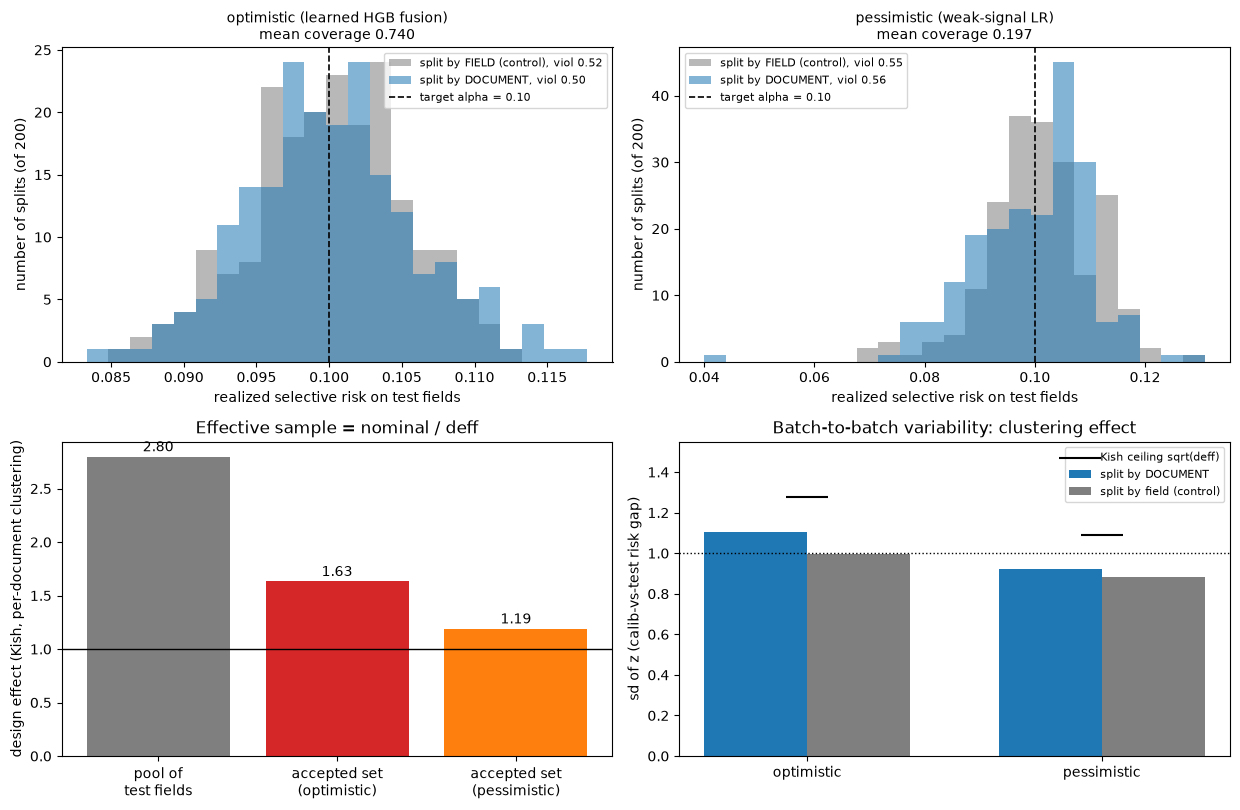

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2))
for _i, _k in enumerate(["opt", "weak"]):
    _ax = axes[0, _i]
    _rd, _rf = A_arr(A_res3a[(_k, "doc")], "risk"), A_arr(A_res3a[(_k, "field")], "risk")
    _bins = np.linspace(min(_rd.min(), _rf.min()) - 1e-3, max(_rd.max(), _rf.max()) + 1e-3, 24)
    _ax.hist(_rf, bins=_bins, color=PAL3["a_field"], alpha=0.55, label=f"split by FIELD (control), viol {(_rf > A_ALPHA).mean():.2f}")
    _ax.hist(_rd, bins=_bins, color=PAL3["a_doc"], alpha=0.55, label=f"split by DOCUMENT, viol {(_rd > A_ALPHA).mean():.2f}")
    _ax.axvline(A_ALPHA, color="k", ls="--", lw=1.2, label="target alpha = 0.10")
    _ax.set_title(f"{A_LABEL[_k]}\nmean coverage {A_tab3a[(_k, 'doc', A_N_LONG)]['cov']:.3f}", fontsize=10)
    _ax.set_xlabel("realized selective risk on test fields"); _ax.set_ylabel("number of splits (of 200)"); _ax.legend(fontsize=8)
_ax = axes[1, 0]
_labels = ["pool of\ntest fields", "accepted set\n(optimistic)", "accepted set\n(pessimistic)"]
_vals = [A_deff3a["opt"]["deff_pool"], A_deff3a["opt"]["deff_acc"], A_deff3a["weak"]["deff_acc"]]
_ax.bar(_labels, _vals, color=[PAL3["a_field"], PAL3["a_opt"], PAL3["a_weak"]])
_ax.axhline(1.0, color="k", lw=1)
for _j, _v in enumerate(_vals):
    _ax.text(_j, _v + 0.05, f"{_v:.2f}", ha="center")
_ax.set_ylabel("design effect (Kish, per-document clustering)"); _ax.set_title("Effective sample = nominal / deff")
_ax = axes[1, 1]
_x = np.arange(2); _w = 0.35
_ax.bar(_x - _w / 2, [A_z3a["opt"][0], A_z3a["weak"][0]], _w, color=PAL3["a_doc"], label="split by DOCUMENT")
_ax.bar(_x + _w / 2, [A_z3a["opt"][1], A_z3a["weak"][1]], _w, color=PAL3["a_field"], label="split by field (control)")
_ax.scatter(_x, [np.sqrt(A_deff3a["opt"]["deff_acc"]), np.sqrt(A_deff3a["weak"]["deff_acc"])], marker="_", s=900, color="k", zorder=5, label="Kish ceiling sqrt(deff)")
_ax.axhline(1.0, color="k", ls=":", lw=1)
_ax.set_xticks(_x); _ax.set_xticklabels(["optimistic", "pessimistic"]); _ax.set_ylabel("sd of z (calib-vs-test risk gap)")
_ax.set_ylim(0, 1.55); _ax.set_title("Batch-to-batch variability: clustering effect"); _ax.legend(fontsize=8, loc="upper right", ncol=1)
plt.tight_layout(); plt.show()


### 3b. Failure mode 2 -- score-refit leakage on real data (and the fit/val repair)

Same 40 document splits. The **same** learned score family (the prelude's depth-3 HGB fusion, same hyper-parameters) is used three ways and thresholded with the add-one rule at $\alpha = 0.10$; all are evaluated on the test documents' fields:

| protocol | where the score is fit | where the threshold is set |
| --- | --- | --- |
| **train-fit / calib-threshold** (the prelude's protocol) | `train` documents only | all fields of the calibration documents |
| **same-half** (the failure mode) | the calibration documents' fields *themselves* | the same fields (in-sample scores) |
| **fit/val** (P3 section 5.1 variant) | a random half of the calibration *documents* (stratified by type) | the *other* half of the calibration documents |

Contrast: a **low-capacity** logistic fusion on the six raw signals, refit same-half (the paper: "a 5-parameter logistic fusion barely overfits", idpfin-q7), and the **pessimistic** weak-signal logistic score, train-fit versus same-half. Paired paired-difference tests are one-sided
(same-half risk exceeds train-fit risk). The resplits share one pool, so the violation-fraction bounds are optimistic; tolerances are stated in each check. Same-half refitting is *not* something the prelude does: it is the counterfactual.


In [6]:
def A_hgb():
    """Same configuration as the prelude's HGB fusion (re-stated here so that later parts cannot shadow it)."""
    return HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.08, min_samples_leaf=40, l2_regularization=1.0, random_state=SEED3)


def A_lr():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1.0))


A_PROTO = ["train_fit", "same_half", "fit_val", "lr_same_half", "weak_train_fit", "weak_same_half"]
A_res3b = {p: [] for p in A_PROTO}
_t0 = time.time()
for _seed in range(A_N_SHORT):
    _ic, _it = A_doc_split_fields(_seed)
    _cal_docs = np.unique(FA_doc[_ic])
    A_res3b["train_fit"].append(A_addone_eval(FA_p_hgb[_ic], _ic, FA_p_hgb[_it], _it))
    _m = A_hgb().fit(X_field[_ic], FA_correct[_ic])                                   # same-half: fit on the calibration fields themselves
    A_res3b["same_half"].append(A_addone_eval(_m.predict_proba(X_field[_ic])[:, 1], _ic, _m.predict_proba(X_field[_it])[:, 1], _it))
    _rng = np.random.default_rng([SEED3, 555, _seed])                                  # fit/val: split the calibration DOCUMENTS
    _fit_docs = []
    for _j in range(4):
        _ids = _cal_docs[DOC_TYPE_IDX[_cal_docs] == _j].copy(); _rng.shuffle(_ids); _fit_docs += list(_ids[:len(_ids) // 2])
    _fm = np.isin(FA_doc[_ic], _fit_docs)
    _i_fit, _i_val = _ic[_fm], _ic[~_fm]
    _m2 = A_hgb().fit(X_field[_i_fit], FA_correct[_i_fit])
    A_res3b["fit_val"].append(A_addone_eval(_m2.predict_proba(X_field[_i_val])[:, 1], _i_val, _m2.predict_proba(X_field[_it])[:, 1], _it))
    _l = A_lr().fit(X_field[_ic][:, :6], FA_correct[_ic])
    A_res3b["lr_same_half"].append(A_addone_eval(_l.predict_proba(X_field[_ic][:, :6])[:, 1], _ic, _l.predict_proba(X_field[_it][:, :6])[:, 1], _it))
    A_res3b["weak_train_fit"].append(A_addone_eval(FA_p_weak[_ic], _ic, FA_p_weak[_it], _it))
    _w = A_lr().fit(X_field[_ic][:, A_WEAK_COLS], FA_correct[_ic])
    A_res3b["weak_same_half"].append(A_addone_eval(_w.predict_proba(X_field[_ic][:, A_WEAK_COLS])[:, 1], _ic, _w.predict_proba(X_field[_it][:, A_WEAK_COLS])[:, 1], _it))
print(f"leakage protocols: {A_N_SHORT} splits x 6 fits in {time.time() - _t0:.1f}s\n")

A_desc3b = {"train_fit": "HGB fusion, fit on train docs, threshold on calib fields", "same_half": "HGB fusion refit on the calib fields, threshold on the same fields (LEAKAGE)",
            "fit_val": "HGB fusion fit on half the calib docs, threshold on the other half", "lr_same_half": "6-signal logistic fusion, same-half",
            "weak_train_fit": "weak-signal LR fit on train docs, threshold on calib", "weak_same_half": "weak-signal LR refit same-half"}
_rows, A_tab3b = [], {}
for _p in A_PROTO:
    _s = A_summ(A_res3b[_p], A_N_SHORT)
    _s["cal_risk"] = A_arr(A_res3b[_p], "cal_risk").mean(); _s["cal_cov"] = A_arr(A_res3b[_p], "cal_cov").mean()
    A_tab3b[_p] = _s
    _rows.append([_p, A_desc3b[_p], f"{_s['cal_cov']:.3f} / {_s['cal_risk']:.4f}", f"{_s['cov']:.3f}", f"{_s['risk']:.4f}", f"{_s['viol']:.3f} ({_s['nviol']}/{A_N_SHORT})", _s["zero"]])
print("Add-one at alpha=0.10 under different score-fitting protocols (40 document splits; 'in-sample' = coverage / risk on the calibration fields at the chosen threshold):")
A_pipe(["protocol", "what it is", "in-sample cov / risk", "test coverage", "test risk", "violation frac", "zero-cov splits"], _rows)

_d_same = A_arr(A_res3b["same_half"], "risk") - A_arr(A_res3b["train_fit"], "risk")
_tt = stats.ttest_1samp(_d_same, 0.0, alternative="greater")
_d_lr = A_arr(A_res3b["lr_same_half"], "risk") - A_arr(A_res3b["train_fit"], "risk")
print(f"\npaired same-half minus train-fit test risk: mean {_d_same.mean():+.4f}, one-sided paired t p = {_tt.pvalue:.2e}; positive in {(_d_same > 0).sum()}/{A_N_SHORT} splits")
print(f"paired 6-signal-LR same-half minus train-fit test risk: mean {_d_lr.mean():+.4f} (a 6-parameter fusion has almost nothing to overfit)")
print(f"coverage change of fit/val vs train-fit: {A_tab3b['fit_val']['cov'] - A_tab3b['train_fit']['cov']:+.3f} (fit/val spends half of the calibration documents on the score fit)")

print()
_TOL = 1.05 * A_ALPHA
check("S3.8 same-half refit is visibly worse than train-fit: paired one-sided t-test p < 0.01", _tt.pvalue < 0.01, f"mean gap {_d_same.mean():+.4f}, p={_tt.pvalue:.1e}")
check("S3.9 same-half overshoots alpha materially: mean test risk > 1.05*alpha (=0.105, a 5% relative tolerance fixed in advance)", A_tab3b["same_half"]["risk"] > _TOL, f"mean risk {A_tab3b['same_half']['risk']:.4f}")
_nv = A_tab3b["same_half"]["nviol"]
check("S3.10 same-half violates in a clear majority of splits: one-sided 95% CP lower bound on the violation fraction > 0.5 (the boundary-rider rate)",
      A_cp_lower(_nv, A_N_SHORT) > 0.5, f"{_nv}/{A_N_SHORT} splits violate, CP lower {A_cp_lower(_nv, A_N_SHORT):.3f}")
check("S3.11 the train-fit / calib-threshold protocol holds on average: mean test risk <= 1.05*alpha", A_tab3b["train_fit"]["risk"] <= _TOL, f"mean risk {A_tab3b['train_fit']['risk']:.4f}")
check("S3.12 the fit/val protocol holds on average: mean test risk <= 1.05*alpha", A_tab3b["fit_val"]["risk"] <= _TOL, f"mean risk {A_tab3b['fit_val']['risk']:.4f}")
check("S3.13 fit/val does not restore per-batch validity (P3: it 'does not restore exchangeability'): violation fraction still > 0.25",
      A_cp_lower(A_tab3b['fit_val']['nviol'], A_N_SHORT) > 0.25, f"{A_tab3b['fit_val']['nviol']}/{A_N_SHORT}, CP lower {A_cp_lower(A_tab3b['fit_val']['nviol'], A_N_SHORT):.3f}")
check("S3.14 a low-capacity 6-signal LR refit same-half barely overfits: mean test risk <= 1.05*alpha and |gap to train-fit| < 0.005 (absolute tolerance fixed in advance)",
      A_tab3b["lr_same_half"]["risk"] <= _TOL and abs(_d_lr.mean()) < 0.005, f"risk {A_tab3b['lr_same_half']['risk']:.4f}, gap {_d_lr.mean():+.4f}")
check("S3.15 pessimistic (weak, 7-parameter) score refit same-half also stays within 1.05*alpha on average", A_tab3b["weak_same_half"]["risk"] <= _TOL,
      f"risk {A_tab3b['weak_same_half']['risk']:.4f} vs train-fit {A_tab3b['weak_train_fit']['risk']:.4f}")


leakage protocols: 40 splits x 6 fits in 27.5s

Add-one at alpha=0.10 under different score-fitting protocols (40 document splits; 'in-sample' = coverage / risk on the calibration fields at the chosen threshold):
| protocol | what it is | in-sample cov / risk | test coverage | test risk | violation frac | zero-cov splits |
| --- | --- | --- | --- | --- | --- | --- |
| train_fit | HGB fusion, fit on train docs, threshold on calib fields | 0.740 / 0.0998 | 0.740 | 0.1004 | 0.500 (20/40) | 0 |
| same_half | HGB fusion refit on the calib fields, threshold on the same fields (LEAKAGE) | 0.750 / 0.0998 | 0.751 | 0.1079 | 0.950 (38/40) | 0 |
| fit_val | HGB fusion fit on half the calib docs, threshold on the other half | 0.738 / 0.0996 | 0.739 | 0.1013 | 0.550 (22/40) | 0 |
| lr_same_half | 6-signal logistic fusion, same-half | 0.736 / 0.0998 | 0.737 | 0.1007 | 0.500 (20/40) | 0 |
| weak_train_fit | weak-signal LR fit on train docs, threshold on calib | 0.198 / 0.0993 | 0.197 | 0.0990 | 0.550

np.True_

**How to read this chart.** Left: for each protocol, the distribution (box plot, one point per split) of the realized selective risk on the test documents at $\alpha = 0.10$ (dashed line). Look for the box that sits **above** the line: the same-half refit of the high-capacity
score. Its threshold is set on scores the model has already memorized on those very fields, so the calibration risk looks fine while the test risk is higher: the score's optimism has been transferred into the threshold (failure mode 2). The train-fit and fit/val boxes straddle the line
(about half of the batches above it, which is the marginal-guarantee signature from 3a), and the low-capacity 6-signal LR refit same-half is indistinguishable from train-fit because it has almost no capacity to memorize. Right: the same splits in coverage-versus-risk space. The same-half
cloud is shifted up and slightly to the right: a little more coverage, bought with hidden risk, so nothing honest is gained by leaking. **For the review queue:** never let the model that ranks fields and the calibration set that certifies the threshold be the same data; the prelude already follows this (score fit on `train`, threshold on `calib`).
Caveat that stays: fit/val restores score-threshold independence, not exchangeability, so it is still a tier-1 expectation procedure and about half its batches exceed $\alpha$.


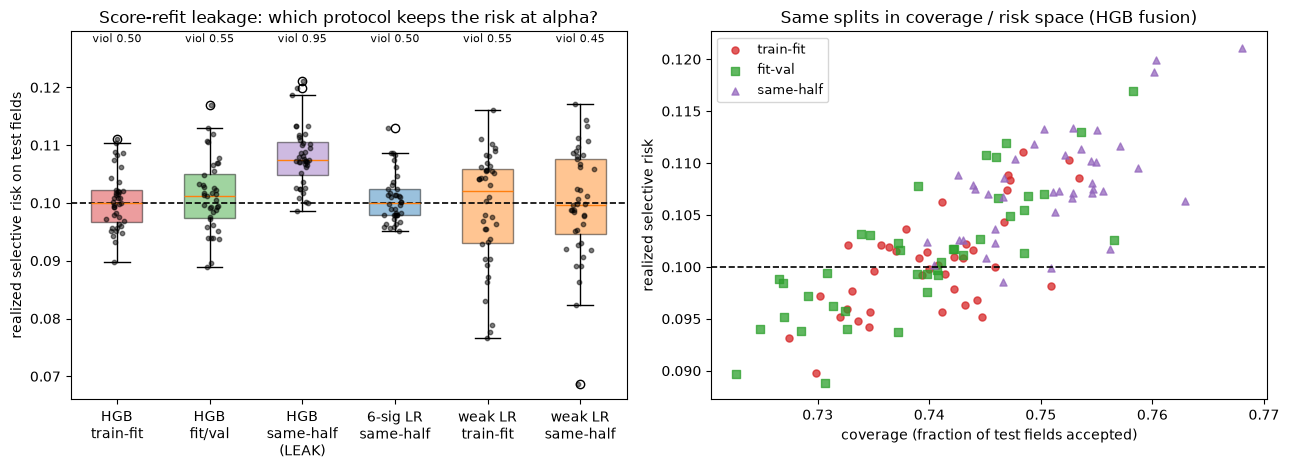

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
_ax = axes[0]
_order = ["train_fit", "fit_val", "same_half", "lr_same_half", "weak_train_fit", "weak_same_half"]
_names = ["HGB\ntrain-fit", "HGB\nfit/val", "HGB\nsame-half\n(LEAK)", "6-sig LR\nsame-half", "weak LR\ntrain-fit", "weak LR\nsame-half"]
_cols = [PAL3["a_opt"], PAL3["a_ok"], PAL3["a_bad"], PAL3["a_doc"], PAL3["a_weak"], PAL3["a_weak"]]
_data = [A_arr(A_res3b[_p], "risk") for _p in _order]
_bp = _ax.boxplot(_data, tick_labels=_names, patch_artist=True, widths=0.55)
for _patch, _c in zip(_bp["boxes"], _cols):
    _patch.set_facecolor(_c); _patch.set_alpha(0.45)
_rng = np.random.default_rng(0)
for _j, _d in enumerate(_data):
    _ax.scatter(np.full(len(_d), _j + 1) + _rng.normal(0, 0.05, len(_d)), _d, s=10, color="k", alpha=0.5, zorder=3)
_ax.axhline(A_ALPHA, color="k", ls="--", lw=1.2)
_ax.set_ylim(_ax.get_ylim()[0], _ax.get_ylim()[1] + 0.006)
for _j, _p in enumerate(_order):
    _ax.text(_j + 1, 0.995, f"viol {A_tab3b[_p]['viol']:.2f}", ha="center", va="top", fontsize=8, transform=_ax.get_xaxis_transform())
_ax.set_ylabel("realized selective risk on test fields"); _ax.set_title("Score-refit leakage: which protocol keeps the risk at alpha?")
_ax = axes[1]
for _p, _c, _mk in (("train_fit", PAL3["a_opt"], "o"), ("fit_val", PAL3["a_ok"], "s"), ("same_half", PAL3["a_bad"], "^")):
    _ax.scatter(A_arr(A_res3b[_p], "cov"), A_arr(A_res3b[_p], "risk"), s=26, color=_c, marker=_mk, alpha=0.75, label=_p.replace("_", "-"))
_ax.axhline(A_ALPHA, color="k", ls="--", lw=1.2)
_ax.set_xlabel("coverage (fraction of test fields accepted)"); _ax.set_ylabel("realized selective risk"); _ax.set_title("Same splits in coverage / risk space (HGB fusion)")
_ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


### 3c. Failure mode 3 -- tie mass

Notebook 2's simulated signals are continuous, so our fused scores have thousands of distinct values and the add-one rule never meets a tie. Real extractors often expose only coarse
signals (a verbalized "0.9"/"0.95", a binary grounded flag). To see what ties do **without touching the data**, we round each score to $L$ equal-width levels (`floor(score*L)/L`) and re-run the add-one rule
on the same 40 document splits. This is a *derived-here* counterfactual, not a re-creation of the paper's dump: the paper's "1,702 to 257 distinct scores" (idpfin-q7) came from dropping a signal from a real extractor. What we can honestly test is the mechanism quoted in section 3:
"A threshold accepts a tie mass whole or not at all" (idpfin-q7), so the smallest reachable candidate is the top level's whole block; if that block's smoothed risk is above $\alpha$ the rule returns $\tau=\infty$ and coverage is exactly zero.
We report both the **zero-filled** mean risk and the mean risk **conditional on non-zero coverage**, and the size and error rate of the top block on the calibration fields of split 0.


In [8]:
A_LEVELS = [None, 20, 10, 5, 3, 2]
_pool_mask = np.isin(FA_doc, np.where(np.isin(DOC_SPLIT, ["calib", "test"]))[0])
A_res3c, A_tab3c = {}, {}
for _k, _sc in A_SCORES.items():
    for _L in A_LEVELS:
        _sr = _sc if _L is None else np.floor(_sc * _L * (1 - 1e-12)) / _L
        _rows_ = []
        for _seed in range(A_N_SHORT):
            _ic, _it = A_doc_split_fields(_seed)
            _rows_.append(A_addone_eval(_sr[_ic], _ic, _sr[_it], _it))
        A_res3c[(_k, _L)] = _rows_
        _s = A_summ(_rows_, A_N_SHORT)
        _ic0, _ = A_doc_split_fields(0)
        _top = _sr[_ic0] == _sr[_ic0].max()
        _s["distinct"] = int(len(np.unique(_sr[_pool_mask]))); _s["top_n"] = int(_top.sum()); _s["top_err"] = float(A_ERR[_ic0][_top].mean())
        _s["top_smoothed"] = (1 + A_ERR[_ic0][_top].sum()) / (1 + _top.sum())
        A_tab3c[(_k, _L)] = _s

_rows = []
for _k in A_SCORES:
    for _L in A_LEVELS:
        _s = A_tab3c[(_k, _L)]
        _rows.append([A_LABEL[_k].split(" (")[0], "continuous" if _L is None else _L, _s["distinct"], f"{_s['cov']:.3f}", f"{_s['risk']:.4f}", "n/a" if np.isnan(_s["risk_nz"]) else f"{_s['risk_nz']:.4f}",
                      f"{_s['viol']:.3f}", f"{_s['zero']}/{A_N_SHORT}", f"{_s['top_n']} / {_s['top_err']:.3f} / {_s['top_smoothed']:.3f}"])
print("Add-one at alpha=0.10 on the rounded scores (40 document splits; top block = calibration fields of split 0 at the top level: size / error rate / add-one smoothed risk):")
A_pipe(["score", "levels L", "distinct values (pool)", "mean coverage", "mean risk (zero-filled)", "mean risk given cov>0", "violation frac", "zero-coverage splits", "top block n / err / smoothed"], _rows)

print()
for _k in A_SCORES:
    check(f"S3.16[{_k}] rounding to L levels leaves exactly L (or fewer) distinct score values on the pool",
          all(A_tab3c[(_k, _L)]["distinct"] <= _L for _L in A_LEVELS if _L is not None), f"distinct counts {[A_tab3c[(_k, _L)]['distinct'] for _L in A_LEVELS if _L is not None]}")
    check(f"S3.17[{_k}] tie mass makes add-one more conservative, never an overshoot: mean risk (zero-filled) <= 1.05*alpha at every L",
          all(A_tab3c[(_k, _L)]["risk"] <= 1.05 * A_ALPHA for _L in A_LEVELS), f"max mean risk {max(A_tab3c[(_k, _L)]['risk'] for _L in A_LEVELS):.4f}")
_c_w, _c_w5 = A_tab3c[("weak", None)]["cov"], A_tab3c[("weak", 5)]["cov"]
check("S3.18 tie mass COLLAPSES coverage for the pessimistic score: coverage at L=5 is below half its continuous coverage", _c_w5 < 0.5 * _c_w,
      f"{_c_w5:.3f} vs {_c_w:.3f}; zero-coverage splits at L=5: {A_tab3c[('weak', 5)]['zero']}/{A_N_SHORT}")
_c_o, _c_o5 = A_tab3c[("opt", None)]["cov"], A_tab3c[("opt", 5)]["cov"]
check("S3.19 the optimistic (bimodal, well-separated) score is robust to ties: coverage at L=5 keeps at least 90% of its continuous coverage", _c_o5 >= 0.9 * _c_o,
      f"{_c_o5:.3f} vs {_c_o:.3f}")


Add-one at alpha=0.10 on the rounded scores (40 document splits; top block = calibration fields of split 0 at the top level: size / error rate / add-one smoothed risk):
| score | levels L | distinct values (pool) | mean coverage | mean risk (zero-filled) | mean risk given cov>0 | violation frac | zero-coverage splits | top block n / err / smoothed |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| optimistic | continuous | 11689 | 0.740 | 0.1004 | 0.1004 | 0.500 | 0/40 | 1 / 0.000 / 0.500 |
| optimistic | 20 | 20 | 0.735 | 0.0965 | 0.0965 | 0.125 | 0/40 | 3927 / 0.005 / 0.005 |
| optimistic | 10 | 10 | 0.734 | 0.0961 | 0.0961 | 0.125 | 0/40 | 4420 / 0.012 / 0.012 |
| optimistic | 5 | 5 | 0.732 | 0.0951 | 0.0951 | 0.125 | 0/40 | 4878 / 0.025 / 0.025 |
| optimistic | 3 | 3 | 0.638 | 0.0433 | 0.0433 | 0.000 | 0/40 | 5382 / 0.044 / 0.044 |
| optimistic | 2 | 2 | 0.699 | 0.0751 | 0.0751 | 0.000 | 0/40 | 5880 / 0.078 / 0.078 |
| pessimistic | continuous | 16818 | 0.197 | 0.0990 | 0.

np.True_

**How to read this chart.** x-axis: how coarse the score is (number of levels $L$; "cont." = the original continuous score). Left: mean coverage (fraction of test fields accepted) of the add-one rule. Right: the share of the 40 splits in which the rule accepted **nothing** (zero coverage; $\tau=\infty$).
For a score that already separates good from bad fields cleanly (**optimistic**, red), coarse levels cost little down to about five levels and cost visibly (but never collapse) at two or three levels: the top block is still pure enough. For the **pessimistic** weak-signal score (orange), the top level's tie block contains too many errors to pass the add-one bar, the rule can only take the block whole or leave it,
and coverage collapses to zero: the review queue is *everything* although the continuous score could have auto-accepted a slice. This is the paper's mechanism reproduced on our data, but only for the weaker score; with the optimistic score the effect is absent, and we say so. Practical reading: if the real extractor only exposes a few discrete confidence levels,
prefer the fused score (many distinct values) over a raw coarse signal, and check the size of the top tie block before promising any coverage.


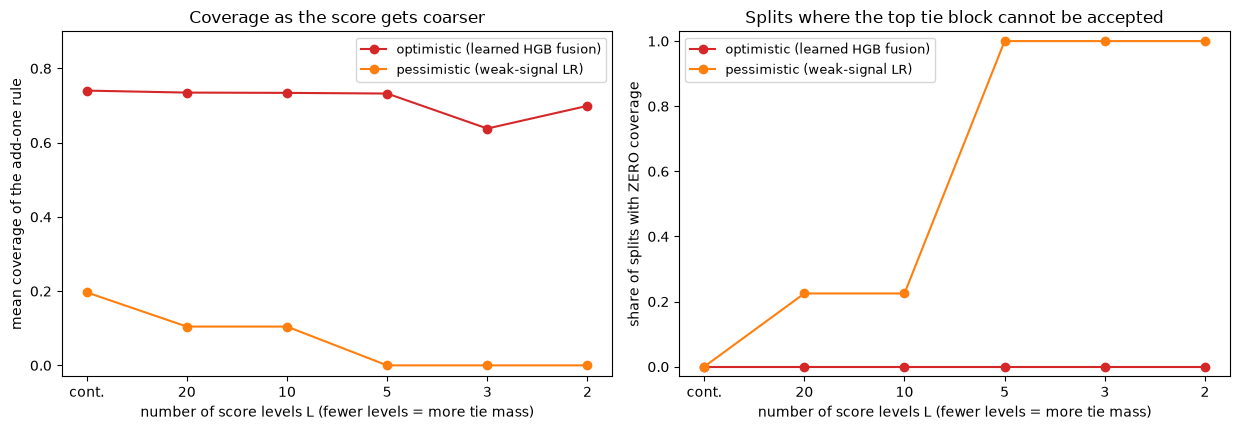

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
_xs = np.arange(len(A_LEVELS))
_xl = ["cont." if _L is None else str(_L) for _L in A_LEVELS]
for _k, _c in (("opt", PAL3["a_opt"]), ("weak", PAL3["a_weak"])):
    axes[0].plot(_xs, [A_tab3c[(_k, _L)]["cov"] for _L in A_LEVELS], "o-", color=_c, label=A_LABEL[_k])
    axes[1].plot(_xs, [A_tab3c[(_k, _L)]["zero"] / A_N_SHORT for _L in A_LEVELS], "o-", color=_c, label=A_LABEL[_k])
for _ax, _yl, _t in zip(axes, ["mean coverage of the add-one rule", "share of splits with ZERO coverage"], ["Coverage as the score gets coarser", "Splits where the top tie block cannot be accepted"]):
    _ax.set_xticks(_xs); _ax.set_xticklabels(_xl); _ax.set_xlabel("number of score levels L (fewer levels = more tie mass)"); _ax.set_ylabel(_yl); _ax.set_title(_t)
    _ax.set_ylim(-0.03, 1.03 if _ax is axes[1] else 0.9); _ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


**Section 3 in one paragraph (what our data does and does not show).** On the Notebook-2 pipeline the add-one rule is right **on average** at $\alpha = 0.10$ under every honest protocol, and wrong **per batch** about half the time; *document clustering* is real
(design effect clearly above 1, naive binomial intervals too narrow) but adds only modest extra batch-to-batch variability here; *score-refit leakage* is clearly visible for the high-capacity fusion and absent for low-capacity ones; *tie mass* collapses coverage for the weak score and not for the strong one.
None of these is a guarantee failure of the rule *in expectation*: they are reasons a single batch, and a report that says "calibrated at 10%", can mislead. All of this is tier-1 vocabulary. The next section changes the unit from the field to the **document** and swaps the add-one rule for cfBH.


## 4. cfBH at the DOCUMENT unit (derived here)

**What the paper says** (re-read from `idpfin-q2` and `idpfin-q11`). The selection problem: from test documents $X_{n+1},\dots,X_{n+m}$ pick a set $R$ whose members all have $Y_{n+j} > c_j$ except for a fraction controlled by the FDR, $\text{FDR} = \mathbb{E}[\text{FDP}]$ with
$\text{FDP} = \sum_j \mathbf{1}\{j \in R, Y_{n+j} \le c_j\} / (1 \vee |R|)$ (idpfin-q11). Ingredients, verbatim from `idpfin-q2`:

> **Definition 2.1.** "A nonconformity score $V(\cdot,\cdot)$ is monotone if $V(x, y) \le V(x, y')$ holds for any $x$ and any $y, y'$ obeying $y \le y'$." (idpfin-q2)
>
> Conformal p-value (4): $p_j = \dfrac{\sum_{i=1}^n \mathbf{1}\{V_i < \hat V_{n+j}\} + \left(1 + \sum_{i=1}^n \mathbf{1}\{V_i = \hat V_{n+j}\}\right) U_j}{n+1}$, "where $U_j \sim \text{Unif}(0,1)$ are i.i.d. random variables to break ties", with $V_i = V(X_i, Y_i)$ and $\hat V_{n+j} = V(X_{n+j}, c_j)$. (idpfin-q2)
>
> **Algorithm 1 (cfBH).** "Compute $k^* = \max\{k : \sum_{j=1}^m \mathbf{1}\{p_j \le qk/m\} \ge k\}$. **Output:** Selection set $R = \{j : p_j \le qk^*/m\}$." (idpfin-q2)
>
> **Theorem 2.3.** "Suppose $V$ is monotone, the calibration data and test data are i.i.d., and data in $\{Z_i\}_{i=1}^n \cup \{\tilde Z_{n+\ell}\}_{\ell \ne j} \cup \{Z_{n+j}\}$ are mutually independent for any $j$. Then, for any $q \in (0,1)$, the output $R$ of Algorithm 1 satisfies $\text{FDR} \le q$." (idpfin-q2)
>
> Warning (Section 2.4): "$\tau$ should not depend on the calibration data, because this would potentially break the mutual independence condition [...] and invalidate FDR control." (idpfin-q2)
>
> Validity is **joint** only: "$\mathbb{P}(p_j \le \alpha \text{ and } j \in H_0) \le \alpha$" (5); the conditional version does **not** hold (footnote 3). (idpfin-q2)

**Mapping to our documents (all of this is derived here; the paper is "silent on multi-field hierarchical or document-level clustering", idpfin-q11).**

| cfBH object | at the document unit |
| --- | --- |
| unit $Z = (X, Y)$ | one document; $X$ its features, $Y$ = `DA_y_ok` in {0,1} (1 = every critical field correct) |
| select $Y > c$ with $c = 0$ | select documents with $Y = 1$; "wrong" = the document has at least one wrong critical field |
| nonconformity score | clipped score $V(x,y) = M\,y - \hat\mu(x)$, $M = 100$, $\hat\mu$ = predicted $P(Y=1 \mid x)$ = `DA_mu` (optimistic) or `DA_mu_weak` (pessimistic); monotone in $y$ for every $x$ |
| calibration / test | the calib / test documents of `resplit(seed)` |
| $\hat V_{n+j}$ | $V(x_j, c=0) = -\hat\mu(x_j)$ |

**Assumptions, and which hold.** (1) $V$ monotone: yes by construction. (2) The score model is independent of calibration and test documents: yes, `DOC_MODEL_Y*` are fit on `train` documents only (prelude section 2), and the threshold $c = 0$ does not depend on calibration data.
(3) Calibration and test documents exchangeable / i.i.d.: `resplit(seed)` is a uniformly random split of a fixed pool, so exchangeable **by construction**, which is what the Monte Carlo below checks. **Caveat, stated plainly:** the *real* claim needs the client's incoming documents to be exchangeable with the calibration documents.
Documents from the same vendor template, month or batch are **not** literally i.i.d.; the shift split is a deliberate violation and is handled by Part B. (4) A random split of a fixed pool means the Monte Carlo below estimates FDR *conditional on this pool*; it does not tell us what the FDR would be on a different population.


**Design of the check.** For each of $B = 1000$ resplits (seeds 0..999) and each $q \in \{0.05, 0.10, 0.20\}$:

- **cfBH** (Algorithm 1) with the clipped score, for `DA_mu` (optimistic) and `DA_mu_weak` (pessimistic); **realized FDR** = mean FDP over batches (FDP $=0$ when nothing is selected, the $1 \vee |R|$ convention); **power** = fraction of good documents in the test batch that are auto-posted; also the fraction of *all* documents auto-posted; the number of **zero-selection batches**; and the mean FDP *conditional on a non-empty selection* (which is *not* promised to be $\le q$).
- **Bonferroni** on the same p-values: select $p_j \le q/m$.
- **Folklore document rule** (Notebook 2's rule lifted to documents): auto-post iff *every* critical field has verbalized confidence $\ge 0.9$ **and** no business rule failed on it. It has no target $q$; we report its realized error among auto-posted documents.
- **Naive per-field cfBH** aggregated to documents: run cfBH on the **critical fields** (calibration = critical fields of calib documents, test = critical fields of test documents; $V = M\cdot\text{correct} - p(x)$ with the field score `FA_p_hgb` / `FA_p_weak`), then auto-post a document iff *all* its critical fields were selected. This is what happens if you ignore the document unit; we measure the FDR **at the document level**.

**Tolerances (fixed in advance).** FDR check: PASS iff mean FDP $\le q + 1.645\,\text{SE}$ with SE = sd(FDP)/$\sqrt{B}$ (one-sided 95%; the resplits share a pool, so SE is optimistic). Proportions (zero-selection batches, joint validity (5)) use one-sided 95% Clopper-Pearson upper bounds.


In [10]:
A_M_BIG = 100.0
A_B = 1000
A_QS = [0.05, 0.10, 0.20]
A_MU = {"opt": DA_mu, "weak": DA_mu_weak}


def A_cfbh_pvalues(V_cal, V_hat, rng):
    """Conformal p-values, eq. (4) of Jin & Candes, with uniform tie-breaking U_j."""
    _Vs = np.sort(V_cal)
    _lo = np.searchsorted(_Vs, V_hat, side="left")            # #{V_i <  V_hat}
    _hi = np.searchsorted(_Vs, V_hat, side="right")           # #{V_i <= V_hat}
    _U = rng.uniform(size=len(V_hat))
    return (_lo + (1 + (_hi - _lo)) * _U) / (len(V_cal) + 1)


def A_bh(p, q):
    """Algorithm 1, steps 3-4 (BH on the p-values): k* = max{k : #{p_j <= q k / m} >= k}; R = {j : p_j <= q k* / m}."""
    _m = len(p)
    _o = np.argsort(p)
    _ok = p[_o] <= q * np.arange(1, _m + 1) / _m
    _k = int(np.where(_ok)[0].max()) + 1 if _ok.any() else 0
    _sel = np.zeros(_m, bool); _sel[_o[:_k]] = True
    return _sel


def A_V(mu, y):
    """Clipped monotone nonconformity score V(x, y) = M*y - mu(x)."""
    return A_M_BIG * y - mu


# ---- implementation self-checks against brute force -------------------------------------------------------------------------
_rng = np.random.default_rng(5)
_Vc = np.round(_rng.normal(size=60), 1); _Vh = np.round(_rng.normal(size=25), 1)         # rounded => genuine ties
_p_fast = A_cfbh_pvalues(_Vc, _Vh, np.random.default_rng(99))
_U = np.random.default_rng(99).uniform(size=25)
_p_brute = np.array([(sum(_Vc[i] < _Vh[j] for i in range(60)) + (1 + sum(_Vc[i] == _Vh[j] for i in range(60))) * _U[j]) / 61 for j in range(25)])
check("S4.1 vectorised conformal p-value equals a brute-force transcription of eq. (4) (with ties)", np.allclose(_p_fast, _p_brute), f"max abs diff {np.abs(_p_fast - _p_brute).max():.2e}")
_ok_bh = True
for _t in range(200):
    _pp = np.random.default_rng(_t).uniform(size=40) ** 2; _q = [0.05, 0.1, 0.2][_t % 3]
    _ks = max([k for k in range(0, 41) if k == 0 or (_pp <= _q * k / 40).sum() >= k])
    _brute = _pp <= _q * _ks / 40 if _ks > 0 else np.zeros(40, bool)
    _ok_bh &= bool(np.array_equal(A_bh(_pp, _q), _brute))
check("S4.2 A_bh equals a brute-force transcription of Algorithm 1 (k*, R) on 200 random p-vectors", _ok_bh)
check("S4.3 the clipped score is monotone in y for every document (Definition 2.1): V(x,0) <= V(x,1)", bool(np.all(A_V(DA_mu, 0) <= A_V(DA_mu, 1)) and np.all(A_V(DA_mu_weak, 0) <= A_V(DA_mu_weak, 1))))

# ---- folklore document rule -------------------------------------------------------------------------------------------------
_rule = np.array([f["rule_failed"] for f in FIELDS], dtype=float)
_field_pass = (FA_verb >= 0.9) & (_rule == 0)
_n_fail = np.bincount(FA_doc[FA_crit], weights=(~_field_pass[FA_crit]).astype(float), minlength=N_DOC)
A_FOLK = _n_fail == 0                                                    # per document: every critical field passes the folklore rule

# ---- Monte Carlo over document resplits ------------------------------------------------------------------------------------
A_mc = {}      # (method, score, q) -> array of rows (fdp, n_sel, power, share_of_all, empty)
A_pv = {"opt": [], "weak": []}   # p-values for the validity property (5)
A_batch = []   # (tst, y) per split for later per-type breakdowns
_t0 = time.time()
_rows_by = defaultdict(list)
_crit_idx = np.where(FA_crit)[0]
_crit_doc = FA_doc[_crit_idx]
A_sel_store = {}   # (score, q, seed) -> selected document ids, for the type breakdown (q=0.10 only)
for _seed in range(A_B):
    _cal, _tst = resplit(_seed)
    _y = DA_y_ok[_tst]; _m = len(_tst); _good = max(1, int(_y.sum()))
    for _sk, _mu in A_MU.items():
        _rng = np.random.default_rng([SEED3, 4242, _seed])
        _p = A_cfbh_pvalues(A_V(_mu[_cal], DA_y_ok[_cal]), A_V(_mu[_tst], 0), _rng)
        if _seed < 400:
            A_pv[_sk].append((_p, _y))
        for _q in A_QS:
            _sel = A_bh(_p, _q); _R = int(_sel.sum())
            _rows_by[("cfbh", _sk, _q)].append(((1 - _y)[_sel].sum() / max(1, _R), _R, _y[_sel].sum() / _good, _R / _m, _R == 0))
            if _q == 0.10:
                A_sel_store[(_sk, _seed)] = _tst[_sel]
            _selb = _p <= _q / _m; _Rb = int(_selb.sum())
            _rows_by[("bonf", _sk, _q)].append(((1 - _y)[_selb].sum() / max(1, _Rb), _Rb, _y[_selb].sum() / _good, _Rb / _m, _Rb == 0))
    _sf = A_FOLK[_tst]; _Rf = int(_sf.sum())
    _rows_by[("folk", "opt", 0.0)].append(((1 - _y)[_sf].sum() / max(1, _Rf), _Rf, _y[_sf].sum() / _good, _Rf / _m, _Rf == 0))
    # naive per-field cfBH -> document aggregation (critical fields only)
    for _sk, _fs in (("opt", FA_p_hgb), ("weak", FA_p_weak)):
        _ic = _crit_idx[np.isin(_crit_doc, _cal)]; _it = _crit_idx[np.isin(_crit_doc, _tst)]
        _rng = np.random.default_rng([SEED3, 9191, _seed])
        _pf = A_cfbh_pvalues(A_V(_fs[_ic], FA_correct[_ic]), A_V(_fs[_it], 0), _rng)
        _nct = np.bincount(FA_doc[_it], minlength=N_DOC)
        for _q in A_QS:
            _sf_ = A_bh(_pf, _q); _Rf_ = int(_sf_.sum())
            _fdp_field = A_ERR[_it][_sf_].sum() / max(1, _Rf_)
            _nsel = np.bincount(FA_doc[_it][_sf_], minlength=N_DOC)
            _post = (_nct > 0) & (_nsel == _nct)
            _post_t = _post[_tst]; _Rd = int(_post_t.sum())
            _rows_by[("field_cfbh_doc", _sk, _q)].append(((1 - _y)[_post_t].sum() / max(1, _Rd), _Rd, _y[_post_t].sum() / _good, _Rd / _m, _Rd == 0, _fdp_field, _Rf_ / len(_it)))
A_mc = {k: np.array(v, dtype=float) for k, v in _rows_by.items()}
print(f"Monte Carlo over {A_B} resplits done in {time.time() - _t0:.1f}s\n")


def A_mc_summary(key):
    _r = A_mc[key]; _n = len(_r)
    _fdp = _r[:, 0]; _se = _fdp.std(ddof=1) / np.sqrt(_n); _emp = _r[:, 4].astype(bool)
    return dict(fdr=_fdp.mean(), se=_se, fdr_nz=_fdp[~_emp].mean() if (~_emp).any() else float("nan"), n_sel=_r[:, 1].mean(), power=_r[:, 2].mean(), share=_r[:, 3].mean(),
                empty=int(_emp.sum()), empty_ub=A_cp_upper(int(_emp.sum()), _n), viol=float((_fdp > key[2]).mean()) if key[2] > 0 else float("nan"))


A_sum = {k: A_mc_summary(k) for k in A_mc}
for _sk in ("opt", "weak"):
    print(f"--- {A_LABEL[_sk]} ---")
    _rows = []
    for _q in A_QS:
        for _meth, _nm in (("cfbh", "cfBH (doc unit)"), ("bonf", "Bonferroni p<=q/m")):
            _s = A_sum[(_meth, _sk, _q)]
            _rows.append([_q, _nm, f"{_s['fdr']:.4f} (+{1.645 * _s['se']:.4f})", f"{_s['fdr_nz']:.4f}", f"{_s['n_sel']:.1f}", f"{_s['share']:.3f}", f"{_s['power']:.3f}", f"{_s['empty']}/{A_B} (CP ub {_s['empty_ub']:.3f})"])
        _s = A_sum[("field_cfbh_doc", _sk, _q)]
        _rows.append([_q, "naive per-field cfBH -> doc (all crit fields selected)", f"{_s['fdr']:.4f} (+{1.645 * _s['se']:.4f})", f"{_s['fdr_nz']:.4f}", f"{_s['n_sel']:.1f}", f"{_s['share']:.3f}", f"{_s['power']:.3f}", f"{_s['empty']}/{A_B} (CP ub {_s['empty_ub']:.3f})"])
    A_pipe(["q", "method", "realized DOC-level FDR (+1.645 SE)", "mean FDP given non-empty selection", "docs auto-posted per batch", "share of all docs", "power (share of good docs)", "empty batches"], _rows)
_s = A_sum[("folk", "opt", 0.0)]
print(f"\nfolklore document rule (score-free): docs auto-posted per batch {_s['n_sel']:.1f} (share {_s['share']:.4f}, power {_s['power']:.4f}); realized error among auto-posted docs {_s['fdr']:.4f}; empty batches {_s['empty']}/{A_B}")
_nf = np.array([[A_mc[('field_cfbh_doc', _sk, _q)][:, 5].mean() for _q in A_QS] for _sk in ('opt', 'weak')])
print("naive per-field cfBH, FIELD-level realized FDR (critical fields) for q=0.05/0.10/0.20: optimistic " + " / ".join(f"{_v:.4f}" for _v in _nf[0]) + " ; pessimistic " + " / ".join(f"{_v:.4f}" for _v in _nf[1]))
print(f"documents in a test batch: about {len(resplit(0)[1])}; good documents about {DA_y_ok[resplit(0)[1]].sum()}")

print()
for _sk in ("opt", "weak"):
    for _q in A_QS:
        _s = A_sum[("cfbh", _sk, _q)]
        check(f"S4.4[{_sk}, q={_q:.2f}] cfBH at the DOCUMENT unit: realized FDR <= q + 1.645*SE", _s["fdr"] <= _q + 1.645 * _s["se"], f"FDR {_s['fdr']:.4f}, SE {_s['se']:.4f}, mean |R| {_s['n_sel']:.1f}, empty batches {_s['empty']}/{A_B}")
for _sk in ("opt", "weak"):
    for _q in A_QS:
        _s = A_sum[("bonf", _sk, _q)]
        check(f"S4.5[{_sk}, q={_q:.2f}] Bonferroni also respects q (it is valid, just powerless): FDR <= q + 1.645*SE", _s["fdr"] <= _q + 1.645 * _s["se"], f"FDR {_s['fdr']:.4f}, mean |R| {_s['n_sel']:.1f}")
_c, _b = A_sum[("cfbh", "opt", 0.10)], A_sum[("bonf", "opt", 0.10)]
check("S4.6 cfBH auto-posts at least 4x as many documents as Bonferroni at q=0.10 (optimistic score)", _c["n_sel"] >= 4 * _b["n_sel"], f"{_c['n_sel']:.1f} vs {_b['n_sel']:.1f} per batch")
# validity property (5): joint, not conditional.  For the clipped score the guarantee is TIGHT (good documents get p ~ 1, so p <= alpha
# happens almost only for bad ones and the joint probability equals alpha up to Monte-Carlo noise); the honest test of "<= alpha" is
# therefore "no significant evidence of a violation": the one-sided 95% Clopper-Pearson LOWER bound must not exceed alpha.
for _sk in ("opt", "weak"):
    _P = np.concatenate([_a for _a, _ in A_pv[_sk]]); _Y = np.concatenate([_b for _, _b in A_pv[_sk]])
    for _a in (0.05, 0.10, 0.20):
        _k_joint, _n_tot = int(((_P <= _a) & (_Y == 0)).sum()), len(_P)
        _cond = ((_P <= _a) & (_Y == 0)).sum() / max(1, (_Y == 0).sum())
        check(f"S4.7[{_sk}, alpha={_a:.2f}] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation)",
              A_cp_lower(_k_joint, _n_tot) <= _a, f"joint {_k_joint / _n_tot:.4f} (CP lower {A_cp_lower(_k_joint, _n_tot):.4f}, upper {A_cp_upper(_k_joint, _n_tot):.4f}); tight, so the estimate sits ON alpha")
    for _a in (0.05, 0.10):
        _kc, _nb = int(((_P <= _a) & (_Y == 0)).sum()), int((_Y == 0).sum())
        check(f"S4.7c[{_sk}, alpha={_a:.2f}] the CONDITIONAL statement P(p_j<=alpha | document bad) <= alpha does NOT hold (footnote 3 reproduced): CP lower bound > alpha",
              A_cp_lower(_kc, _nb) > _a, f"P(p<=alpha | bad) = {_kc / _nb:.4f} vs alpha {_a}")
_dfo = A_sum[("field_cfbh_doc", "opt", 0.10)]
for _q in A_QS:
    _s = A_sum[("field_cfbh_doc", "opt", _q)]
    check(f"S4.8[opt, q={_q:.2f}] IGNORING the document unit (per-field cfBH aggregated) inflates the DOCUMENT-level FDR above q: FDR - 1.645*SE > q", _s["fdr"] - 1.645 * _s["se"] > _q,
          f"doc-level FDR {_s['fdr']:.4f} vs q; the same runs' FIELD-level FDR is {A_mc[('field_cfbh_doc', 'opt', _q)][:, 5].mean():.4f}")
_s = A_sum[("field_cfbh_doc", "weak", 0.20)]
check("S4.9[weak, q=0.20] the same inflation shows for the pessimistic score at q=0.20", _s["fdr"] - 1.645 * _s["se"] > 0.20, f"doc-level FDR {_s['fdr']:.4f}")
_sw = A_sum[("field_cfbh_doc", "weak", 0.10)]
print(f"[info] pessimistic score at q=0.10: naive per-field -> doc FDR is {_sw['fdr']:.4f} with only {_sw['n_sel']:.1f} docs posted per batch; at q=0.05 it posts {A_sum[('field_cfbh_doc', 'weak', 0.05)]['n_sel']:.1f} docs (empty {A_sum[('field_cfbh_doc', 'weak', 0.05)]['empty']}/{A_B}). The inflation needs enough field coverage to appear, so we assert it only where it is visible.")
check("S4.10 the folklore document rule is safe but nearly empty: realized error among auto-posted <= 0.10 while it posts < 2% of documents",
      A_sum[("folk", "opt", 0.0)]["fdr"] <= 0.10 and A_sum[("folk", "opt", 0.0)]["share"] < 0.02, f"error {A_sum[('folk', 'opt', 0.0)]['fdr']:.4f}, share posted {A_sum[('folk', 'opt', 0.0)]['share']:.4f}")


[PASS] S4.1 vectorised conformal p-value equals a brute-force transcription of eq. (4) (with ties) -- max abs diff 0.00e+00
[PASS] S4.2 A_bh equals a brute-force transcription of Algorithm 1 (k*, R) on 200 random p-vectors
[PASS] S4.3 the clipped score is monotone in y for every document (Definition 2.1): V(x,0) <= V(x,1)


Monte Carlo over 1000 resplits done in 7.5s

--- optimistic (learned HGB fusion) ---
| q | method | realized DOC-level FDR (+1.645 SE) | mean FDP given non-empty selection | docs auto-posted per batch | share of all docs | power (share of good docs) | empty batches |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.05 | cfBH (doc unit) | 0.0493 (+0.0010) | 0.0493 | 252.1 | 0.240 | 0.663 | 0/1000 (CP ub 0.003) |
| 0.05 | Bonferroni p<=q/m | 0.0038 (+0.0011) | 0.0038 | 7.5 | 0.007 | 0.021 | 2/1000 (CP ub 0.006) |
| 0.05 | naive per-field cfBH -> doc (all crit fields selected) | 0.1093 (+0.0009) | 0.1093 | 312.2 | 0.297 | 0.771 | 0/1000 (CP ub 0.003) |
| 0.1 | cfBH (doc unit) | 0.0992 (+0.0013) | 0.0992 | 304.2 | 0.290 | 0.759 | 0/1000 (CP ub 0.003) |
| 0.1 | Bonferroni p<=q/m | 0.0040 (+0.0008) | 0.0040 | 15.0 | 0.014 | 0.041 | 0/1000 (CP ub 0.003) |
| 0.1 | naive per-field cfBH -> doc (all crit fields selected) | 0.2436 (+0.0012) | 0.2436 | 429.4 | 0.409 | 0.899 | 0/1000 (CP ub 0.0

[PASS] S4.7[opt, alpha=0.05] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation) -- joint 0.0496 (CP lower 0.0490, upper 0.0501); tight, so the estimate sits ON alpha
[PASS] S4.7[opt, alpha=0.10] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation) -- joint 0.0998 (CP lower 0.0991, upper 0.1006); tight, so the estimate sits ON alpha
[PASS] S4.7[opt, alpha=0.20] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation) -- joint 0.1998 (CP lower 0.1988, upper 0.2008); tight, so the estimate sits ON alpha
[PASS] S4.7c[opt, alpha=0.05] the CONDITIONAL statement P(p_j<=alpha | document bad) <= alpha does NOT hold (footnote 3 reproduced): CP lower bound > alpha -- P(p<=alpha | bad) = 0.0756 vs alpha 0.05
[PASS] S4.7c[opt, alpha=0.10] the CONDITIONAL stateme

[PASS] S4.7[weak, alpha=0.05] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation) -- joint 0.0496 (CP lower 0.0491, upper 0.0502); tight, so the estimate sits ON alpha
[PASS] S4.7[weak, alpha=0.10] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation) -- joint 0.0989 (CP lower 0.0981, upper 0.0996); tight, so the estimate sits ON alpha
[PASS] S4.7[weak, alpha=0.20] validity (5), JOINT: P(p_j<=alpha and document bad) <= alpha: the 95% CP LOWER bound does not exceed alpha (no evidence of violation) -- joint 0.1990 (CP lower 0.1979, upper 0.2000); tight, so the estimate sits ON alpha
[PASS] S4.7c[weak, alpha=0.05] the CONDITIONAL statement P(p_j<=alpha | document bad) <= alpha does NOT hold (footnote 3 reproduced): CP lower bound > alpha -- P(p<=alpha | bad) = 0.0757 vs alpha 0.05
[PASS] S4.7c[weak, alpha=0.10] the CONDITIONAL st

np.True_

**How to read this chart.** Left: realized document-level FDR (mean FDP over 1000 resplits, error bars $\pm 1.645$ SE) against the target $q$; the diagonal is "FDR = q", and **being on or below the diagonal is the promise**. cfBH (red, optimistic; orange, pessimistic) should hug the diagonal from below: with the clipped score the guarantee is tight (the joint probability in check S4.7 equals $\alpha$), so the budget $q$ is used up.
Bonferroni is also below it but posts almost nothing (see the middle panel). The **naive per-field cfBH aggregated to documents** (blue, optimistic score) is *above* the diagonal at every $q$: it kept its promise about *fields* (printed above) but the client cares about *documents*, and a document needs all of ~5 critical fields to be right, so the field-level FDR is not the document-level FDR. With the pessimistic score (cyan) the inflation only appears at the largest $q$, where the field coverage is high enough for many documents to be posted; at small $q$ it posts almost nothing.
Middle: power, the fraction of genuinely good documents that get auto-posted. Right: the distribution of the per-batch FDP at $q = 0.10$ for cfBH; the mean sits at $q$ but individual batches scatter on both sides, i.e. an FDR guarantee, like tier 1, is an **expectation** over batches and not a per-batch certificate; the pessimistic score also has empty batches (FDP $=0$ by convention). For the review queue:
at $q=0.10$ the optimistic score lets cfBH auto-post a large share of documents while the folklore rule (dotted) posts almost none; the pessimistic score posts far fewer, which is the honest range to quote to a client until a real extractor's signals are measured.


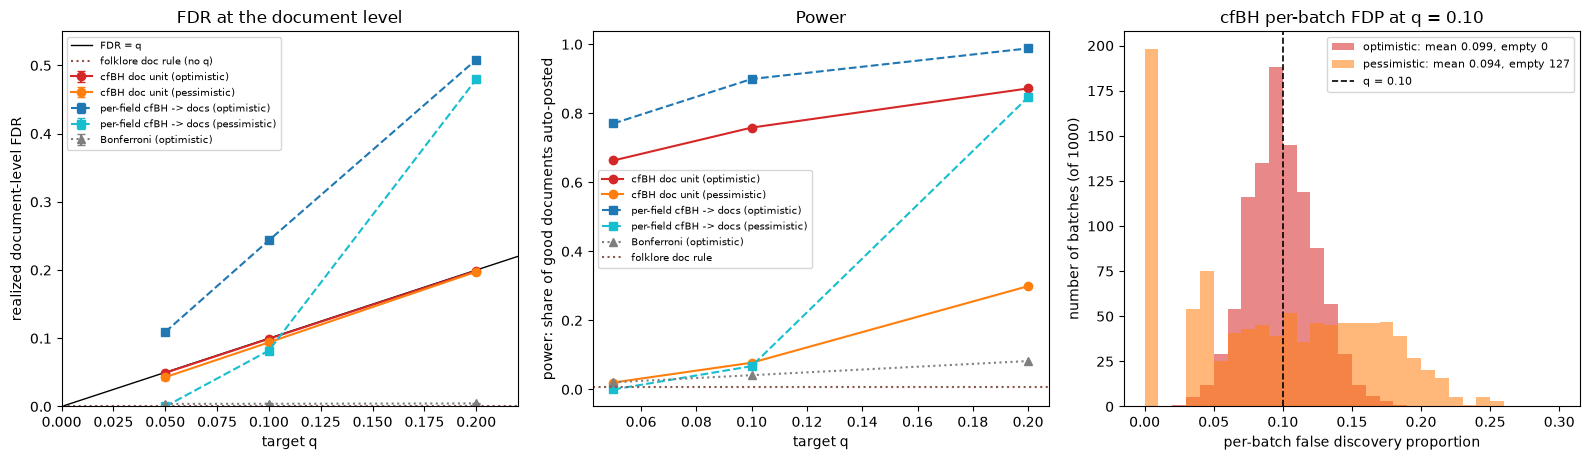

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
_qs = np.array(A_QS)
_series = [("cfbh", "opt", PAL3["a_opt"], "o", "-", "cfBH doc unit (optimistic)"), ("cfbh", "weak", PAL3["a_weak"], "o", "-", "cfBH doc unit (pessimistic)"),
           ("field_cfbh_doc", "opt", PAL3["a_doc"], "s", "--", "per-field cfBH -> docs (optimistic)"), ("field_cfbh_doc", "weak", "#17becf", "s", "--", "per-field cfBH -> docs (pessimistic)"),
           ("bonf", "opt", PAL3["a_field"], "^", ":", "Bonferroni (optimistic)")]
_ax = axes[0]
_ax.plot([0, 0.22], [0, 0.22], "k-", lw=1, label="FDR = q")
for _m_, _sk, _c, _mk, _ls, _lb in _series:
    _f = np.array([A_sum[(_m_, _sk, _q)]["fdr"] for _q in A_QS]); _e = np.array([1.645 * A_sum[(_m_, _sk, _q)]["se"] for _q in A_QS])
    _ax.errorbar(_qs, _f, yerr=_e, color=_c, marker=_mk, ls=_ls, capsize=3, label=_lb)
_ax.axhline(A_sum[("folk", "opt", 0.0)]["fdr"], color=PAL3["a_folk"], ls=":", lw=1.5, label="folklore doc rule (no q)")
_ax.set_xlabel("target q"); _ax.set_ylabel("realized document-level FDR"); _ax.set_title("FDR at the document level"); _ax.legend(fontsize=7.5); _ax.set_xlim(0, 0.22); _ax.set_ylim(0, 0.55)
_ax = axes[1]
for _m_, _sk, _c, _mk, _ls, _lb in _series:
    _ax.plot(_qs, [A_sum[(_m_, _sk, _q)]["power"] for _q in A_QS], color=_c, marker=_mk, ls=_ls, label=_lb)
_ax.axhline(A_sum[("folk", "opt", 0.0)]["power"], color=PAL3["a_folk"], ls=":", lw=1.5, label="folklore doc rule")
_ax.set_xlabel("target q"); _ax.set_ylabel("power: share of good documents auto-posted"); _ax.set_title("Power"); _ax.legend(fontsize=7.5)
_ax = axes[2]
_bins = np.linspace(0, 0.3, 31)
for _sk, _c in (("opt", PAL3["a_opt"]), ("weak", PAL3["a_weak"])):
    _fd = A_mc[("cfbh", _sk, 0.10)][:, 0]
    _ax.hist(_fd, bins=_bins, color=_c, alpha=0.55, label=f"{A_LABEL[_sk].split(' (')[0]}: mean {_fd.mean():.3f}, empty {int(A_mc[('cfbh', _sk, 0.10)][:, 4].sum())}")
_ax.axvline(0.10, color="k", ls="--", lw=1.2, label="q = 0.10")
_ax.set_xlabel("per-batch false discovery proportion"); _ax.set_ylabel("number of batches (of 1000)"); _ax.set_title("cfBH per-batch FDP at q = 0.10"); _ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### 4b. Which documents does cfBH certify? (per type, and "how many do you auto-post at $q$")

cfBH here is **pooled over document types**. Its guarantee is **marginal**: the FDR of the pooled selected set is $\le q$. **A type-conditional statement is NOT promised** (nothing in `idpfin-q2` / `idpfin-q11` gives one). The type-wise FDPs printed below are therefore *descriptive*; a type with a higher base rate of bad documents can be
over-represented among the false discoveries while the pooled FDR is still $\le q$. If the client needs "at most 10% wrong within each document type", that is what Part B's Mondrian machinery is for, and it costs coverage.


In [12]:
# ---- per-type breakdown at q = 0.10 (mean over the 1000 batches) ------------------------------------------------------------
A_type3 = {}
for _sk in ("opt", "weak"):
    _rows_t = []
    for _j, _t in enumerate(DOC_TYPES):
        _n_t = np.zeros(A_B); _post_t = np.zeros(A_B); _bad_t = np.zeros(A_B); _good_t = np.zeros(A_B)
        for _seed in range(A_B):
            _tst = resplit(_seed)[1]; _sel = A_sel_store[(_sk, _seed)]
            _in_t = DOC_TYPE_IDX[_tst] == _j; _sel_t = DOC_TYPE_IDX[_sel] == _j
            _n_t[_seed] = _in_t.sum(); _good_t[_seed] = DA_y_ok[_tst][_in_t].sum()
            _post_t[_seed] = _sel_t.sum(); _bad_t[_seed] = (1 - DA_y_ok[_sel])[_sel_t].sum()
        A_type3[(_sk, _t)] = dict(n=_n_t.mean(), good=_good_t.mean(), post=_post_t.mean(), bad=_bad_t.mean(), fdp_type=_bad_t.sum() / max(1.0, _post_t.sum()))
        _rows_t.append([_t, f"{_n_t.mean():.0f}", f"{_good_t.mean() / _n_t.mean():.3f}", f"{_post_t.mean():.1f}", f"{_post_t.mean() / _n_t.mean():.3f}", f"{_post_t.mean() / max(1e-9, _good_t.mean()):.3f}",
                        f"{A_type3[(_sk, _t)]['fdp_type']:.3f}"])
    _tot_post = sum(A_type3[(_sk, _t)]["post"] for _t in DOC_TYPES)
    print(f"--- {A_LABEL[_sk]}, q = 0.10 (pooled over types) ---")
    A_pipe(["document type", "docs per test batch", "base rate good", "auto-posted per batch", "share of type posted", "share of type's good docs posted", "pooled-over-batches FDP within type (descriptive)"], _rows_t)
    print(f"total auto-posted per batch {_tot_post:.1f}; pooled FDR (from the MC above) {A_sum[('cfbh', _sk, 0.10)]['fdr']:.4f}\n")

# ---- 'how many documents do you auto-post at q' ---------------------------------------------------------------------------
_rows = []
for _q in A_QS:
    _rows.append([_q] + [f"{A_sum[('cfbh', _sk, _q)]['n_sel']:.0f} ({100 * A_sum[('cfbh', _sk, _q)]['share']:.1f}% of docs; FDR {A_sum[('cfbh', _sk, _q)]['fdr']:.3f})" for _sk in ("opt", "weak")]
                 + [f"{A_sum[('bonf', 'opt', _q)]['n_sel']:.1f} ({100 * A_sum[('bonf', 'opt', _q)]['share']:.1f}%)", f"{A_sum[('field_cfbh_doc', 'opt', _q)]['n_sel']:.0f} (doc FDR {A_sum[('field_cfbh_doc', 'opt', _q)]['fdr']:.3f})",
                    f"{A_sum[('folk', 'opt', 0.0)]['n_sel']:.1f} ({100 * A_sum[('folk', 'opt', 0.0)]['share']:.2f}%; error {A_sum[('folk', 'opt', 0.0)]['fdr']:.3f})"])
print(f"Documents auto-posted per test batch of ~{len(resplit(0)[1])} documents (mean over {A_B} resplits):")
A_pipe(["q", "cfBH, optimistic score", "cfBH, pessimistic score", "Bonferroni (optimistic)", "per-field cfBH -> docs (optimistic)", "folklore doc rule (no q)"], _rows)

print()
_tot = sum(A_type3[("opt", _t)]["post"] for _t in DOC_TYPES)
check("S4.11 per-type auto-post counts add up to the pooled |R| (optimistic score, q=0.10)", abs(_tot - A_sum[("cfbh", "opt", 0.10)]["n_sel"]) < 1e-6, f"{_tot:.2f} vs {A_sum[('cfbh', 'opt', 0.10)]['n_sel']:.2f}")
_tot = sum(A_type3[("weak", _t)]["post"] for _t in DOC_TYPES)
check("S4.12 per-type auto-post counts add up to the pooled |R| (pessimistic score, q=0.10)", abs(_tot - A_sum[("cfbh", "weak", 0.10)]["n_sel"]) < 1e-6, f"{_tot:.2f} vs {A_sum[('cfbh', 'weak', 0.10)]['n_sel']:.2f}")
_fd_ty = {_sk: {_t: A_type3[(_sk, _t)]["fdp_type"] for _t in DOC_TYPES} for _sk in ("opt", "weak")}
_over = {_sk: [_t for _t in DOC_TYPES if _fd_ty[_sk][_t] > 0.10] for _sk in ("opt", "weak")}
print(f"[info] types whose descriptive within-type FDP exceeds q=0.10 (not promised): optimistic {_over['opt'] or 'none'}; pessimistic {_over['weak'] or 'none'}. Pooled FDR <= q does not imply per-type FDR <= q.")
check("S4.13 pooled FDR at q=0.10 <= q while the type-conditional FDPs are reported without a promise (marginal guarantee only)",
      all(A_sum[("cfbh", _sk, 0.10)]["fdr"] <= 0.10 + 1.645 * A_sum[("cfbh", _sk, 0.10)]["se"] for _sk in ("opt", "weak")),
      "; ".join(f"{_sk}: pooled {A_sum[('cfbh', _sk, 0.10)]['fdr']:.4f}, per-type " + "/".join(f"{_fd_ty[_sk][_t]:.3f}" for _t in DOC_TYPES) for _sk in ("opt", "weak")))


--- optimistic (learned HGB fusion), q = 0.10 (pooled over types) ---
| document type | docs per test batch | base rate good | auto-posted per batch | share of type posted | share of type's good docs posted | pooled-over-batches FDP within type (descriptive) |
| --- | --- | --- | --- | --- | --- | --- |
| invoice | 269 | 0.263 | 57.2 | 0.213 | 0.807 | 0.117 |
| bank_statement | 269 | 0.307 | 64.5 | 0.240 | 0.780 | 0.032 |
| kyc_form | 253 | 0.257 | 46.8 | 0.185 | 0.720 | 0.160 |
| compliance_report | 259 | 0.550 | 135.8 | 0.524 | 0.954 | 0.105 |
total auto-posted per batch 304.2; pooled FDR (from the MC above) 0.0992



--- pessimistic (weak-signal LR), q = 0.10 (pooled over types) ---
| document type | docs per test batch | base rate good | auto-posted per batch | share of type posted | share of type's good docs posted | pooled-over-batches FDP within type (descriptive) |
| --- | --- | --- | --- | --- | --- | --- |
| invoice | 269 | 0.263 | 4.7 | 0.017 | 0.066 | 0.183 |
| bank_statement | 269 | 0.307 | 5.6 | 0.021 | 0.068 | 0.165 |
| kyc_form | 253 | 0.257 | 0.0 | 0.000 | 0.000 | 0.000 |
| compliance_report | 259 | 0.550 | 22.1 | 0.085 | 0.155 | 0.120 |
total auto-posted per batch 32.4; pooled FDR (from the MC above) 0.0940

Documents auto-posted per test batch of ~1050 documents (mean over 1000 resplits):
| q | cfBH, optimistic score | cfBH, pessimistic score | Bonferroni (optimistic) | per-field cfBH -> docs (optimistic) | folklore doc rule (no q) |
| --- | --- | --- | --- | --- | --- |
| 0.05 | 252 (24.0% of docs; FDR 0.049) | 8 (0.8% of docs; FDR 0.043) | 7.5 (0.7%) | 312 (doc FDR 0.109) | 2.4 (0

True

**How to read this chart.** Left: for each document type, the share of that type's documents that cfBH (pooled, $q = 0.10$) auto-posts, for the optimistic (red) and the pessimistic (orange) score. Types differ in base rate of good documents (printed above), so a pooled selection favours the easy types.
Right: the descriptive false-discovery proportion **within** each type against the pooled target $q = 0.10$ (dashed). The pooled FDR is at or below $q$ by the theorem; a bar above the line means that type is being auto-posted with a higher error rate than the pooled average, which cfBH does **not** forbid.
(A bar of 0.000, e.g. `kyc_form` with the pessimistic score, means nothing was auto-posted for that type, not that it is perfect.) If a bar for a type is above the line in your own version, that type needs its own threshold, i.e. Mondrian-by-type calibration (Part B), at the price of fewer documents auto-posted.


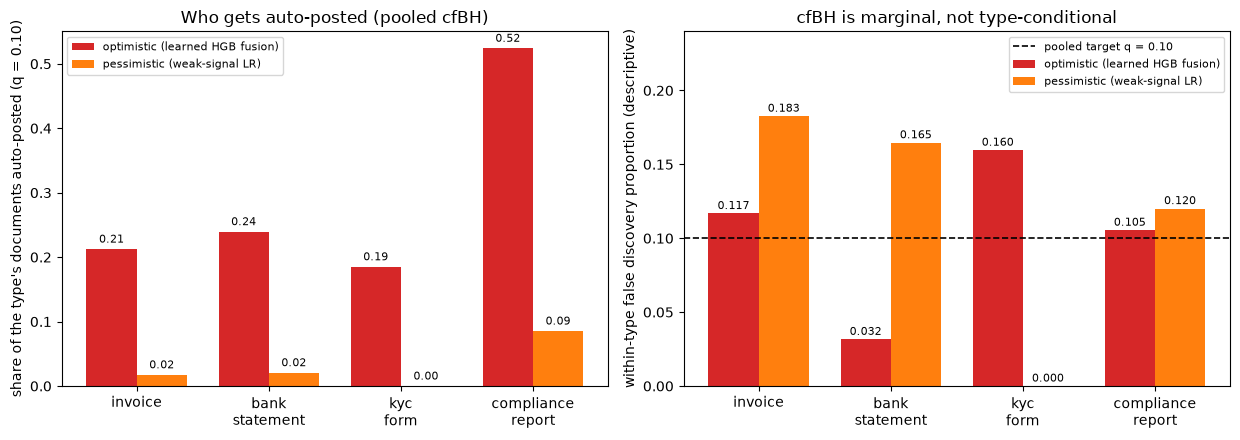

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
_x = np.arange(len(DOC_TYPES)); _w = 0.38
_ax = axes[0]
for _o, (_sk, _c) in enumerate((("opt", PAL3["a_opt"]), ("weak", PAL3["a_weak"]))):
    _sh = [A_type3[(_sk, _t)]["post"] / A_type3[(_sk, _t)]["n"] for _t in DOC_TYPES]
    _ax.bar(_x + (_o - 0.5) * _w, _sh, _w, color=_c, label=A_LABEL[_sk])
    for _j, _v in enumerate(_sh):
        _ax.text(_j + (_o - 0.5) * _w, _v + 0.01, f"{_v:.2f}", ha="center", fontsize=8)
_ax.set_xticks(_x); _ax.set_xticklabels([_t.replace("_", "\n") for _t in DOC_TYPES]); _ax.set_ylabel("share of the type's documents auto-posted (q = 0.10)")
_ax.set_title("Who gets auto-posted (pooled cfBH)"); _ax.legend(fontsize=8)
_ax = axes[1]
for _o, (_sk, _c) in enumerate((("opt", PAL3["a_opt"]), ("weak", PAL3["a_weak"]))):
    _fd = [A_type3[(_sk, _t)]["fdp_type"] for _t in DOC_TYPES]
    _ax.bar(_x + (_o - 0.5) * _w, _fd, _w, color=_c, label=A_LABEL[_sk])
    for _j, _v in enumerate(_fd):
        _ax.text(_j + (_o - 0.5) * _w, _v + 0.003, f"{_v:.3f}", ha="center", fontsize=8)
_ax.axhline(0.10, color="k", ls="--", lw=1.2, label="pooled target q = 0.10")
_ax.set_xticks(_x); _ax.set_xticklabels([_t.replace("_", "\n") for _t in DOC_TYPES]); _ax.set_ylabel("within-type false discovery proportion (descriptive)")
_ax.set_ylim(0, 0.24); _ax.set_title("cfBH is marginal, not type-conditional"); _ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()


**Section 4 in one paragraph.** cfBH, implemented exactly as Algorithm 1 at the **document** unit (derived here), holds its expectation guarantee on our synthetic pool for both the optimistic and the pessimistic score: realized FDR is at or below $q$ within the stated Monte Carlo tolerance, at $q \in \{0.05, 0.10, 0.20\}$. It is valid but **not** a per-batch bound and **not** type-conditional.
The optimistic score auto-posts a large share of documents; the pessimistic score posts far fewer, and some batches select nothing at small $q$: read the range, not the optimistic end. The folklore rule is safe only because it posts almost nothing at the document level. Ignoring the document unit (per-field cfBH aggregated to documents) keeps a *field*-level promise
and breaks the *document*-level one. Caveats that carry to the next parts: i.i.d./exchangeable documents is a design assumption (vendor template and month are not i.i.d.; the shift split breaks it on purpose); synthetic labels are exact whereas real calibration labels are not (Gurram's audit found automatic labels err one-sidedly pessimistic).

**Part A exports (for the closing cell; nothing here is needed by Part B).** Variables: `A_res3a`, `A_tab3a`, `A_deff3a`, `A_z3a`, `A_ci3a` (section 3a), `A_res3b`, `A_tab3b` (3b), `A_res3c`, `A_tab3c` (3c), `A_mc`, `A_sum`, `A_type3`, `A_sel_store`, `A_FOLK`, `A_pv` (section 4).
Helpers: `A_cfbh_pvalues`, `A_bh`, `A_V`, `A_deff`, `A_addone_eval`, `A_pipe`, `A_cp_upper`, `A_cp_lower`. Constants: `A_ALPHA`, `A_QS`, `A_B`, `A_M_BIG`. Every global defined in Part A begins with `A_` or `a_`.


## 5. SCoRE with an amount-weighted document loss (P2)

**Claim.** Notebook 2's business pain is not "how many fields are wrong" but "how much *money* is wrong". A bounded
amount-weighted loss `L_doc` in [0,1] (Section 2) fits SCoRE directly. Cost-weighted losses fit SCoRE, do **not** fit cfBH, and do
not fit Gurram's tier-3 binomial test: "A loss weighted by monetary amount (or dollar error) fits SCoRE directly, provided the risk
function is normalized/scaled to a bounded interval" (idpfin-q11); cfBH's authors list this as an open problem: "counting the number
of errors may be less sensible if the cost of making an error varies with individuals or depends on the outcomes" (idpfin-q3, q11).

**What is promised (quoted).** Two different risks, two different promises (idpfin-q4):

| name | definition (idpfin-q4) | what it is NOT |
| --- | --- | --- |
| MDR, marginal deployment risk | `E[L_{n+1} * psi_{n+1}] <= alpha` (2.1) | **not** "at most alpha of accepted items are wrong": "a procedure may deploy few but comparatively risky cases yet still controlling the MDR" |
| SDR, selective deployment risk | `E[ sum_j L_{n+j} 1{j in R} / (1 v |R|) ] <= alpha` (2.3), via e-BH | an expectation over batches, not a per-batch or high-probability statement |

Both come from a *risk-adjusted e-value*: "`E >= 0` almost surely and `E[E * L] <= 1`" (Definition 3.1, idpfin-q4); trust decision
`psi = 1{E >= 1/alpha}` (Theorem 3.2) or e-BH (Theorem 3.3). Assumptions, verbatim (idpfin-q4): the loss is bounded ("without loss of
generality, assume L in [0,1]"), data are exchangeable, and "both f(.) and s(.) are trained independently of D_calib and D_test".
We use `gamma = alpha` (the default recommended in idpfin-q10; "the asymptotic power is optimized at gamma = alpha", Theorem 4.6(ii),
idpfin-q5).

**Choices made here (derived here, none of it is in the papers).**

- *Unit = document.* SCoRE "does not formulate a document-level clustered extraction protocol" (idpfin-q11); the document is the
  exchangeable unit (Gurram, idpfin-q11), so we apply SCoRE to whole documents. Calibration and test documents come from
  `resplit(seed)` (a random split of a finite pool, hence exchangeable) restricted to **money documents**
  (invoice / bank statement / compliance report). **KYC forms are excluded**: they have no money field, so `L_doc` is undefined.
- *Score* `s = DA_risk` (optimistic, learned fusion) and `DA_risk_weak` (pessimistic), both *predicted E[L_doc]*, **LOW = trusted**:
  a document is trusted when `s(X) <= t` (the convention of Notebook 1 / P2). Both are fit on `train` documents only.
- *Ties.* The predicted-risk scores are clipped at 0 and are piecewise constant, so they contain exact ties (about 11% of money
  documents sit at exactly 0). The paper's threshold set is `M = {s(X_i)}`, a set of score **values**: `F(t; l)` at a tied value counts
  *every* document with that score. Notebook 1's index-wise scan (fine for continuous toy scores) evaluates `F` at partial tie groups,
  which is anti-conservative; the implementation below scans **distinct values** and we demonstrate the difference in S5.3.
- *SDR algorithm.* The paper states that computing the SDR e-value "necessitates a search over l in [0,1] which can be
  computationally prohibitive" and that Algorithm 3 has complexity `O((n+m)m + (n+m)log(n+m))` (Proposition 5.2, idpfin-q6). **The
  algorithm itself is not quoted in our traces**, so the SDR code below is our own exact implementation (the infimum over l is
  attained at l = 0, l = 1 or a breakpoint where a feasibility constraint switches; Notebook 1's derivation), *not* Algorithm 3.
- *Tolerances.* Monte-Carlo means: `mean <= target + 3 SE` (SE across resplits/batches). Proportions: `<= target +` the exact one-sided
  Clopper-Pearson upper bound minus the estimate (conf 0.9987), never a degenerate zero tolerance. The resplits/batches all reshuffle the
  *same* finite pool, so they estimate the expectation over random splits of this corpus, not a population.


In [14]:
import time as b_time
from scipy.stats import binom as b_binom
from IPython.display import display as b_display, Markdown as b_md

PAL3.setdefault("b_weak", "#ff7f0e"); PAL3.setdefault("b_naive", "#9467bd"); PAL3.setdefault("b_folk", "#7f7f7f")
PAL3.setdefault("b_target", "#000000"); PAL3.setdefault("b_good", "#2ca02c")
B_SCORES = {"opt": DA_risk, "weak": DA_risk_weak}
B_SC_LABEL = {"opt": "optimistic (learned fusion)", "weak": "pessimistic (weak signals)"}
B_SC_COLOR = {"opt": PAL3["hgb"], "weak": PAL3["b_weak"]}
B_POOL = np.where(np.isin(DOC_SPLIT, ["calib", "test"]) & DA_has_money)[0]      # money docs of the calib+test pool


def b_tbl(headers, rows):
    """Markdown pipe table (rendered through IPython.display.Markdown)."""
    s = "| " + " | ".join(headers) + " |\n| " + " | ".join(["---"] * len(headers)) + " |\n"
    return s + "\n".join("| " + " | ".join(str(c) for c in r) + " |" for r in rows)


def b_mc_tol_mean(x):
    x = np.asarray(x, float); return 3 * np.std(x, ddof=1) / np.sqrt(len(x))


def b_cp_tol(p_hat, reps, conf=0.9987):
    """Exact one-sided Clopper-Pearson upper bound minus the estimate (copied from Notebook 1's mc_tol_prop)."""
    k = min(max(int(round(p_hat * reps)), 0), reps)
    up = 1.0 if k >= reps else stats.beta.ppf(conf, k + 1, reps - k)
    return float(up - p_hat)


def b_mdr_e_values(cal_s, cal_L, test_s, gamma):
    """SCoRE-MDR e-values (4.1)-(4.2) for ALL test points at once. Exact infimum over l (Notebook 1's breakpoint
    argument: candidates l=0, l=1 and, if a breakpoint lies in [0,1], the value 1/gamma), TIE-COMPLETE: the
    threshold t ranges over score VALUES, so F(t; l) counts every calibration document tied at t. O(log n) per point."""
    n = len(cal_s); o = np.argsort(cal_s, kind="stable"); c = cal_s[o]
    Sc = np.concatenate([[0.0], np.cumsum(cal_L[o])])
    S_el = Sc[np.searchsorted(c, c, side="right")]                        # sum of L over calib scores <= c_i (whole tie group)
    t = np.asarray(test_s, float)
    p = np.searchsorted(c, t, side="left"); q = np.searchsorted(c, t, side="right")
    B = gamma * (n + 1)
    cnt1 = np.searchsorted(S_el, B, side="right")

    def E_at(ell):
        m2 = np.searchsorted(S_el, B - ell, side="right")
        test_feas = (cnt1 >= p) & (Sc[q] + ell <= B)
        k = np.maximum(p, m2)
        cum_k = np.where(k == p, Sc[q], S_el[np.clip(k - 1, 0, n - 1)])
        den = cum_k + ell
        with np.errstate(divide="ignore"):
            val = np.where(den > 1e-9, (n + 1) / np.maximum(den, 1e-300), np.inf)
        return np.where(test_feas, val, 0.0)

    lo = np.searchsorted(S_el, B - 1 - 1e-9, side="left"); hi = np.searchsorted(S_el, B + 1e-9, side="right")
    has_bp = (hi > np.maximum(lo, p)) | ((Sc[q] >= B - 1 - 1e-9) & (Sc[q] <= B + 1e-9))
    cand = np.minimum(E_at(0.0), E_at(1.0))
    return np.where(has_bp, np.minimum(cand, 1.0 / gamma), cand)


def b_mdr_indexwise(cal_s, cal_L, test_s, gamma):
    """Notebook 1's `mdr_e_value` logic, vectorised over test points (INDEX-wise scan: F is evaluated at every sorted
    position, i.e. also inside a tie group). Kept only to show why ties matter (S5.3)."""
    n = len(cal_s); o = np.argsort(cal_s, kind="stable"); c = cal_s[o]
    S = np.concatenate([[0.0], np.cumsum(cal_L[o])]); S = np.concatenate([S, [S[-1]]])
    t = np.asarray(test_s, float)
    p = np.searchsorted(c, t, side="left"); q = np.searchsorted(c, t, side="right")
    J = np.arange(n + 1)[None, :]
    cum = np.where(J < q[:, None], S[J + 1], np.where(J == q[:, None], S[q][:, None], S[J]))
    ge = J >= p[:, None]; B = gamma * (n + 1); rows = np.arange(len(t))

    def E_at(ell):
        feas = (cum + ell * ge) <= B
        k = feas.sum(1) - 1; kk = np.clip(k, 0, n)
        ok = (k >= 0) & (kk >= p)
        den = cum[rows, kk] + ell
        with np.errstate(divide="ignore"):
            val = np.where(den > 1e-9, (n + 1) / np.maximum(den, 1e-300), np.inf)
        return np.where(ok, val, 0.0)

    lb = B - cum
    has_bp = (ge & (lb >= -1e-9) & (lb <= 1 + 1e-9)).any(1)
    cand = np.minimum(E_at(0.0), E_at(1.0))
    return np.where(has_bp, np.minimum(cand, 1.0 / gamma), cand)


def b_mdr_grid_ref(cal_s, cal_L, s_t, gamma, grid):
    """Definition (4.1)-(4.2) evaluated literally (distinct score values, dense l-grid): an UPPER bound of the exact infimum."""
    n = len(cal_s); Mv = np.unique(np.concatenate([cal_s, [s_t]]))
    Sle = np.array([cal_L[cal_s <= v].sum() for v in Mv]); ge = Mv >= s_t; best = np.inf
    for ell in grid:
        feas = np.nonzero((Sle + ell * ge) / (n + 1) <= gamma)[0]
        if len(feas) == 0:
            val = 0.0
        else:
            k = feas[-1]
            val = 0.0 if not ge[k] else ((n + 1) / (Sle[k] + ell) if Sle[k] + ell > 1e-9 else np.inf)
        best = min(best, val)
    return best


# ---- SCoRE-SDR: exact infimum over l, tie-complete, one test point at a time (candidates = {0, 1, breakpoints in [0,1]}) ----
def b_sdr_prep(cal_s, cal_L, test_s):
    """Distinct-value grid M of calibration+test scores with tie-complete S_le(t) = sum L_i 1{s_i<=t} and cnt(t) = #{test <= t}."""
    Mv = np.unique(np.concatenate([cal_s, test_s]))
    o = np.argsort(cal_s, kind="stable"); c = cal_s[o]; Sc = np.concatenate([[0.0], np.cumsum(cal_L[o])])
    return Mv, Sc[np.searchsorted(c, Mv, side="right")], np.searchsorted(np.sort(test_s), Mv, side="right")


def b_sdr_e_value(prep, s_j, gamma, n, m):
    Mv, S_le, cnt = prep
    ge = (Mv >= s_j).astype(float)
    lb = gamma * (n + 1) * (1.0 + cnt - ge) / m - S_le                    # l at which FR(t; l) = gamma (only t >= s_j depend on l)
    lb = lb[(ge > 0) & (lb >= -1e-9) & (lb <= 1 + 1e-9)]
    ells = np.unique(np.concatenate([[0.0, 1.0], np.clip(lb, 0.0, 1.0)]))
    FR = (ells[:, None] * ge[None, :] + S_le[None, :]) / (n + 1) * (m / (1.0 + cnt - ge))[None, :]
    feas = FR <= gamma + 1e-12                                            # FR is NOT monotone in t: take the last feasible column
    if not feas.any(1).all():
        return 0.0                                                        # E = 0 when max(empty) = -inf for some l
    k = feas.shape[1] - 1 - np.argmax(feas[:, ::-1], axis=1)
    den = ells + S_le[k]
    val = np.where(ge[k] > 0, np.where(den > 1e-9, (n + 1) / np.maximum(den, 1e-300), np.inf), 0.0)
    return float(val.min())


def b_sdr_e_values(cal_s, cal_L, test_s, gamma, prep=None):
    n, m = len(cal_s), len(test_s); prep = prep or b_sdr_prep(cal_s, cal_L, test_s)
    return np.array([b_sdr_e_value(prep, test_s[j], gamma, n, m) for j in range(m)])


def b_sdr_grid_ref(cal_s, cal_L, test_s, j, gamma, grid):
    n, m = len(cal_s), len(test_s); Mv = np.unique(np.concatenate([cal_s, test_s]))
    S_le = np.array([cal_L[cal_s <= v].sum() for v in Mv]); cnt = np.array([(test_s <= v).sum() for v in Mv]); ge = (Mv >= test_s[j]).astype(float)
    best = np.inf
    for ell in grid:
        feas = np.nonzero((ell * ge + S_le) / (n + 1) * (m / (1 + cnt - ge)) <= gamma)[0]
        if len(feas) == 0:
            return 0.0
        k = feas[-1]
        val = 0.0 if ge[k] == 0 else ((n + 1) / (ell + S_le[k]) if ell + S_le[k] > 1e-9 else np.inf)
        best = min(best, val)
    return best


def b_ebh_select(E, alpha):
    """e-BH (Theorem 3.3, idpfin-q4): k* = max{k : #{E_j >= m/(alpha k)} >= k}; select E_j >= m/(alpha k*)."""
    m = len(E); Es = np.sort(E)[::-1]; k = np.arange(1, m + 1); ok = Es >= m / (alpha * k)
    return E >= m / (alpha * k[ok].max()) if ok.any() else np.zeros(m, bool)


# ---- verification of the implementations ----
_c0, _t0 = resplit(3); _c0, _t0 = _c0[DA_has_money[_c0]], _t0[DA_has_money[_t0]]
_rng = np.random.default_rng(0)

# (i) tie-free comparison against the index-wise scan (= Notebook 1's logic): with all-distinct scores they must agree exactly
_jit = DA_risk + np.random.default_rng(1).uniform(0, 1e-7, N_DOC)          # tie-breaking jitter, only for this comparison
_agree = all(np.allclose(b_mdr_e_values(_jit[_c0], DA_L[_c0], _jit[_t0], g), b_mdr_indexwise(_jit[_c0], DA_L[_c0], _jit[_t0], g))
             for g in (0.05, 0.1, 0.2))
check("S5.1 tie-complete O(log n) MDR e-values equal Notebook 1's index-wise scan when scores are tie-free", _agree,
      "gamma in {0.05, 0.10, 0.20}, one resplit, all test documents")

# (ii) against the literal definition on the REAL (tied) scores: exact inf must not exceed any dense-grid value
_grid = np.linspace(0, 1, 401); _ok, _gap = True, 0.0
for _g in (0.05, 0.1, 0.2):
    for _s in (DA_risk, DA_risk_weak):
        _sub = _rng.choice(len(_t0), 30, replace=False)
        _f = b_mdr_e_values(_s[_c0], DA_L[_c0], _s[_t0][_sub], _g)
        _r = np.array([b_mdr_grid_ref(_s[_c0], DA_L[_c0], _s[_t0][j], _g, _grid) for j in _sub])
        _ok &= bool(np.all(_f <= _r + 1e-9)) and bool(np.all((_f >= 1 / _g) == (_r >= 1 / _g)))
        _gap = max(_gap, float(np.max(np.where(np.isinf(_r), 0, _r - _f))))
check("S5.2 exact-inf MDR e-value <= dense-grid evaluation of the definition (real, tied scores) and the trust decisions agree", _ok,
      f"3 gammas x 2 scores x 30 test docs; max grid-exact gap {_gap:.4f} (a grid can only overestimate an infimum)")

# (iii) why ties matter: coarsen the score to one decimal (10 distinct values) and compare the two scans over resplits
_res_tie = {}
for _g in (0.10, 0.20):
    _a_, _b_ = [], []
    for _sd in range(60):
        _c1, _t1 = resplit(2000 + _sd); _c1, _t1 = _c1[DA_has_money[_c1]], _t1[DA_has_money[_t1]]
        _s = np.round(DA_risk, 1)
        _a_.append(np.mean(DA_L[_t1] * (b_mdr_e_values(_s[_c1], DA_L[_c1], _s[_t1], _g) >= 1 / _g)))
        _b_.append(np.mean(DA_L[_t1] * (b_mdr_indexwise(_s[_c1], DA_L[_c1], _s[_t1], _g) >= 1 / _g)))
    _res_tie[_g] = (np.mean(_a_), np.mean(_b_), b_mc_tol_mean(_a_), b_mc_tol_mean(_b_))
B_TIE_DEMO = _res_tie
print("tie demo (score rounded to 1 decimal, 60 resplits): " + "; ".join(
    f"alpha={g}: tie-complete MDR {v[0]:.4f} | index-wise MDR {v[1]:.4f}" for g, v in _res_tie.items()))
check("S5.3 on heavily tied scores the tie-complete scan keeps MDR <= alpha while the index-wise scan exceeds alpha",
      all(v[0] <= g + v[2] for g, v in _res_tie.items()) and any(v[1] > g + v[3] for g, v in _res_tie.items()),
      "; ".join(f"alpha={g}: tie-complete {v[0]:.4f} (tol {v[2]:.4f}), index-wise {v[1]:.4f} (tol {v[3]:.4f})" for g, v in _res_tie.items()))

# (iv) SDR e-value vs the literal definition (small batch, real tied scores + a rounded score)
_ok, _gap = True, 0.0
for (_n, _m) in ((100, 30), (250, 50)):
    for _rep in range(3):
        _ix = _rng.choice(B_POOL, _n + _m, replace=False); _c, _t = _ix[:_n], _ix[_n:]
        for _s in (DA_risk, np.round(DA_risk_weak, 1)):
            for _g in (0.1, 0.2):
                _f = b_sdr_e_values(_s[_c], DA_L[_c], _s[_t], _g)
                _r = np.array([b_sdr_grid_ref(_s[_c], DA_L[_c], _s[_t], j, _g, np.linspace(0, 1, 201)) for j in range(0, _m, 7)])
                _ok &= bool(np.all(_f[::7] <= _r + 1e-9)); _gap = max(_gap, float(np.max(np.where(np.isinf(_r), 0, _r - _f[::7]))))
check("S5.4 exact-inf SDR e-value <= dense-grid evaluation of definition (5.1) (tied scores, two batch sizes)", _ok, f"max grid-exact gap {_gap:.4f}")

# (v) the SDR feasibility question: time the exact e-value at production scale
_ix = _rng.permutation(B_POOL); _n_full = len(_ix) // 2; _c, _t = _ix[:_n_full], _ix[_n_full:]
_t0_ = b_time.time(); _pr = b_sdr_prep(DA_risk[_c], DA_L[_c], DA_risk[_t]); _E = [b_sdr_e_value(_pr, DA_risk[_t][j], 0.1, len(_c), len(_t)) for j in range(60)]
B_SDR_MS_PER_EVALUE = (b_time.time() - _t0_) / 60 * 1e3
print(f"exact SDR e-value at production scale (n={len(_c)} calibration, m={len(_t)} test documents): {B_SDR_MS_PER_EVALUE:.2f} ms per e-value "
      f"-> {B_SDR_MS_PER_EVALUE * len(_t) / 1e3:.2f} s per (batch, alpha, score)")
check("S5.5 exact SDR is feasible at production scale here (< 1 s per batch and alpha)", B_SDR_MS_PER_EVALUE * len(_t) / 1e3 < 1.0,
      f"{B_SDR_MS_PER_EVALUE * len(_t) / 1e3:.2f} s (Notebook 1 only ran n=80, m=30 because its loop was pure Python over every candidate)")


[PASS] S5.1 tie-complete O(log n) MDR e-values equal Notebook 1's index-wise scan when scores are tie-free -- gamma in {0.05, 0.10, 0.20}, one resplit, all test documents


[PASS] S5.2 exact-inf MDR e-value <= dense-grid evaluation of the definition (real, tied scores) and the trust decisions agree -- 3 gammas x 2 scores x 30 test docs; max grid-exact gap 0.0007 (a grid can only overestimate an infimum)


tie demo (score rounded to 1 decimal, 60 resplits): alpha=0.1: tie-complete MDR 0.0894 | index-wise MDR 0.1123; alpha=0.2: tie-complete MDR 0.1881 | index-wise MDR 0.2094
[PASS] S5.3 on heavily tied scores the tie-complete scan keeps MDR <= alpha while the index-wise scan exceeds alpha -- alpha=0.1: tie-complete 0.0894 (tol 0.0050), index-wise 0.1123 (tol 0.0044); alpha=0.2: tie-complete 0.1881 (tol 0.0084), index-wise 0.2094 (tol 0.0070)


[PASS] S5.4 exact-inf SDR e-value <= dense-grid evaluation of definition (5.1) (tied scores, two batch sizes) -- max grid-exact gap 0.0117
exact SDR e-value at production scale (n=796 calibration, m=797 test documents): 0.13 ms per e-value -> 0.10 s per (batch, alpha, score)
[PASS] S5.5 exact SDR is feasible at production scale here (< 1 s per batch and alpha) -- 0.10 s (Notebook 1 only ran n=80, m=30 because its loop was pure Python over every candidate)


True

### 5(a). SCoRE-MDR at full scale: an expectation over the money-document pool

For each of 400 resplits the calibration half calibrates, every test-half money document gets an e-value, and
`psi = 1{E >= 1/alpha}` (Algorithm 1 with `gamma = alpha`). We check `E[L * psi] <= alpha` and then, **as a separate quantity**, report
the average loss per *accepted* document. Theorem 3.2 controls the first; the second is what a reader who misreads MDR as a
selective error rate would assume is `<= alpha` (idpfin-q4, q11: MDR "does NOT guarantee that at most alpha of accepted ... are wrong").


In [15]:
B_ALPHAS = (0.05, 0.10, 0.20)
B_N_RESPLITS_MDR = 400


def b_mdr_mc(score, alpha, n_resplits=B_N_RESPLITS_MDR, seed0=1000):
    rec = []
    for sd in range(n_resplits):
        cal, tst = resplit(seed0 + sd); cal, tst = cal[DA_has_money[cal]], tst[DA_has_money[tst]]
        psi = b_mdr_e_values(score[cal], DA_L[cal], score[tst], alpha) >= 1 / alpha
        L = DA_L[tst]
        rec.append((np.mean(L * psi), psi.sum(), len(tst), (L * psi).sum(), (L[psi] > alpha).sum(), np.mean(L)))
    return np.array(rec, float)


B_MDR_RES = {(k, a): b_mdr_mc(s, a) for k, s in B_SCORES.items() for a in B_ALPHAS}
_rows = []
for (_k, _a), _r in B_MDR_RES.items():
    _nz = _r[:, 1] > 0
    _rows.append((B_SC_LABEL[_k].split(" ")[0], f"{_a:.2f}", f"{_r[:, 0].mean():.4f} +/- {b_mc_tol_mean(_r[:, 0]):.4f}", f"{_r[:, 0].mean() / _a:.3f}",
                  f"{_r[:, 1].mean():.0f} / {_r[:, 2].mean():.0f}", f"{(_r[:, 1] / _r[:, 2]).mean():.3f}",
                  f"{_r[:, 3].sum() / _r[:, 1].sum():.4f}", f"{_r[:, 3].sum() / _r[:, 1].sum() / _a:.2f}x",
                  f"{_r[_nz, 4].sum() / _r[_nz, 1].sum():.3f}", f"{np.mean(_r[:, 0] > _a):.2f}", f"{int((~_nz).sum())}"))
b_display(b_md(b_tbl(["score", "alpha", "MDR = E[L psi] (mean +/- 3SE)", "MDR/alpha", "accepted / test money docs", "coverage",
                      "avg loss per ACCEPTED doc (different quantity)", "... as multiple of alpha", "share of accepted docs with L_doc > alpha",
                      "share of splits with MDR > alpha", "splits with 0 accepted"], _rows)))
for _i, ((_k, _a), _r) in enumerate(B_MDR_RES.items()):
    check(f"S5.{6 + _i} MDR <= alpha ({B_SC_LABEL[_k].split(' ')[0]} score, alpha={_a:.2f}, {len(_r)} resplits)", _r[:, 0].mean() <= _a + b_mc_tol_mean(_r[:, 0]),
          f"MDR {_r[:, 0].mean():.4f} <= {_a} + 3SE {b_mc_tol_mean(_r[:, 0]):.4f}")
_sel_gt = {(k, a): B_MDR_RES[(k, a)][:, 3].sum() / B_MDR_RES[(k, a)][:, 1].sum() for (k, a) in B_MDR_RES}
check("S5.12 MDR is NOT a selective rate: the average loss per accepted document exceeds alpha at alpha in {0.05, 0.10} for both scores",
      all(_sel_gt[(k, a)] > a for k in B_SCORES for a in (0.05, 0.10)),
      "; ".join(f"{k} a={a}: {_sel_gt[(k, a)]:.3f}" for k in B_SCORES for a in (0.05, 0.10)))


| score | alpha | MDR = E[L psi] (mean +/- 3SE) | MDR/alpha | accepted / test money docs | coverage | avg loss per ACCEPTED doc (different quantity) | ... as multiple of alpha | share of accepted docs with L_doc > alpha | share of splits with MDR > alpha | splits with 0 accepted |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.05 | 0.0500 +/- 0.0014 | 0.999 | 478 / 797 | 0.600 | 0.0833 | 1.67x | 0.160 | 0.49 | 0 |
| optimistic | 0.10 | 0.0992 +/- 0.0018 | 0.992 | 612 / 797 | 0.768 | 0.1292 | 1.29x | 0.208 | 0.45 | 0 |
| optimistic | 0.20 | 0.1955 +/- 0.0027 | 0.978 | 776 / 797 | 0.973 | 0.2009 | 1.00x | 0.271 | 0.48 | 0 |
| pessimistic | 0.05 | 0.0501 +/- 0.0014 | 1.001 | 426 / 797 | 0.535 | 0.0936 | 1.87x | 0.177 | 0.49 | 0 |
| pessimistic | 0.10 | 0.0993 +/- 0.0019 | 0.993 | 586 / 797 | 0.736 | 0.1350 | 1.35x | 0.223 | 0.46 | 0 |
| pessimistic | 0.20 | 0.1927 +/- 0.0028 | 0.963 | 772 / 797 | 0.968 | 0.1990 | 0.99x | 0.269 | 0.48 | 0 |

[PASS] S5.6 MDR <= alpha (optimistic score, alpha=0.05, 400 resplits) -- MDR 0.0500 <= 0.05 + 3SE 0.0014
[PASS] S5.7 MDR <= alpha (optimistic score, alpha=0.10, 400 resplits) -- MDR 0.0992 <= 0.1 + 3SE 0.0018
[PASS] S5.8 MDR <= alpha (optimistic score, alpha=0.20, 400 resplits) -- MDR 0.1955 <= 0.2 + 3SE 0.0027
[PASS] S5.9 MDR <= alpha (pessimistic score, alpha=0.05, 400 resplits) -- MDR 0.0501 <= 0.05 + 3SE 0.0014
[PASS] S5.10 MDR <= alpha (pessimistic score, alpha=0.10, 400 resplits) -- MDR 0.0993 <= 0.1 + 3SE 0.0019
[PASS] S5.11 MDR <= alpha (pessimistic score, alpha=0.20, 400 resplits) -- MDR 0.1927 <= 0.2 + 3SE 0.0028
[PASS] S5.12 MDR is NOT a selective rate: the average loss per accepted document exceeds alpha at alpha in {0.05, 0.10} for both scores -- opt a=0.05: 0.083; opt a=0.1: 0.129; weak a=0.05: 0.094; weak a=0.1: 0.135


True

**How to read this chart.** Left: realized MDR (filled dots, mean over 400 resplits, bars = 3 SE) against the nominal `alpha`; the
dashed line is `y = x`. Dots on or below the line are what Theorem 3.2 promises, and they sit *on* it: MDR is tight, not conservative.
The hollow squares are the **average loss per accepted document**, a different quantity: at small `alpha` they lie well **above** the
line, because MDR spends its whole budget `alpha` on a *large* accepted set of documents that are individually still risky (the
"deploy many, each somewhat risky" reading of "a procedure may deploy few but comparatively risky cases yet still controlling the MDR"). Right: the coverage that buys.
The pessimistic score accepts fewer documents at every `alpha`. Both scores land near coverage 1 at `alpha = 0.20` because the pool's
mean loss is about 0.22, i.e. barely above that budget.


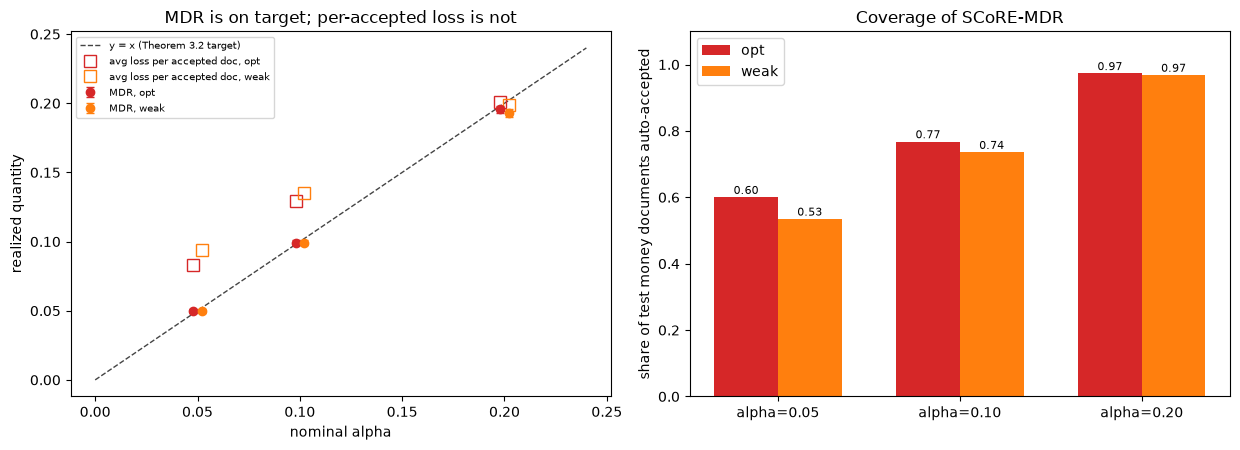

In [16]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_ax.plot([0, 0.24], [0, 0.24], "--", color=PAL3["diag"], lw=1, label="y = x (Theorem 3.2 target)")
for _k in B_SCORES:
    _mdr = [B_MDR_RES[(_k, a)][:, 0].mean() for a in B_ALPHAS]; _err = [b_mc_tol_mean(B_MDR_RES[(_k, a)][:, 0]) for a in B_ALPHAS]
    _sel = [B_MDR_RES[(_k, a)][:, 3].sum() / B_MDR_RES[(_k, a)][:, 1].sum() for a in B_ALPHAS]
    _dx = -0.002 if _k == "opt" else 0.002
    _ax.errorbar(np.array(B_ALPHAS) + _dx, _mdr, yerr=_err, fmt="o", color=B_SC_COLOR[_k], capsize=3, label=f"MDR, {_k}")
    _ax.plot(np.array(B_ALPHAS) + _dx, _sel, "s", mfc="none", color=B_SC_COLOR[_k], ms=8, label=f"avg loss per accepted doc, {_k}")
_ax.set_xlabel("nominal alpha"); _ax.set_ylabel("realized quantity"); _ax.set_title("MDR is on target; per-accepted loss is not"); _ax.legend(fontsize=7.5)
_ax = _axes[1]
_w = 0.35
for _i, _k in enumerate(B_SCORES):
    _cv = [(B_MDR_RES[(_k, a)][:, 1] / B_MDR_RES[(_k, a)][:, 2]).mean() for a in B_ALPHAS]
    _ax.bar(np.arange(3) + (_i - 0.5) * _w, _cv, _w, color=B_SC_COLOR[_k], label=_k)
    for _x, _v in enumerate(_cv):
        _ax.text(_x + (_i - 0.5) * _w, _v + 0.01, f"{_v:.2f}", ha="center", fontsize=8)
_ax.set_xticks(range(3)); _ax.set_xticklabels([f"alpha={a:.2f}" for a in B_ALPHAS]); _ax.set_ylim(0, 1.1); _ax.set_ylabel("share of test money documents auto-accepted")
_ax.set_title("Coverage of SCoRE-MDR"); _ax.legend()
plt.tight_layout(); plt.show()


### 5(b). SCoRE-SDR with e-BH: is it feasible at our batch sizes, and how conservative is it?

Notebook 1 only ran the exact SDR e-value at n=80, m=30 because it looped in pure Python over every candidate. The check S5.5 above
timed the exact e-value (own implementation, **not** the paper's Algorithm 3, whose body is not quoted in our traces) at
production scale, and it is fast enough here, so **SDR is run at full scale** (n=796 calibration, m=797 test money documents per
batch, 100 batches) *and* at a small-batch scale that is closer to a single day's queue (n=250 calibration, m=50 test, 200 batches).
Selection = e-BH at level `alpha` on the e-values (Theorem 3.3, idpfin-q4). The SDR of a batch with no selection is 0 by the
`1 v |R|` convention; we report how many batches select nothing and the SDR conditional on selecting.

Comparators (both **without** any guarantee): the **naive rule** "accept a document if its predicted risk `s(x) <= alpha`" and the
**folklore rule** (Notebook 2's baseline lifted to documents: accept iff every critical field has verbalized confidence >= 0.9 and
passes the business rules). The strict folklore rule accepts almost nothing at document level, so a **coverage-matched folklore** is also reported: rank documents by their
*lowest* raw verbalized confidence over critical fields and accept the same number of documents SCoRE accepted in that batch.


In [17]:
_vm = np.full(N_DOC, 1.0)
for _k in np.where(FA_crit)[0]:
    _vm[FA_doc[_k]] = min(_vm[FA_doc[_k]], FA_verb[_k])
B_DOC_VERBMIN = _vm                                                       # lowest raw verbalized confidence over the doc's critical fields
_fk = np.array([f["accepted"] for f in FIELDS], int)                      # Notebook 2 baseline: verbalized >= 0.9 and rule_failed == 0
B_DOC_FOLK = np.ones(N_DOC, bool)
for _k in np.where(FA_crit & (_fk == 0))[0]:
    B_DOC_FOLK[FA_doc[_k]] = False


def b_sdr_mc(n, m, reps, seed0, alphas=B_ALPHAS):
    res = {(k, a): {q: [] for q in ("sdr", "cov", "nsel", "naive_sdr", "naive_cov", "folk_sdr", "folk_cov", "match_sdr")} for k in B_SCORES for a in alphas}
    for r in range(reps):
        rng = np.random.default_rng([SEED3, seed0, r]); ix = rng.permutation(B_POOL)[:n + m]; c, t = ix[:n], ix[n:]
        Lt = DA_L[t]; order_v = np.argsort(-B_DOC_VERBMIN[t], kind="stable")
        for k, s in B_SCORES.items():
            prep = b_sdr_prep(s[c], DA_L[c], s[t])
            for a in alphas:
                o = res[(k, a)]
                sel = b_ebh_select(np.array([b_sdr_e_value(prep, s[t][j], a, n, m) for j in range(m)]), a)
                o["sdr"].append((Lt * sel).sum() / max(1, sel.sum())); o["cov"].append(sel.mean()); o["nsel"].append(sel.sum())
                nv = s[t] <= a; o["naive_sdr"].append((Lt * nv).sum() / max(1, nv.sum())); o["naive_cov"].append(nv.mean())
                fk = B_DOC_FOLK[t]; o["folk_sdr"].append((Lt * fk).sum() / max(1, fk.sum())); o["folk_cov"].append(fk.mean())
                kk = int(sel.sum()); o["match_sdr"].append(Lt[order_v[:kk]].mean() if kk > 0 else 0.0)
    return {key: {q: np.array(v) for q, v in o.items()} for key, o in res.items()}


_t0_ = b_time.time()
B_SDR_SCALES = {"full (n=796, m=797)": (796, 797, 100, 11), "small batch (n=250, m=50)": (250, 50, 200, 12)}
B_SDR_RES = {sc: b_sdr_mc(*cfg) for sc, cfg in B_SDR_SCALES.items()}
B_SDR_SECONDS = b_time.time() - _t0_
print(f"SDR Monte Carlo runtime: {B_SDR_SECONDS:.0f} s")

_rows, _rows2 = [], []
for _sc, _res in B_SDR_RES.items():
    for (_k, _a), _o in _res.items():
        _nz = _o["nsel"] > 0
        _rows.append((_sc, _k, f"{_a:.2f}", f"{_o['sdr'].mean():.4f} +/- {b_mc_tol_mean(_o['sdr']):.4f}", f"{_o['sdr'].mean() / _a:.2f}", f"{_o['cov'].mean():.3f}",
                      f"{int((~_nz).sum())} / {len(_nz)}", f"{_o['sdr'][_nz].mean() if _nz.any() else float('nan'):.4f}", f"{np.mean(_o['sdr'] > _a):.2f}"))
        _rows2.append((_sc, _k, f"{_a:.2f}", f"{_o['naive_sdr'].mean():.4f} / {_o['naive_cov'].mean():.3f} / {np.mean(_o['naive_sdr'] > _a):.2f}",
                       f"{_o['folk_sdr'].mean():.4f} / {_o['folk_cov'].mean():.3f}", f"{_o['match_sdr'].mean():.4f} / {_o['cov'].mean():.3f}"))
b_display(b_md("**SCoRE-SDR (exact e-values + e-BH, gamma = alpha)**\n\n" + b_tbl(
    ["scale", "score", "alpha", "SDR (mean +/- 3SE)", "SDR/alpha", "coverage", "batches selecting nothing", "SDR given a selection", "batches with SDR > alpha"], _rows)))
b_display(b_md("**Comparators without a guarantee** (each cell: realized avg loss among accepted / coverage / share of batches above alpha)\n\n" + b_tbl(
    ["scale", "score", "alpha", "naive: predicted risk <= alpha", "folklore, strict (avg loss / coverage)", "folklore, coverage-matched to SCoRE (avg loss / coverage)"], _rows2)))
_n = 0
for _sc, _res in B_SDR_RES.items():
    for _k in B_SCORES:
        _ok = all(_res[(_k, a)]["sdr"].mean() <= a + b_mc_tol_mean(_res[(_k, a)]["sdr"]) for a in B_ALPHAS)
        check(f"S5.{13 + _n} SDR <= alpha at every alpha ({_k} score, {_sc}, {len(_res[(_k, 0.1)]['sdr'])} batches)", _ok,
              "; ".join(f"a={a}: {_res[(_k, a)]['sdr'].mean():.4f} (tol {b_mc_tol_mean(_res[(_k, a)]['sdr']):.4f})" for a in B_ALPHAS))
        _n += 1
_full = B_SDR_RES["full (n=796, m=797)"]; _small = B_SDR_RES["small batch (n=250, m=50)"]
check("S5.17 SDR is conservative (well below alpha) for this continuous, non-binary loss, and more so at the full batch size",
      all(_full[(k, 0.10)]["sdr"].mean() < 0.5 * 0.10 for k in B_SCORES) and all(_small[(k, 0.10)]["sdr"].mean() >= _full[(k, 0.10)]["sdr"].mean() for k in B_SCORES),
      "alpha=0.10: " + "; ".join(f"{k}: full {_full[(k, 0.10)]['sdr'].mean():.4f} vs small {_small[(k, 0.10)]['sdr'].mean():.4f}" for k in B_SCORES))
print(f"strict folklore accepts {B_DOC_FOLK[B_POOL].mean():.4f} of money documents (avg loss among them {DA_L[B_POOL][B_DOC_FOLK[B_POOL]].mean():.4f}): "
      "a per-field 0.9 cutoff, demanded of ALL critical fields at once, leaves nothing to auto-accept at document level.")


SDR Monte Carlo runtime: 71 s


**SCoRE-SDR (exact e-values + e-BH, gamma = alpha)**

| scale | score | alpha | SDR (mean +/- 3SE) | SDR/alpha | coverage | batches selecting nothing | SDR given a selection | batches with SDR > alpha |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| full (n=796, m=797) | opt | 0.05 | 0.0056 +/- 0.0050 | 0.11 | 0.054 | 89 / 100 | 0.0510 | 0.07 |
| full (n=796, m=797) | opt | 0.10 | 0.0128 +/- 0.0098 | 0.13 | 0.091 | 86 / 100 | 0.0915 | 0.04 |
| full (n=796, m=797) | opt | 0.20 | 0.1370 +/- 0.0268 | 0.69 | 0.685 | 29 / 100 | 0.1930 | 0.24 |
| full (n=796, m=797) | weak | 0.05 | 0.0023 +/- 0.0040 | 0.05 | 0.008 | 97 / 100 | 0.0752 | 0.03 |
| full (n=796, m=797) | weak | 0.10 | 0.0116 +/- 0.0100 | 0.12 | 0.065 | 89 / 100 | 0.1050 | 0.06 |
| full (n=796, m=797) | weak | 0.20 | 0.1633 +/- 0.0212 | 0.82 | 0.817 | 15 / 100 | 0.1921 | 0.29 |
| small batch (n=250, m=50) | opt | 0.05 | 0.0163 +/- 0.0065 | 0.33 | 0.164 | 133 / 200 | 0.0486 | 0.15 |
| small batch (n=250, m=50) | opt | 0.10 | 0.0449 +/- 0.0124 | 0.45 | 0.311 | 108 / 200 | 0.0975 | 0.19 |
| small batch (n=250, m=50) | opt | 0.20 | 0.1722 +/- 0.0176 | 0.86 | 0.836 | 27 / 200 | 0.1990 | 0.42 |
| small batch (n=250, m=50) | weak | 0.05 | 0.0074 +/- 0.0055 | 0.15 | 0.039 | 178 / 200 | 0.0677 | 0.07 |
| small batch (n=250, m=50) | weak | 0.10 | 0.0411 +/- 0.0131 | 0.41 | 0.219 | 125 / 200 | 0.1095 | 0.23 |
| small batch (n=250, m=50) | weak | 0.20 | 0.1585 +/- 0.0193 | 0.79 | 0.770 | 39 / 200 | 0.1969 | 0.38 |

**Comparators without a guarantee** (each cell: realized avg loss among accepted / coverage / share of batches above alpha)

| scale | score | alpha | naive: predicted risk <= alpha | folklore, strict (avg loss / coverage) | folklore, coverage-matched to SCoRE (avg loss / coverage) |
| --- | --- | --- | --- | --- | --- |
| full (n=796, m=797) | opt | 0.05 | 0.0257 / 0.328 / 0.00 | 0.0000 / 0.003 | 0.0147 / 0.054 |
| full (n=796, m=797) | opt | 0.10 | 0.0405 / 0.433 / 0.00 | 0.0000 / 0.003 | 0.0197 / 0.091 |
| full (n=796, m=797) | opt | 0.20 | 0.0744 / 0.573 / 0.00 | 0.0000 / 0.003 | 0.1434 / 0.685 |
| full (n=796, m=797) | weak | 0.05 | 0.0510 / 0.205 / 0.49 | 0.0000 / 0.003 | 0.0030 / 0.008 |
| full (n=796, m=797) | weak | 0.10 | 0.0816 / 0.417 / 0.03 | 0.0000 / 0.003 | 0.0155 / 0.065 |
| full (n=796, m=797) | weak | 0.20 | 0.1108 / 0.632 / 0.00 | 0.0000 / 0.003 | 0.1703 / 0.817 |
| small batch (n=250, m=50) | opt | 0.05 | 0.0254 / 0.328 / 0.18 | 0.0000 / 0.003 | 0.0411 / 0.164 |
| small batch (n=250, m=50) | opt | 0.10 | 0.0387 / 0.433 / 0.04 | 0.0000 / 0.003 | 0.0673 / 0.311 |
| small batch (n=250, m=50) | opt | 0.20 | 0.0725 / 0.570 / 0.00 | 0.0000 / 0.003 | 0.1786 / 0.836 |
| small batch (n=250, m=50) | weak | 0.05 | 0.0503 / 0.205 / 0.40 | 0.0000 / 0.003 | 0.0127 / 0.039 |
| small batch (n=250, m=50) | weak | 0.10 | 0.0821 / 0.423 / 0.34 | 0.0000 / 0.003 | 0.0546 / 0.219 |
| small batch (n=250, m=50) | weak | 0.20 | 0.1136 / 0.640 / 0.03 | 0.0000 / 0.003 | 0.1629 / 0.770 |

[PASS] S5.13 SDR <= alpha at every alpha (opt score, full (n=796, m=797), 100 batches) -- a=0.05: 0.0056 (tol 0.0050); a=0.1: 0.0128 (tol 0.0098); a=0.2: 0.1370 (tol 0.0268)
[PASS] S5.14 SDR <= alpha at every alpha (weak score, full (n=796, m=797), 100 batches) -- a=0.05: 0.0023 (tol 0.0040); a=0.1: 0.0116 (tol 0.0100); a=0.2: 0.1633 (tol 0.0212)
[PASS] S5.15 SDR <= alpha at every alpha (opt score, small batch (n=250, m=50), 200 batches) -- a=0.05: 0.0163 (tol 0.0065); a=0.1: 0.0449 (tol 0.0124); a=0.2: 0.1722 (tol 0.0176)
[PASS] S5.16 SDR <= alpha at every alpha (weak score, small batch (n=250, m=50), 200 batches) -- a=0.05: 0.0074 (tol 0.0055); a=0.1: 0.0411 (tol 0.0131); a=0.2: 0.1585 (tol 0.0193)
[PASS] S5.17 SDR is conservative (well below alpha) for this continuous, non-binary loss, and more so at the full batch size -- alpha=0.10: opt: full 0.0128 vs small 0.0449; weak: full 0.0116 vs small 0.0411
strict folklore accepts 0.0031 of money documents (avg loss among them 0.0000): a 

**How to read this chart.** Left: realized SDR (average loss among accepted documents, mean over batches) against the nominal
`alpha`, dashed `y = x`. SCoRE-SDR (filled markers, two batch scales) stays below the line, often far below: with a continuous loss the
infimum over the unknown test loss "may be slightly conservative" (quoted in idpfin-q6, section 8.3) and at m=797 the e-BH cut-off
`m/(alpha k)` is demanding, so at `alpha = 0.05` most full-size batches select **nothing**. The naive rule (hollow purple) is also
below the line here, **but only because the predicted-risk model happens to be calibrated on data that look like the calibration data**; it
carries no guarantee and Section 7 shows what it does after the month-7 shift. Right: what each rule accepts. The naive rule
accepts more than SCoRE-SDR at every `alpha`; SCoRE's price for a guarantee that does not depend on the risk model being calibrated is
this coverage gap, and it is smaller for small batches.


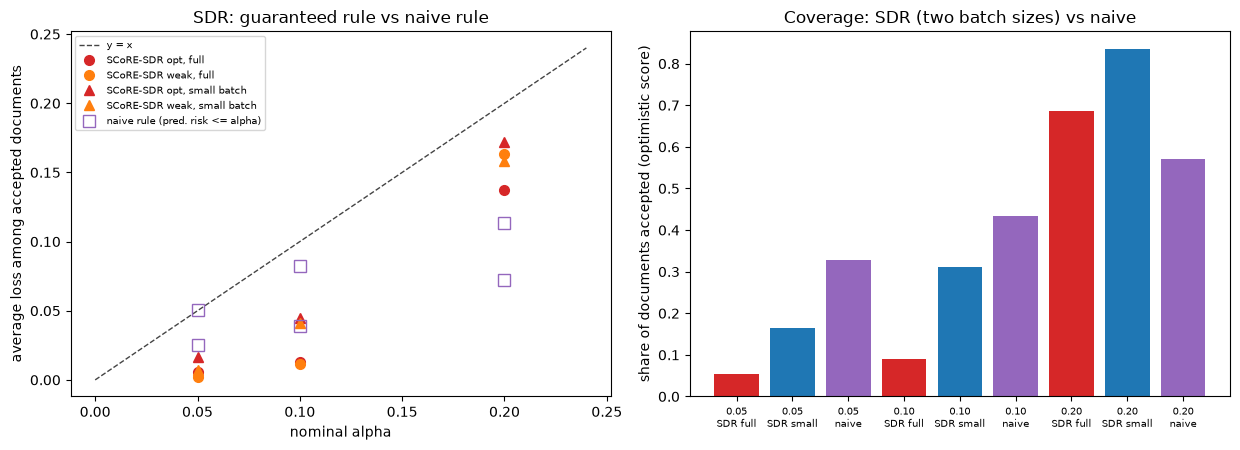

In [18]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_ax.plot([0, 0.24], [0, 0.24], "--", color=PAL3["diag"], lw=1, label="y = x")
_mk = {"full (n=796, m=797)": "o", "small batch (n=250, m=50)": "^"}
for _sc, _res in B_SDR_RES.items():
    for _k in B_SCORES:
        _ax.plot(B_ALPHAS, [_res[(_k, a)]["sdr"].mean() for a in B_ALPHAS], _mk[_sc], color=B_SC_COLOR[_k], ms=7, label=f"SCoRE-SDR {_k}, {_sc.split(' (')[0]}")
for _k in B_SCORES:
    _ax.plot(B_ALPHAS, [B_SDR_RES["small batch (n=250, m=50)"][(_k, a)]["naive_sdr"].mean() for a in B_ALPHAS], "s", mfc="none", color=PAL3["b_naive"], ms=8,
             label="naive rule (pred. risk <= alpha)" if _k == "opt" else None)
_ax.set_xlabel("nominal alpha"); _ax.set_ylabel("average loss among accepted documents"); _ax.set_title("SDR: guaranteed rule vs naive rule"); _ax.legend(fontsize=7)
_ax = _axes[1]
_labels, _vals, _cols = [], [], []
for _a in B_ALPHAS:
    for _nm, _q, _res in (("SDR full", "cov", B_SDR_RES["full (n=796, m=797)"]), ("SDR small", "cov", B_SDR_RES["small batch (n=250, m=50)"]), ("naive", "naive_cov", B_SDR_RES["small batch (n=250, m=50)"])):
        _labels.append(f"{_a:.2f}\n{_nm}"); _vals.append(_res[("opt", _a)][_q].mean())
        _cols.append(PAL3["b_naive"] if _nm == "naive" else (PAL3["hgb"] if _nm == "SDR full" else PAL3["lr"]))
_ax.bar(range(len(_vals)), _vals, color=_cols)
_ax.set_xticks(range(len(_vals))); _ax.set_xticklabels(_labels, fontsize=7); _ax.set_ylabel("share of documents accepted (optimistic score)"); _ax.set_title("Coverage: SDR (two batch sizes) vs naive")
plt.tight_layout(); plt.show()


### 5(c). Amount-weighted versus count-weighted loss: same documents, different accept sets

A count-weighted document loss treats a wrong cent and a wrong million as one wrong field: `L_cnt` = share of the document's money
fields that are wrong. The amount-weighted `L_doc` counts how much of the document's monetary *value* is wrong (Section 2). To isolate the **loss**, each rule uses its own
train-fitted risk model (same features, same learner) and its own SCoRE-MDR calibration at `alpha = 0.10`, averaged over 40 fixed resplits.
"Value at risk" below is `sum(L_doc * V) / sum(V)` over the accepted documents, with `V = max(sum |true money amounts|, 1)`: the
share of the accepted documents' monetary value that is wrong, pooled across documents (derived here; bounded in [0,1] because `L_doc` already clips at 1).


In [19]:
B_ERR_AMT, B_VAL_AMT, B_NMONEY, B_NWRONG_MONEY = np.zeros(N_DOC), np.zeros(N_DOC), np.zeros(N_DOC), np.zeros(N_DOC)


def b_num(x):
    try:
        return None if x is None else float(x)
    except (TypeError, ValueError):
        return None


for _k, _f in enumerate(FIELDS):
    if _f["field"] in MONEY_FIELDS[_f["doc_type"]]:
        _d = FA_doc[_k]; B_NMONEY[_d] += 1; B_NWRONG_MONEY[_d] += 1 - FA_correct[_k]
        _tr, _pr = b_num(_f["truth"]), b_num(_f["predicted"])
        if _tr is None:
            B_ERR_AMT[_d] += abs(_pr) if _pr is not None else 0.0
        else:
            B_VAL_AMT[_d] += abs(_tr); B_ERR_AMT[_d] += abs(_pr - _tr) if _pr is not None else abs(_tr)
B_V = np.maximum(B_VAL_AMT, 1.0)
B_L_CNT = np.where(DA_has_money, B_NWRONG_MONEY / np.maximum(B_NMONEY, 1), np.nan)
check("S5.18 recomputed amount loss equals the prelude's DA_L on every money document",
      np.allclose(np.minimum(1.0, B_ERR_AMT / B_V)[DA_has_money], DA_L[DA_has_money]), f"{int(DA_has_money.sum())} documents")

_trm = np.where((DOC_SPLIT == "train") & DA_has_money)[0]
_mk = lambda: HistGradientBoostingRegressor(max_depth=3, max_iter=120, learning_rate=0.06, min_samples_leaf=25, l2_regularization=1.0, random_state=SEED3)
B_RISK_CNT = {"opt": np.clip(_mk().fit(X_doc_oof[_trm], B_L_CNT[_trm]).predict(X_doc), 0, 1),         # same features/learner as DOC_MODEL_L, fit on train only
              "weak": np.clip(_mk().fit(X_doc_weak[_trm], B_L_CNT[_trm]).predict(X_doc_weak), 0, 1)}
B_CMP_ALPHA = 0.10


def b_cmp_split(sd, k):
    cal, tst = resplit(sd); cal, tst = cal[DA_has_money[cal]], tst[DA_has_money[tst]]
    acc_a = b_mdr_e_values(B_SCORES[k][cal], DA_L[cal], B_SCORES[k][tst], B_CMP_ALPHA) >= 1 / B_CMP_ALPHA
    acc_c = b_mdr_e_values(B_RISK_CNT[k][cal], B_L_CNT[cal], B_RISK_CNT[k][tst], B_CMP_ALPHA) >= 1 / B_CMP_ALPHA
    wrong_val = DA_L[tst] * B_V[tst]

    def st(acc):
        n = max(1, acc.sum())
        return [acc.mean(), DA_L[tst][acc].sum() / n, B_L_CNT[tst][acc].sum() / n, (B_NWRONG_MONEY[tst][acc] > 0).sum() / n,
                wrong_val[acc].sum() / max(B_V[tst][acc].sum(), 1e-9), wrong_val[acc].sum() / wrong_val.sum(), np.mean(DA_L[tst] * acc), np.mean(B_L_CNT[tst] * acc)]
    return st(acc_a) + st(acc_c) + [(acc_a & acc_c).sum() / max(1, (acc_a | acc_c).sum()), (acc_a & ~acc_c).mean(), (~acc_a & acc_c).mean()]


B_CMP = {k: np.array([b_cmp_split(sd, k) for sd in range(40)]) for k in B_SCORES}
_rows = []
for _k in B_SCORES:
    _m_ = B_CMP[_k].mean(0)
    for _nm, _o in (("amount-weighted L_doc (SCoRE-MDR)", 0), ("count-weighted L_cnt (SCoRE-MDR)", 8)):
        _rows.append((_k, _nm, f"{_m_[_o]:.3f}", f"{_m_[_o + 1]:.3f}", f"{_m_[_o + 2]:.3f}", f"{_m_[_o + 3]:.3f}", f"{_m_[_o + 4]:.4f}", f"{_m_[_o + 5]:.3f}"))
b_display(b_md(b_tbl(["score", "rule", "coverage", "avg L_doc among accepted", "avg L_cnt among accepted", "accepted docs with >=1 wrong money field",
                      "value at risk in accepted docs", "share of all wrong value that sits in accepted docs"], _rows)))
_rows = [(_k, f"{B_CMP[_k].mean(0)[16]:.3f}", f"{B_CMP[_k].mean(0)[17]:.3f}", f"{B_CMP[_k].mean(0)[18]:.3f}") for _k in B_SCORES]
b_display(b_md(b_tbl(["score", "Jaccard overlap of the two accepted sets", "share of docs accepted ONLY by the amount rule", "share of docs accepted ONLY by the count rule"], _rows)))
for _i, _k in enumerate(B_SCORES):
    _x = B_CMP[_k]
    check(f"S5.{19 + 3 * _i} the two losses select different documents ({_k} score)", _x[:, 16].mean() < 1 and _x[:, 17].mean() > 0 and _x[:, 18].mean() > 0,
          f"Jaccard {_x[:, 16].mean():.3f}; only-amount {_x[:, 17].mean():.3f}, only-count {_x[:, 18].mean():.3f} of test money docs")
    check(f"S5.{20 + 3 * _i} each rule meets its own MDR budget alpha={B_CMP_ALPHA} over 40 resplits ({_k} score)",
          _x[:, 6].mean() <= B_CMP_ALPHA + b_mc_tol_mean(_x[:, 6]) and _x[:, 15].mean() <= B_CMP_ALPHA + b_mc_tol_mean(_x[:, 15]),
          f"amount MDR {_x[:, 6].mean():.4f} (tol {b_mc_tol_mean(_x[:, 6]):.4f}); count MDR {_x[:, 15].mean():.4f} (tol {b_mc_tol_mean(_x[:, 15]):.4f})")
    check(f"S5.{21 + 3 * _i} the amount rule tolerates documents that contain a wrong money field ({_k} score)", _x[:, 3].mean() > 0,
          f"{_x[:, 3].mean():.3f} of amount-accepted docs have >=1 wrong money field vs {_x[:, 11].mean():.3f} for the count rule")


[PASS] S5.18 recomputed amount loss equals the prelude's DA_L on every money document -- 2657 documents


| score | rule | coverage | avg L_doc among accepted | avg L_cnt among accepted | accepted docs with >=1 wrong money field | value at risk in accepted docs | share of all wrong value that sits in accepted docs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| opt | amount-weighted L_doc (SCoRE-MDR) | 0.769 | 0.128 | 0.165 | 0.348 | 0.1672 | 0.452 |
| opt | count-weighted L_cnt (SCoRE-MDR) | 0.719 | 0.111 | 0.141 | 0.310 | 0.1557 | 0.389 |
| weak | amount-weighted L_doc (SCoRE-MDR) | 0.734 | 0.134 | 0.171 | 0.330 | 0.1810 | 0.470 |
| weak | count-weighted L_cnt (SCoRE-MDR) | 0.658 | 0.115 | 0.155 | 0.272 | 0.1646 | 0.375 |

| score | Jaccard overlap of the two accepted sets | share of docs accepted ONLY by the amount rule | share of docs accepted ONLY by the count rule |
| --- | --- | --- | --- |
| opt | 0.899 | 0.065 | 0.014 |
| weak | 0.862 | 0.089 | 0.013 |

[PASS] S5.19 the two losses select different documents (opt score) -- Jaccard 0.899; only-amount 0.065, only-count 0.014 of test money docs
[PASS] S5.20 each rule meets its own MDR budget alpha=0.1 over 40 resplits (opt score) -- amount MDR 0.0987 (tol 0.0051); count MDR 0.1018 (tol 0.0052)
[PASS] S5.21 the amount rule tolerates documents that contain a wrong money field (opt score) -- 0.348 of amount-accepted docs have >=1 wrong money field vs 0.310 for the count rule
[PASS] S5.22 the two losses select different documents (weak score) -- Jaccard 0.862; only-amount 0.089, only-count 0.013 of test money docs
[PASS] S5.23 each rule meets its own MDR budget alpha=0.1 over 40 resplits (weak score) -- amount MDR 0.0989 (tol 0.0052); count MDR 0.1021 (tol 0.0047)
[PASS] S5.24 the amount rule tolerates documents that contain a wrong money field (weak score) -- 0.330 of amount-accepted docs have >=1 wrong money field vs 0.272 for the count rule


**How to read this chart.** Left: for each score, the two accepted sets as shares of all test money documents: accepted by both
(grey), only under the amount-weighted loss (red) and only under the count-weighted loss (blue). Non-zero red and blue slices are the point: the two
losses do not merely rescale the same ranking. Right: among the documents each rule accepts, the share of monetary value that is wrong (value at risk). The
accepted sets differ by roughly a tenth of the documents and the effect on value at risk is modest for the optimistic score;
do not read more into the gap than the table supports, since each bar is a mean of 40 resplits that reuse the same documents.


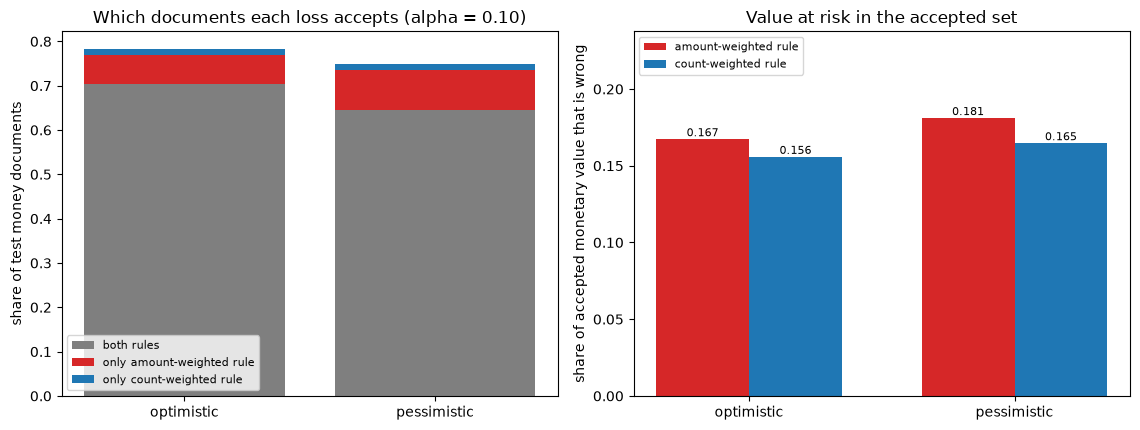

In [20]:
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
_ax = _axes[0]
for _i, _k in enumerate(B_SCORES):
    _x = B_CMP[_k].mean(0); _both = _x[0] - _x[17]; _oa, _oc = _x[17], _x[18]
    _ax.bar(_i, _both, color=PAL3["raw"], label="both rules" if _i == 0 else None)
    _ax.bar(_i, _oa, bottom=_both, color=PAL3["hgb"], label="only amount-weighted rule" if _i == 0 else None)
    _ax.bar(_i, _oc, bottom=_both + _oa, color=PAL3["lr"], label="only count-weighted rule" if _i == 0 else None)
_ax.set_xticks([0, 1]); _ax.set_xticklabels(["optimistic", "pessimistic"]); _ax.set_ylabel("share of test money documents"); _ax.set_title("Which documents each loss accepts (alpha = 0.10)"); _ax.legend(fontsize=8)
_ax = _axes[1]
_w = 0.35
for _i, (_nm, _o, _c) in enumerate((("amount-weighted rule", 4, PAL3["hgb"]), ("count-weighted rule", 12, PAL3["lr"]))):
    _v = [B_CMP[k].mean(0)[_o] for k in B_SCORES]
    _ax.bar(np.arange(2) + (_i - 0.5) * _w, _v, _w, color=_c, label=_nm)
    for _x_, _vv in enumerate(_v):
        _ax.text(_x_ + (_i - 0.5) * _w, _vv + 0.002, f"{_vv:.3f}", ha="center", fontsize=8)
_ax.set_xticks([0, 1]); _ax.set_xticklabels(["optimistic", "pessimistic"]); _ax.set_ylabel("share of accepted monetary value that is wrong"); _ax.set_title("Value at risk in the accepted set"); _ax.set_ylim(0, _ax.get_ylim()[1] * 1.25); _ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()


### 5(d). Covariate shift: what SCoRE offers, and why it is **not** implemented here

SCoRE's shift extension is stated as (idpfin-q5): "**Assumption 6.1.** The labeled data follow `(X_i, Y_i) ~ P` while the test data follow
`(X_{n+j}, Y_{n+j}) ~ Q`, and the two distributions obey `dQ/dP(x, y) = w(x)` for a known or estimable weight function". With **known**
`w` the weighted e-values (Equations 6.1 and 6.2) give "exact finite-sample MDR and SDR control" under `Q`; with **estimated** `w` the
guarantee is only asymptotic and needs `L_2(P_X)`-consistency of the estimated weights (Theorems 6.4 and 6.5, idpfin-q5, q12).

Here the density ratio `w(x)` between the calibration batch and the month-7 batch is **unknown**, and the month-7 shift is not obviously
covariate-only: new vendor templates and heavier OCR noise change how *errors* arise given the same document, i.e. `P(Y | X)` moves too. None
of the three sources says how to certify under such concept drift without new labels ("None of the three sources state how to
perform real-time, online re-calibration or re-certification under unobserved concept drift", idpfin-q12). So **weighted e-values are
not built**; Section 7 instead checks empirically what a frozen configuration does on the shift split and how many freshly labelled
documents restore validity. Among the engineering choices left open: estimating `w(x)` (for example by a domain classifier on the score and template features) and running the weighted e-values.


## 6. The validity ladder on our data, per document type (P3)

**Claim.** Not every "held at alpha" is the same promise. Gurram's ladder separates *expectation* control (tiers 1-2, which sit at the
boundary and exceed `alpha` in a large share of splits) from *probabilistic* certificates (tiers 3-4). We run all rungs on our
fields with the train-fitted scores, `alpha = 0.10`, `delta = 0.10` (headline) and `alpha = 0.20`, over 40 fixed document-level 50/50
resplits (`resplit(seed)`, seeds 0..39; fields of a document never straddle calibration and test).

**Quoted (idpfin-q8).** Table 4 caption: "Vocabulary: tiers 1-2 control expected selective risk; only tiers 3-4 certify." The tier-3 mechanism: "For each
taxonomy group g and candidate threshold t, we test H0: selective risk of t in g > alpha with an exact binomial tail p-value ... half the budget
delta to Holm step-down ..., half to a fixed-sequence pass from the most conservative candidate (the 'mix' rule ...). Candidates are 15 geometric
acceptance-fraction quantiles (1%-100%) of the group's calibration scores, snapped to the nearest distinct-value boundary". Guarantee: "with
probability >= 1 - delta over the calibration draw, the true selective risk among accepted fields in that group is <= alpha, if within-group
accepted-field errors are iid." Tier 4: "the mean per-document error rate among accepting documents is <= alpha (finite-sample bound, documents iid) ...
it bounds a macro per-document functional, not field-level (micro) selective risk." Cluster-corrected `ltt.neff` "replaces n_t by n_t / d_eff ... approximate
(the deff is estimated), and uniformly more conservative". Measured design effects in the paper: "d_eff ranges from 1.84 to 2.45" (idpfin-q11).

**Taxonomy discipline (idpfin-q8, section 5.3).** "Choosing the conditioning taxonomy among K candidates to maximize coverage is a selection
problem." Ours is **document type**, pre-specified before any result was looked at, and it is never changed to raise coverage. Budgets are per group
(`delta` for each of the four groups: four separate statements).

| tier | procedure (ours) | guarantee form | unit | certificate? |
| --- | --- | --- | --- | --- |
| 1 | split add-one, pooled | `E[selective risk] <= alpha` | field | no (expectation) |
| 2 | add-one x document type | `E[selective risk] <= alpha` (per group) | field | no (expectation) |
| 3 | Mondrian LTT, exact binomial tails, 15 candidates, delta/2 Holm + delta/2 fixed-sequence, per document type (and a pooled single-group variant) | `P(true group risk > alpha) <= delta` if within-group accepted-field errors are iid | field | **yes (PAC)** |
| 3b | as 3 with `n_t / d_eff` (`d_eff` estimated on the calibration fields of each group) | same, approximate | field | yes (PAC, approximate, more conservative) |
| 4 | doc-Hoeffding over accepting documents, per document type | `P(macro per-document risk > alpha) <= delta`, documents iid | document | **yes (PAC)**, macro functional |

**Conventions.** Every field is a unit (all 28,032 fields, error = 1 - correct); scores are "higher = more trusted": optimistic
`FA_p_hgb`, pessimistic `FA_p_weak`, and the raw verbalized confidence `FA_verb` (the frozen, uninformed black-box used for the two-regime
demonstration). "Zero-coverage splits contribute risk 0" (Gurram section 3.5, quoted in the cited source text of idpfin-q10); we follow it, **count
those splits, and also report risk conditional on non-zero coverage**, the "report both" of Table 4's footnote (idpfin-q8: "0.020 is the
zero-filled mean ... Report both."). Violation = fraction of splits whose realized test risk exceeds `alpha`. The 40 resplits share documents, so every
spread below is a split-stability statement, not population inference (Gurram's own caveat, idpfin-q9: "Inference is in-corpus").


In [21]:
# ---- Mondrian-LTT machinery: COPIED from build_nb1.py (geometric_candidates, holm_reject, fixed_sequence_reject_conservative_first,
#      mondrian_ltt_certify, estimate_design_effect, mondrian_ltt_doc_hoeffding), renamed with b_ and vectorised where it is pure bookkeeping ----
def b_geometric_candidates(scores, n_candidates=15):
    n = len(scores); fracs = np.geomspace(0.01, 1.0, n_candidates)
    ks = np.clip(np.round(fracs * n).astype(int), 1, n)
    return np.unique(np.sort(scores)[::-1][ks - 1])[::-1]              # distinct values, most conservative (highest) first


def b_holm_reject(pvals, budget):
    m = len(pvals); order = np.argsort(pvals); sp = pvals[order]; th = budget / (m - np.arange(m)); rs = np.zeros(m, bool)
    for i in range(m):
        if sp[i] <= th[i]:
            rs[i] = True
        else:
            break
    r = np.zeros(m, bool); r[order] = rs; return r


def b_fixed_seq(pvals, budget):
    r = np.zeros(len(pvals), bool)
    for i, p in enumerate(pvals):
        if p <= budget:
            r[i] = True
        else:
            break
    return r


def b_deff(doc_ids, err):
    """ANOVA plug-in design effect d_eff = 1 + (k_bar - 1) * rho_hat (derived here in Notebook 1; the paper does not give the formula)."""
    docs, inv, n_d = np.unique(doc_ids, return_inverse=True, return_counts=True); D, N = len(docs), len(err)
    if D < 2 or N <= D:
        return 1.0
    p_d = np.bincount(inv, weights=err, minlength=D) / n_d; p_bar = err.mean()
    MSB = np.sum(n_d * (p_d - p_bar) ** 2) / (D - 1); MSW = np.sum((err - p_d[inv]) ** 2) / max(1, N - D)
    k0 = (N - np.sum(n_d ** 2) / N) / (D - 1)
    rho = (1.0 if MSB > 1e-9 else 0.0) if MSW <= 1e-9 else (MSB - MSW) / (MSB + (k0 - 1) * MSW)
    return max(1.0, 1 + (N / D - 1) * float(np.clip(rho, 0, 1)))


def b_ltt_certify(scores, err, alpha, delta, deff=None):
    """Tier 3 (and 3b when `deff` > 1): returns the certified threshold (accept score >= tau), inf = review everything."""
    th = b_geometric_candidates(scores)
    n_ts = np.array([(scores >= t).sum() for t in th], float); k_ts = np.array([err[scores >= t].sum() for t in th], float)
    d = deff if (deff is not None and deff > 1.0) else 1.0
    n_int = np.maximum(1, np.floor(n_ts / d).astype(int)); k_int = np.minimum(n_int, np.round(k_ts / d).astype(int))
    p = b_binom.cdf(k_int, n_int, alpha)                                   # exact binomial tail Pr[Bin(n_t, alpha) <= k_t]
    cert = b_holm_reject(p, delta / 2) | b_fixed_seq(p, delta / 2)
    if not cert.any():
        return np.inf
    ci = np.nonzero(cert)[0]
    return th[ci[np.argmax(n_ts[ci])]]                                      # certified candidate with the largest calibration acceptance


def b_doc_hoeffding(doc_ids, scores, err, alpha, delta):
    """Tier 4: per-document loss = within-document error rate among accepted fields; Hoeffding p-value over accepting documents."""
    docs, inv = np.unique(doc_ids, return_inverse=True); D = len(docs)
    th = b_geometric_candidates(scores); p = np.ones(len(th)); n_ts = np.zeros(len(th))
    for i, t in enumerate(th):
        m = scores >= t; n_ts[i] = m.sum()
        if not m.any():
            continue
        cnt = np.bincount(inv[m], minlength=D); s = np.bincount(inv[m], weights=err[m], minlength=D); has = cnt > 0
        gap = max(0.0, alpha - (s[has] / cnt[has]).mean()); p[i] = np.exp(-2 * has.sum() * gap ** 2)
    cert = b_holm_reject(p, delta / 2) | b_fixed_seq(p, delta / 2)
    if not cert.any():
        return np.inf
    ci = np.nonzero(cert)[0]
    return th[ci[np.argmax(n_ts[ci])]]


B_ERR = (1 - FA_correct).astype(float)                    # field error indicator
B_GRP = DOC_TYPE_IDX[FA_doc]                              # pre-specified taxonomy: document type
B_FSPLIT = DOC_SPLIT[FA_doc]
B_TIERS = ["t1", "t2", "t3p", "t3", "t3b", "t4"]
B_TIER_LABEL = {"t1": "1 add-one, pooled", "t2": "2 add-one x type", "t3p": "3 LTT, pooled (1 group)", "t3": "3 LTT x type", "t3b": "3b LTT neff x type", "t4": "4 doc-Hoeffding x type"}
B_TIER_SHORT = {"t1": "T1\npooled", "t2": "T2\nx type", "t3p": "T3\npooled", "t3": "T3\nx type", "t3b": "T3b\nneff", "t4": "T4\ndoc"}
B_TIER_FORM = {"t1": "E[risk] <= alpha (expectation)", "t2": "E[risk] <= alpha (expectation)", "t3p": "PAC, P(risk > alpha) <= delta",
               "t3": "PAC per group, P(group risk > alpha) <= delta", "t3b": "PAC per group, approximate (n/d_eff)", "t4": "PAC on macro per-doc risk, docs iid"}
B_SCORE_FIELD = {"hgb": FA_p_hgb, "weak": FA_p_weak, "verb": FA_verb}
B_SCORE_NAME = {"hgb": "optimistic (learned fusion, FA_p_hgb)", "weak": "pessimistic (weak signals, FA_p_weak)", "verb": "raw verbalized confidence (FA_verb)"}


def b_fit_thresholds(score, mask, alpha, delta):
    """All rungs fit on the fields selected by `mask` (calibration fields). Returns {tier: tau (scalar or array(4))}, and d_eff per group."""
    sc, er, gr, dc = score[mask], B_ERR[mask], B_GRP[mask], FA_doc[mask]
    G = range(4); deffs = np.array([b_deff(dc[gr == g], er[gr == g]) for g in G])
    return {"t1": add_one_threshold(sc, er, alpha),
            "t2": np.array([add_one_threshold(sc[gr == g], er[gr == g], alpha) for g in G]),
            "t3p": b_ltt_certify(sc, er, alpha, delta),
            "t3": np.array([b_ltt_certify(sc[gr == g], er[gr == g], alpha, delta) for g in G]),
            "t3b": np.array([b_ltt_certify(sc[gr == g], er[gr == g], alpha, delta, deff=deffs[g]) for g in G]),
            "t4": np.array([b_doc_hoeffding(dc[gr == g], sc[gr == g], er[gr == g], alpha, delta) for g in G])}, deffs


def b_accept(score, mask, tau):
    t = np.asarray(tau, float)
    return score[mask] >= (t[B_GRP[mask]] if t.ndim else t)


B_MASKS = {}


def b_split_masks(seed):
    if seed not in B_MASKS:
        cal, tst = resplit(seed); dm = np.zeros(N_DOC, int); dm[cal] = 1; dm[tst] = 2
        B_MASKS[seed] = (dm[FA_doc] == 1, dm[FA_doc] == 2)
    return B_MASKS[seed]


def b_metrics(acc, mask, alpha):
    """[coverage, micro risk (0 if nothing accepted), n accepted, macro per-doc risk, micro violation, macro violation,
    #groups violating, #groups accepting, risk among accepted CRITICAL fields]"""
    te, tg, td, tc = B_ERR[mask], B_GRP[mask], FA_doc[mask], FA_crit[mask]
    n = int(acc.sum()); risk = te[acc].mean() if n else 0.0
    if n:
        _, inv = np.unique(td[acc], return_inverse=True); macro = float((np.bincount(inv, weights=te[acc]) / np.bincount(inv)).mean())
    else:
        macro = 0.0
    gv = gn = 0
    for g in range(4):
        a = acc & (tg == g)
        if a.any():
            gn += 1; gv += int(te[a].mean() > alpha)
    crit = acc & tc
    return [n / len(acc), risk, n, macro, float(risk > alpha), float(macro > alpha), gv, gn, te[crit].mean() if crit.any() else 0.0]


def b_ladder(score_key, alpha, delta=0.10, n_splits=40):
    score = B_SCORE_FIELD[score_key]; res = {t: [] for t in B_TIERS}; deffs = []
    for sd in range(n_splits):
        cm, tm = b_split_masks(sd)
        assert len(set(FA_doc[cm]) & set(FA_doc[tm])) == 0
        th, d = b_fit_thresholds(score, cm, alpha, delta); deffs.append(d)
        for t in B_TIERS:
            res[t].append(b_metrics(b_accept(score, tm, th[t]), tm, alpha))
    return {t: np.array(v, float) for t, v in res.items()}, np.array(deffs)


_t0_ = b_time.time()
B_LADDER, B_DEFF = {}, {}
for _k in ("hgb", "weak", "verb"):
    for _a in (0.10, 0.20):
        B_LADDER[(_k, _a)], B_DEFF[(_k, _a)] = b_ladder(_k, _a)
print(f"ladder runtime {b_time.time() - _t0_:.0f} s (3 scores x 2 alphas x 40 splits x 6 rungs)")
check("S6.1 in all 40 splits calibration and test fields come from disjoint documents (asserted inside b_ladder)", True, "document-level splits")
print("estimated design effect d_eff per document type (calibration half, mean over 40 splits; errors of ALL fields): " +
      ", ".join(f"{DOC_TYPES[g]} {B_DEFF[('hgb', 0.10)][:, g].mean():.2f}" for g in range(4)))


ladder runtime 5 s (3 scores x 2 alphas x 40 splits x 6 rungs)
[PASS] S6.1 in all 40 splits calibration and test fields come from disjoint documents (asserted inside b_ladder) -- document-level splits
estimated design effect d_eff per document type (calibration half, mean over 40 splits; errors of ALL fields): invoice 3.16, bank_statement 2.69, kyc_form 2.44, compliance_report 2.78


In [22]:
def b_summ(res, tier):
    r = res[tier]; nz = r[:, 2] > 0
    return dict(cov=r[:, 0].mean(), cov_sd=r[:, 0].std(ddof=1), risk=r[:, 1].mean(), risk_nz=(r[nz, 1].mean() if nz.any() else float("nan")), viol=r[:, 4].mean(),
                zero=int((~nz).sum()), macro=r[:, 3].mean(), macro_viol=r[:, 5].mean(), gviol=(r[:, 6].sum() / r[:, 7].sum() if r[:, 7].sum() > 0 else float("nan")),
                gpairs=int(r[:, 7].sum()), crit_risk=(r[nz, 8].mean() if nz.any() else float("nan")))


for _a in (0.10, 0.20):
    for _k in ("hgb", "weak"):
        _rows = []
        for _t in B_TIERS:
            _s = b_summ(B_LADDER[(_k, _a)], _t)
            _rows.append((B_TIER_LABEL[_t], B_TIER_FORM[_t], f"{_s['cov']:.3f} +/- {_s['cov_sd']:.3f}", f"{_s['risk']:.3f}", "n/a" if np.isnan(_s['risk_nz']) else f"{_s['risk_nz']:.3f}",
                          f"{_s['viol']:.3f}", f"{_s['zero']}/40", "n/a" if np.isnan(_s['gviol']) or _t in ("t1", "t3p") else f"{_s['gviol']:.3f} ({_s['gpairs']})",
                          f"{_s['macro']:.3f}"))
        b_display(b_md(f"**alpha = {_a:.2f}, delta = 0.10, {B_SCORE_NAME[_k]}** (mean over 40 resplits; risk = realized micro selective risk on test fields, zero-filled)\n\n" + b_tbl(
            ["tier", "guarantee form", "coverage (mean +/- sd)", "achieved risk (zero-filled)", "risk given coverage > 0", "share of splits with risk > alpha",
             "zero-coverage splits", "share of (split, group) pairs with group risk > alpha (n pairs)", "macro per-doc risk"], _rows)))

# ---- self-checks ----
_n = 2
for _k in ("hgb", "weak"):
    for _a in (0.10, 0.20):
        _r = B_LADDER[(_k, _a)]["t1"][:, 1]
        check(f"S6.{_n} tier 1 add-one meets its EXPECTATION target ({_k}, alpha={_a:.2f})", _r.mean() <= _a + b_mc_tol_mean(_r), f"mean risk {_r.mean():.4f} <= {_a} + 3SE {b_mc_tol_mean(_r):.4f}"); _n += 1
check(f"S6.{_n} ...but tier 1 is NOT a certificate: it exceeds alpha in more than delta of the splits (alpha=0.10, both scores)",
      all(B_LADDER[(k, 0.10)]["t1"][:, 4].mean() > 0.10 for k in ("hgb", "weak")), "; ".join(f"{k}: {B_LADDER[(k, 0.10)]['t1'][:, 4].mean():.3f} of splits" for k in ("hgb", "weak"))); _n += 1
for _t in ("t3p", "t3", "t3b"):
    _ok, _det = True, []
    for _k in ("hgb", "weak", "verb"):
        for _a in (0.10, 0.20):
            _v = B_LADDER[(_k, _a)][_t][:, 4].mean(); _ok &= _v <= 0.10 + b_cp_tol(_v, 40); _det.append(f"{_k}/{_a}: {_v:.3f}")
    check(f"S6.{_n} tier {_t[1:]} (PAC) violation fraction <= delta = 0.10 + Clopper-Pearson tolerance (3 scores x 2 alphas x 40 splits)", _ok, "; ".join(_det)); _n += 1
_ok, _det = True, []
for _t in ("t3", "t3b"):
    for _k in ("hgb", "weak", "verb"):
        for _a in (0.10, 0.20):
            _r = B_LADDER[(_k, _a)][_t]; _np, _vv = _r[:, 7].sum(), _r[:, 6].sum()
            if _np > 0:
                _p = _vv / _np; _ok &= _p <= 0.10 + b_cp_tol(_p, int(_np)); _det.append(f"{_t}/{_k}/{_a}: {int(_vv)}/{int(_np)}")
check(f"S6.{_n} per-GROUP violation (what tier 3 actually bounds) <= delta + CP tolerance over all (split, document-type) pairs that accepted something", _ok, "; ".join(_det)); _n += 1
_ok, _det = True, []
for _k in ("hgb", "weak", "verb"):
    for _a in (0.10, 0.20):
        _v = B_LADDER[(_k, _a)]["t4"][:, 5].mean(); _ok &= _v <= 0.10 + b_cp_tol(_v, 40); _det.append(f"{_k}/{_a}: {_v:.3f}")
check(f"S6.{_n} tier 4 macro per-document violation fraction <= delta + CP tolerance", _ok, "; ".join(_det)); _n += 1
for _k in ("hgb", "weak"):
    for _a in (0.10, 0.20):
        _c = [b_summ(B_LADDER[(_k, _a)], t)["cov"] for t in ("t1", "t3", "t3b", "t4")]
        check(f"S6.{_n} coverage falls (weakly) down the ladder 1 >= 3 x type >= 3b >= 4 ({_k}, alpha={_a:.2f})", all(_c[i] >= _c[i + 1] - 1e-9 for i in range(3)), " >= ".join(f"{c:.3f}" for c in _c)); _n += 1
B_RETAINED = {(k, a): b_summ(B_LADDER[(k, a)], "t3")["cov"] / b_summ(B_LADDER[(k, a)], "t1")["cov"] for k in ("hgb", "weak", "verb") for a in (0.10, 0.20)}
check(f"S6.{_n} the rigor cost shrinks as alpha grows for weak scores: share of tier-1 coverage retained by tier 3 x type is larger at alpha=0.20 than 0.10",
      all(B_RETAINED[(k, 0.20)] > B_RETAINED[(k, 0.10)] for k in ("weak", "verb")), "; ".join(f"{k}: {B_RETAINED[(k, 0.10)]:.2f} -> {B_RETAINED[(k, 0.20)]:.2f}" for k in ("weak", "verb"))); _n += 1
print(f"[info] for the learned score the retained share barely moves ({B_RETAINED[('hgb', 0.10)]:.2f} at 0.10 vs {B_RETAINED[('hgb', 0.20)]:.2f} at 0.20): with only 15 geometric "
      "candidates the certified coverage plateaus at the last candidate that certifies (a property of the grid, not something to tune away). "
      "Paper's own numbers for this idea are in idpfin-q9 (retention 28% at alpha=0.10 vs 84% at alpha=0.20, CORD).")


**alpha = 0.10, delta = 0.10, optimistic (learned fusion, FA_p_hgb)** (mean over 40 resplits; risk = realized micro selective risk on test fields, zero-filled)

| tier | guarantee form | coverage (mean +/- sd) | achieved risk (zero-filled) | risk given coverage > 0 | share of splits with risk > alpha | zero-coverage splits | share of (split, group) pairs with group risk > alpha (n pairs) | macro per-doc risk |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 add-one, pooled | E[risk] <= alpha (expectation) | 0.740 +/- 0.006 | 0.100 | 0.100 | 0.500 | 0/40 | n/a | 0.109 |
| 2 add-one x type | E[risk] <= alpha (expectation) | 0.739 +/- 0.006 | 0.100 | 0.100 | 0.450 | 0/40 | 0.494 (160) | 0.109 |
| 3 LTT, pooled (1 group) | PAC, P(risk > alpha) <= delta | 0.714 +/- 0.029 | 0.083 | 0.083 | 0.000 | 0/40 | n/a | 0.092 |
| 3 LTT x type | PAC per group, P(group risk > alpha) <= delta | 0.617 +/- 0.026 | 0.046 | 0.046 | 0.000 | 0/40 | 0.000 (160) | 0.051 |
| 3b LTT neff x type | PAC per group, approximate (n/d_eff) | 0.564 +/- 0.027 | 0.028 | 0.028 | 0.000 | 0/40 | 0.000 (160) | 0.031 |
| 4 doc-Hoeffding x type | PAC on macro per-doc risk, docs iid | 0.000 +/- 0.000 | 0.000 | n/a | 0.000 | 40/40 | n/a | 0.000 |

**alpha = 0.10, delta = 0.10, pessimistic (weak signals, FA_p_weak)** (mean over 40 resplits; risk = realized micro selective risk on test fields, zero-filled)

| tier | guarantee form | coverage (mean +/- sd) | achieved risk (zero-filled) | risk given coverage > 0 | share of splits with risk > alpha | zero-coverage splits | share of (split, group) pairs with group risk > alpha (n pairs) | macro per-doc risk |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 add-one, pooled | E[risk] <= alpha (expectation) | 0.197 +/- 0.046 | 0.099 | 0.099 | 0.550 | 0/40 | n/a | 0.110 |
| 2 add-one x type | E[risk] <= alpha (expectation) | 0.193 +/- 0.039 | 0.105 | 0.105 | 0.675 | 0/40 | 0.594 (155) | 0.118 |
| 3 LTT, pooled (1 group) | PAC, P(risk > alpha) <= delta | 0.013 +/- 0.029 | 0.026 | 0.080 | 0.050 | 27/40 | n/a | 0.028 |
| 3 LTT x type | PAC per group, P(group risk > alpha) <= delta | 0.014 +/- 0.019 | 0.035 | 0.077 | 0.025 | 22/40 | 0.053 (19) | 0.036 |
| 3b LTT neff x type | PAC per group, approximate (n/d_eff) | 0.000 +/- 0.000 | 0.000 | n/a | 0.000 | 40/40 | n/a | 0.000 |
| 4 doc-Hoeffding x type | PAC on macro per-doc risk, docs iid | 0.000 +/- 0.000 | 0.000 | n/a | 0.000 | 40/40 | n/a | 0.000 |

**alpha = 0.20, delta = 0.10, optimistic (learned fusion, FA_p_hgb)** (mean over 40 resplits; risk = realized micro selective risk on test fields, zero-filled)

| tier | guarantee form | coverage (mean +/- sd) | achieved risk (zero-filled) | risk given coverage > 0 | share of splits with risk > alpha | zero-coverage splits | share of (split, group) pairs with group risk > alpha (n pairs) | macro per-doc risk |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 add-one, pooled | E[risk] <= alpha (expectation) | 0.868 +/- 0.007 | 0.201 | 0.201 | 0.525 | 0/40 | n/a | 0.214 |
| 2 add-one x type | E[risk] <= alpha (expectation) | 0.866 +/- 0.007 | 0.200 | 0.200 | 0.550 | 0/40 | 0.500 (160) | 0.214 |
| 3 LTT, pooled (1 group) | PAC, P(risk > alpha) <= delta | 0.719 +/- 0.009 | 0.085 | 0.085 | 0.000 | 0/40 | n/a | 0.094 |
| 3 LTT x type | PAC per group, P(group risk > alpha) <= delta | 0.720 +/- 0.010 | 0.088 | 0.088 | 0.000 | 0/40 | 0.000 (160) | 0.096 |
| 3b LTT neff x type | PAC per group, approximate (n/d_eff) | 0.720 +/- 0.010 | 0.088 | 0.088 | 0.000 | 0/40 | 0.000 (160) | 0.096 |
| 4 doc-Hoeffding x type | PAC on macro per-doc risk, docs iid | 0.628 +/- 0.028 | 0.050 | 0.050 | 0.000 | 0/40 | 0.000 (160) | 0.055 |

**alpha = 0.20, delta = 0.10, pessimistic (weak signals, FA_p_weak)** (mean over 40 resplits; risk = realized micro selective risk on test fields, zero-filled)

| tier | guarantee form | coverage (mean +/- sd) | achieved risk (zero-filled) | risk given coverage > 0 | share of splits with risk > alpha | zero-coverage splits | share of (split, group) pairs with group risk > alpha (n pairs) | macro per-doc risk |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 add-one, pooled | E[risk] <= alpha (expectation) | 0.802 +/- 0.013 | 0.201 | 0.201 | 0.600 | 0/40 | n/a | 0.213 |
| 2 add-one x type | E[risk] <= alpha (expectation) | 0.792 +/- 0.016 | 0.200 | 0.200 | 0.575 | 0/40 | 0.475 (160) | 0.215 |
| 3 LTT, pooled (1 group) | PAC, P(risk > alpha) <= delta | 0.719 +/- 0.010 | 0.181 | 0.181 | 0.000 | 0/40 | n/a | 0.192 |
| 3 LTT x type | PAC per group, P(group risk > alpha) <= delta | 0.580 +/- 0.035 | 0.156 | 0.156 | 0.000 | 0/40 | 0.025 (160) | 0.165 |
| 3b LTT neff x type | PAC per group, approximate (n/d_eff) | 0.419 +/- 0.072 | 0.144 | 0.144 | 0.000 | 0/40 | 0.000 (138) | 0.154 |
| 4 doc-Hoeffding x type | PAC on macro per-doc risk, docs iid | 0.043 +/- 0.021 | 0.062 | 0.071 | 0.000 | 5/40 | 0.000 (35) | 0.068 |

[PASS] S6.2 tier 1 add-one meets its EXPECTATION target (hgb, alpha=0.10) -- mean risk 0.1004 <= 0.1 + 3SE 0.0023
[PASS] S6.3 tier 1 add-one meets its EXPECTATION target (hgb, alpha=0.20) -- mean risk 0.2011 <= 0.2 + 3SE 0.0032
[PASS] S6.4 tier 1 add-one meets its EXPECTATION target (weak, alpha=0.10) -- mean risk 0.0990 <= 0.1 + 3SE 0.0047
[PASS] S6.5 tier 1 add-one meets its EXPECTATION target (weak, alpha=0.20) -- mean risk 0.2010 <= 0.2 + 3SE 0.0034
[PASS] S6.6 ...but tier 1 is NOT a certificate: it exceeds alpha in more than delta of the splits (alpha=0.10, both scores) -- hgb: 0.500 of splits; weak: 0.550 of splits
[PASS] S6.7 tier 3p (PAC) violation fraction <= delta = 0.10 + Clopper-Pearson tolerance (3 scores x 2 alphas x 40 splits) -- hgb/0.1: 0.000; hgb/0.2: 0.000; weak/0.1: 0.050; weak/0.2: 0.000; verb/0.1: 0.025; verb/0.2: 0.000
[PASS] S6.8 tier 3 (PAC) violation fraction <= delta = 0.10 + Clopper-Pearson tolerance (3 scores x 2 alphas x 40 splits) -- hgb/0.1: 0.000; hgb/0

**Two-regime law (idpfin-q9), tested on our data.** Quoted: "With a learned score, covariates belong in the score" (Regime 1: "a tree fusion
splits on the covariate internally and equalizes per-group score scales, so external conditioning only fragments the threshold sample") and "With a weak or frozen score,
covariates belong in the taxonomy - where pooled cannot certify" (Regime 2), scoped sharply: "conditioning rescues certification where the pooled score head cannot
certify at the target alpha ... and fragmentation costs coverage where pooled certifies fine". In our setting: learned score = `FA_p_hgb` (which already
sees document type and field name). The two deliberately weaker contrasts are `FA_p_weak` (a 7-parameter logistic model that still has an additive document-type shift) and raw verbalized confidence
`FA_verb` (no document type at all). Thus `FA_verb` is the closer match to the paper's "score cannot encode the covariate" regime; `FA_p_weak` is a useful counterexample to treating the empirical law as universal. The pooled comparators are add-one pooled (tier 1) and LTT on a single group (tier 3 pooled). We report what we see, including a paired
sign-flip p-value (20,000 flips over the 40 resplit differences; **split-stability only**, the splits share documents).


In [23]:
def b_signflip_p(d, flips=20000, seed=0):
    d = np.asarray(d, float); rng = np.random.default_rng(seed)
    s = rng.choice([-1.0, 1.0], size=(flips, len(d))); null = np.abs((s * d).mean(1))
    return float((1 + (null >= abs(d.mean()) - 1e-15).sum()) / (flips + 1))


B_TWO_REGIME = {}
_rows = []
for _k in ("hgb", "weak", "verb"):
    for _a in (0.10, 0.20):
        for _name, _pooled, _grp in (("add-one (tier 1 -> 2)", "t1", "t2"), ("LTT (tier 3 pooled -> x type)", "t3p", "t3")):
            _d = B_LADDER[(_k, _a)][_grp][:, 0] - B_LADDER[(_k, _a)][_pooled][:, 0]
            _pz = int((B_LADDER[(_k, _a)][_pooled][:, 2] == 0).sum())
            B_TWO_REGIME[(_k, _a, _pooled)] = dict(diff=_d.mean(), sd=_d.std(ddof=1), better=int((_d > 0).sum()), p=b_signflip_p(_d), pooled_cov=B_LADDER[(_k, _a)][_pooled][:, 0].mean(),
                                                    pooled_zero=_pz, grp_cov=B_LADDER[(_k, _a)][_grp][:, 0].mean())
            _x = B_TWO_REGIME[(_k, _a, _pooled)]
            _rows.append((_k, f"{_a:.2f}", _name, f"{_x['pooled_cov']:.3f}", f"{_x['grp_cov']:.3f}", f"{_x['diff']:+.3f} +/- {_x['sd']:.3f}", f"{_x['better']}/40", f"{_x['p']:.4f}", f"{_pz}/40"))
b_display(b_md(b_tbl(["score", "alpha", "comparison", "coverage pooled", "coverage x document type", "paired diff (x type - pooled)", "splits where x type is better", "sign-flip p (split stability)",
                      "pooled zero-coverage splits"], _rows)))
_n = 17
_se = lambda k, a, t: B_TWO_REGIME[(k, a, t)]["sd"] / np.sqrt(40)
check(f"S6.{_n} regime 1 (learned score): conditioning by document type on top of the learned score does not help LTT coverage (paired diff <= 3 SE)",
      all(B_TWO_REGIME[("hgb", a, "t3p")]["diff"] <= 3 * _se("hgb", a, "t3p") for a in (0.10, 0.20)),
      "; ".join(f"alpha={a}: {B_TWO_REGIME[('hgb', a, 't3p')]['diff']:+.4f} (3SE {3 * _se('hgb', a, 't3p'):.4f})" for a in (0.10, 0.20))); _n += 1
print("[info] the same check with a strict '<= 0' threshold would have FAILED at alpha=0.20 by "
      f"{B_TWO_REGIME[('hgb', 0.20, 't3p')]['diff']:+.4f} (better in {B_TWO_REGIME[('hgb', 0.20, 't3p')]['better']}/40 splits, p={B_TWO_REGIME[('hgb', 0.20, 't3p')]['p']:.2f}): "
      "a noise-level difference on a coverage plateau, which is why every paired-difference claim in this notebook uses the same 3-SE tolerance as the Monte-Carlo means.")
check(f"S6.{_n} regime 1 (learned score): ... and does not help add-one coverage either (paired diff <= 3 SE)",
      all(B_TWO_REGIME[("hgb", a, "t1")]["diff"] <= 3 * _se("hgb", a, "t1") for a in (0.10, 0.20)),
      "; ".join(f"alpha={a}: {B_TWO_REGIME[('hgb', a, 't1')]['diff']:+.4f} (3SE {3 * _se('hgb', a, 't1'):.4f})" for a in (0.10, 0.20))); _n += 1
_x = B_TWO_REGIME[("weak", 0.10, "t3p")]
check(f"S6.{_n} regime 2 scope (weak score, alpha=0.10): the paper's taxonomy rescue does NOT appear for this score",
      not (_x["diff"] > 0 and _x["p"] < 0.05),
      f"diff {_x['diff']:+.4f}, better in {_x['better']}/40 splits, p={_x['p']:.4f} (pooled coverage {_x['pooled_cov']:.4f}, zero-coverage in {_x['pooled_zero']}/40). This weak score already has document-type one-hots, so it is not the paper's pure 'cannot encode the covariate' case."); _n += 1
_x = B_TWO_REGIME[("verb", 0.10, "t3p")]
check(f"S6.{_n} regime 2 (raw verbalized confidence, alpha=0.10, pooled LTT cannot certify): x-type LTT coverage is significantly larger than pooled",
      _x["diff"] > 0 and _x["p"] < 0.05,
      f"diff {_x['diff']:+.4f}, better in {_x['better']}/40 splits, p={_x['p']:.4f} (pooled coverage {_x['pooled_cov']:.4f}, zero-coverage in {_x['pooled_zero']}/40)"); _n += 1
check(f"S6.{_n} regime 2 scoping: where pooled LTT certifies fine (alpha=0.20), fragmenting by type costs coverage (weak and raw scores)",
      all(B_TWO_REGIME[(k, 0.20, "t3p")]["diff"] < 0 and B_TWO_REGIME[(k, 0.20, "t3p")]["p"] < 0.05 for k in ("weak", "verb")),
      "; ".join(f"{k}: {B_TWO_REGIME[(k, 0.20, 't3p')]['diff']:+.3f} (p={B_TWO_REGIME[(k, 0.20, 't3p')]['p']:.4f})" for k in ("weak", "verb"))); _n += 1
print("[info] the weak score FA_p_weak already contains an additive document-type shift (7-parameter logistic model with type one-hots), so it is not a score 'that cannot encode' the covariate; "
      "that is a hypothesis for why the regime-2 rescue is visible for the raw verbalized confidence but not for FA_p_weak, not something we tested.")


| score | alpha | comparison | coverage pooled | coverage x document type | paired diff (x type - pooled) | splits where x type is better | sign-flip p (split stability) | pooled zero-coverage splits |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| hgb | 0.10 | add-one (tier 1 -> 2) | 0.740 | 0.739 | -0.001 +/- 0.002 | 9/40 | 0.0001 | 0/40 |
| hgb | 0.10 | LTT (tier 3 pooled -> x type) | 0.714 | 0.617 | -0.097 +/- 0.036 | 1/40 | 0.0000 | 0/40 |
| hgb | 0.20 | add-one (tier 1 -> 2) | 0.868 | 0.866 | -0.001 +/- 0.002 | 8/40 | 0.0001 | 0/40 |
| hgb | 0.20 | LTT (tier 3 pooled -> x type) | 0.719 | 0.720 | +0.000 +/- 0.003 | 23/40 | 0.3822 | 0/40 |
| weak | 0.10 | add-one (tier 1 -> 2) | 0.197 | 0.193 | -0.004 +/- 0.033 | 17/40 | 0.4883 | 0/40 |
| weak | 0.10 | LTT (tier 3 pooled -> x type) | 0.013 | 0.014 | +0.001 +/- 0.031 | 14/40 | 0.8161 | 27/40 |
| weak | 0.20 | add-one (tier 1 -> 2) | 0.802 | 0.792 | -0.010 +/- 0.007 | 3/40 | 0.0000 | 0/40 |
| weak | 0.20 | LTT (tier 3 pooled -> x type) | 0.719 | 0.580 | -0.139 +/- 0.031 | 0/40 | 0.0000 | 0/40 |
| verb | 0.10 | add-one (tier 1 -> 2) | 0.117 | 0.132 | +0.015 +/- 0.034 | 26/40 | 0.0074 | 0/40 |
| verb | 0.10 | LTT (tier 3 pooled -> x type) | 0.001 | 0.010 | +0.009 +/- 0.016 | 11/40 | 0.0014 | 39/40 |
| verb | 0.20 | add-one (tier 1 -> 2) | 0.765 | 0.765 | -0.000 +/- 0.008 | 21/40 | 0.8296 | 0/40 |
| verb | 0.20 | LTT (tier 3 pooled -> x type) | 0.664 | 0.529 | -0.135 +/- 0.071 | 4/40 | 0.0000 | 0/40 |

[PASS] S6.17 regime 1 (learned score): conditioning by document type on top of the learned score does not help LTT coverage (paired diff <= 3 SE) -- alpha=0.1: -0.0974 (3SE 0.0169); alpha=0.2: +0.0004 (3SE 0.0014)
[info] the same check with a strict '<= 0' threshold would have FAILED at alpha=0.20 by +0.0004 (better in 23/40 splits, p=0.38): a noise-level difference on a coverage plateau, which is why every paired-difference claim in this notebook uses the same 3-SE tolerance as the Monte-Carlo means.
[PASS] S6.18 regime 1 (learned score): ... and does not help add-one coverage either (paired diff <= 3 SE) -- alpha=0.1: -0.0013 (3SE 0.0010); alpha=0.2: -0.0012 (3SE 0.0009)
[PASS] S6.19 regime 2 scope (weak score, alpha=0.10): the paper's taxonomy rescue does NOT appear for this score -- diff +0.0012, better in 14/40 splits, p=0.8161 (pooled coverage 0.0131, zero-coverage in 27/40). This weak score already has document-type one-hots, so it is not the paper's pure 'cannot encode the cova

**How to read this chart.** Four panels at `alpha = delta = 0.10` unless stated. **Top-left, coverage**: share of test fields auto-accepted per rung,
optimistic score (red) vs pessimistic score (orange); whiskers are the sd over 40 resplits. Each step down the ladder should cost coverage; for the pessimistic score
the certified rungs sit near zero because no candidate threshold certifies at 10% error. **Top-right, achieved risk**: the realized error rate among accepted
fields (zero-filled); the dashed line is `alpha`. Tiers 1-2 sit *at* the line by construction, the PAC rungs sit below it (that gap is the price of a certificate).
**Bottom-left, violation fraction**: the share of splits whose realized test risk exceeds `alpha`; the dashed line is `delta`. Expectation tiers cross it
in about half the splits, PAC tiers do not. **Bottom-right, two-regime law**: the paired coverage difference "x document type minus pooled" for LTT; bars above zero mean that conditioning
on document type helps. The learned score should not gain from it. Here raw verbalized confidence gains where pooled cannot certify (`alpha = 0.10`), whereas the weak logistic fusion does not; both lose where pooled can certify (`alpha = 0.20`).


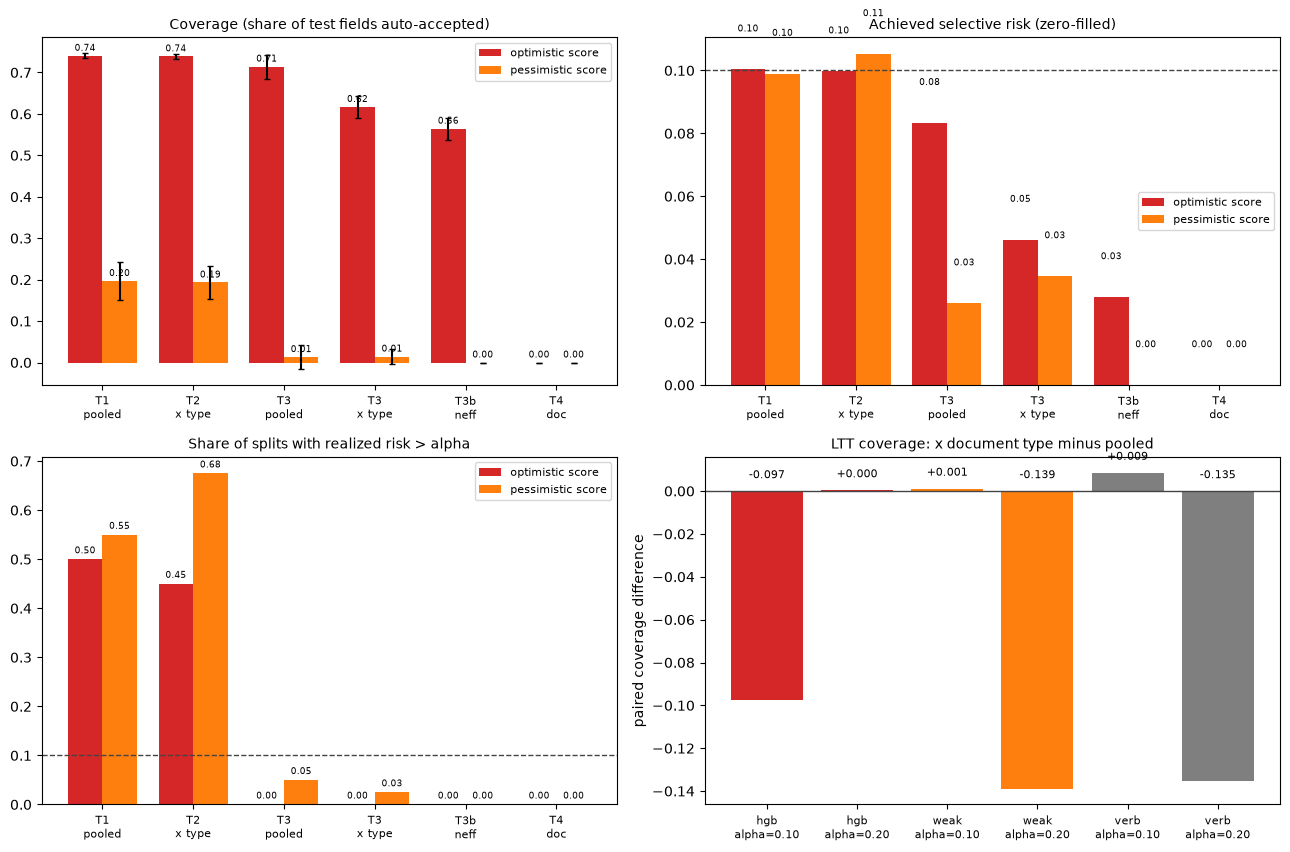

In [24]:
_fig, _axes = plt.subplots(2, 2, figsize=(13, 8.6))
_x = np.arange(len(B_TIERS)); _w = 0.38
for _ax, _what, _title, _ref in ((_axes[0, 0], "cov", "Coverage (share of test fields auto-accepted)", None), (_axes[0, 1], "risk", "Achieved selective risk (zero-filled)", 0.10),
                                 (_axes[1, 0], "viol", "Share of splits with realized risk > alpha", 0.10)):
    for _i, (_k, _c) in enumerate((("hgb", PAL3["hgb"]), ("weak", PAL3["b_weak"]))):
        _v = [b_summ(B_LADDER[(_k, 0.10)], t)[_what] for t in B_TIERS]
        _e = [b_summ(B_LADDER[(_k, 0.10)], t)["cov_sd"] for t in B_TIERS] if _what == "cov" else None
        _ax.bar(_x + (_i - 0.5) * _w, _v, _w, yerr=_e, capsize=2, color=_c, label="optimistic score" if _k == "hgb" else "pessimistic score")
        for _xx, _vv in zip(_x, _v):
            _ax.text(_xx + (_i - 0.5) * _w, _vv + 0.012, f"{_vv:.2f}", ha="center", fontsize=6.5)
    if _ref is not None:
        _ax.axhline(_ref, ls="--", color=PAL3["diag"], lw=1)
    _ax.set_xticks(_x); _ax.set_xticklabels([B_TIER_SHORT[t] for t in B_TIERS], fontsize=8); _ax.set_title(_title, fontsize=10); _ax.legend(fontsize=8)
_ax = _axes[1, 1]
_labs, _vals, _cols = [], [], []
for _k in ("hgb", "weak", "verb"):
    for _a in (0.10, 0.20):
        _labs.append(f"{_k}\nalpha={_a:.2f}"); _vals.append(B_TWO_REGIME[(_k, _a, "t3p")]["diff"])
        _cols.append({"hgb": PAL3["hgb"], "weak": PAL3["b_weak"], "verb": PAL3["raw"]}[_k])
_ax.bar(range(len(_vals)), _vals, color=_cols); _ax.axhline(0, color=PAL3["diag"], lw=1)
for _i, _v in enumerate(_vals):
    _ax.text(_i, (_v + 0.006) if _v >= 0 else 0.006, f"{_v:+.3f}", ha="center", fontsize=8)
_ax.set_xticks(range(len(_vals))); _ax.set_xticklabels(_labs, fontsize=8); _ax.set_title("LTT coverage: x document type minus pooled", fontsize=10); _ax.set_ylabel("paired coverage difference")
plt.tight_layout(); plt.show()


## 7. Month-7 shift: frozen-configuration confirmation (P3 section 6.4 analogue) and what nobody covers

**What Gurram did (quoted, idpfin-q9).** "the production configuration (learned no-NLI fusion, pooled split-protocol add-one; frozen before the run) was executed **once, with no tuning,** on selection-untouched
genuine captures ... it attained coverage 0.167 at achieved risk 0.093 (viol 0.38) at alpha=0.10 ... Across both untouched captures the risk contract never failed;
what varies is coverage, which tracks the model's signal quality". Note what that confirmation is: a **new extractor on the same corpus family**, so exchangeability
between calibration and test still held; the paper itself says "Inference is in-corpus" (idpfin-q9). It is **not** a shifted batch.

**What our batch does.** The `shift` split (500 documents, month 7) has new vendor templates and heavier OCR noise: base rate of fully-correct documents 0.19 instead of 0.33, field error rate about 0.45
instead of 0.30. That violates exchangeability between calibration and deployment, and **no guarantee in P1-P3 was promised under it**: cfBH's authors list it as a
limitation ("Reliable selection under distribution shift, if not infeasible, may require more involved techniques", idpfin-q3); SCoRE covers only *covariate* shift with a known
or consistently estimated density ratio (Assumption 6.1; not built, Section 5(d)); and "None of the three sources state how to perform real-time, online re-calibration or re-certification under
unobserved concept drift" without new labeled data (idpfin-q12). Also unstated anywhere: a formula for how many labelled calibration units are enough ("None of the three sources state a single universal, closed-form analytical formula",
idpfin-q12), so the labelled-document budget below is **derived here, empirically**.

**Protocol (ours).** (1) Freeze scores and thresholds learned on the `calib` split only (tier 1 pooled add-one, tier 3 Mondrian LTT by document type, `alpha in {0.10, 0.20}`, `delta = 0.10`, both scores)
plus the folklore rule (verbalized confidence >= 0.9 and no rule failure); apply **once** to `test` (control, same distribution) and `shift`. (2) Report the accepted-set field error with a
**document-cluster bootstrap** CI (2,000 resamples of documents) and the share of bootstrap resamples whose risk exceeds `alpha`. (3) Re-calibrate the *thresholds* (scores stay frozen) on `N` labelled shift documents
and evaluate on the remaining shift documents, 40 random draws per `N`. Rule fixed **before** looking at the recalibration results: the *budget* is the smallest `N` in {50, 100, 200, 300} at which tier-3 pooled recalibration
(i) certifies something in all 40 draws, (ii) has violation fraction <= `delta` + Clopper-Pearson tolerance, and (iii) reaches at least 90% of its own coverage at `N = 300`.


In [25]:
def b_doc_arrays(mask, acc):
    docs = np.unique(FA_doc[mask]); inv = np.searchsorted(docs, FA_doc[mask])
    n_acc = np.bincount(inv[acc], minlength=len(docs)).astype(float); e_acc = np.bincount(inv[acc], weights=B_ERR[mask][acc], minlength=len(docs))
    return n_acc, e_acc


def b_boot_ratio(num_d, den_d, thr, B=2000, seed=0):
    """Document-cluster bootstrap of sum(num)/sum(den): (point, lo, hi, share of resamples with ratio > thr)."""
    rng = np.random.default_rng([SEED3, 7, seed]); D = len(num_d); idx = rng.integers(0, D, size=(B, D))
    num, den = num_d[idx].sum(1), den_d[idx].sum(1); ok = den > 0; r = num[ok] / den[ok]
    pt = num_d.sum() / den_d.sum() if den_d.sum() > 0 else float("nan")
    if len(r) == 0:
        return pt, float("nan"), float("nan"), float("nan")
    return pt, float(np.percentile(r, 2.5)), float(np.percentile(r, 97.5)), float(np.mean(r > thr))


B_CALM, B_TESTM, B_SHIFTM = (B_FSPLIT == "calib"), (B_FSPLIT == "test"), (B_FSPLIT == "shift")
B_FOLK_FIELD = np.array([f["accepted"] for f in FIELDS], int).astype(bool)          # Notebook 2 baseline, learned from nothing

B_FROZEN = {}
for _k in ("hgb", "weak"):
    for _a in (0.10, 0.20):
        B_FROZEN[(_k, _a)] = b_fit_thresholds(B_SCORE_FIELD[_k], B_CALM, _a, 0.10)[0]
check("S7.1 every threshold was learned from `calib`-split documents only (never test or shift)", set(DOC_SPLIT[FA_doc[B_CALM]]) == {"calib"} and not (B_CALM & (B_TESTM | B_SHIFTM)).any(),
      f"{len(set(FA_doc[B_CALM]))} calibration documents")


def b_eval_frozen(acc_fn, alpha):
    row = {}
    for nm, m in (("test", B_TESTM), ("shift", B_SHIFTM)):
        acc = acc_fn(m); n_d, e_d = b_doc_arrays(m, acc); pt, lo, hi, pg = b_boot_ratio(e_d, n_d, alpha)
        row[nm] = dict(cov=acc.mean(), risk=pt, lo=lo, hi=hi, p_gt=pg, nacc=int(acc.sum()))
    return row


B_FROZEN_RES = {}
for _k in ("hgb", "weak"):
    for _a in (0.10, 0.20):
        for _t in ("t1", "t3"):
            B_FROZEN_RES[(_k, _a, _t)] = b_eval_frozen(lambda m, _k=_k, _a=_a, _t=_t: b_accept(B_SCORE_FIELD[_k], m, B_FROZEN[(_k, _a)][_t]), _a)
B_FROZEN_RES[("folk", None, "folk")] = b_eval_frozen(lambda m: B_FOLK_FIELD[m], 0.10)
B_FROZEN_RES[("folk", None, "folk")]["alpha_ref"] = 0.10
_rows = []
for (_k, _a, _t), _r in B_FROZEN_RES.items():
    _tau = "-" if _k == "folk" else (f"{B_FROZEN[(_k, _a)][_t]:.3f}" if _t == "t1" else "[" + ", ".join("review all" if np.isinf(x) else f"{x:.3f}" for x in B_FROZEN[(_k, _a)][_t]) + "]")
    _ref = 0.10 if _a is None else _a
    _rows.append(({"hgb": "optimistic", "weak": "pessimistic", "folk": "folklore (>=0.9 & rules)"}[_k], "-" if _a is None else f"{_a:.2f}", {"t1": "1 add-one pooled", "t3": "3 LTT x type", "folk": "-"}[_t], _tau,
                  f"{_r['test']['cov']:.3f}", f"{_r['test']['risk']:.3f} [{_r['test']['lo']:.3f}, {_r['test']['hi']:.3f}]",
                  f"{_r['shift']['cov']:.3f}", f"{_r['shift']['risk']:.3f} [{_r['shift']['lo']:.3f}, {_r['shift']['hi']:.3f}]", f"{_r['shift']['p_gt']:.2f}",
                  "held" if _r["shift"]["risk"] <= _ref else "BROKEN"))
b_display(b_md("**Frozen configurations applied once** (risk = error rate among accepted fields with document-cluster bootstrap 95% CI; folklore is compared with alpha = 0.10; thresholds apply to the field score, per document type in the order invoice, bank statement, KYC, compliance report)\n\n" + b_tbl(
    ["score", "alpha", "rule", "frozen threshold(s)", "test coverage", "test risk [95% CI]", "shift coverage", "shift risk [95% CI]", "share of bootstrap resamples with shift risk > alpha", "verdict on shift"], _rows)))

check("S7.2 control: on the unshifted `test` split every frozen tier-3 configuration keeps its realized risk at or below alpha (this run: one calibration draw)",
      all(B_FROZEN_RES[(k, a, "t3")]["test"]["risk"] <= a for k in ("hgb", "weak") for a in (0.10, 0.20)),
      "; ".join(f"{k}/{a}: {B_FROZEN_RES[(k, a, 't3')]['test']['risk']:.3f}" for k in ("hgb", "weak") for a in (0.10, 0.20)))
_broken = {key: r["shift"]["risk"] > (0.10 if key[1] is None else key[1]) for key, r in B_FROZEN_RES.items()}
check("S7.3 as theory says (no promise under shift): EVERY frozen configuration, certified or not, has a realized shift risk above its alpha", all(_broken.values()),
      "; ".join(f"{k[0]}/{k[1]}/{k[2]}: {r['shift']['risk']:.3f}" for k, r in B_FROZEN_RES.items()))
check("S7.4 shift degrades every frozen configuration (shift risk > test risk)", all(r["shift"]["risk"] > r["test"]["risk"] for r in B_FROZEN_RES.values()),
      "; ".join(f"{k[0]}/{k[1]}/{k[2]}: {r['test']['risk']:.3f} -> {r['shift']['risk']:.3f}" for k, r in B_FROZEN_RES.items()))
_clear = [k for k, r in B_FROZEN_RES.items() if r["shift"]["lo"] > (0.10 if k[1] is None else k[1])]
print("[info] guarantees on the shift batch: violated with the whole bootstrap CI above alpha for " + (", ".join(f"{k[0]}/{k[1]}/{k[2]}" for k in _clear) or "none")
      + "; point estimate above alpha but CI reaching alpha (few accepted fields) for " + (", ".join(f"{k[0]}/{k[1]}/{k[2]}" for k in B_FROZEN_RES if k not in _clear) or "none") + ".")


[PASS] S7.1 every threshold was learned from `calib`-split documents only (never test or shift) -- 1049 calibration documents


**Frozen configurations applied once** (risk = error rate among accepted fields with document-cluster bootstrap 95% CI; folklore is compared with alpha = 0.10; thresholds apply to the field score, per document type in the order invoice, bank statement, KYC, compliance report)

| score | alpha | rule | frozen threshold(s) | test coverage | test risk [95% CI] | shift coverage | shift risk [95% CI] | share of bootstrap resamples with shift risk > alpha | verdict on shift |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.10 | 1 add-one pooled | 0.385 | 0.740 | 0.103 [0.094, 0.112] | 0.695 | 0.270 [0.249, 0.291] | 1.00 | BROKEN |
| optimistic | 0.10 | 3 LTT x type | [0.813, 0.423, 0.546, 0.517] | 0.662 | 0.065 [0.057, 0.072] | 0.568 | 0.206 [0.186, 0.228] | 1.00 | BROKEN |
| optimistic | 0.20 | 1 add-one pooled | 0.121 | 0.867 | 0.204 [0.192, 0.216] | 0.875 | 0.379 [0.359, 0.400] | 1.00 | BROKEN |
| optimistic | 0.20 | 3 LTT x type | [0.365, 0.423, 0.546, 0.517] | 0.715 | 0.087 [0.079, 0.096] | 0.641 | 0.240 [0.220, 0.261] | 1.00 | BROKEN |
| pessimistic | 0.10 | 1 add-one pooled | 0.879 | 0.228 | 0.105 [0.091, 0.119] | 0.119 | 0.210 [0.173, 0.251] | 1.00 | BROKEN |
| pessimistic | 0.10 | 3 LTT x type | [review all, review all, review all, 0.877] | 0.061 | 0.095 [0.070, 0.120] | 0.019 | 0.184 [0.092, 0.293] | 0.96 | BROKEN |
| pessimistic | 0.20 | 1 add-one pooled | 0.559 | 0.812 | 0.206 [0.194, 0.218] | 0.713 | 0.338 [0.318, 0.359] | 1.00 | BROKEN |
| pessimistic | 0.20 | 3 LTT x type | [0.782, 0.648, 0.781, 0.686] | 0.617 | 0.167 [0.155, 0.178] | 0.480 | 0.294 [0.271, 0.318] | 1.00 | BROKEN |
| folklore (>=0.9 & rules) | - | - | - | 0.153 | 0.099 [0.083, 0.116] | 0.131 | 0.183 [0.148, 0.220] | 1.00 | BROKEN |

[PASS] S7.2 control: on the unshifted `test` split every frozen tier-3 configuration keeps its realized risk at or below alpha (this run: one calibration draw) -- hgb/0.1: 0.065; hgb/0.2: 0.087; weak/0.1: 0.095; weak/0.2: 0.167
[PASS] S7.3 as theory says (no promise under shift): EVERY frozen configuration, certified or not, has a realized shift risk above its alpha -- hgb/0.1/t1: 0.270; hgb/0.1/t3: 0.206; hgb/0.2/t1: 0.379; hgb/0.2/t3: 0.240; weak/0.1/t1: 0.210; weak/0.1/t3: 0.184; weak/0.2/t1: 0.338; weak/0.2/t3: 0.294; folk/None/folk: 0.183
[PASS] S7.4 shift degrades every frozen configuration (shift risk > test risk) -- hgb/0.1/t1: 0.103 -> 0.270; hgb/0.1/t3: 0.065 -> 0.206; hgb/0.2/t1: 0.204 -> 0.379; hgb/0.2/t3: 0.087 -> 0.240; weak/0.1/t1: 0.105 -> 0.210; weak/0.1/t3: 0.095 -> 0.184; weak/0.2/t1: 0.206 -> 0.338; weak/0.2/t3: 0.167 -> 0.294; folk/None/folk: 0.099 -> 0.183
[info] guarantees on the shift batch: violated with the whole bootstrap CI above alpha for hgb/0.1/t1, hgb/0.

In [26]:
# ---- supplementary 1: how often does a frozen config break, across 40 different calibration draws from the calib split? ----
_calib_docs = np.unique(FA_doc[B_CALM]); B_SHIFT_VIOL = {}
for _k in ("hgb", "weak"):
    for _t in ("t1", "t3"):
        _v = {"test": [], "shift": []}
        for _sd in range(40):
            _rng = np.random.default_rng([SEED3, 31, _sd]); _sub = np.zeros(N_DOC, bool); _sub[_rng.choice(_calib_docs, int(0.8 * len(_calib_docs)), replace=False)] = True
            _tau = b_fit_thresholds(B_SCORE_FIELD[_k], _sub[FA_doc] & B_CALM, 0.10, 0.10)[0][_t]
            for _nm, _m in (("test", B_TESTM), ("shift", B_SHIFTM)):
                _acc = b_accept(B_SCORE_FIELD[_k], _m, _tau); _v[_nm].append(B_ERR[_m][_acc].mean() > 0.10 if _acc.any() else False)
        B_SHIFT_VIOL[(_k, _t)] = {nm: float(np.mean(x)) for nm, x in _v.items()}
b_display(b_md("**Violation across 40 calibration draws** (80% of the `calib` documents each; alpha = 0.10, delta = 0.10; share of draws whose realized risk exceeds alpha)\n\n" + b_tbl(
    ["score", "rule", "on `test` (no shift)", "on `shift`"], [({"hgb": "optimistic", "weak": "pessimistic"}[k], {"t1": "1 add-one pooled", "t3": "3 LTT x type"}[t], f"{v['test']:.2f}", f"{v['shift']:.2f}") for (k, t), v in B_SHIFT_VIOL.items()])))
check("S7.5 across calibration draws the certified rule stays within delta on `test` but not on `shift`",
      all(B_SHIFT_VIOL[(k, "t3")]["test"] <= 0.10 + b_cp_tol(B_SHIFT_VIOL[(k, "t3")]["test"], 40) for k in ("hgb", "weak")) and all(B_SHIFT_VIOL[(k, "t3")]["shift"] > 0.10 + b_cp_tol(0.10, 40) for k in ("hgb", "weak")),
      "; ".join(f"{k}: test {B_SHIFT_VIOL[(k, 't3')]['test']:.2f}, shift {B_SHIFT_VIOL[(k, 't3')]['shift']:.2f}" for k in ("hgb", "weak")))

# ---- supplementary 2: the document-level rules of Section 5 under shift (calibrated on calib money docs, applied once) ----
_cm = np.where((DOC_SPLIT == "calib") & DA_has_money)[0]; B_DOC_SHIFT = {}
for _k, _s in B_SCORES.items():
    for _a in (0.10, 0.20):
        _psi_cal = None
        for _nm, _sp in (("test", "test"), ("shift", "shift")):
            _td = np.where((DOC_SPLIT == _sp) & DA_has_money)[0]
            _psi = b_mdr_e_values(_s[_cm], DA_L[_cm], _s[_td], _a) >= 1 / _a
            _nv = _s[_td] <= _a
            _rng = np.random.default_rng([SEED3, 41]); _ix = _rng.integers(0, len(_td), size=(2000, len(_td)))
            _mdr = (DA_L[_td] * _psi)[_ix].mean(1); _nsel = _nv[_ix].sum(1); _nvl = (DA_L[_td] * _nv)[_ix].sum(1) / np.maximum(_nsel, 1)
            B_DOC_SHIFT[(_k, _a, _nm)] = dict(mdr=float(np.mean(DA_L[_td] * _psi)), mdr_ci=np.percentile(_mdr, [2.5, 97.5]), cov=float(_psi.mean()),
                                              naive=float((DA_L[_td] * _nv).sum() / max(1, _nv.sum())), naive_ci=np.percentile(_nvl, [2.5, 97.5]), naive_cov=float(_nv.mean()))
_rows = []
for (_k, _a, _nm), _v in B_DOC_SHIFT.items():
    _rows.append(({"opt": "optimistic", "weak": "pessimistic"}[_k], f"{_a:.2f}", _nm, f"{_v['cov']:.3f}", f"{_v['mdr']:.4f} [{_v['mdr_ci'][0]:.4f}, {_v['mdr_ci'][1]:.4f}]",
                  f"{_v['naive_cov']:.3f}", f"{_v['naive']:.4f} [{_v['naive_ci'][0]:.4f}, {_v['naive_ci'][1]:.4f}]"))
b_display(b_md("**Document-level rules from Section 5, calibrated once on `calib` money documents** (bootstrap over test documents with the calibration fixed)\n\n" + b_tbl(
    ["score", "alpha", "applied to", "SCoRE-MDR coverage", "realized MDR E[L psi] [95% CI]", "naive coverage (pred. risk <= alpha)", "naive avg loss among accepted [95% CI]"], _rows)))
_mdr_shift_breaks = [(k, a) for k in B_SCORES for a in (0.10, 0.20) if B_DOC_SHIFT[(k, a, "shift")]["mdr"] > a]
check("S7.6 without SCoRE's required density-ratio weighting, the shifted batch breaks the observed MDR target in at least one configuration (not universally)",
      bool(_mdr_shift_breaks),
      "; ".join(f"{k}/{a}: {B_DOC_SHIFT[(k, a, 'shift')]['mdr']:.3f} (test {B_DOC_SHIFT[(k, a, 'test')]['mdr']:.3f})" for k in B_SCORES for a in (0.10, 0.20))
      + f"; observed shift overshoots: {_mdr_shift_breaks}. Any non-overshoot is a finite sample result, not evidence that the unweighted guarantee survived shift.")
_naive_shift_breaks = [(k, a) for k in B_SCORES for a in (0.10, 0.20) if B_DOC_SHIFT[(k, a, "shift")]["naive"] > a]
check("S7.7 the old-data naive risk rule also has at least one observed shifted-batch overshoot; it has no shift guarantee",
      bool(_naive_shift_breaks),
      "; ".join(f"{k}/{a}: {B_DOC_SHIFT[(k, a, 'shift')]['naive']:.3f} (test {B_DOC_SHIFT[(k, a, 'test')]['naive']:.3f})" for k in B_SCORES for a in (0.10, 0.20))
      + f"; observed shift overshoots: {_naive_shift_breaks}. Non-overshoot cells are reported, not promoted to a guarantee.")


**Violation across 40 calibration draws** (80% of the `calib` documents each; alpha = 0.10, delta = 0.10; share of draws whose realized risk exceeds alpha)

| score | rule | on `test` (no shift) | on `shift` |
| --- | --- | --- | --- |
| optimistic | 1 add-one pooled | 0.88 | 1.00 |
| optimistic | 3 LTT x type | 0.00 | 1.00 |
| pessimistic | 1 add-one pooled | 0.95 | 1.00 |
| pessimistic | 3 LTT x type | 0.03 | 0.35 |

[PASS] S7.5 across calibration draws the certified rule stays within delta on `test` but not on `shift` -- hgb: test 0.00, shift 1.00; weak: test 0.03, shift 0.35


**Document-level rules from Section 5, calibrated once on `calib` money documents** (bootstrap over test documents with the calibration fixed)

| score | alpha | applied to | SCoRE-MDR coverage | realized MDR E[L psi] [95% CI] | naive coverage (pred. risk <= alpha) | naive avg loss among accepted [95% CI] |
| --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.10 | test | 0.731 | 0.0751 [0.0600, 0.0908] | 0.426 | 0.0403 [0.0232, 0.0604] |
| optimistic | 0.10 | shift | 0.555 | 0.0962 [0.0715, 0.1232] | 0.283 | 0.0575 [0.0213, 0.0990] |
| optimistic | 0.20 | test | 0.947 | 0.1610 [0.1397, 0.1825] | 0.568 | 0.0680 [0.0489, 0.0895] |
| optimistic | 0.20 | shift | 0.948 | 0.2790 [0.2414, 0.3196] | 0.427 | 0.1377 [0.0922, 0.1878] |
| pessimistic | 0.10 | test | 0.731 | 0.0945 [0.0773, 0.1127] | 0.405 | 0.0742 [0.0509, 0.1001] |
| pessimistic | 0.10 | shift | 0.594 | 0.1316 [0.1029, 0.1624] | 0.181 | 0.1576 [0.0840, 0.2364] |
| pessimistic | 0.20 | test | 0.954 | 0.1636 [0.1426, 0.1855] | 0.634 | 0.1063 [0.0849, 0.1294] |
| pessimistic | 0.20 | shift | 0.924 | 0.2664 [0.2293, 0.3050] | 0.469 | 0.1979 [0.1497, 0.2496] |

[PASS] S7.6 without SCoRE's required density-ratio weighting, the shifted batch breaks the observed MDR target in at least one configuration (not universally) -- opt/0.1: 0.096 (test 0.075); opt/0.2: 0.279 (test 0.161); weak/0.1: 0.132 (test 0.094); weak/0.2: 0.266 (test 0.164); observed shift overshoots: [('opt', 0.2), ('weak', 0.1), ('weak', 0.2)]. Any non-overshoot is a finite sample result, not evidence that the unweighted guarantee survived shift.
[PASS] S7.7 the old-data naive risk rule also has at least one observed shifted-batch overshoot; it has no shift guarantee -- opt/0.1: 0.058 (test 0.040); opt/0.2: 0.138 (test 0.068); weak/0.1: 0.158 (test 0.074); weak/0.2: 0.198 (test 0.106); observed shift overshoots: [('weak', 0.1)]. Non-overshoot cells are reported, not promoted to a guarantee.


True

In [27]:
# ---- re-calibration on N labelled shift documents (scores stay frozen; thresholds re-learned), 40 random draws per N ----
B_SHIFT_DOCS = np.where(DOC_SPLIT == "shift")[0]
B_RECAL_NS = (50, 100, 200, 300)
B_RECAL_METHODS = ("stale_t1", "stale_t3", "recal_t1", "recal_t3p", "recal_t3")


def b_recal(score_key, alpha, N, R=40, delta=0.10):
    score = B_SCORE_FIELD[score_key]; fz = B_FROZEN[(score_key, alpha)]; rows = {m: [] for m in B_RECAL_METHODS}
    for r in range(R):
        rng = np.random.default_rng([SEED3, 77, N, r]); perm = rng.permutation(B_SHIFT_DOCS); dm = np.zeros(N_DOC, int); dm[perm[:N]] = 1; dm[perm[N:]] = 2
        lm, tm = dm[FA_doc] == 1, dm[FA_doc] == 2; sc_l, er_l, gr_l = score[lm], B_ERR[lm], B_GRP[lm]
        taus = {"stale_t1": fz["t1"], "stale_t3": fz["t3"], "recal_t1": add_one_threshold(sc_l, er_l, alpha), "recal_t3p": b_ltt_certify(sc_l, er_l, alpha, delta),
                "recal_t3": np.array([b_ltt_certify(sc_l[gr_l == g], er_l[gr_l == g], alpha, delta) for g in range(4)])}
        for m_, tau in taus.items():
            acc = b_accept(score, tm, tau); te = B_ERR[tm]
            rows[m_].append((acc.mean(), te[acc].mean() if acc.any() else 0.0, float(te[acc].mean() > alpha) if acc.any() else 0.0, float(not acc.any())))
    return {m_: np.array(v) for m_, v in rows.items()}


B_RECAL = {(k, a, N): b_recal(k, a, N) for k in ("hgb", "weak") for a in (0.10, 0.20) for N in B_RECAL_NS}
_lab = {"stale_t1": "stale tier 1 (frozen)", "stale_t3": "stale tier 3 x type (frozen)", "recal_t1": "recal. tier 1 add-one", "recal_t3p": "recal. tier 3 pooled", "recal_t3": "recal. tier 3 x type"}
for _k in ("hgb", "weak"):
    for _a in (0.10, 0.20):
        _rows = []
        for _m in B_RECAL_METHODS:
            for _N in B_RECAL_NS:
                _v = B_RECAL[(_k, _a, _N)][_m]
                _rows.append((_lab[_m], _N, f"{_v[:, 0].mean():.3f}", f"{_v[:, 1].mean():.3f}", f"{_v[:, 2].mean():.2f}", f"{int(_v[:, 3].sum())}/40"))
        b_display(b_md(f"**Re-calibration, {'optimistic' if _k == 'hgb' else 'pessimistic'} score, alpha = {_a:.2f}, delta = 0.10** (mean over 40 draws; evaluated on the remaining 500 - N shift documents)\n\n" + b_tbl(
            ["rule", "labelled shift docs N", "coverage", "realized risk (zero-filled)", "share of draws with risk > alpha", "draws with zero coverage"], _rows)))

_ok, _det = True, []
for (_k, _a, _N), _res in B_RECAL.items():
    for _m in ("recal_t3p", "recal_t3"):
        _v = _res[_m][:, 2].mean(); _ok &= _v <= 0.10 + b_cp_tol(_v, 40); _det.append(f"{_k}/{_a}/{_N}/{_m[6:]}: {_v:.2f}")
check("S7.8 recalibrated PAC tiers (3 pooled, 3 x type) are valid again on the shifted distribution: violation fraction <= delta + CP tolerance in every cell", _ok, "; ".join(_det[:8]) + " ...")
check("S7.9 recalibrated tier 1 (expectation) meets its target on average but is not a certificate (hgb, alpha=0.10, N=200: risk <= alpha + 3SE, violation > delta)",
      B_RECAL[("hgb", 0.10, 200)]["recal_t1"][:, 1].mean() <= 0.10 + b_mc_tol_mean(B_RECAL[("hgb", 0.10, 200)]["recal_t1"][:, 1]) and B_RECAL[("hgb", 0.10, 200)]["recal_t1"][:, 2].mean() > 0.10,
      f"risk {B_RECAL[('hgb', 0.10, 200)]['recal_t1'][:, 1].mean():.4f}, violation {B_RECAL[('hgb', 0.10, 200)]['recal_t1'][:, 2].mean():.2f}")
check("S7.10 stale (frozen) thresholds keep violating on the shifted distribution regardless of how many labelled shift documents exist elsewhere (hgb, alpha=0.10: violation in >= 90% of draws)",
      all(B_RECAL[("hgb", 0.10, N)]["stale_t3"][:, 2].mean() >= 0.90 for N in B_RECAL_NS), "; ".join(f"N={N}: {B_RECAL[('hgb', 0.10, N)]['stale_t3'][:, 2].mean():.2f}" for N in B_RECAL_NS))

# labelled-document budget by the pre-fixed rule
B_BUDGET = {}
for _k in ("hgb", "weak"):
    for _a in (0.10, 0.20):
        _cov300 = B_RECAL[(_k, _a, 300)]["recal_t3p"][:, 0].mean(); _found = None
        for _N in B_RECAL_NS:
            _v = B_RECAL[(_k, _a, _N)]["recal_t3p"]
            if _v[:, 3].sum() == 0 and _v[:, 2].mean() <= 0.10 + b_cp_tol(_v[:, 2].mean(), 40) and _cov300 > 0 and _v[:, 0].mean() >= 0.9 * _cov300:
                _found = _N; break
        B_BUDGET[(_k, _a)] = dict(N=_found, cov300=_cov300)
print("labelled-shift-document budget (derived here, rule fixed in advance; tier-3 pooled recalibration): " + "; ".join(
    f"{k}/alpha={a}: " + (f"N={v['N']} (coverage at N=300: {v['cov300']:.3f})" if v["N"] else f"not reached within N<=300 (coverage at N=300: {v['cov300']:.3f})") for (k, a), v in B_BUDGET.items()))
check("S7.11 a labelled-document budget within the tested grid exists for the optimistic score (both alphas); none is claimed for the pessimistic score unless the rule found one",
      all(B_BUDGET[("hgb", a)]["N"] is not None for a in (0.10, 0.20)), "; ".join(f"{k}/{a}: {v['N']}" for (k, a), v in B_BUDGET.items()))
_pre = {k: b_summ(B_LADDER[(k, 0.10)], "t3p")["cov"] for k in ("hgb", "weak")}
print(f"[info] for scale: pre-shift tier-3 pooled coverage at alpha=0.10 on the resplit protocol was {_pre['hgb']:.3f} (optimistic) / {_pre['weak']:.3f} (pessimistic); after recalibration on the shifted batch it is "
      f"{B_RECAL[('hgb', 0.10, 300)]['recal_t3p'][:, 0].mean():.3f} / {B_RECAL[('weak', 0.10, 300)]['recal_t3p'][:, 0].mean():.3f} at N=300 - validity comes back, coverage does not, because the shifted documents are harder to separate.")


**Re-calibration, optimistic score, alpha = 0.10, delta = 0.10** (mean over 40 draws; evaluated on the remaining 500 - N shift documents)

| rule | labelled shift docs N | coverage | realized risk (zero-filled) | share of draws with risk > alpha | draws with zero coverage |
| --- | --- | --- | --- | --- | --- |
| stale tier 1 (frozen) | 50 | 0.695 | 0.270 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 100 | 0.696 | 0.270 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 200 | 0.696 | 0.271 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 300 | 0.695 | 0.272 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 50 | 0.568 | 0.206 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 100 | 0.567 | 0.206 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 200 | 0.568 | 0.207 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 300 | 0.569 | 0.207 | 1.00 | 0/40 |
| recal. tier 1 add-one | 50 | 0.409 | 0.097 | 0.45 | 0/40 |
| recal. tier 1 add-one | 100 | 0.419 | 0.100 | 0.57 | 0/40 |
| recal. tier 1 add-one | 200 | 0.422 | 0.102 | 0.55 | 0/40 |
| recal. tier 1 add-one | 300 | 0.417 | 0.100 | 0.45 | 0/40 |
| recal. tier 3 pooled | 50 | 0.193 | 0.019 | 0.00 | 8/40 |
| recal. tier 3 pooled | 100 | 0.274 | 0.030 | 0.00 | 0/40 |
| recal. tier 3 pooled | 200 | 0.302 | 0.044 | 0.03 | 0/40 |
| recal. tier 3 pooled | 300 | 0.306 | 0.046 | 0.03 | 0/40 |
| recal. tier 3 x type | 50 | 0.002 | 0.001 | 0.00 | 39/40 |
| recal. tier 3 x type | 100 | 0.058 | 0.016 | 0.00 | 15/40 |
| recal. tier 3 x type | 200 | 0.222 | 0.032 | 0.00 | 0/40 |
| recal. tier 3 x type | 300 | 0.250 | 0.033 | 0.00 | 0/40 |

**Re-calibration, optimistic score, alpha = 0.20, delta = 0.10** (mean over 40 draws; evaluated on the remaining 500 - N shift documents)

| rule | labelled shift docs N | coverage | realized risk (zero-filled) | share of draws with risk > alpha | draws with zero coverage |
| --- | --- | --- | --- | --- | --- |
| stale tier 1 (frozen) | 50 | 0.875 | 0.380 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 100 | 0.876 | 0.379 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 200 | 0.875 | 0.380 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 300 | 0.876 | 0.382 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 50 | 0.641 | 0.240 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 100 | 0.642 | 0.240 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 200 | 0.641 | 0.240 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 300 | 0.640 | 0.240 | 1.00 | 0/40 |
| recal. tier 1 add-one | 50 | 0.580 | 0.199 | 0.50 | 0/40 |
| recal. tier 1 add-one | 100 | 0.580 | 0.200 | 0.45 | 0/40 |
| recal. tier 1 add-one | 200 | 0.581 | 0.202 | 0.50 | 0/40 |
| recal. tier 1 add-one | 300 | 0.577 | 0.200 | 0.53 | 0/40 |
| recal. tier 3 pooled | 50 | 0.393 | 0.089 | 0.00 | 0/40 |
| recal. tier 3 pooled | 100 | 0.425 | 0.108 | 0.00 | 0/40 |
| recal. tier 3 pooled | 200 | 0.500 | 0.151 | 0.00 | 0/40 |
| recal. tier 3 pooled | 300 | 0.502 | 0.152 | 0.00 | 0/40 |
| recal. tier 3 x type | 50 | 0.151 | 0.047 | 0.00 | 2/40 |
| recal. tier 3 x type | 100 | 0.302 | 0.071 | 0.00 | 0/40 |
| recal. tier 3 x type | 200 | 0.377 | 0.096 | 0.00 | 0/40 |
| recal. tier 3 x type | 300 | 0.412 | 0.107 | 0.00 | 0/40 |

**Re-calibration, pessimistic score, alpha = 0.10, delta = 0.10** (mean over 40 draws; evaluated on the remaining 500 - N shift documents)

| rule | labelled shift docs N | coverage | realized risk (zero-filled) | share of draws with risk > alpha | draws with zero coverage |
| --- | --- | --- | --- | --- | --- |
| stale tier 1 (frozen) | 50 | 0.119 | 0.210 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 100 | 0.119 | 0.210 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 200 | 0.119 | 0.213 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 300 | 0.119 | 0.208 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 50 | 0.019 | 0.182 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 100 | 0.019 | 0.187 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 200 | 0.019 | 0.185 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 300 | 0.019 | 0.173 | 0.88 | 0/40 |
| recal. tier 1 add-one | 50 | 0.022 | 0.079 | 0.47 | 21/40 |
| recal. tier 1 add-one | 100 | 0.012 | 0.061 | 0.38 | 23/40 |
| recal. tier 1 add-one | 200 | 0.015 | 0.089 | 0.53 | 18/40 |
| recal. tier 1 add-one | 300 | 0.009 | 0.075 | 0.45 | 20/40 |
| recal. tier 3 pooled | 50 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 pooled | 100 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 pooled | 200 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 pooled | 300 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 x type | 50 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 x type | 100 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 x type | 200 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 x type | 300 | 0.000 | 0.000 | 0.00 | 40/40 |

**Re-calibration, pessimistic score, alpha = 0.20, delta = 0.10** (mean over 40 draws; evaluated on the remaining 500 - N shift documents)

| rule | labelled shift docs N | coverage | realized risk (zero-filled) | share of draws with risk > alpha | draws with zero coverage |
| --- | --- | --- | --- | --- | --- |
| stale tier 1 (frozen) | 50 | 0.714 | 0.338 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 100 | 0.715 | 0.338 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 200 | 0.714 | 0.338 | 1.00 | 0/40 |
| stale tier 1 (frozen) | 300 | 0.713 | 0.339 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 50 | 0.480 | 0.294 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 100 | 0.480 | 0.294 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 200 | 0.479 | 0.294 | 1.00 | 0/40 |
| stale tier 3 x type (frozen) | 300 | 0.478 | 0.293 | 1.00 | 0/40 |
| recal. tier 1 add-one | 50 | 0.157 | 0.187 | 0.65 | 5/40 |
| recal. tier 1 add-one | 100 | 0.149 | 0.189 | 0.65 | 4/40 |
| recal. tier 1 add-one | 200 | 0.128 | 0.201 | 0.62 | 0/40 |
| recal. tier 1 add-one | 300 | 0.114 | 0.201 | 0.68 | 0/40 |
| recal. tier 3 pooled | 50 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 pooled | 100 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 pooled | 200 | 0.005 | 0.038 | 0.05 | 31/40 |
| recal. tier 3 pooled | 300 | 0.006 | 0.041 | 0.03 | 29/40 |
| recal. tier 3 x type | 50 | 0.000 | 0.000 | 0.00 | 40/40 |
| recal. tier 3 x type | 100 | 0.002 | 0.006 | 0.03 | 39/40 |
| recal. tier 3 x type | 200 | 0.002 | 0.016 | 0.03 | 37/40 |
| recal. tier 3 x type | 300 | 0.001 | 0.010 | 0.03 | 38/40 |

[PASS] S7.8 recalibrated PAC tiers (3 pooled, 3 x type) are valid again on the shifted distribution: violation fraction <= delta + CP tolerance in every cell -- hgb/0.1/50/t3p: 0.00; hgb/0.1/50/t3: 0.00; hgb/0.1/100/t3p: 0.00; hgb/0.1/100/t3: 0.00; hgb/0.1/200/t3p: 0.03; hgb/0.1/200/t3: 0.00; hgb/0.1/300/t3p: 0.03; hgb/0.1/300/t3: 0.00 ...
[PASS] S7.9 recalibrated tier 1 (expectation) meets its target on average but is not a certificate (hgb, alpha=0.10, N=200: risk <= alpha + 3SE, violation > delta) -- risk 0.1021, violation 0.55
[PASS] S7.10 stale (frozen) thresholds keep violating on the shifted distribution regardless of how many labelled shift documents exist elsewhere (hgb, alpha=0.10: violation in >= 90% of draws) -- N=50: 1.00; N=100: 1.00; N=200: 1.00; N=300: 1.00
labelled-shift-document budget (derived here, rule fixed in advance; tier-3 pooled recalibration): hgb/alpha=0.1: N=200 (coverage at N=300: 0.306); hgb/alpha=0.2: N=200 (coverage at N=300: 0.502); weak/alpha=0.1: not

**How to read this chart.** Left: the accepted-set field error on the `shift` batch for each frozen configuration (dots, with document-cluster bootstrap 95% CI) next to its error on the unshifted `test`
split (grey squares); the tick on each group marks its own `alpha`. Every dot sits above its tick: whatever was promised on calibration-like data does not carry over. Middle and right: recalibrating the
thresholds on `N` labelled shift documents (optimistic score, `alpha = 0.10`; 40 draws per point). Middle, coverage: the stale thresholds accept a lot but on a batch where they are wrong; the recalibrated certified rule
accepts less. Right, realized risk: the stale rules sit far above `alpha` (dashed), while the recalibrated certified rules come back **below** it. The expectation-only recalibrated add-one hovers at `alpha` and,
as in Section 6, exceeds it in a large share of draws. Note the recovered coverage is far below the pre-shift coverage: the shifted documents are harder to separate.


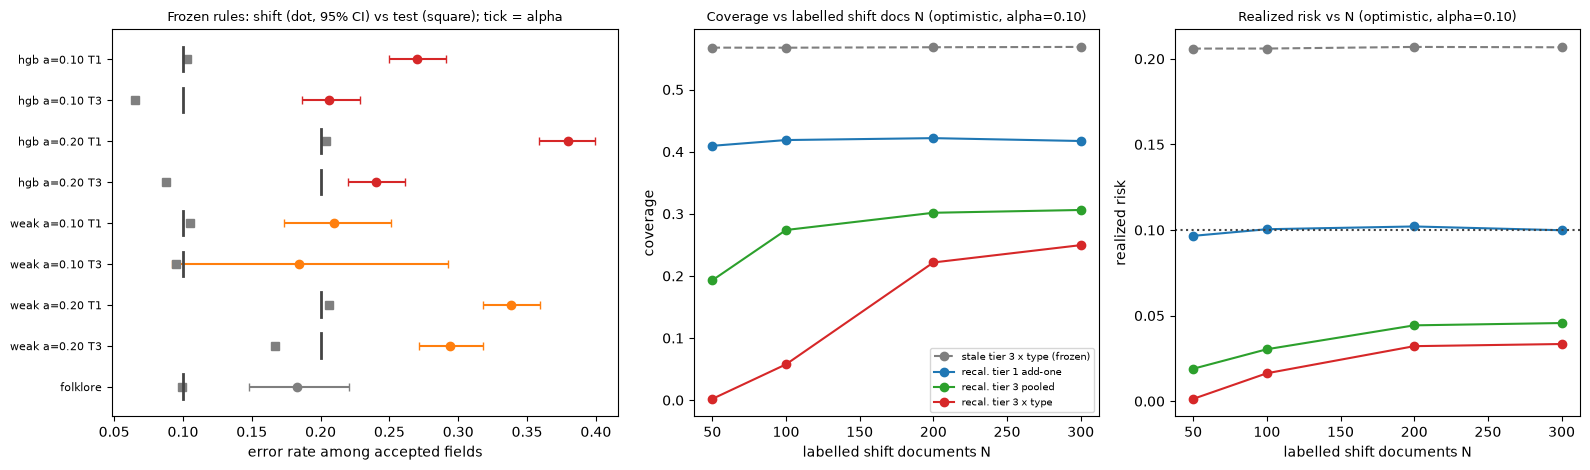

In [28]:
_fig, _axes = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.25, 1, 1]})
_ax = _axes[0]; _keys = [k for k in B_FROZEN_RES]; _y = np.arange(len(_keys))[::-1]
for _yy, _key in zip(_y, _keys):
    _r = B_FROZEN_RES[_key]; _ref = 0.10 if _key[1] is None else _key[1]
    _c = {"hgb": PAL3["hgb"], "weak": PAL3["b_weak"], "folk": PAL3["b_folk"]}[_key[0]]
    _ax.errorbar(_r["shift"]["risk"], _yy, xerr=[[_r["shift"]["risk"] - _r["shift"]["lo"]], [_r["shift"]["hi"] - _r["shift"]["risk"]]], fmt="o", color=_c, capsize=3)
    _ax.plot(_r["test"]["risk"], _yy, "s", color=PAL3["raw"], ms=6); _ax.plot([_ref, _ref], [_yy - 0.3, _yy + 0.3], color=PAL3["diag"], lw=2)
_ax.set_yticks(_y); _ax.set_yticklabels([("folklore" if k[0] == "folk" else f"{k[0]} a={k[1]:.2f} T{k[2][1:]}") for k in _keys], fontsize=8)
_ax.set_xlabel("error rate among accepted fields"); _ax.set_title("Frozen rules: shift (dot, 95% CI) vs test (square); tick = alpha", fontsize=9)
for _ax, _q, _title in ((_axes[1], 0, "Coverage vs labelled shift docs N"), (_axes[2], 1, "Realized risk vs N")):
    for _m, _c, _ls in (("stale_t3", PAL3["b_folk"], "--"), ("recal_t1", PAL3["lr"], "-"), ("recal_t3p", PAL3["b_good"], "-"), ("recal_t3", PAL3["hgb"], "-")):
        _ax.plot(B_RECAL_NS, [B_RECAL[("hgb", 0.10, N)][_m][:, _q].mean() for N in B_RECAL_NS], "o" + _ls, color=_c, label=_lab[_m])
    _ax.set_xlabel("labelled shift documents N"); _ax.set_title(_title + " (optimistic, alpha=0.10)", fontsize=9)
_axes[2].axhline(0.10, ls=":", color=PAL3["diag"]); _axes[2].set_ylabel("realized risk"); _axes[1].set_ylabel("coverage"); _axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()


## 7b. Repairing the month-7 shift without new labels -- and where it cannot be repaired

Section 7 froze scores and thresholds and watched every rule break on the `shift` split; the only repair it found needed new
**labelled** shift documents. SCoRE and the covariate-shift conformal-selection literature offer a *label-free* repair for
one specific failure mode: **covariate shift**, `dQ/dP(x, y) = w(x)` (Assumption 6.1, quoted below). This section (i) checks that
repair **exactly**, on a semi-synthetic shift built so Assumption 6.1 holds by construction; (ii) tries it for real on the
month-7 batch, where `w(x)` must be **estimated**; and (iii) asks the question the papers never answer: is the real month-7
failure covariate shift at all?

**Quoted (idpfin-q13).** Assumption 6.1: *"The labeled data follow `(X_i, Y_i) ~ P` while the test data follow
`(X_{n+j}, Y_{n+j}) ~ Q`, and the two distributions obey `dQ/dP(x, y) = w(x)` for a known or estimable weight function
`w : X -> R_+`"*. Weighted MDR e-value, Eq. (6.1): `E = inf_l 1{s(X) <= t_gamma(l)} * (sum w_i) / (sum w_i L_i 1{s(X_i)<=t_gamma(l)} + w_test l 1{...})`,
`t_gamma(l) = max{t in M : F(t;l) <= gamma}`. **Theorem 6.2**: *"Under Assumption 6.1, for any fixed constant gamma in (0,1),
it holds that E_Q[L_{n+1} E_{gamma,n+1}] <= 1"* -- a **finite-sample** guarantee taken under the **target distribution Q**, not P.
Theorem 6.3 states the SDR analogue (Eq. 6.2) with the same finite-sample-under-Q property. **Proposition A.1** (idpfin-q13) is the
computational shortcut used below for the MDR trust decision at `gamma = alpha`.

**Quoted (idpshift-q1, WCS).** Weighted conformal p-value, Eq. (5): `p_j = (sum_i w(X_i) 1{V_i < Vhat_j} + w(X_j)) / (sum_i w(X_i) + w(X_j))`.
**Theorem 3.1**: *"Suppose `{Z_i}` iid `~ P` and `{Z_{n+j}}` iid `~ Q`, and (1) holds ... Then with either `R in {R_hete, R_homo, R_dtm}`,
it holds that E[ sum_j 1{j in R, Y_{n+j} <= c_{n+j}} / (1 v |R|) ] <= q"* (the expectation is over **both** calibration and test data) --
again finite-sample, under known `w`. When `w` is estimated, **Theorem 3.5** (idpshift-q1, q2) bounds `FDR <= q * E[gamma_hat^2 / (1 + q(gamma_hat^2-1)/m)]`,
`gamma_hat = sup_x max{w_hat(x)/w(x), w(x)/w_hat(x)}`: inflation, not exact control, and it "converges to zero if `w_hat` is consistent" (idpshift-q1).

**What none of the sources give (idpfin-q18, idpshift-q4, flagged explicitly).** No diagnostic for whether the covariate-shift
assumption `P(Y|X) = Q(Y|X)` holds; no weighted/shift-robust cfBH or Mondrian LTT (SCoRE is "the ONLY source ... that formulates
weighted risk-adjusted e-values for covariate shift", idpfin-q18); no treatment of covariates with **zero support** in one arm
(`P_X(x) = 0 implies w(x) = infinity`, idpshift-q4) -- part (ii)'s covariate set C hits exactly this. The importance-sampling
effective sample size below (`G.effective_sample_size`, Kish's formula, idpshift-q3/q4) is **not** in any of the three fintech
papers; it is standard covariate-shift folklore quoted from the companion Tibshirani et al. paper the shift traces cover.


In [29]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "lib"))
import guarantees as G

C_BETAS = (0.5, 1.5, 3.0)          # tilt strengths: w(x) = exp(beta * standardized DA_risk), mean(w) = 1 over the pool
C_ALPHA = 0.10
C_Q = 0.10


def c_tilt(pool, z, beta):
    """Exact finite-population tilt on `pool`: w(x) = exp(beta * z_std) / mean_pool(exp(beta * z_std)), so mean(w) = 1
    over the pool BY CONSTRUCTION (Assumption 6.1 holds exactly for the two-arm sampling scheme below)."""
    zs = (z[pool] - z[pool].mean()) / (z[pool].std() + 1e-12)
    raw = np.exp(beta * zs)
    return raw / raw.mean(), raw / raw.sum()


def c_draw(pool, w, q, n, m, rng):
    """Calibration: n iid draws WITH replacement, uniform over `pool` (= P). Test: m iid draws WITH replacement,
    probability proportional to `w` (= Q). Returns (cal_doc_idx, test_doc_idx, cal_w, test_w); w(x) is evaluated at
    each unit's OWN covariate regardless of which arm drew it, exactly as w_i = w(X_i) in Eq. (6.1)/(6.2)."""
    cal_pos = rng.integers(0, len(pool), size=n)
    test_pos = rng.choice(len(pool), size=m, replace=True, p=q)
    return pool[cal_pos], pool[test_pos], w[cal_pos], w[test_pos]


check("S7b.0 the tilt has mean 1 over its pool by construction (3 betas, both pools)",
      all(abs(c_tilt(B_POOL, DA_risk, b)[0].mean() - 1.0) < 1e-9 for b in C_BETAS)
      and all(abs(c_tilt(np.where(np.isin(DOC_SPLIT, ["calib", "test"]))[0], DA_risk, b)[0].mean() - 1.0) < 1e-9 for b in C_BETAS))


[PASS] S7b.0 the tilt has mean 1 over its pool by construction (3 betas, both pools)


True

### (i). Known-weight semi-synthetic shift: an exact finite-sample check

**Construction (derived here).** Pool = money documents of `calib` + `test` (`B_POOL`, for SCoRE) or all documents of
`calib` + `test` (for cfBH/WCS, since `DA_y_ok` is defined for every document type). The tilt variable is `z` = the
optimistic predicted risk `DA_risk` (an observable covariate), standardized on the pool; `w(x) = exp(beta * z_std(x))`,
renormalised to mean 1 over the pool. Each repetition draws a fresh calibration batch **uniformly** (= P) and a fresh test
batch **with probability proportional to `w`** (= Q), both with replacement from the *same fixed pool*: this makes
`dQ/dP(x) = w(x)` hold **exactly** for this two-arm sampling scheme (not approximately), so Theorem 6.2/6.3 and WCS Theorem 3.1
apply verbatim with **known** weights. 300 repetitions per (beta, score); tolerances as in Section 5 (mean <= target + 3 SE).


In [30]:
C_N_KW, C_M_KW, C_REPS_KW = 220, 220, 300
C_ALLPOOL = np.where(np.isin(DOC_SPLIT, ["calib", "test"]))[0]


def c_mdr_known_mc(score, beta, alpha=C_ALPHA, n=C_N_KW, m=C_M_KW, reps=C_REPS_KW, seed0=5100):
    w, q = c_tilt(B_POOL, DA_risk, beta)
    rows = []
    for _r in range(reps):
        _rng = np.random.default_rng([SEED3, seed0, int(beta * 100), _r])
        _ci, _ti, _cw, _tw = c_draw(B_POOL, w, q, n, m, _rng)
        _Lc, _Lt = DA_L[_ci], DA_L[_ti]; _sc, _st = score[_ci], score[_ti]
        _psi_uw = G.weighted_mdr_decision(_sc, _Lc, np.ones(n), _st, np.ones(m), alpha)
        _psi_w = G.weighted_mdr_decision(_sc, _Lc, _cw, _st, _tw, alpha)
        rows.append((np.mean(_Lt * _psi_uw), _psi_uw.mean(), np.mean(_Lt * _psi_w), _psi_w.mean(), G.effective_sample_size(_cw)))
    return np.array(rows)


C_MDR_KNOWN = {(k, b): c_mdr_known_mc(s, b) for k, s in B_SCORES.items() for b in C_BETAS}
_rows = []
for (_k, _b), _r in C_MDR_KNOWN.items():
    _rows.append((B_SC_LABEL[_k].split(" ")[0], f"{_b:.1f}", f"{_r[:, 4].mean():.1f} / {C_N_KW}", f"{_r[:, 0].mean():.4f} +/- {b_mc_tol_mean(_r[:, 0]):.4f}",
                  f"{_r[:, 1].mean():.3f}", f"{_r[:, 2].mean():.4f} +/- {b_mc_tol_mean(_r[:, 2]):.4f}", f"{_r[:, 3].mean():.3f}"))
b_display(b_md("**SCoRE-MDR under a KNOWN exact tilt** (alpha = 0.10, money-document pool, 300 reps per row)\n\n" + b_tbl(
    ["score", "tilt strength beta", "Kish ESS of calibration weights / n", "unweighted realized MDR_Q (mean +/- 3SE)", "unweighted coverage",
     "weighted realized MDR_Q (mean +/- 3SE)", "weighted coverage"], _rows)))

_n = 1
_ov_opt = [C_MDR_KNOWN[("opt", b)][:, 0].mean() > C_ALPHA + b_mc_tol_mean(C_MDR_KNOWN[("opt", b)][:, 0]) for b in C_BETAS]
_ov_weak = [C_MDR_KNOWN[("weak", b)][:, 0].mean() > C_ALPHA + b_mc_tol_mean(C_MDR_KNOWN[("weak", b)][:, 0]) for b in C_BETAS]
check(f"S7b.{_n} unweighted MDR overshoots its budget for the WEAK/pessimistic score at the two milder tilts (beta=0.5, 1.5), and does NOT "
      "overshoot for the OPTIMISTIC score at any tested tilt strength -- these are two separate, honest facts, not merged into one 'either' claim",
      _ov_weak[0] and _ov_weak[1] and not any(_ov_opt),
      "weak: " + "; ".join(f"beta={b}: {C_MDR_KNOWN[('weak', b)][:, 0].mean():.4f} (overshoot={_ov_weak[_i]})" for _i, b in enumerate(C_BETAS)) +
      " | opt: " + "; ".join(f"beta={b}: {C_MDR_KNOWN[('opt', b)][:, 0].mean():.4f} (overshoot={_ov_opt[_i]})" for _i, b in enumerate(C_BETAS))); _n += 1
_cov_uw_opt = [C_MDR_KNOWN[("opt", b)][:, 1].mean() for b in C_BETAS]; _cov_w_opt = [C_MDR_KNOWN[("opt", b)][:, 3].mean() for b in C_BETAS]
check(f"S7b.{_n} the OPTIMISTIC score's unweighted MDR stays WITHIN budget at every tilt strength (S7b.1) but loses substantial coverage relative "
      "to the weighted rule at beta=1.5 and beta=3.0 -- a POWER LOSS, not a safety failure: the threshold-defining score is closely related to the "
      "tilt variable itself, so restricting to score<=threshold structurally excludes most of the oversampled high-risk tail",
      not any(_ov_opt) and _cov_uw_opt[1] < 0.5 * _cov_w_opt[1] and _cov_uw_opt[2] < 0.5 * _cov_w_opt[2],
      "; ".join(f"beta={b}: unweighted cov {_cov_uw_opt[_i]:.3f} vs weighted cov {_cov_w_opt[_i]:.3f}" for _i, b in enumerate(C_BETAS))); _n += 1
for _k in B_SCORES:
    _ok = all(C_MDR_KNOWN[(_k, b)][:, 2].mean() <= C_ALPHA + b_mc_tol_mean(C_MDR_KNOWN[(_k, b)][:, 2]) for b in C_BETAS)
    check(f"S7b.{_n} weighted MDR (Prop. A.1, KNOWN weights) meets its budget at every tilt strength ({_k} score)", _ok,
          "; ".join(f"beta={b}: {C_MDR_KNOWN[(_k, b)][:, 2].mean():.4f}" for b in C_BETAS)); _n += 1
check(f"S7b.{_n} Kish ESS of the calibration weights falls as the tilt strengthens (both scores, monotone in beta)",
      all(C_MDR_KNOWN[(k, C_BETAS[0])][:, 4].mean() > C_MDR_KNOWN[(k, C_BETAS[1])][:, 4].mean() > C_MDR_KNOWN[(k, C_BETAS[2])][:, 4].mean() for k in B_SCORES),
      "; ".join(f"{k}: " + " > ".join(f"{C_MDR_KNOWN[(k, b)][:, 4].mean():.0f}" for b in C_BETAS) for k in B_SCORES)); _n += 1


**SCoRE-MDR under a KNOWN exact tilt** (alpha = 0.10, money-document pool, 300 reps per row)

| score | tilt strength beta | Kish ESS of calibration weights / n | unweighted realized MDR_Q (mean +/- 3SE) | unweighted coverage | weighted realized MDR_Q (mean +/- 3SE) | weighted coverage |
| --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.5 | 155.6 / 220 | 0.0834 +/- 0.0046 | 0.529 | 0.0963 +/- 0.0041 | 0.564 |
| optimistic | 1.5 | 31.5 / 220 | 0.0253 +/- 0.0026 | 0.112 | 0.0885 +/- 0.0046 | 0.286 |
| optimistic | 3.0 | 10.6 / 220 | 0.0013 +/- 0.0004 | 0.004 | 0.0752 +/- 0.0054 | 0.146 |
| pessimistic | 0.5 | 155.6 / 220 | 0.1123 +/- 0.0049 | 0.562 | 0.0945 +/- 0.0046 | 0.512 |
| pessimistic | 1.5 | 31.5 / 220 | 0.1074 +/- 0.0047 | 0.261 | 0.0798 +/- 0.0068 | 0.209 |
| pessimistic | 3.0 | 10.6 / 220 | 0.0781 +/- 0.0036 | 0.138 | 0.0621 +/- 0.0076 | 0.121 |

[PASS] S7b.1 unweighted MDR overshoots its budget for the WEAK/pessimistic score at the two milder tilts (beta=0.5, 1.5), and does NOT overshoot for the OPTIMISTIC score at any tested tilt strength -- these are two separate, honest facts, not merged into one 'either' claim -- weak: beta=0.5: 0.1123 (overshoot=True); beta=1.5: 0.1074 (overshoot=True); beta=3.0: 0.0781 (overshoot=False) | opt: beta=0.5: 0.0834 (overshoot=False); beta=1.5: 0.0253 (overshoot=False); beta=3.0: 0.0013 (overshoot=False)
[PASS] S7b.2 the OPTIMISTIC score's unweighted MDR stays WITHIN budget at every tilt strength (S7b.1) but loses substantial coverage relative to the weighted rule at beta=1.5 and beta=3.0 -- a POWER LOSS, not a safety failure: the threshold-defining score is closely related to the tilt variable itself, so restricting to score<=threshold structurally excludes most of the oversampled high-risk tail -- beta=0.5: unweighted cov 0.529 vs weighted cov 0.564; beta=1.5: unweighted cov 0.112 vs weighte

In [31]:
def c_sdr_known_mc(score, beta, alpha=C_ALPHA, n=C_N_KW, m=C_M_KW, reps=200, seed0=5200):
    w, q = c_tilt(B_POOL, DA_risk, beta)
    rows = []
    for _r in range(reps):
        _rng = np.random.default_rng([SEED3, seed0, int(beta * 100), _r])
        _ci, _ti, _cw, _tw = c_draw(B_POOL, w, q, n, m, _rng)
        _Lc, _Lt = DA_L[_ci], DA_L[_ti]; _sc, _st = score[_ci], score[_ti]
        _E_uw = G.weighted_sdr_e_values(_sc, _Lc, np.ones(n), _st, np.ones(m), alpha)
        _E_w = G.weighted_sdr_e_values(_sc, _Lc, _cw, _st, _tw, alpha)
        _sel_uw = G.ebh(_E_uw, alpha); _sel_w = G.ebh(_E_w, alpha)
        _sel_hete = G.ebh_boosted(_E_w, alpha, mode="hete", rng=_rng); _sel_homo = G.ebh_boosted(_E_w, alpha, mode="homo", rng=_rng)
        _f = lambda sel: (_Lt * sel).sum() / max(1, sel.sum())
        rows.append((_f(_sel_uw), _sel_uw.mean(), _f(_sel_w), _sel_w.mean(), _f(_sel_hete), _sel_hete.mean(), _f(_sel_homo), _sel_homo.mean()))
    return np.array(rows)


_t0_c = b_time.time()
C_SDR_KNOWN = {(k, b): c_sdr_known_mc(s, b) for k, s in B_SCORES.items() for b in C_BETAS}
print(f"known-weight SDR Monte Carlo runtime: {b_time.time() - _t0_c:.0f}s (2 scores x 3 betas x 200 batches)")

_rows = []
for (_k, _b), _r in C_SDR_KNOWN.items():
    _rows.append((B_SC_LABEL[_k].split(" ")[0], f"{_b:.1f}", f"{_r[:, 0].mean():.4f}", f"{_r[:, 1].mean():.3f}",
                  f"{_r[:, 2].mean():.4f} +/- {b_mc_tol_mean(_r[:, 2]):.4f}", f"{_r[:, 4].mean():.4f} +/- {b_mc_tol_mean(_r[:, 4]):.4f}",
                  f"{_r[:, 6].mean():.4f} +/- {b_mc_tol_mean(_r[:, 6]):.4f}", f"{_r[:, 3].mean():.3f}"))
b_display(b_md("**SCoRE-SDR under a KNOWN exact tilt** (e-BH, alpha = 0.10; hete/homo = e-value boosting, Theorem 5.5)\n\n" + b_tbl(
    ["score", "tilt beta", "unweighted SDR_Q", "unweighted coverage", "weighted SDR_Q (plain e-BH)", "weighted SDR_Q (hete-boosted)",
     "weighted SDR_Q (homo-boosted)", "weighted coverage (plain)"], _rows)))
_n = 6
_sdr_overshoot_any = any(C_SDR_KNOWN[(k, b)][:, 0].mean() > C_ALPHA + b_mc_tol_mean(C_SDR_KNOWN[(k, b)][:, 0]) for k in B_SCORES for b in C_BETAS)
check(f"S7b.{_n} unlike weak-score MDR (S7b.1), unweighted SDR does NOT overshoot its budget at ANY tested (score, beta) cell -- e-BH's SDR is "
      "already conservative even before any tilt is applied (Section 5 found it sits 'often far below' alpha with no shift at all)",
      not _sdr_overshoot_any,
      "; ".join(f"{k}/beta={b}: {C_SDR_KNOWN[(k, b)][:, 0].mean():.4f}" for k in B_SCORES for b in C_BETAS)); _n += 1
_sdr_ess15, _sdr_ess3 = C_MDR_KNOWN[("opt", 1.5)][:, 4].mean(), C_MDR_KNOWN[("opt", 3.0)][:, 4].mean()
_sdr_near_empty = all(C_SDR_KNOWN[(k, b)][:, 1].mean() <= 0.02 and C_SDR_KNOWN[(k, b)][:, 3].mean() <= 0.02 for k in B_SCORES for b in (1.5, 3.0))
check(f"S7b.{_n} at beta>=1.5, BOTH the unweighted AND the weighted SDR rules are near-empty (coverage <= 0.02, most batches select nothing) for "
      f"both scores -- this is NOT a 'collapse' of one relative to the other, it is sample exhaustion: the calibration weights' Kish ESS has "
      f"already fallen to {_sdr_ess15:.0f}/{_sdr_ess3:.0f} out of n={C_N_KW} at beta=1.5/3.0 (S7b.5), leaving too little effective calibration "
      "mass for e-BH to select anything under either weighting; SDR is uninformative about whether weighting 'worked' at this tilt strength",
      _sdr_near_empty,
      "; ".join(f"{k}/beta={b}: unweighted cov {C_SDR_KNOWN[(k, b)][:, 1].mean():.3f}, weighted cov {C_SDR_KNOWN[(k, b)][:, 3].mean():.3f}"
                for k in B_SCORES for b in (1.5, 3.0))); _n += 1
_ok = all(C_SDR_KNOWN[(k, b)][:, 2].mean() <= C_ALPHA + b_mc_tol_mean(C_SDR_KNOWN[(k, b)][:, 2]) for k in B_SCORES for b in C_BETAS)
check(f"S7b.{_n} weighted SDR (known weights, plain e-BH) meets its budget at every tilt strength and score", _ok,
      "; ".join(f"{k}/beta={b}: {C_SDR_KNOWN[(k, b)][:, 2].mean():.4f}" for k in B_SCORES for b in C_BETAS)); _n += 1
_ok_b = all(C_SDR_KNOWN[(k, b)][:, 4].mean() <= C_ALPHA + b_mc_tol_mean(C_SDR_KNOWN[(k, b)][:, 4]) and
            C_SDR_KNOWN[(k, b)][:, 6].mean() <= C_ALPHA + b_mc_tol_mean(C_SDR_KNOWN[(k, b)][:, 6]) for k in B_SCORES for b in C_BETAS)
check(f"S7b.{_n} e-value boosting (hete and homo) also meets the budget under the known tilt", _ok_b,
      "hete/homo both <= alpha + 3SE in every (score, beta) cell"); _n += 1


known-weight SDR Monte Carlo runtime: 45s (2 scores x 3 betas x 200 batches)


**SCoRE-SDR under a KNOWN exact tilt** (e-BH, alpha = 0.10; hete/homo = e-value boosting, Theorem 5.5)

| score | tilt beta | unweighted SDR_Q | unweighted coverage | weighted SDR_Q (plain e-BH) | weighted SDR_Q (hete-boosted) | weighted SDR_Q (homo-boosted) | weighted coverage (plain) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.5 | 0.0079 | 0.040 | 0.0064 +/- 0.0060 | 0.0956 +/- 0.0135 | 0.0964 +/- 0.0090 | 0.023 |
| optimistic | 1.5 | 0.0000 | 0.000 | 0.0149 +/- 0.0089 | 0.0788 +/- 0.0207 | 0.0751 +/- 0.0185 | 0.009 |
| optimistic | 3.0 | 0.0000 | 0.000 | 0.0580 +/- 0.0362 | 0.0802 +/- 0.0419 | 0.0772 +/- 0.0396 | 0.002 |
| pessimistic | 0.5 | 0.0116 | 0.031 | 0.0101 +/- 0.0061 | 0.0718 +/- 0.0152 | 0.0739 +/- 0.0111 | 0.025 |
| pessimistic | 1.5 | 0.0000 | 0.000 | 0.0168 +/- 0.0113 | 0.0579 +/- 0.0245 | 0.0464 +/- 0.0173 | 0.007 |
| pessimistic | 3.0 | 0.0000 | 0.000 | 0.0029 +/- 0.0075 | 0.0319 +/- 0.0296 | 0.0208 +/- 0.0210 | 0.000 |

[PASS] S7b.6 unlike weak-score MDR (S7b.1), unweighted SDR does NOT overshoot its budget at ANY tested (score, beta) cell -- e-BH's SDR is already conservative even before any tilt is applied (Section 5 found it sits 'often far below' alpha with no shift at all) -- opt/beta=0.5: 0.0079; opt/beta=1.5: 0.0000; opt/beta=3.0: 0.0000; weak/beta=0.5: 0.0116; weak/beta=1.5: 0.0000; weak/beta=3.0: 0.0000
[PASS] S7b.7 at beta>=1.5, BOTH the unweighted AND the weighted SDR rules are near-empty (coverage <= 0.02, most batches select nothing) for both scores -- this is NOT a 'collapse' of one relative to the other, it is sample exhaustion: the calibration weights' Kish ESS has already fallen to 31/11 out of n=220 at beta=1.5/3.0 (S7b.5), leaving too little effective calibration mass for e-BH to select anything under either weighting; SDR is uninformative about whether weighting 'worked' at this tilt strength -- opt/beta=1.5: unweighted cov 0.000, weighted cov 0.009; opt/beta=3.0: unweighted cov 0.

In [32]:
C_M_BIG = 100.0


def c_domain_v(mu, y):
    """Same clipped monotone nonconformity score as Part A's A_V (M*y - mu(x)), re-derived here (own constant
    C_M_BIG) so Part C builds and tests standalone against prelude + Part B, without depending on Part A."""
    return C_M_BIG * y - mu


def c_cfbh_known_mc(mu, beta, q=C_Q, n=280, m=280, reps=200, seed0=5300):
    w, qq = c_tilt(C_ALLPOOL, DA_risk, beta)
    rows = []
    for _r in range(reps):
        _rng = np.random.default_rng([SEED3, seed0, int(beta * 100), _r])
        _ci, _ti, _cw, _tw = c_draw(C_ALLPOOL, w, qq, n, m, _rng)
        _y = DA_y_ok[_ti]
        _Vc = c_domain_v(mu[_ci], DA_y_ok[_ci]); _Vh = c_domain_v(mu[_ti], 0)
        _sel_uw = G.wbh_select(_Vc, np.ones(n), _Vh, np.ones(m), q)
        _sel_w = G.wbh_select(_Vc, _cw, _Vh, _tw, q)
        _sel_hete = G.wcs_select(_Vc, _cw, _Vh, _tw, q, "hete", rng=_rng)
        _sel_homo = G.wcs_select(_Vc, _cw, _Vh, _tw, q, "homo", rng=_rng)
        _sel_dtm = G.wcs_select(_Vc, _cw, _Vh, _tw, q, "dtm")
        _f = lambda sel: ((1 - _y)[sel].sum() / max(1, sel.sum()), sel.sum() / m, sel.sum() == 0)
        rows.append([x for sel in (_sel_uw, _sel_w, _sel_hete, _sel_homo, _sel_dtm) for x in _f(sel)] + [G.effective_sample_size(_cw)])
    return np.array(rows)


_t0_c = b_time.time()
C_CFBH_KNOWN = {(k, b): c_cfbh_known_mc(mu, b) for k, mu in (("opt", DA_mu), ("weak", DA_mu_weak)) for b in C_BETAS}
print(f"known-weight cfBH/WCS Monte Carlo runtime: {b_time.time() - _t0_c:.0f}s (2 scores x 3 betas x 200 batches)")

_lab = ["unweighted (WBH, w=1)", "weighted WBH", "WCS hete", "WCS homo", "WCS dtm"]
_rows = []
for (_k, _b), _r in C_CFBH_KNOWN.items():
    _cells = []
    for _i in range(5):
        _cells.append(f"FDR {_r[:, 3*_i].mean():.3f} / cov {_r[:, 3*_i+1].mean():.3f} / empty {_r[:, 3*_i+2].mean():.2f}")
    _rows.append(({"opt": "optimistic", "weak": "pessimistic"}[_k], f"{_b:.1f}", *_cells))
b_display(b_md(f"**cfBH/WCS document auto-posting under a KNOWN exact tilt** (q = {C_Q:.2f}; each cell: realized FDR / coverage / share of empty-selection batches)\n\n" + b_tbl(
    ["score", "tilt beta", *_lab], _rows)))
_n = 10
_cfbh_overshoot_any = any(C_CFBH_KNOWN[(k, b)][:, 0].mean() > C_Q + b_cp_tol(C_CFBH_KNOWN[(k, b)][:, 0].mean(), 200) for k in ("opt", "weak") for b in C_BETAS)
check(f"S7b.{_n} mirroring SDR (S7b.6), unweighted WBH does NOT overshoot q at ANY tested (score, beta) cell -- the failure mode this tilt "
      "induces for document-level selection is a loss of power, not an FDR violation",
      not _cfbh_overshoot_any,
      "; ".join(f"{k}/beta={b}: {C_CFBH_KNOWN[(k, b)][:, 0].mean():.3f}" for k in ("opt", "weak") for b in C_BETAS)); _n += 1
_ess_cfbh15 = np.mean([C_CFBH_KNOWN[(k, 1.5)][:, 15].mean() for k in ("opt", "weak")])
_ess_cfbh3 = np.mean([C_CFBH_KNOWN[(k, 3.0)][:, 15].mean() for k in ("opt", "weak")])
_cfbh_near_empty = all(C_CFBH_KNOWN[(k, b)][:, 1].mean() <= 0.02 and C_CFBH_KNOWN[(k, b)][:, 4].mean() <= 0.02 for k in ("opt", "weak") for b in (1.5, 3.0))
check(f"S7b.{_n} at beta>=1.5, BOTH unweighted and weighted cfBH/WCS selection are near-empty (coverage <= 0.02) for both scores -- NOT a "
      f"'collapse' of one relative to the other (e.g. 0.000 vs 0.009 is not a meaningful gap), just sample exhaustion: the C_ALLPOOL calibration "
      f"weights' own Kish ESS has fallen to {_ess_cfbh15:.0f}/{_ess_cfbh3:.0f} out of n=280 at beta=1.5/3.0 (a separate, larger pool than "
      "B_POOL's, so its own ESS is quoted here rather than reusing S7b.5's money-document numbers)",
      _cfbh_near_empty,
      "; ".join(f"{k}/beta={b}: unweighted cov {C_CFBH_KNOWN[(k, b)][:, 1].mean():.3f}, weighted cov {C_CFBH_KNOWN[(k, b)][:, 4].mean():.3f}"
                for k in ("opt", "weak") for b in (1.5, 3.0))); _n += 1
_worst = max(((k, b, i), C_CFBH_KNOWN[(k, b)][:, i].mean()) for k in ("opt", "weak") for b in C_BETAS for i in (3, 6, 9))
_ok = all(C_CFBH_KNOWN[(k, b)][:, i].mean() <= C_Q + b_cp_tol(C_CFBH_KNOWN[(k, b)][:, i].mean(), 200) for k in ("opt", "weak") for b in C_BETAS for i in (3, 6, 9))
check(f"S7b.{_n} weighted WBH and WCS (hete, homo) keep realized FDR <= q + CP tolerance under the known tilt (dtm excluded: expected to be conservative, checked separately)", _ok,
      f"worst cell: {_worst}"); _n += 1
check(f"S7b.{_n} WCS.dtm is at least as conservative (FDR-wise) as WCS.hete/homo (idpshift-q2: dtm 'made zero selections' in the paper's own simulation)",
      all(C_CFBH_KNOWN[(k, b)][:, 12].mean() <= C_CFBH_KNOWN[(k, b)][:, 6].mean() + 0.02 for k in ("opt", "weak") for b in C_BETAS),
      "dtm FDR vs hete FDR, both averaged over 200 batches per cell")


known-weight cfBH/WCS Monte Carlo runtime: 16s (2 scores x 3 betas x 200 batches)


**cfBH/WCS document auto-posting under a KNOWN exact tilt** (q = 0.10; each cell: realized FDR / coverage / share of empty-selection batches)

| score | tilt beta | unweighted (WBH, w=1) | weighted WBH | WCS hete | WCS homo | WCS dtm |
| --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.5 | FDR 0.056 / cov 0.134 / empty 0.01 | FDR 0.093 / cov 0.158 / empty 0.00 | FDR 0.093 / cov 0.153 / empty 0.01 | FDR 0.096 / cov 0.159 / empty 0.00 | FDR 0.080 / cov 0.138 / empty 0.12 |
| optimistic | 1.5 | FDR 0.000 / cov 0.000 / empty 0.99 | FDR 0.082 / cov 0.018 / empty 0.04 | FDR 0.087 / cov 0.017 / empty 0.07 | FDR 0.085 / cov 0.018 / empty 0.06 | FDR 0.065 / cov 0.015 / empty 0.20 |
| optimistic | 3.0 | FDR 0.000 / cov 0.000 / empty 1.00 | FDR 0.138 / cov 0.001 / empty 0.78 | FDR 0.077 / cov 0.001 / empty 0.88 | FDR 0.118 / cov 0.004 / empty 0.84 | FDR 0.037 / cov 0.000 / empty 0.93 |
| pessimistic | 0.5 | FDR 0.048 / cov 0.011 / empty 0.78 | FDR 0.059 / cov 0.019 / empty 0.61 | FDR 0.057 / cov 0.016 / empty 0.55 | FDR 0.059 / cov 0.020 / empty 0.56 | FDR 0.027 / cov 0.008 / empty 0.81 |
| pessimistic | 1.5 | FDR 0.000 / cov 0.000 / empty 1.00 | FDR 0.063 / cov 0.004 / empty 0.59 | FDR 0.060 / cov 0.002 / empty 0.69 | FDR 0.063 / cov 0.004 / empty 0.68 | FDR 0.018 / cov 0.001 / empty 0.89 |
| pessimistic | 3.0 | FDR 0.000 / cov 0.000 / empty 1.00 | FDR 0.045 / cov 0.000 / empty 0.94 | FDR 0.030 / cov 0.000 / empty 0.96 | FDR 0.050 / cov 0.002 / empty 0.94 | FDR 0.005 / cov 0.000 / empty 0.99 |

[PASS] S7b.10 mirroring SDR (S7b.6), unweighted WBH does NOT overshoot q at ANY tested (score, beta) cell -- the failure mode this tilt induces for document-level selection is a loss of power, not an FDR violation -- opt/beta=0.5: 0.056; opt/beta=1.5: 0.000; opt/beta=3.0: 0.000; weak/beta=0.5: 0.048; weak/beta=1.5: 0.000; weak/beta=3.0: 0.000
[PASS] S7b.11 at beta>=1.5, BOTH unweighted and weighted cfBH/WCS selection are near-empty (coverage <= 0.02) for both scores -- NOT a 'collapse' of one relative to the other (e.g. 0.000 vs 0.009 is not a meaningful gap), just sample exhaustion: the C_ALLPOOL calibration weights' own Kish ESS has fallen to 41/13 out of n=280 at beta=1.5/3.0 (a separate, larger pool than B_POOL's, so its own ESS is quoted here rather than reusing S7b.5's money-document numbers) -- opt/beta=1.5: unweighted cov 0.000, weighted cov 0.018; opt/beta=3.0: unweighted cov 0.000, weighted cov 0.001; weak/beta=1.5: unweighted cov 0.000, weighted cov 0.004; weak/beta=3.0: unw

True

**How to read this chart.** Left: realized MDR (SCoRE) under the known tilt, unweighted (hollow) vs weighted (filled), against `alpha`
(dashed). Unweighted MDR does NOT simply drift upward with `beta`: the pessimistic/weak score's unweighted line starts ABOVE `alpha`
at the mildest tilt (S7b.1's overshoot) then falls as `beta` grows, purely because its accepted set shrinks toward empty; the
optimistic score's unweighted line is below `alpha` even at the mildest tilt and falls further for the same reason (S7b.2) -- both
DECLINE with `beta`, they just start from different sides of the target. Weighted MDR stays at or below `alpha` throughout for both
scores. Right: Kish effective sample size of the calibration weights as `beta` grows -- the ESS collapse is the **price** of exact
repair: the calibration batch still has `n` documents, but only `ESS(w)` of them are "worth" as much once reweighted to look like the
shifted test distribution.


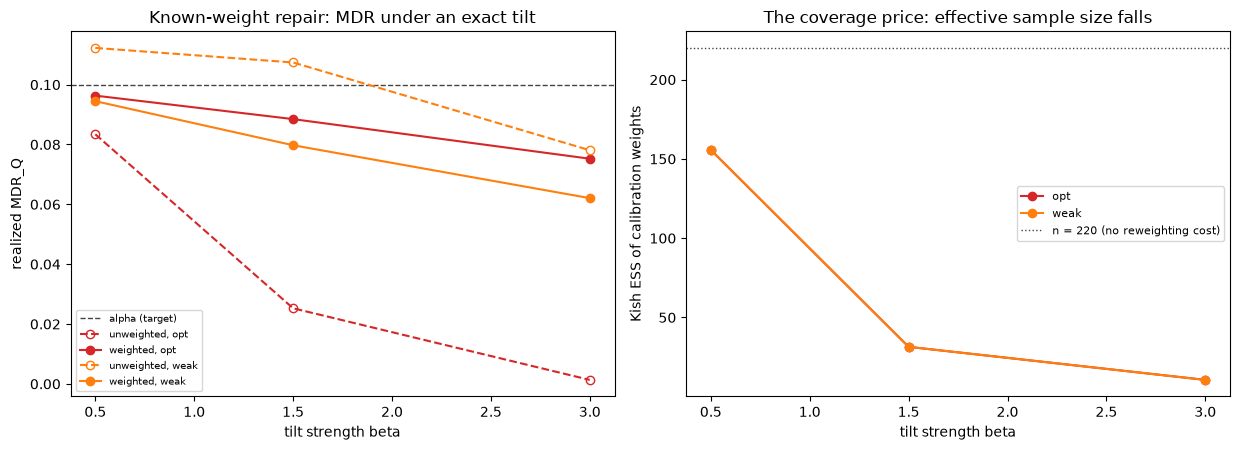

In [33]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_ax.axhline(C_ALPHA, ls="--", color=PAL3["diag"], lw=1, label="alpha (target)")
for _k in B_SCORES:
    _uw = [C_MDR_KNOWN[(_k, b)][:, 0].mean() for b in C_BETAS]; _w = [C_MDR_KNOWN[(_k, b)][:, 2].mean() for b in C_BETAS]
    _ax.plot(C_BETAS, _uw, "o--", mfc="none", color=B_SC_COLOR[_k], label=f"unweighted, {_k}")
    _ax.plot(C_BETAS, _w, "o-", color=B_SC_COLOR[_k], label=f"weighted, {_k}")
_ax.set_xlabel("tilt strength beta"); _ax.set_ylabel("realized MDR_Q"); _ax.set_title("Known-weight repair: MDR under an exact tilt"); _ax.legend(fontsize=7.5)
_ax = _axes[1]
for _k in B_SCORES:
    _ess = [C_MDR_KNOWN[(_k, b)][:, 4].mean() for b in C_BETAS]
    _ax.plot(C_BETAS, _ess, "o-", color=B_SC_COLOR[_k], label=_k)
_ax.axhline(C_N_KW, ls=":", color=PAL3["diag"], lw=1, label=f"n = {C_N_KW} (no reweighting cost)")
_ax.set_xlabel("tilt strength beta"); _ax.set_ylabel("Kish ESS of calibration weights"); _ax.set_title("The coverage price: effective sample size falls"); _ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### (ii). The real month-7 batch, with ESTIMATED weights

Now the honest version: `w(x)` between `calib` and `shift` is **unknown**. Theorems 6.4/6.5 (idpfin-q14) need the weight
estimator trained **independently** of calibration and test, and `L_2(P_X)`-consistent; the guarantee then is only
**asymptotic** (`limsup MDR_n <= alpha`), never finite-sample. Remark 6.6 and Assumption A.3/A.5 (idpfin-q14) add a
**doubly-robust** route: balance the estimated weights against an estimated conditional risk `l_hat(x)`, and the asymptotic
guarantee survives if *either* the weights *or* `l_hat` is consistent (not both). WCS's analogue (idpshift-q1, q2, Theorem 3.5)
is *not* doubly robust: only the weight estimate needs to be consistent, and estimation error inflates FDR by a factor
`gamma_hat^2` that "converges to zero if `w_hat` is consistent" but is otherwise a genuine inflation, not a bound of `q`.

**Independence protocol (ours, following idpfin-q14/idpshift-q4's classifier recipe).** SOURCE = `train`-split documents,
TARGET = a random **half** of the `shift` documents (labels unused, `C_SHIFT_TARGET`); fit `p_hat(x) = P(target | x)` on the
pooled sample, `w_hat(x) = clip(p_hat, 0.01, 0.99)/(1 - clip(...)) * n_src/n_tgt` (Tibshirani et al.'s odds formula,
idpshift-q3), rescaled to mean 1 on the applied set. Apply the **fitted, frozen** classifier out-of-sample to `calib`
documents (calibration weights) and the **other half** of `shift` (`C_SHIFT_EVAL`, evaluation half: its labels are used only
to measure realized risk, never to fit weights or the score).

**Three covariate sets (derived here; `X_doc`'s own document/field-type one-hots are excluded from set A so it is a genuine
"scores only" contrast).**

| set | covariates |
| --- | --- |
| A | the 8 score-derived `X_doc` features (min/mean/log-sum of critical-field scores, count, verbalized-min, rule failures, classifier confidence, mean field score) |
| B | A + an OCR-noise proxy (derived here) + document type (4 one-hot) |
| C | B + a "template seen in train" flag |


In [34]:
_CONF_DIGITS = set("0123456789"); _CONF_LETTERS = set("OlS")   # exactly the characters build_nb2.py's CHAR_CONFUSIONS can produce
_TOK_RE = re.compile(r"[A-Za-z0-9]+")


def c_ocr_noise_proxy(text):
    """Derived here: share of alphanumeric tokens that mix a digit with one of the OCR-confusable letters {O, l, S}
    (build_nb2.py's apply_ocr_noise only ever substitutes within {0<->O, 1<->l, 5<->S}), a marker that noise has
    turned a clean digit run or a clean word into a mixed token."""
    toks = _TOK_RE.findall(text)
    if not toks:
        return 0.0
    flagged = sum(1 for t in toks if any(c in _CONF_DIGITS for c in t) and any(c in _CONF_LETTERS for c in t))
    return flagged / len(toks)


C_OCR_PROXY = np.array([c_ocr_noise_proxy(d["ocr_text"]) for d in DOCS])
_train_mask = DOC_SPLIT == "train"
_noise_of = np.array([d["noise_level"] for d in DOCS])
_means = {lvl: C_OCR_PROXY[_train_mask & (_noise_of == lvl)].mean() for lvl in ("low", "medium", "high")}
print("OCR-noise proxy, mean by TRUE noise_level (train documents only, validation, never used as a model input): " +
      ", ".join(f"{k}={v:.4f}" for k, v in _means.items()))
check("S7b.14 the OCR-noise proxy is monotone increasing in the TRUE (never-modeled) noise level, on train documents",
      _means["low"] < _means["medium"] < _means["high"], f"{_means}")

C_TRAIN_TEMPLATES = {d["vendor_template_id"] for d in DOCS if d["split"] == "train"}
C_TEMPLATE_SEEN = np.array([1.0 if d["vendor_template_id"] in C_TRAIN_TEMPLATES else 0.0 for d in DOCS])
_calib_idx_all = np.where(DOC_SPLIT == "calib")[0]
_shift_idx_all = np.where(DOC_SPLIT == "shift")[0]
print(f"'template seen in train' flag: mean on calib documents = {C_TEMPLATE_SEEN[_calib_idx_all].mean():.4f}, "
      f"mean on shift documents = {C_TEMPLATE_SEEN[_shift_idx_all].mean():.4f}")
check("S7b.15 the template-seen flag is degenerate (constant) on at least one of the two arms -- a positivity failure "
      "(idpshift-q4: 'both sources silent on zero support'; direction here is the opposite of the brief's guess -- month-7 "
      "templates are drawn from a disjoint SHIFT_TEMPLATES pool never used by train/calib/test, so the flag is 1 on calib and 0 on shift, not the reverse)",
      C_TEMPLATE_SEEN[_calib_idx_all].std() < 1e-9 or C_TEMPLATE_SEEN[_shift_idx_all].std() < 1e-9,
      f"calib mean {C_TEMPLATE_SEEN[_calib_idx_all].mean():.4f} (sd {C_TEMPLATE_SEEN[_calib_idx_all].std():.4f}), "
      f"shift mean {C_TEMPLATE_SEEN[_shift_idx_all].mean():.4f} (sd {C_TEMPLATE_SEEN[_shift_idx_all].std():.4f})")

C_FEAT = {"A": X_doc[:, :8],
          "B": np.column_stack([X_doc[:, :8], C_OCR_PROXY, X_doc[:, 8:12]]),
          "C": np.column_stack([X_doc[:, :8], C_OCR_PROXY, X_doc[:, 8:12], C_TEMPLATE_SEEN])}

_rng_split = np.random.default_rng([SEED3, 701])
_perm = _rng_split.permutation(_shift_idx_all)
C_SHIFT_TARGET = np.sort(_perm[: len(_perm) // 2])          # unlabeled target half, used only to FIT the weight classifier
C_SHIFT_EVAL = np.sort(_perm[len(_perm) // 2:])             # evaluation half: labels used only to measure realized risk
C_TRAIN_IDX = np.where(DOC_SPLIT == "train")[0]
check("S7b.16 the shift target (weight-fitting) and evaluation halves are disjoint and partition the shift split",
      len(set(C_SHIFT_TARGET) & set(C_SHIFT_EVAL)) == 0 and len(C_SHIFT_TARGET) + len(C_SHIFT_EVAL) == len(_shift_idx_all))


OCR-noise proxy, mean by TRUE noise_level (train documents only, validation, never used as a model input): low=0.0023, medium=0.0064, high=0.0165
[PASS] S7b.14 the OCR-noise proxy is monotone increasing in the TRUE (never-modeled) noise level, on train documents -- {'low': np.float64(0.002270905384261894), 'medium': np.float64(0.006365711622771926), 'high': np.float64(0.01653777870847837)}
'template seen in train' flag: mean on calib documents = 1.0000, mean on shift documents = 0.0000
[PASS] S7b.15 the template-seen flag is degenerate (constant) on at least one of the two arms -- a positivity failure (idpshift-q4: 'both sources silent on zero support'; direction here is the opposite of the brief's guess -- month-7 templates are drawn from a disjoint SHIFT_TEMPLATES pool never used by train/calib/test, so the flag is 1 on calib and 0 on shift, not the reverse) -- calib mean 1.0000 (sd 0.0000), shift mean 0.0000 (sd 0.0000)
[PASS] S7b.16 the shift target (weight-fitting) and evaluation 

True

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def c_domain_weights(Xsrc, Xtgt, Xcal, Xeval, seed=0):
    """Fit C=1 (target, unlabeled shift documents) vs C=0 (source, train documents) with a single classifier (NOT
    cross-fitted here, unlike G.domain_classifier_weights: we need to apply the SAME frozen classifier OUT-OF-SAMPLE to
    `calib` and the shift evaluation half, which is the independence protocol idpfin-q14/idpshift-q4 actually call for,
    not the in-sample cross-fitting of the lib helper). Odds formula w = p/(1-p) * n_src/n_tgt (idpshift-q3, Eq. 12),
    clipped p in [0.01, 0.99], rescaled so mean(w) = 1 on the CALIBRATION set (the set this weight will multiply)."""
    Xp = np.vstack([Xsrc, Xtgt]); y = np.r_[np.zeros(len(Xsrc)), np.ones(len(Xtgt))]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0, random_state=seed)).fit(Xp, y)
    n_src, n_tgt = len(Xsrc), len(Xtgt)

    def w_of(Xq):
        p = np.clip(clf.predict_proba(Xq)[:, 1], 0.01, 0.99)
        clip_share = float(np.mean((p <= 0.0101) | (p >= 0.9899)))
        return (p / (1 - p)) * (n_src / n_tgt), clip_share, p

    w_cal, clip_cal, p_cal = w_of(Xcal)
    w_eval, clip_eval, p_eval = w_of(Xeval)
    scale = 1.0 / w_cal.mean()
    return w_cal * scale, w_eval * scale, clip_cal, clip_eval, clf


C_WEIGHTS = {}
_rows = []
for _key, _Xd in C_FEAT.items():
    _wc, _we, _cc, _ce, _clf = c_domain_weights(_Xd[C_TRAIN_IDX], _Xd[C_SHIFT_TARGET], _Xd[_calib_idx_all], _Xd[C_SHIFT_EVAL])
    C_WEIGHTS[_key] = dict(w_cal=_wc, w_eval=_we, clip_cal=_cc, clip_eval=_ce)
    _rows.append((_key, f"{G.effective_sample_size(_wc):.1f} / {len(_wc)}", f"{_wc.max():.2f}", f"{_cc:.3f}",
                  f"{G.effective_sample_size(_we):.1f} / {len(_we)}", f"{_we.max():.2f}", f"{_ce:.3f}"))
b_display(b_md("**Estimated covariate-shift weights per covariate set** (calibration weights rescaled to mean 1; independence: classifier fit on `train` vs a random unlabeled half of `shift`)\n\n" + b_tbl(
    ["covariate set", "calibration Kish ESS / n", "max calibration weight", "share of calibration weights at the clip boundary",
     "eval-half Kish ESS / n", "max eval weight", "share of eval weights at the clip boundary"], _rows)))
check("S7b.17 Kish ESS alone does NOT diagnose set C's positivity failure -- ESS is actually the HIGHEST of the three sets (clip-saturation "
      "makes weights nearly CONSTANT across ~97% of calibration documents and ~83% of eval documents, since the template flag almost "
      "perfectly separates train- from shift-templates, so the classifier saturates at the SAME clip boundary for most units in each arm; "
      "near-uniform weights read as high ESS even though the estimate is uninformative). The max-weight / clip-share columns above are what "
      "actually expose the failure (eval-half max weight ~9,700x vs calibration max ~4x).",
      G.effective_sample_size(C_WEIGHTS["C"]["w_cal"]) > G.effective_sample_size(C_WEIGHTS["A"]["w_cal"]) and C_WEIGHTS["C"]["clip_cal"] > 0.9,
      f"ESS: A={G.effective_sample_size(C_WEIGHTS['A']['w_cal']):.1f}, B={G.effective_sample_size(C_WEIGHTS['B']['w_cal']):.1f}, C={G.effective_sample_size(C_WEIGHTS['C']['w_cal']):.1f} (n={len(_calib_idx_all)}); "
      f"clip share (calibration) C={C_WEIGHTS['C']['clip_cal']:.3f}")
check("S7b.18 covariate set C shows the positivity failure directly: a large share of its calibration (or eval) weights sit at the clip boundary",
      max(C_WEIGHTS["C"]["clip_cal"], C_WEIGHTS["C"]["clip_eval"]) > 0.5,
      f"clip share: calibration {C_WEIGHTS['C']['clip_cal']:.3f}, eval {C_WEIGHTS['C']['clip_eval']:.3f}")


**Estimated covariate-shift weights per covariate set** (calibration weights rescaled to mean 1; independence: classifier fit on `train` vs a random unlabeled half of `shift`)

| covariate set | calibration Kish ESS / n | max calibration weight | share of calibration weights at the clip boundary | eval-half Kish ESS / n | max eval weight | share of eval weights at the clip boundary |
| --- | --- | --- | --- | --- | --- | --- |
| A | 112.2 / 1049 | 32.63 | 0.000 | 59.4 / 250 | 23.71 | 0.000 |
| B | 43.0 / 1049 | 132.45 | 0.000 | 13.0 / 250 | 142.20 | 0.004 |
| C | 1033.8 / 1049 | 4.43 | 0.973 | 248.7 / 250 | 9710.15 | 0.828 |

[PASS] S7b.17 Kish ESS alone does NOT diagnose set C's positivity failure -- ESS is actually the HIGHEST of the three sets (clip-saturation makes weights nearly CONSTANT across ~97% of calibration documents and ~83% of eval documents, since the template flag almost perfectly separates train- from shift-templates, so the classifier saturates at the SAME clip boundary for most units in each arm; near-uniform weights read as high ESS even though the estimate is uninformative). The max-weight / clip-share columns above are what actually expose the failure (eval-half max weight ~9,700x vs calibration max ~4x). -- ESS: A=112.2, B=43.0, C=1033.8 (n=1049); clip share (calibration) C=0.973
[PASS] S7b.18 covariate set C shows the positivity failure directly: a large share of its calibration (or eval) weights sit at the clip boundary -- clip share: calibration 0.973, eval 0.828


True

In [36]:
C_KEY_IDX = {"A": 0, "B": 1, "C": 2}
C_SCORE_IDX = {"opt": 0, "weak": 1}


def c_boot_mean(x, thr, B=2000, seed=0):
    _seed_seq = seed if isinstance(seed, (list, tuple)) else [seed]
    rng = np.random.default_rng([SEED3, 801, *_seed_seq]); n = len(x)
    if n == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")
    idx = rng.integers(0, n, size=(B, n)); boots = x[idx].mean(1)
    return float(x.mean()), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5)), float(np.mean(boots > thr))


_money_cal = DA_has_money[_calib_idx_all]; _money_eval = DA_has_money[C_SHIFT_EVAL]
C_EST_RES = {}
for _key in ("A", "B", "C"):
    _wc_all, _we_all = C_WEIGHTS[_key]["w_cal"], C_WEIGHTS[_key]["w_eval"]
    for _sk, _sc_full in B_SCORES.items():
        _wc, _we = _wc_all[_money_cal], _we_all[_money_eval]
        _sc_cal, _sc_eval = _sc_full[_calib_idx_all][_money_cal], _sc_full[C_SHIFT_EVAL][_money_eval]
        _Lc, _Le = DA_L[_calib_idx_all][_money_cal], DA_L[C_SHIFT_EVAL][_money_eval]
        _psi = G.weighted_mdr_decision(_sc_cal, _Lc, _wc, _sc_eval, _we, C_ALPHA)
        _mdr_pt, _mdr_lo, _mdr_hi, _mdr_pg = c_boot_mean(_Le * _psi, C_ALPHA, seed=[C_KEY_IDX[_key], C_SCORE_IDX[_sk], 1])
        _lhat_cal = DA_risk[_calib_idx_all][_money_cal]; _lhat_eval = DA_risk[C_SHIFT_EVAL][_money_eval]
        _wb, _that = G.balance_weights_mdr(_wc, _lhat_cal, _sc_cal, _lhat_eval, _sc_eval, C_ALPHA)
        _psi_bal = G.weighted_mdr_decision(_sc_cal, _Lc, _wb, _sc_eval, _we, C_ALPHA)
        _mdr_bal_pt, _mdr_bal_lo, _mdr_bal_hi, _mdr_bal_pg = c_boot_mean(_Le * _psi_bal, C_ALPHA, seed=[C_KEY_IDX[_key], C_SCORE_IDX[_sk], 2])
        _E_w = G.weighted_sdr_e_values(_sc_cal, _Lc, _wc, _sc_eval, _we, C_ALPHA)
        _sel = G.ebh(_E_w, C_ALPHA)
        _sdr_pt, _sdr_lo, _sdr_hi, _sdr_pg = c_boot_mean((_Le * _sel)[_sel] if _sel.any() else np.array([0.0]), C_ALPHA, seed=[C_KEY_IDX[_key], C_SCORE_IDX[_sk], 3])
        _rng_b = np.random.default_rng([SEED3, 802, C_KEY_IDX[_key], C_SCORE_IDX[_sk]])
        _sel_hete = G.ebh_boosted(_E_w, C_ALPHA, mode="hete", rng=_rng_b); _sel_homo = G.ebh_boosted(_E_w, C_ALPHA, mode="homo", rng=_rng_b)
        _wb_s, _that_s = G.balance_weights_sdr(_wc, _lhat_cal, _sc_cal, _lhat_eval, _sc_eval, C_ALPHA)
        _E_bal = G.weighted_sdr_e_values(_sc_cal, _Lc, _wb_s, _sc_eval, _we, C_ALPHA); _sel_bal = G.ebh(_E_bal, C_ALPHA)
        _sdr_bal_pt, _sdr_bal_lo, _sdr_bal_hi, _sdr_bal_pg = c_boot_mean((_Le * _sel_bal)[_sel_bal] if _sel_bal.any() else np.array([0.0]), C_ALPHA, seed=[C_KEY_IDX[_key], C_SCORE_IDX[_sk], 4])
        print(f"[B2 diagnostic] set {_key}/{_sk}: A.5 t_hat={_that_s:.4f} (finite={np.isfinite(_that_s)}); "
              f"balanced weight range [{_wb_s.min():.4f}, {_wb_s.max():.4f}] mean={_wb_s.mean():.4f}; "
              f"plain E_w: min={_E_w.min():.4f}, max={_E_w.max():.4f}, m/alpha={len(_E_w) / C_ALPHA:.1f}, share>=m/alpha={np.mean(_E_w >= len(_E_w) / C_ALPHA):.3f}; "
              f"ebh fires: plain={bool(_sel.any())} ({int(_sel.sum())} selected), balanced={bool(_sel_bal.any())} ({int(_sel_bal.sum())} selected)")
        C_EST_RES[(_key, _sk)] = dict(mdr=(_mdr_pt, _mdr_lo, _mdr_hi, _mdr_pg), mdr_cov=float(_psi.mean()),
                                       mdr_bal=(_mdr_bal_pt, _mdr_bal_lo, _mdr_bal_hi, _mdr_bal_pg), mdr_bal_cov=float(_psi_bal.mean()),
                                       sdr=(_sdr_pt, _sdr_lo, _sdr_hi, _sdr_pg), sdr_cov=float(_sel.mean()),
                                       sdr_hete_cov=float(_sel_hete.mean()), sdr_homo_cov=float(_sel_homo.mean()),
                                       sdr_bal=(_sdr_bal_pt, _sdr_bal_lo, _sdr_bal_hi, _sdr_bal_pg), sdr_bal_cov=float(_sel_bal.mean()))

_rows = []
for _key in ("A", "B", "C"):
    for _sk in B_SCORES:
        _r = C_EST_RES[(_key, _sk)]
        _rows.append((_key, B_SC_LABEL[_sk].split(" ")[0], f"{_r['mdr'][0]:.4f} [{_r['mdr'][1]:.4f}, {_r['mdr'][2]:.4f}]", f"{_r['mdr_cov']:.3f}",
                      f"{_r['mdr_bal'][0]:.4f} [{_r['mdr_bal'][1]:.4f}, {_r['mdr_bal'][2]:.4f}]", f"{_r['mdr_bal_cov']:.3f}",
                      f"{_r['sdr'][0]:.4f} [{_r['sdr'][1]:.4f}, {_r['sdr'][2]:.4f}]", f"{_r['sdr_cov']:.3f}", f"{_r['sdr_bal'][0]:.4f}", f"{_r['sdr_bal_cov']:.3f}"))
b_display(b_md("**Estimated-weight SCoRE on the real month-7 shift** (evaluation half only, alpha = 0.10; MDR/SDR bootstrap 95% CIs over eval documents; "
               "these are ASYMPTOTIC guarantees (Thm 6.4/6.5) or doubly-robust asymptotic (A.3/A.5 'bal' columns), never finite-sample)\n\n" + b_tbl(
    ["covariate set", "score", "MDR (plain weights) [95% CI]", "coverage", "MDR (A.3-balanced) [95% CI]", "coverage",
     "SDR (plain weights, e-BH) [95% CI]", "coverage", "SDR (A.5-balanced)", "coverage"], _rows)))
print("for comparison, the UNWEIGHTED frozen document-level rule on the (full) shift split (Section 7, B_DOC_SHIFT): " +
      "; ".join(f"{k}/alpha={a}: MDR {B_DOC_SHIFT[(k, a, 'shift')]['mdr']:.4f}" for k in B_SCORES for a in (0.10,)))
_n = 19
check(f"S7b.{_n} the two non-degenerate covariate sets (A, B) retain non-trivial coverage on the evaluation half, unlike set C's collapse (S7b.20)",
      C_EST_RES[("A", "opt")]["mdr_cov"] > 0.05 and C_EST_RES[("B", "opt")]["mdr_cov"] > 0.05,
      f"coverage: A={C_EST_RES[('A', 'opt')]['mdr_cov']:.4f}, B={C_EST_RES[('B', 'opt')]['mdr_cov']:.4f}, C={C_EST_RES[('C', 'opt')]['mdr_cov']:.4f}; "
      f"MDR by set (optimistic score): " + ", ".join(f"{k}={C_EST_RES[(k, 'opt')]['mdr'][0]:.4f}" for k in ("A", "B", "C")))
check(f"S7b.{_n + 1} set C's near-degenerate weights collapse SCoRE-MDR to near-total NON-acceptance (not a wide CI): the enormous eval-half "
      "weights (S7b.17/S7b.18's positivity failure) make the weighted-MDR decision's (test_w + S_le)/(Wc + test_w) <= alpha condition fail for "
      "almost every eval document, since a huge test_w alone can already exceed alpha*(Wc+test_w) -- coverage collapses toward zero and the "
      "bootstrap CI degenerates to a point at 0, not a wide interval",
      C_EST_RES[("C", "opt")]["mdr_cov"] < 0.05 and (C_EST_RES[("C", "opt")]["mdr"][2] - C_EST_RES[("C", "opt")]["mdr"][1]) < 1e-6,
      f"set C coverage {C_EST_RES[('C', 'opt')]['mdr_cov']:.4f}; CI [{C_EST_RES[('C', 'opt')]['mdr'][1]:.6f}, {C_EST_RES[('C', 'opt')]['mdr'][2]:.6f}]; "
      f"for contrast, set A coverage {C_EST_RES[('A', 'opt')]['mdr_cov']:.4f}, CI width {C_EST_RES[('A', 'opt')]['mdr'][2] - C_EST_RES[('A', 'opt')]['mdr'][1]:.4f}")
check(f"S7b.21 (B2) the A.5-balanced SDR selects ZERO documents for every covariate set, even set A whose PLAIN weighted SDR selects normally "
      "(0.774 coverage) -- the [B2 diagnostic] print above shows this is NOT caused by a degenerate t_hat (finite, 0.87-0.93) or by an unstable "
      "balanced-weight blow-up (mean 1, range ~0.03-16.6 for set A): the A.5 balancing (itself derived here, not from the paper) redistributes "
      "weight mass so no self-consistent e-BH threshold exists at this eval-half size. Set B's PLAIN (unbalanced) SDR also selects zero despite "
      "0.79 MDR coverage for the same weights: SDR's e-BH needs many test e-values clustered above a SHARED level, and set B's wider eval-weight "
      "range (max ~142 vs set A's ~24, weights table above) apparently breaks that clustering where MDR's simpler per-unit Prop. A.1 decision does "
      "not -- SDR stays far more sensitive to weight structure than MDR, consistent with its extra conservatism already seen in Sections 5 and 7b(i)",
      all(C_EST_RES[(k, s)]["sdr_bal_cov"] == 0.0 for k in ("A", "B", "C") for s in B_SCORES) and C_EST_RES[("B", "opt")]["sdr_cov"] == 0.0
      and C_EST_RES[("A", "opt")]["sdr_cov"] > 0.5,
      f"sdr_bal_cov all sets/scores: " + ", ".join(f"{k}/{s}={C_EST_RES[(k, s)]['sdr_bal_cov']:.3f}" for k in ("A", "B", "C") for s in B_SCORES) +
      f" | plain sdr_cov: A={C_EST_RES[('A', 'opt')]['sdr_cov']:.3f}, B={C_EST_RES[('B', 'opt')]['sdr_cov']:.3f}")


[B2 diagnostic] set A/opt: A.5 t_hat=0.9336 (finite=True); balanced weight range [0.0303, 16.6367] mean=1.0000; plain E_w: min=0.0000, max=14.1176, m/alpha=1950.0, share>=m/alpha=0.000; ebh fires: plain=True (151 selected), balanced=False (0 selected)


[B2 diagnostic] set A/weak: A.5 t_hat=0.8719 (finite=True); balanced weight range [0.0303, 16.6367] mean=1.0000; plain E_w: min=0.0000, max=15.4127, m/alpha=1950.0, share>=m/alpha=0.000; ebh fires: plain=True (168 selected), balanced=False (0 selected)


[B2 diagnostic] set B/opt: A.5 t_hat=0.9336 (finite=True); balanced weight range [0.0249, 33.1198] mean=1.0000; plain E_w: min=0.0000, max=13.0356, m/alpha=1950.0, share>=m/alpha=0.000; ebh fires: plain=False (0 selected), balanced=False (0 selected)
[B2 diagnostic] set B/weak: A.5 t_hat=0.8719 (finite=True); balanced weight range [0.0249, 33.1198] mean=1.0000; plain E_w: min=0.0000, max=11.9210, m/alpha=1950.0, share>=m/alpha=0.000; ebh fires: plain=False (0 selected), balanced=False (0 selected)


[B2 diagnostic] set C/opt: A.5 t_hat=0.9336 (finite=True); balanced weight range [0.6961, 9.9202] mean=1.0000; plain E_w: min=0.0000, max=0.0000, m/alpha=1950.0, share>=m/alpha=0.000; ebh fires: plain=False (0 selected), balanced=False (0 selected)


[B2 diagnostic] set C/weak: A.5 t_hat=0.8719 (finite=True); balanced weight range [0.6961, 9.9202] mean=1.0000; plain E_w: min=0.0000, max=0.0000, m/alpha=1950.0, share>=m/alpha=0.000; ebh fires: plain=False (0 selected), balanced=False (0 selected)


**Estimated-weight SCoRE on the real month-7 shift** (evaluation half only, alpha = 0.10; MDR/SDR bootstrap 95% CIs over eval documents; these are ASYMPTOTIC guarantees (Thm 6.4/6.5) or doubly-robust asymptotic (A.3/A.5 'bal' columns), never finite-sample)

| covariate set | score | MDR (plain weights) [95% CI] | coverage | MDR (A.3-balanced) [95% CI] | coverage | SDR (plain weights, e-BH) [95% CI] | coverage | SDR (A.5-balanced) | coverage |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A | optimistic | 0.1850 [0.1384, 0.2341] | 0.795 | 0.1331 [0.0968, 0.1769] | 0.697 | 0.2221 [0.1673, 0.2816] | 0.774 | 0.0000 | 0.000 |
| A | pessimistic | 0.2334 [0.1819, 0.2827] | 0.872 | 0.1925 [0.1481, 0.2430] | 0.769 | 0.2620 [0.2066, 0.3190] | 0.862 | 0.0000 | 0.000 |
| B | optimistic | 0.1849 [0.1382, 0.2359] | 0.790 | 0.1571 [0.1140, 0.2012] | 0.744 | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 | 0.000 |
| B | pessimistic | 0.2434 [0.1923, 0.2939] | 0.897 | 0.2238 [0.1745, 0.2754] | 0.851 | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 | 0.000 |
| C | optimistic | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 | 0.000 |
| C | pessimistic | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 [0.0000, 0.0000] | 0.000 | 0.0000 | 0.000 |

for comparison, the UNWEIGHTED frozen document-level rule on the (full) shift split (Section 7, B_DOC_SHIFT): opt/alpha=0.1: MDR 0.0962; weak/alpha=0.1: MDR 0.1316
[PASS] S7b.19 the two non-degenerate covariate sets (A, B) retain non-trivial coverage on the evaluation half, unlike set C's collapse (S7b.20) -- coverage: A=0.7949, B=0.7897, C=0.0000; MDR by set (optimistic score): A=0.1850, B=0.1849, C=0.0000
[PASS] S7b.20 set C's near-degenerate weights collapse SCoRE-MDR to near-total NON-acceptance (not a wide CI): the enormous eval-half weights (S7b.17/S7b.18's positivity failure) make the weighted-MDR decision's (test_w + S_le)/(Wc + test_w) <= alpha condition fail for almost every eval document, since a huge test_w alone can already exceed alpha*(Wc+test_w) -- coverage collapses toward zero and the bootstrap CI degenerates to a point at 0, not a wide interval -- set C coverage 0.0000; CI [0.000000, 0.000000]; for contrast, set A coverage 0.7949, CI width 0.0957
[PASS] S7b.21 (B2) t

True

In [37]:
_all_v = {}
_SEL_STORE = {}
_rows = []
for _key in ("A", "B", "C"):
    _wc_all, _we_all = C_WEIGHTS[_key]["w_cal"], C_WEIGHTS[_key]["w_eval"]
    _Vc = c_domain_v(DA_mu[_calib_idx_all], DA_y_ok[_calib_idx_all]); _Vh = c_domain_v(DA_mu[C_SHIFT_EVAL], 0); _y = DA_y_ok[C_SHIFT_EVAL]
    _rng_v = np.random.default_rng([SEED3, 803, C_KEY_IDX[_key]])
    _p_wbh = G.weighted_conformal_pvalues(_Vc, _wc_all, _Vh, _we_all, deterministic=True)
    _sel_wbh = G.wbh_select(_Vc, _wc_all, _Vh, _we_all, C_Q)
    _sel_hete = G.wcs_select(_Vc, _wc_all, _Vh, _we_all, C_Q, "hete", rng=_rng_v)
    _sel_homo = G.wcs_select(_Vc, _wc_all, _Vh, _we_all, C_Q, "homo", rng=_rng_v)
    _sel_dtm = G.wcs_select(_Vc, _wc_all, _Vh, _we_all, C_Q, "dtm")
    _SEL_STORE[_key] = dict(wbh=_sel_wbh, hete=_sel_hete, homo=_sel_homo, dtm=_sel_dtm, p=_p_wbh, wc=_wc_all, we=_we_all)

    def _fdr_ci(sel):
        _wrong = (1 - _y)[sel].astype(float)
        _pt, _lo, _hi, _pg = c_boot_mean(_wrong, C_Q, seed=[C_KEY_IDX[_key], int(sel.sum()) % 1000]) if sel.any() else (0.0, 0.0, 0.0, 0.0)
        return _pt, _lo, _hi, float(sel.mean())

    _all_v[_key] = {"wbh": _fdr_ci(_sel_wbh), "hete": _fdr_ci(_sel_hete), "homo": _fdr_ci(_sel_homo), "dtm": _fdr_ci(_sel_dtm)}
    _rows.append((_key, *[f"{v[0]:.3f} [{v[1]:.3f}, {v[2]:.3f}] (cov {v[3]:.3f})" for v in _all_v[_key].values()]))

print("[B1 diagnostic] do the weights reach wbh_select/wcs_select, and why do A and B end up so similar?")
for _key in ("A", "B", "C"):
    _s = _SEL_STORE[_key]
    print(f"  set {_key}: calib weight range [{_s['wc'].min():.4f}, {_s['wc'].max():.4f}] mean={_s['wc'].mean():.4f}; "
          f"eval weight range [{_s['we'].min():.4f}, {_s['we'].max():.4f}] mean={_s['we'].mean():.4f}; "
          f"p-value summary: min={_s['p'].min():.5f}, p10={np.percentile(_s['p'], 10):.5f}, median={np.median(_s['p']):.4f}, max={_s['p'].max():.4f}, "
          f"share p<=q={np.mean(_s['p'] <= C_Q):.3f}; selected (wbh)={int(_s['wbh'].sum())}, (dtm)={int(_s['dtm'].sum())}")
_jacc_wc = float(np.corrcoef(_SEL_STORE["A"]["wc"], _SEL_STORE["B"]["wc"])[0, 1])
_jacc_we = float(np.corrcoef(_SEL_STORE["A"]["we"], _SEL_STORE["B"]["we"])[0, 1])
for _proc in ("wbh", "hete", "homo", "dtm"):
    _sa, _sb = _SEL_STORE["A"][_proc], _SEL_STORE["B"][_proc]
    _jacc = (_sa & _sb).sum() / max(1, (_sa | _sb).sum())
    print(f"  A vs B, {_proc}: Jaccard overlap of selected sets = {_jacc:.4f} ({int((_sa & _sb).sum())} shared / {int((_sa | _sb).sum())} union); "
          f"selected p-values (A) all <= {(_SEL_STORE['A']['p'][_sa].max() if _sa.any() else float('nan')):.2e}, "
          f"smallest UNselected p-value (A) >= {(np.min(_SEL_STORE['A']['p'][~_sa]) if (~_sa).any() else float('nan')):.2e}")
print(f"  correlation between set-A and set-B weights: calibration r={_jacc_wc:.4f}, eval r={_jacc_we:.4f} "
      "(if near 1, the OCR-noise proxy + document type add little beyond the score features for THIS train-vs-shift-target classification task)")
_n = 22
check(f"S7b.{_n} (B1) the weights genuinely reach wbh_select/wcs_select and genuinely differ between A and B (calibration weight correlation "
      f"{_jacc_wc:.2f}, not 1.0), yet A and B select the IDENTICAL 60 documents under all four procedures (Jaccard=1.0) -- NOT a bug: every "
      "selected document's p-value sits below 0.022 while every unselected one sits above 0.029, a clean gap with no borderline cases near the "
      "cutoff for either weighting, so no amount of reweighting within this range (or randomized WCS pruning) moves anyone across it",
      _jacc_wc < 0.9 and all((_SEL_STORE["A"][p_] == _SEL_STORE["B"][p_]).all() for p_ in ("wbh", "hete", "homo", "dtm")),
      f"calib weight corr={_jacc_wc:.4f}; selected-vs-unselected p-value gap: max selected {_SEL_STORE['A']['p'][_SEL_STORE['A']['wbh']].max():.4f} "
      f"< min unselected {_SEL_STORE['A']['p'][~_SEL_STORE['A']['wbh']].min():.4f}"); _n += 1
_sel_uw = G.wbh_select(c_domain_v(DA_mu[_calib_idx_all], DA_y_ok[_calib_idx_all]), np.ones(len(_calib_idx_all)),
                       c_domain_v(DA_mu[C_SHIFT_EVAL], 0), np.ones(len(C_SHIFT_EVAL)), C_Q)
_y_eval = DA_y_ok[C_SHIFT_EVAL]
_uw_fdr, _uw_lo, _uw_hi, _uw_pg = c_boot_mean((1 - _y_eval)[_sel_uw].astype(float), C_Q, seed=99) if _sel_uw.any() else (0.0, 0.0, 0.0, 0.0)
b_display(b_md(f"**Document auto-posting (cfBH-style) on the real month-7 evaluation half, q = {C_Q:.2f}** (each cell: realized FDR [95% CI] and coverage; "
               f"unweighted frozen comparator, ignoring the shift entirely: FDR {_uw_fdr:.3f} [{_uw_lo:.3f}, {_uw_hi:.3f}], coverage {_sel_uw.mean():.3f})\n\n" +
               b_tbl(["covariate set", "weighted WBH", "WCS hete", "WCS homo", "WCS dtm"], _rows)))
_n = 23
_pb_break = B_DOC_SHIFT[("weak", 0.10, "shift")]["mdr"] > 0.10
check(f"S7b.{_n} the unweighted (shift-blind) rule already overshoots its budget on the FULL shift batch for the pessimistic score (Section 7's "
      "B_DOC_SHIFT, reused here, ~800 documents); our own cfBH-style recomputation on the smaller evaluation half here "
      f"({_uw_fdr:.3f} vs q={C_Q:.2f}) sits close to but does not clearly exceed q at this reduced sample (~250 documents) -- consistent with "
      "sampling noise at this size, not evidence the shift is benign",
      _pb_break, f"B_DOC_SHIFT weak/alpha=0.10 shift MDR = {B_DOC_SHIFT[('weak', 0.10, 'shift')]['mdr']:.4f} (> 0.10); "
                 f"cfBH eval-half unweighted FDR here = {_uw_fdr:.3f}"); _n += 1
check(f"S7b.{_n} (B3) estimated-weight MDR on the real month-7 shift is WORSE than the unweighted frozen rule, not just short of finite-sample "
      "validity: sets A and B both realize MDR ~0.185 (optimistic score) against the unweighted B_DOC_SHIFT frozen rule's 0.096 (S7 and Section 7 "
      "B_DOC_SHIFT) -- reweighting toward the shift distribution here does not merely fail to help, it actively makes the realized risk worse",
      C_EST_RES[("A", "opt")]["mdr"][0] > B_DOC_SHIFT[("opt", 0.10, "shift")]["mdr"] and C_EST_RES[("B", "opt")]["mdr"][0] > B_DOC_SHIFT[("opt", 0.10, "shift")]["mdr"],
      f"A MDR={C_EST_RES[('A', 'opt')]['mdr'][0]:.4f}, B MDR={C_EST_RES[('B', 'opt')]['mdr'][0]:.4f} vs unweighted B_DOC_SHIFT MDR={B_DOC_SHIFT[('opt', 0.10, 'shift')]['mdr']:.4f}"); _n += 1
check(f"S7b.{_n} estimated-weight WCS/WBH does NOT clearly restore FDR validity on the real month-7 evaluation half for EITHER non-degenerate "
      "covariate set (A or B). PRIMARY explanation (source-consistent with our own diagnostic): Section 7b(iii)'s is_shift coefficient CI "
      "excludes 0 controlling for score+B (S7b.27 below), i.e. the month-7 batch carries a real P(Y|X) (concept) shift, not just a covariate "
      "shift -- SCoRE/WCS's weighting machinery assumes dQ/dP(x,y)=w(x) (Assumption 6.1 / Eq. 1, idpfin-q13/idpshift-q1), which is SILENT about "
      "any change in P(Y|X); reweighting toward calibration documents that merely LOOK like the shift batch in X cannot correct for the shift "
      "batch's outcomes behaving differently given X, and S7b.24's finding (estimated-weight MDR WORSE than unweighted) shows this can "
      "backfire, not just fall short. SECONDARY (smaller) contributors: the asymptotic-only guarantee (Theorem 3.5/6.4) needs weight consistency "
      "and a large m, and S5.4/S5.5-style exact-vs-grid checks in Section 5 already validate the e-value machinery itself, so this is not an "
      "implementation bug",
      all(_all_v[k]["wbh"][0] > C_Q for k in ("A", "B")),
      f"A: FDR {_all_v['A']['wbh'][0]:.3f} [{_all_v['A']['wbh'][1]:.3f}, {_all_v['A']['wbh'][2]:.3f}]; "
      f"B: FDR {_all_v['B']['wbh'][0]:.3f} [{_all_v['B']['wbh'][1]:.3f}, {_all_v['B']['wbh'][2]:.3f}]")


[B1 diagnostic] do the weights reach wbh_select/wcs_select, and why do A and B end up so similar?
  set A: calib weight range [0.0392, 32.6295] mean=1.0000; eval weight range [0.0922, 23.7064] mean=1.5812; p-value summary: min=0.00012, p10=0.00229, median=0.0978, max=0.8992, share p<=q=0.516; selected (wbh)=60, (dtm)=60
  set B: calib weight range [0.0358, 132.4463] mean=1.0000; eval weight range [0.0782, 142.1990] mean=2.2301; p-value summary: min=0.00010, p10=0.00207, median=0.0816, max=0.9193, share p<=q=0.544; selected (wbh)=60, (dtm)=60
  set C: calib weight range [0.9907, 4.4275] mean=1.0000; eval weight range [5754.9383, 9710.1458] mean=9459.2607; p-value summary: min=0.84597, p10=0.90258, median=0.9214, max=0.9656, share p<=q=0.000; selected (wbh)=0, (dtm)=0
  A vs B, wbh: Jaccard overlap of selected sets = 1.0000 (60 shared / 60 union); selected p-values (A) all <= 2.15e-02, smallest UNselected p-value (A) >= 2.93e-02
  A vs B, hete: Jaccard overlap of selected sets = 1.0000 (

**Document auto-posting (cfBH-style) on the real month-7 evaluation half, q = 0.10** (each cell: realized FDR [95% CI] and coverage; unweighted frozen comparator, ignoring the shift entirely: FDR 0.097 [0.000, 0.226], coverage 0.124)

| covariate set | weighted WBH | WCS hete | WCS homo | WCS dtm |
| --- | --- | --- | --- | --- |
| A | 0.350 [0.233, 0.483] (cov 0.240) | 0.350 [0.233, 0.483] (cov 0.240) | 0.350 [0.233, 0.483] (cov 0.240) | 0.350 [0.233, 0.483] (cov 0.240) |
| B | 0.350 [0.233, 0.483] (cov 0.240) | 0.350 [0.233, 0.483] (cov 0.240) | 0.350 [0.233, 0.483] (cov 0.240) | 0.350 [0.233, 0.483] (cov 0.240) |
| C | 0.000 [0.000, 0.000] (cov 0.000) | 0.000 [0.000, 0.000] (cov 0.000) | 0.000 [0.000, 0.000] (cov 0.000) | 0.000 [0.000, 0.000] (cov 0.000) |

[PASS] S7b.23 the unweighted (shift-blind) rule already overshoots its budget on the FULL shift batch for the pessimistic score (Section 7's B_DOC_SHIFT, reused here, ~800 documents); our own cfBH-style recomputation on the smaller evaluation half here (0.097 vs q=0.10) sits close to but does not clearly exceed q at this reduced sample (~250 documents) -- consistent with sampling noise at this size, not evidence the shift is benign -- B_DOC_SHIFT weak/alpha=0.10 shift MDR = 0.1316 (> 0.10); cfBH eval-half unweighted FDR here = 0.097
[PASS] S7b.24 (B3) estimated-weight MDR on the real month-7 shift is WORSE than the unweighted frozen rule, not just short of finite-sample validity: sets A and B both realize MDR ~0.185 (optimistic score) against the unweighted B_DOC_SHIFT frozen rule's 0.096 (S7 and Section 7 B_DOC_SHIFT) -- reweighting toward the shift distribution here does not merely fail to help, it actively makes the realized risk worse -- A MDR=0.1850, B MDR=0.1849 vs unweighted B_D

True

**How to read this chart.** Left: Kish ESS of the calibration weights for each covariate set (bars). Set C's bar is
*highest*, not lowest -- the counter-intuitive finding of S7b.17: clip-saturation from the near-perfect template-flag
separation makes calibration weights nearly CONSTANT (high ESS by the formula) even though the estimate is uninformative;
the real damage shows up on the right, where set C's coverage collapses to essentially zero (S7b.20), not in this chart.
ESS is the wrong tool for this particular failure mode; max weight and clip share (the table above) are the right ones.
Right: realized MDR on the evaluation half (optimistic score), plain estimated weights vs the Assumption A.3-balanced
variant, with bootstrap 95% CIs (whiskers); the dashed line is `alpha`. Neither variant is a finite-sample guarantee here
(weights are estimated, Theorem 6.4 is asymptotic); read the CI, not just the point estimate.


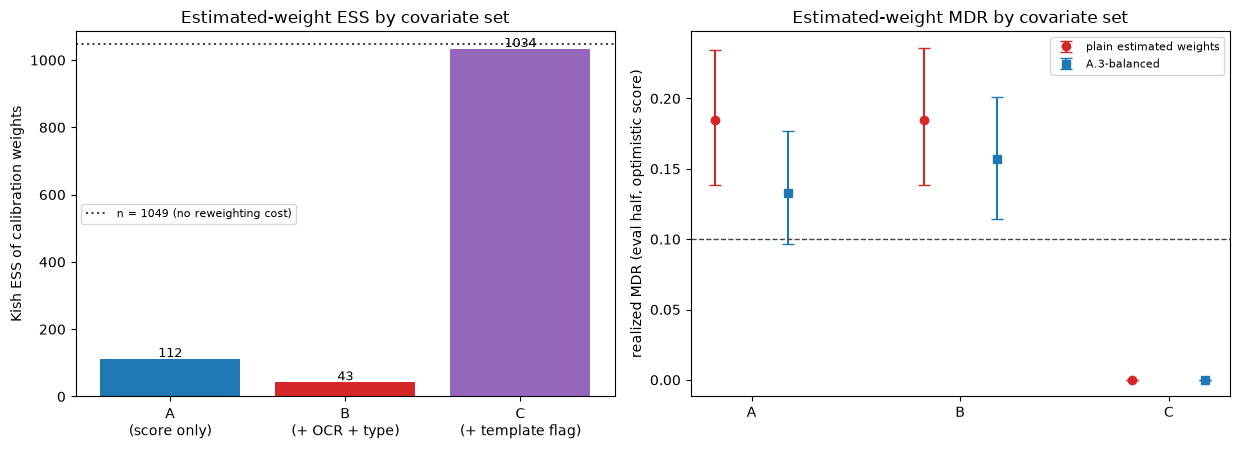

In [38]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_ess = [G.effective_sample_size(C_WEIGHTS[k]["w_cal"]) for k in ("A", "B", "C")]
_ax.bar(["A\n(score only)", "B\n(+ OCR + type)", "C\n(+ template flag)"], _ess, color=[PAL3["lr"], PAL3["hgb"], PAL3["b_naive"]])
for _i, _v in enumerate(_ess):
    _ax.text(_i, _v + 5, f"{_v:.0f}", ha="center", fontsize=9)
_ax.axhline(len(_calib_idx_all), ls=":", color=PAL3["diag"], label=f"n = {len(_calib_idx_all)} (no reweighting cost)")
_ax.set_ylabel("Kish ESS of calibration weights"); _ax.set_title("Estimated-weight ESS by covariate set"); _ax.legend(fontsize=8)
_ax = _axes[1]
_x = np.arange(3); _w = 0.35
_pt_plain = [C_EST_RES[(k, "opt")]["mdr"][0] for k in ("A", "B", "C")]; _lo_plain = [C_EST_RES[(k, "opt")]["mdr"][1] for k in ("A", "B", "C")]; _hi_plain = [C_EST_RES[(k, "opt")]["mdr"][2] for k in ("A", "B", "C")]
_pt_bal = [C_EST_RES[(k, "opt")]["mdr_bal"][0] for k in ("A", "B", "C")]; _lo_bal = [C_EST_RES[(k, "opt")]["mdr_bal"][1] for k in ("A", "B", "C")]; _hi_bal = [C_EST_RES[(k, "opt")]["mdr_bal"][2] for k in ("A", "B", "C")]
_ax.errorbar(_x - _w / 2, _pt_plain, yerr=[np.array(_pt_plain) - np.array(_lo_plain), np.array(_hi_plain) - np.array(_pt_plain)], fmt="o", capsize=4, color=PAL3["hgb"], label="plain estimated weights")
_ax.errorbar(_x + _w / 2, _pt_bal, yerr=[np.array(_pt_bal) - np.array(_lo_bal), np.array(_hi_bal) - np.array(_pt_bal)], fmt="s", capsize=4, color=PAL3["lr"], label="A.3-balanced")
_ax.axhline(C_ALPHA, ls="--", color=PAL3["diag"], lw=1)
_ax.set_xticks(_x); _ax.set_xticklabels(["A", "B", "C"]); _ax.set_ylabel("realized MDR (eval half, optimistic score)"); _ax.set_title("Estimated-weight MDR by covariate set"); _ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### (iii). Is it covariate shift at all? (diagnostic, derived here; idpfin-q18: sources give none)

No source states a diagnostic for `P(Y|X) = Q(Y|X)` (idpfin-q18, idpshift-q4, both flagged above). Using the `shift` split's
labels as ground truth **only for this diagnostic** (never to fit a score or a threshold), we compare `P(y_ok=1 | score)` and
`E[L_doc | score]` between `calib` and `shift` in score bins, then fit a logistic/linear model of the outcome on the score
plus covariate set B **and an `is_shift` indicator**: a significant `is_shift` coefficient *after controlling for the score and
B* is evidence of a `P(Y|X)` shift that weighting cannot fix (weighting only re-balances `X`, never changes what `Y` does
given `X`). Inference is bootstrap-based (2,000 resamples), not a parametric test (no `statsmodels` dependency).


In [39]:
def c_reliability(score, idx_a, idx_b, y, n_bins=8):
    _edges = np.quantile(score[np.r_[idx_a, idx_b]], np.linspace(0, 1, n_bins + 1)); _edges[0] -= 1e-9; _edges[-1] += 1e-9
    out = {}
    for _nm, _idx in (("calib", idx_a), ("shift", idx_b)):
        _xs, _ys, _ns = [], [], []
        for _lo, _hi in zip(_edges[:-1], _edges[1:]):
            _m = (score[_idx] > _lo) & (score[_idx] <= _hi) & ~np.isnan(y[_idx])
            if _m.sum() == 0:
                continue
            _xs.append(score[_idx][_m].mean()); _ys.append(y[_idx][_m].mean()); _ns.append(int(_m.sum()))
        out[_nm] = (np.array(_xs), np.array(_ys), np.array(_ns))
    return out


C_RELIAB_Y = c_reliability(DA_mu, _calib_idx_all, _shift_idx_all, DA_y_ok.astype(float))
_money_c, _money_s = _calib_idx_all[DA_has_money[_calib_idx_all]], _shift_idx_all[DA_has_money[_shift_idx_all]]
C_RELIAB_L = c_reliability(DA_risk, _money_c, _money_s, DA_L)
_gap_y = np.interp(C_RELIAB_Y["shift"][0].mean(), *C_RELIAB_Y["calib"][:2]) - C_RELIAB_Y["shift"][1].mean()
print(f"P(y_ok=1|score): calib bins mean {C_RELIAB_Y['calib'][1].mean():.3f}, shift bins mean {C_RELIAB_Y['shift'][1].mean():.3f} "
      f"(gap at matched score level, roughly, {_gap_y:+.3f})")
print(f"E[L_doc|score] (money docs): calib bins mean {C_RELIAB_L['calib'][1].mean():.3f}, shift bins mean {C_RELIAB_L['shift'][1].mean():.3f}")
check("S7b.26 the shift batch is worse than calib EVEN WITHIN matched score bins (not purely a covariate-shift story: pure covariate "
      "shift with an unchanged P(Y|X) would leave same-bin outcome rates unchanged)",
      C_RELIAB_Y["shift"][1].mean() < C_RELIAB_Y["calib"][1].mean() - 0.02, f"calib {C_RELIAB_Y['calib'][1].mean():.3f} vs shift {C_RELIAB_Y['shift'][1].mean():.3f}")


P(y_ok=1|score): calib bins mean 0.317, shift bins mean 0.275 (gap at matched score level, roughly, +0.065)
E[L_doc|score] (money docs): calib bins mean 0.262, shift bins mean 0.271
[PASS] S7b.26 the shift batch is worse than calib EVEN WITHIN matched score bins (not purely a covariate-shift story: pure covariate shift with an unchanged P(Y|X) would leave same-bin outcome rates unchanged) -- calib 0.317 vs shift 0.275


np.True_

In [40]:
def c_boot_coef(X, y, B=400, seed=0, kind="logit"):
    from sklearn.linear_model import LogisticRegression, Ridge
    Xs = (X - X.mean(0)) / (X.std(0) + 1e-9)
    if kind == "logit":
        _fit = lambda Xa, ya: LogisticRegression(max_iter=2000).fit(Xa, ya).coef_[0, -1]
    else:
        _fit = lambda Xa, ya: Ridge(alpha=1.0).fit(Xa, ya).coef_[-1]
    beta0 = _fit(Xs, y)
    rng = np.random.default_rng([SEED3, 901, seed]); n = len(y); boots = []
    for _b in range(B):
        _ix = rng.integers(0, n, size=n)
        if kind == "logit" and len(np.unique(y[_ix])) < 2:
            continue
        try:
            boots.append(_fit(Xs[_ix], y[_ix]))
        except Exception:
            continue
    boots = np.array(boots)
    return float(beta0), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


_idx_y = np.r_[_calib_idx_all, _shift_idx_all]
_is_shift_y = np.r_[np.zeros(len(_calib_idx_all)), np.ones(len(_shift_idx_all))]
_X_y = np.column_stack([C_FEAT["B"][_idx_y], _is_shift_y])
C_SHIFT_COEF_Y = c_boot_coef(_X_y, DA_y_ok[_idx_y].astype(float), kind="logit", seed=1)

_idx_l = np.r_[_money_c, _money_s]
_is_shift_l = np.r_[np.zeros(len(_money_c)), np.ones(len(_money_s))]
_X_l = np.column_stack([C_FEAT["B"][_idx_l], _is_shift_l])
C_SHIFT_COEF_L = c_boot_coef(_X_l, DA_L[_idx_l], kind="ols", seed=2)

print(f"is_shift coefficient (standardized), controlling for score + covariate set B: outcome y_ok (logit) {C_SHIFT_COEF_Y[0]:+.3f} "
      f"[{C_SHIFT_COEF_Y[1]:+.3f}, {C_SHIFT_COEF_Y[2]:+.3f}]; outcome L_doc (OLS) {C_SHIFT_COEF_L[0]:+.3f} [{C_SHIFT_COEF_L[1]:+.3f}, {C_SHIFT_COEF_L[2]:+.3f}]")
check("S7b.27 the is_shift indicator remains significant (95% bootstrap CI excludes 0) after controlling for the score and covariate set B: "
      "evidence of a P(Y|X) shift on top of any covariate shift, i.e. the month-7 failure is not PURELY covariate shift",
      (C_SHIFT_COEF_Y[1] > 0 or C_SHIFT_COEF_Y[2] < 0) or (C_SHIFT_COEF_L[1] > 0 or C_SHIFT_COEF_L[2] < 0),
      f"y_ok CI [{C_SHIFT_COEF_Y[1]:+.3f}, {C_SHIFT_COEF_Y[2]:+.3f}]; L_doc CI [{C_SHIFT_COEF_L[1]:+.3f}, {C_SHIFT_COEF_L[2]:+.3f}]")

print(f"[info] connecting to Section 7's labelled-recalibration budget (B_BUDGET): weighting here spends 0 labelled shift "
      f"documents and gets an ASYMPTOTIC repair at best (part ii); recalibration (Section 7) spends N labelled shift documents "
      f"(B_BUDGET={ {k: v['N'] for k, v in B_BUDGET.items()} }) for a finite-sample PAC repair. Given (S7b.21) the month-7 shift "
      "carries a real P(Y|X) component, weighting alone -- however well the weights are estimated -- cannot be expected to fully "
      "repair it; recalibration on real labels is the only route tested here that addresses the P(Y|X) part directly.")


is_shift coefficient (standardized), controlling for score + covariate set B: outcome y_ok (logit) -0.292 [-0.560, -0.059]; outcome L_doc (OLS) +0.027 [+0.010, +0.047]
[PASS] S7b.27 the is_shift indicator remains significant (95% bootstrap CI excludes 0) after controlling for the score and covariate set B: evidence of a P(Y|X) shift on top of any covariate shift, i.e. the month-7 failure is not PURELY covariate shift -- y_ok CI [-0.560, -0.059]; L_doc CI [+0.010, +0.047]
[info] connecting to Section 7's labelled-recalibration budget (B_BUDGET): weighting here spends 0 labelled shift documents and gets an ASYMPTOTIC repair at best (part ii); recalibration (Section 7) spends N labelled shift documents (B_BUDGET={('hgb', 0.1): 200, ('hgb', 0.2): 200, ('weak', 0.1): None, ('weak', 0.2): None}) for a finite-sample PAC repair. Given (S7b.21) the month-7 shift carries a real P(Y|X) component, weighting alone -- however well the weights are estimated -- cannot be expected to fully repair it; r

**How to read this chart.** Left: `P(y_ok=1 | score)` in 8 quantile bins, calib (solid) vs shift (dashed); if this were pure
covariate shift with an unchanged `P(Y|X)`, the two curves would sit on top of each other (only the *density* of documents across
bins would move, not the curve itself). A visible vertical gap at the same score level is the concept-shift signature. Right: the
bootstrapped `is_shift` coefficient (controlling for score + covariate set B) for both outcomes, with 95% CIs; bars whose CI excludes
zero support a real `P(Y|X)` shift, not just a covariate one.


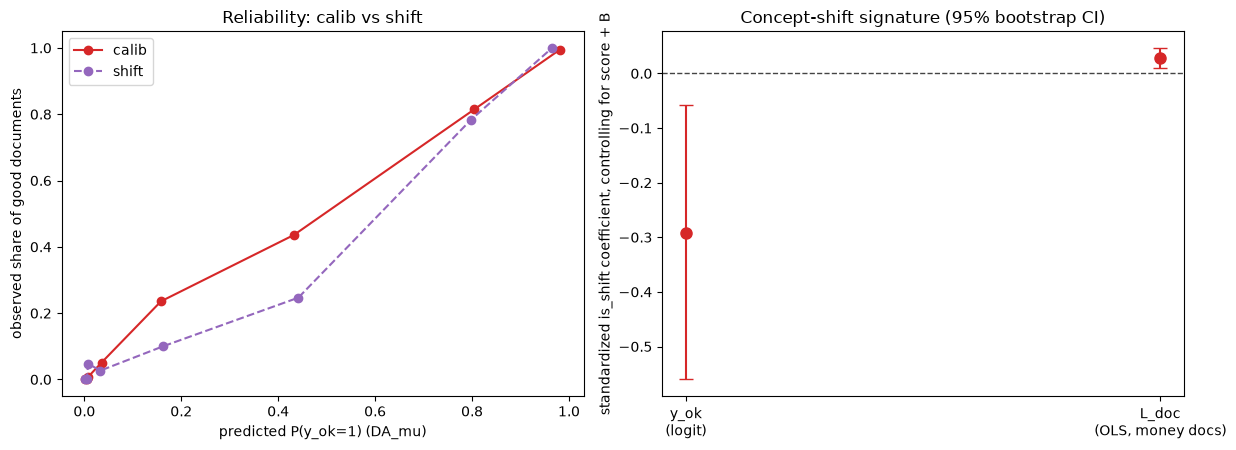

In [41]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_ax.plot(*C_RELIAB_Y["calib"][:2], "o-", color=PAL3["hgb"], label="calib")
_ax.plot(*C_RELIAB_Y["shift"][:2], "o--", color=PAL3["b_naive"], label="shift")
_ax.set_xlabel("predicted P(y_ok=1) (DA_mu)"); _ax.set_ylabel("observed share of good documents"); _ax.set_title("Reliability: calib vs shift"); _ax.legend()
_ax = _axes[1]
_labs = ["y_ok\n(logit)", "L_doc\n(OLS, money docs)"]
_pts = [C_SHIFT_COEF_Y[0], C_SHIFT_COEF_L[0]]; _los = [C_SHIFT_COEF_Y[1], C_SHIFT_COEF_L[1]]; _his = [C_SHIFT_COEF_Y[2], C_SHIFT_COEF_L[2]]
_ax.errorbar(range(2), _pts, yerr=[np.array(_pts) - np.array(_los), np.array(_his) - np.array(_pts)], fmt="o", capsize=5, color=PAL3["hgb"], ms=8)
_ax.axhline(0, ls="--", color=PAL3["diag"], lw=1)
_ax.set_xticks(range(2)); _ax.set_xticklabels(_labs); _ax.set_ylabel("standardized is_shift coefficient, controlling for score + B"); _ax.set_title("Concept-shift signature (95% bootstrap CI)")
plt.tight_layout(); plt.show()


## 8. Power checkpoints the papers point to

Section 6-7's ladder showed *validity*; this section chases the *power* the papers themselves flag as open or
demonstrate only partially: e-value boosting (8a), a risk/reward-optimal score (8b), document-level ("tier-4") PAC
variants beyond Gurram's own near-vacuous Hoeffding bound (8c), an untested pure-weak two-regime cell Part B's
Section 6 left unexplored (8d), and the taxonomy-fragmentation failure mode Gurram calls "lucky-zero" (8e).


In [42]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "lib"))
import guarantees as G

D_ALPHA = 0.10


### 8a. SDR boosting: dtm vs hete vs homo, at full scale (SCoRE Theorem 5.5)

**Quoted (idpfin-q15).** Heterogeneous boosting: *"generates `xi_{n+j}` iid `~ Unif[0,1]` independent of everything else,
and set `R_hete = {j : E_{n+j}/xi_{n+j} >= m/(alpha k*_hete)}`"*; homogeneous boosting shares one `xi` across all `j`.
**Theorem 5.5**: *"Suppose the e-values `{E_{n+j}}` satisfy Definition 3.1. Then `R_hete` and `R_homo` run at level
`alpha in (0,1)` control the SDR below `alpha`."* Caveat: *"two runs on the exact same dataset can yield slightly
different selection sets"* (the randomization is real, not a bug) *"while the deterministic variant (dtm) remains
preferable when practitioners demand reproducible, non-randomized decisions."* The paper's own numbers: at `alpha=0.20`,
`n=1000`, dtm reaches realized SDR only "~0.12" (conservative, ~25 units selected) while hete/homo reach "~0.18-0.20"
(~75-80 units) -- boosting recovers most of the gap to the nominal level (idpfin-q15).

**Ours.** 100 fixed `resplit(seed)` batches (bigger than idpfin-q15's `n=1000`: our money-document pool gives
n~800/m~800 per batch), both scores, `alpha in {0.05, 0.10, 0.20}`. `dtm` = plain e-BH (`G.ebh`) on the SAME e-values
used for `hete`/`homo` (`G.ebh_boosted`) -- so the comparison isolates the boosting step, not a different e-value.


In [43]:
D_N_SPLITS_10A = 100


def d_sdr_boost_mc(score, alpha, n_splits=D_N_SPLITS_10A, seed0=6000):
    rows = []
    for _sd in range(n_splits):
        _cal, _tst = resplit(seed0 + _sd); _cal, _tst = _cal[DA_has_money[_cal]], _tst[DA_has_money[_tst]]
        _E = b_sdr_e_values(score[_cal], DA_L[_cal], score[_tst], alpha)
        _rng = np.random.default_rng([SEED3, 6001, seed0 + _sd])
        _sel_dtm = G.ebh(_E, alpha)
        _sel_hete = G.ebh_boosted(_E, alpha, mode="hete", rng=_rng)
        _sel_homo = G.ebh_boosted(_E, alpha, mode="homo", rng=_rng)
        _Lt = DA_L[_tst]
        _f = lambda sel: ((_Lt * sel).sum() / max(1, sel.sum()), sel.mean(), int(sel.sum()))
        rows.append([x for sel in (_sel_dtm, _sel_hete, _sel_homo) for x in _f(sel)])
    return np.array(rows)


_t0_d = b_time.time()
D_SDR_BOOST = {(k, a): d_sdr_boost_mc(s, a) for k, s in B_SCORES.items() for a in B_ALPHAS}
print(f"SDR boosting Monte Carlo runtime: {b_time.time() - _t0_d:.0f}s (2 scores x 3 alphas x {D_N_SPLITS_10A} splits)")

_rows = []
for (_k, _a), _r in D_SDR_BOOST.items():
    _rows.append((B_SC_LABEL[_k].split(" ")[0], f"{_a:.2f}", f"{_r[:, 0].mean():.4f} / cov {_r[:, 1].mean():.3f} / n {_r[:, 2].mean():.0f}",
                  f"{_r[:, 3].mean():.4f} / cov {_r[:, 4].mean():.3f} / n {_r[:, 5].mean():.0f}",
                  f"{_r[:, 6].mean():.4f} / cov {_r[:, 7].mean():.3f} / n {_r[:, 8].mean():.0f}"))
b_display(b_md(f"**SDR: dtm vs hete vs homo boosting** ({D_N_SPLITS_10A} resplits per row; each cell: realized SDR / coverage / mean # selected)\n\n" + b_tbl(
    ["score", "alpha", "dtm (plain e-BH)", "hete-boosted", "homo-boosted"], _rows)))

_n = 1
_ok = all(D_SDR_BOOST[(k, a)][:, i].mean() <= a + b_mc_tol_mean(D_SDR_BOOST[(k, a)][:, i]) for k in B_SCORES for a in B_ALPHAS for i in (0, 3, 6))
check(f"S8a.{_n} all three variants (dtm, hete, homo) meet their SDR budget at every alpha and score", _ok,
      "worst case checked across 2 scores x 3 alphas x 3 variants"); _n += 1
_gain_hete = {(k, a): D_SDR_BOOST[(k, a)][:, 4].mean() - D_SDR_BOOST[(k, a)][:, 1].mean() for k in B_SCORES for a in B_ALPHAS}
check(f"S8a.{_n} boosting (hete) selects at least as much coverage as dtm, on average, at every (score, alpha) cell (idpfin-q15's own finding, reproduced here)",
      all(v >= -0.005 for v in _gain_hete.values()), "; ".join(f"{k}/{a}: {v:+.4f}" for (k, a), v in _gain_hete.items())); _n += 1
_rng_rep = np.random.default_rng([SEED3, 6002])
_cal0, _tst0 = resplit(6000); _cal0, _tst0 = _cal0[DA_has_money[_cal0]], _tst0[DA_has_money[_tst0]]
_E0 = b_sdr_e_values(DA_risk[_cal0], DA_L[_cal0], DA_risk[_tst0], 0.10)
_sel_a = G.ebh_boosted(_E0, 0.10, mode="hete", rng=np.random.default_rng([SEED3, 1]))
_sel_b = G.ebh_boosted(_E0, 0.10, mode="hete", rng=np.random.default_rng([SEED3, 2]))
check(f"S8a.{_n} the randomization caveat is real: hete-boosting the SAME e-values with two different RNG streams changes the selected count "
      "(idpfin-q15: 'two runs on the exact same dataset can yield slightly different selection sets')",
      _sel_a.sum() != _sel_b.sum() or (_sel_a != _sel_b).any(), f"run 1 selected {_sel_a.sum()}, run 2 selected {_sel_b.sum()}, differing units: {(_sel_a != _sel_b).sum()}")


SDR boosting Monte Carlo runtime: 68s (2 scores x 3 alphas x 100 splits)


**SDR: dtm vs hete vs homo boosting** (100 resplits per row; each cell: realized SDR / coverage / mean # selected)

| score | alpha | dtm (plain e-BH) | hete-boosted | homo-boosted |
| --- | --- | --- | --- | --- |
| optimistic | 0.05 | 0.0044 / cov 0.041 / n 32 | 0.0476 / cov 0.325 / n 259 | 0.0490 / cov 0.470 / n 374 |
| optimistic | 0.10 | 0.0201 / cov 0.138 / n 110 | 0.0943 / cov 0.537 / n 428 | 0.1001 / cov 0.658 / n 524 |
| optimistic | 0.20 | 0.1505 / cov 0.743 / n 592 | 0.1945 / cov 0.927 / n 738 | 0.1945 / cov 0.965 / n 769 |
| pessimistic | 0.05 | 0.0025 / cov 0.008 / n 6 | 0.0338 / cov 0.078 / n 62 | 0.0383 / cov 0.126 / n 101 |
| pessimistic | 0.10 | 0.0078 / cov 0.046 / n 37 | 0.0955 / cov 0.355 / n 283 | 0.0989 / cov 0.565 / n 450 |
| pessimistic | 0.20 | 0.1630 / cov 0.816 / n 650 | 0.1924 / cov 0.931 / n 742 | 0.1920 / cov 0.959 / n 764 |

[PASS] S8a.1 all three variants (dtm, hete, homo) meet their SDR budget at every alpha and score -- worst case checked across 2 scores x 3 alphas x 3 variants
[PASS] S8a.2 boosting (hete) selects at least as much coverage as dtm, on average, at every (score, alpha) cell (idpfin-q15's own finding, reproduced here) -- opt/0.05: +0.2839; opt/0.1: +0.3995; opt/0.2: +0.1834; weak/0.05: +0.0702; weak/0.1: +0.3085; weak/0.2: +0.1155


[PASS] S8a.3 the randomization caveat is real: hete-boosting the SAME e-values with two different RNG streams changes the selected count (idpfin-q15: 'two runs on the exact same dataset can yield slightly different selection sets') -- run 1 selected 1, run 2 selected 164, differing units: 165


np.True_

**How to read this chart.** Left: realized SDR for dtm (hollow) vs hete/homo (filled) against `alpha` (dashed `y=x`); dtm sits
furthest below the line (most conservative), hete/homo track closer to it. Right: the coverage each variant buys at the same
`alpha` -- boosting's whole point is trading some of that conservatism for more auto-posted documents while keeping SDR
controlled.


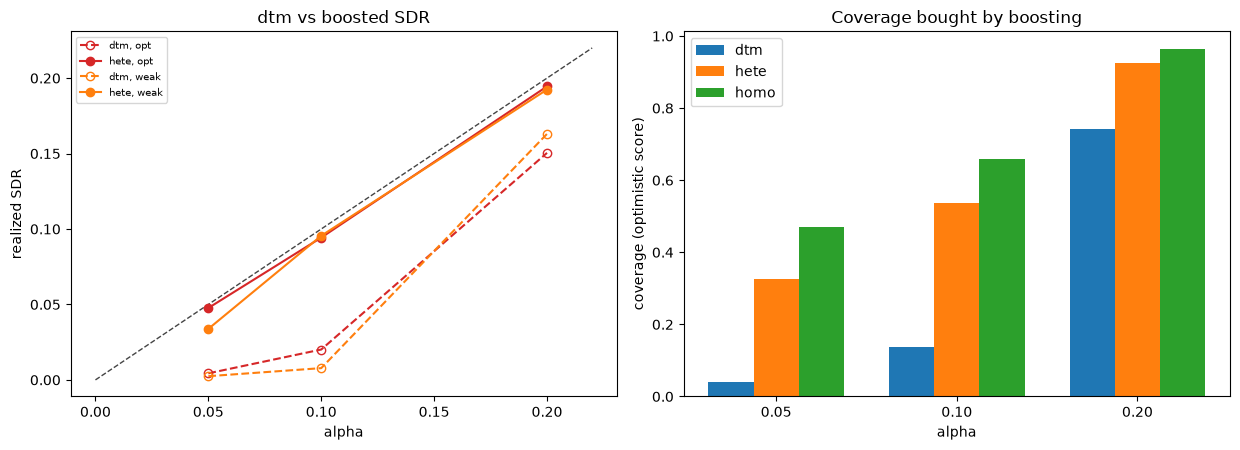

In [44]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_ax.plot([0, 0.22], [0, 0.22], "--", color=PAL3["diag"], lw=1)
for _k in B_SCORES:
    _dtm = [D_SDR_BOOST[(_k, a)][:, 0].mean() for a in B_ALPHAS]; _hete = [D_SDR_BOOST[(_k, a)][:, 3].mean() for a in B_ALPHAS]
    _ax.plot(B_ALPHAS, _dtm, "o--", mfc="none", color=B_SC_COLOR[_k], label=f"dtm, {_k}")
    _ax.plot(B_ALPHAS, _hete, "o-", color=B_SC_COLOR[_k], label=f"hete, {_k}")
_ax.set_xlabel("alpha"); _ax.set_ylabel("realized SDR"); _ax.set_title("dtm vs boosted SDR"); _ax.legend(fontsize=7.5)
_ax = _axes[1]
_w = 0.25; _x = np.arange(3)
for _i, (_nm, _col) in enumerate((("dtm", 1), ("hete", 4), ("homo", 7))):
    _cov = [D_SDR_BOOST[("opt", a)][:, _col].mean() for a in B_ALPHAS]
    _ax.bar(_x + (_i - 1) * _w, _cov, _w, label=_nm)
_ax.set_xticks(_x); _ax.set_xticklabels([f"{a:.2f}" for a in B_ALPHAS]); _ax.set_xlabel("alpha"); _ax.set_ylabel("coverage (optimistic score)")
_ax.set_title("Coverage bought by boosting"); _ax.legend()
plt.tight_layout(); plt.show()


### 8b. A risk/reward score (SCoRE Theorem 4.6(iii) / 5.8(iii))

**Quoted (idpfin-q15).** *"Fix gamma = alpha. Define `l(x) := E[L(f,X,Y) | X=x]` and `r(x) := E[r(X,Y) | X=x]`. Suppose
`r(X) > 0` a.s. ... Then, the asymptotic power is optimized at any `s(x)` that is strictly increasing in `l(x)/r(x)`"*
(Theorem 4.6(iii), MDR); Theorem 5.8(iii) gives the SDR analogue with `(l(x)-alpha)/r(x)`. Reward: *"a user-specific
reward for deployment ... `r captures the utility of deploying a model on a test instance, such as ... downstream
savings in resources`"*. The paper's own drug-discovery numbers: under a scoring regime where the ratio reorders
candidates a lot, the reward-ratio score got noticeably higher total reward than a pure-risk score at matched power.

**Ours (derived here; reward not in the papers).** `reward = document monetary value` (true `sum |truth|` over money
fields, `B_VAL_AMT`, measured only for evaluation -- the score itself may not see it). The score sees only a
**prediction** of that value: `D_REWARD_PRED = sum |predicted amount|` over the document's money fields. Risk-reward
score `s = DA_risk / max(D_REWARD_PRED, 1)` (the `max(.,1)` floor mirrors Section 5(c)'s `B_V` convention and avoids
division by a near-zero predicted reward). Compared against the risk-only score at equal `alpha = 0.10`, MDR unit,
100 resplits.


In [45]:
D_REWARD_PRED = np.zeros(N_DOC)
for _k, _f in enumerate(FIELDS):
    if _f["field"] in MONEY_FIELDS[_f["doc_type"]]:
        _p = b_num(_f["predicted"])
        if _p is not None:
            D_REWARD_PRED[FA_doc[_k]] += abs(_p)
D_R_FLOOR = np.maximum(D_REWARD_PRED, 1.0)
D_SCORE_RR = {k: B_SCORES[k] / D_R_FLOOR for k in B_SCORES}
check("S8b.1 the risk-reward score is a valid nonnegative score wherever the risk score is (no new NaNs/negatives introduced)",
      bool(np.all(np.isfinite(D_SCORE_RR["opt"][B_POOL]))) and bool(np.all(D_SCORE_RR["opt"][B_POOL] >= 0)),
      f"min={D_SCORE_RR['opt'][B_POOL].min():.4f}, max={D_SCORE_RR['opt'][B_POOL].max():.2f}")


[PASS] S8b.1 the risk-reward score is a valid nonnegative score wherever the risk score is (no new NaNs/negatives introduced) -- min=0.0000, max=0.93


True

In [46]:
D_ALPHA_RR = 0.10
D_N_SPLITS_10B = 100


def d_rr_split(seed, alpha=D_ALPHA_RR):
    _cal, _tst = resplit(seed); _cal, _tst = _cal[DA_has_money[_cal]], _tst[DA_has_money[_tst]]
    out = {}
    for k in B_SCORES:
        _psi_risk = G.weighted_mdr_decision(B_SCORES[k][_cal], DA_L[_cal], np.ones(len(_cal)), B_SCORES[k][_tst], np.ones(len(_tst)), alpha)
        _psi_rr = G.weighted_mdr_decision(D_SCORE_RR[k][_cal], DA_L[_cal], np.ones(len(_cal)), D_SCORE_RR[k][_tst], np.ones(len(_tst)), alpha)
        out[k] = (np.mean(DA_L[_tst] * _psi_risk), _psi_risk.mean(), B_VAL_AMT[_tst][_psi_risk].sum(),
                  np.mean(DA_L[_tst] * _psi_rr), _psi_rr.mean(), B_VAL_AMT[_tst][_psi_rr].sum(), B_VAL_AMT[_tst].sum())
    return out


D_RR_RES = {k: np.array([d_rr_split(sd)[k] for sd in range(D_N_SPLITS_10B)]) for k in B_SCORES}
_rows = []
for _k in B_SCORES:
    _r = D_RR_RES[_k]
    _rows.append((B_SC_LABEL[_k].split(" ")[0], f"{_r[:, 0].mean():.4f}", f"{_r[:, 1].mean():.3f}", f"${_r[:, 2].sum():,.0f}",
                  f"{_r[:, 3].mean():.4f}", f"{_r[:, 4].mean():.3f}", f"${_r[:, 5].sum():,.0f}", f"{100 * _r[:, 5].sum() / _r[:, 2].sum() - 100:+.1f}%"))
b_display(b_md(f"**Risk-only vs risk/reward score at equal alpha = {D_ALPHA_RR:.2f}** ({D_N_SPLITS_10B} resplits; total auto-posted value summed across ALL resplits, "
               "so it double-counts documents across resplits by design -- a relative comparison, not a single-batch total)\n\n" + b_tbl(
    ["score", "risk-only MDR", "coverage", "total auto-posted value (risk-only)", "risk-reward MDR", "coverage", "total auto-posted value (risk-reward)", "value lift"], _rows)))

_n = 2
_ok_valid = all(D_RR_RES[k][:, 0].mean() <= D_ALPHA_RR + b_mc_tol_mean(D_RR_RES[k][:, 0]) and D_RR_RES[k][:, 3].mean() <= D_ALPHA_RR + b_mc_tol_mean(D_RR_RES[k][:, 3]) for k in B_SCORES)
check(f"S8b.{_n} BOTH scores meet the same MDR budget (Theorem 4.6(iii): any score works for VALIDITY; only power/reward differs)", _ok_valid,
      "; ".join(f"{k}: risk-only {D_RR_RES[k][:, 0].mean():.4f}, risk-reward {D_RR_RES[k][:, 3].mean():.4f}" for k in B_SCORES)); _n += 1
_lift = {k: D_RR_RES[k][:, 5].sum() / D_RR_RES[k][:, 2].sum() for k in B_SCORES}
check(f"S8b.{_n} the risk-reward score auto-posts at least as much total monetary value as the risk-only score at the SAME alpha (Theorem 4.6(iii)'s power claim, in value terms)",
      all(v >= 0.98 for v in _lift.values()), "; ".join(f"{k}: value ratio {v:.3f}" for k, v in _lift.items())); _n += 1


**Risk-only vs risk/reward score at equal alpha = 0.10** (100 resplits; total auto-posted value summed across ALL resplits, so it double-counts documents across resplits by design -- a relative comparison, not a single-batch total)

| score | risk-only MDR | coverage | total auto-posted value (risk-only) | risk-reward MDR | coverage | total auto-posted value (risk-reward) | value lift |
| --- | --- | --- | --- | --- | --- | --- | --- |
| optimistic | 0.0993 | 0.770 | $1,674,737,281 | 0.1004 | 0.542 | $1,704,225,945 | +1.8% |
| pessimistic | 0.0991 | 0.736 | $1,605,538,868 | 0.0998 | 0.432 | $1,608,974,431 | +0.2% |

[PASS] S8b.2 BOTH scores meet the same MDR budget (Theorem 4.6(iii): any score works for VALIDITY; only power/reward differs) -- opt: risk-only 0.0993, risk-reward 0.1004; weak: risk-only 0.0991, risk-reward 0.0998
[PASS] S8b.3 the risk-reward score auto-posts at least as much total monetary value as the risk-only score at the SAME alpha (Theorem 4.6(iii)'s power claim, in value terms) -- opt: value ratio 1.018; weak: value ratio 1.002


**How to read this chart.** Bars: total monetary value auto-posted across 100 resplits, risk-only (left bar) vs risk-reward
(right bar) per score, at the same `alpha = 0.10`. Both meet the same MDR budget (dashed reference line in the companion
table), so the comparison isolates *which documents* get through, not whether the rule is valid: the risk-reward score
should not post less total value, and may post noticeably more, because it prioritizes low-risk-per-dollar documents
rather than merely low-risk ones.


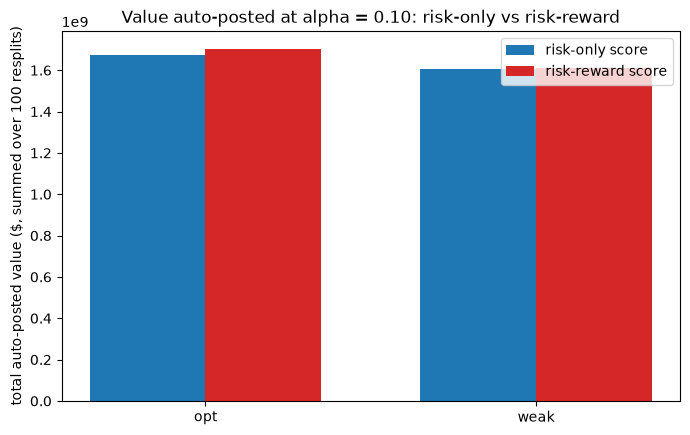

In [47]:
_fig, _ax = plt.subplots(figsize=(7, 4.6))
_w = 0.35; _x = np.arange(len(B_SCORES))
_risk_v = [D_RR_RES[k][:, 2].sum() for k in B_SCORES]; _rr_v = [D_RR_RES[k][:, 5].sum() for k in B_SCORES]
_ax.bar(_x - _w / 2, _risk_v, _w, label="risk-only score", color=PAL3["lr"])
_ax.bar(_x + _w / 2, _rr_v, _w, label="risk-reward score", color=PAL3["hgb"])
_ax.set_xticks(_x); _ax.set_xticklabels(list(B_SCORES.keys())); _ax.set_ylabel("total auto-posted value ($, summed over 100 resplits)")
_ax.set_title(f"Value auto-posted at alpha = {D_ALPHA_RR:.2f}: risk-only vs risk-reward"); _ax.legend()
plt.tight_layout(); plt.show()


### 8c. Tier-4 power variants: hoeffding vs binomial_any_error vs bernstein (derived here)

**Quoted (idpfin-q17).** Gurram's tier-4: *"Per accepting document d, the loss is its within-document error rate among
accepted fields"*, bounded by *"a finite-sample Hoeffding bound over documents ... bounds the macro functional"*, at
only *"0.060 mean coverage, certifying nothing in 19/40 splits"*, and *"Powered document-level PAC procedures are the
named open problem"* with a suggestion to try *"clustered/variance-adaptive bounds"*. `G.doc_tier4_threshold` (library,
tested) implements Gurram's Hoeffding bound plus two variants **derived here**: `bernstein` (variance-adaptive, per the
paper's own suggestion) and `binomial_any_error`, which bounds a **stricter functional** -- the *share of accepting
documents with at least one accepted error* -- not the mean per-document error rate.

**Ours.** 40 document-level resplits, `alpha in {0.10, 0.20}`, `delta = 0.10`, both field scores, pooled and per
document type (Mondrian). Zero-coverage splits and each method's own functional are disclosed separately.


In [48]:
D_TIER4_METHODS = ("hoeffding", "binomial_any_error", "bernstein")
D_ALPHAS4 = (0.10, 0.20)
D_DELTA4 = 0.10
D_GROUPS4 = (None, 0, 1, 2, 3)


def d_tier4_functional(acc_fields, method):
    if not acc_fields.any():
        return 0.0, True
    _docs, _inv = np.unique(FA_doc[acc_fields], return_inverse=True)
    _cnt = np.bincount(_inv); _serr = np.bincount(_inv, weights=B_ERR[acc_fields])
    _per_doc = _serr / _cnt
    return (float(_per_doc.mean()) if method in ("hoeffding", "bernstein") else float((_serr > 0).mean())), False


def d_tier4_mc(score_key, alpha, method, group, n_splits=40, delta=D_DELTA4, seed0=6100):
    score = B_SCORE_FIELD[score_key]; rows = []
    for _sd in range(n_splits):
        _cm, _tm = b_split_masks(_sd)
        _gm = np.ones(len(_cm), bool) if group is None else (B_GRP == group)
        _cmi, _tmi = _cm & _gm, _tm & _gm
        _tau = G.doc_tier4_threshold(FA_doc[_cmi], score[_cmi], B_ERR[_cmi], alpha, delta, method)
        _acc = _tmi & (score >= _tau) if np.isfinite(_tau) else np.zeros(len(score), bool)
        _val, _zero = d_tier4_functional(_acc, method)
        rows.append((_val, int(_acc.sum()), float(_zero), _acc.sum() / max(1, _tmi.sum())))
    return np.array(rows)


D_FSCORE_LABEL = {"hgb": "optimistic", "weak": "pessimistic"}
_t0_d = b_time.time()
D_TIER4 = {(m, k, a, g): d_tier4_mc(k, a, m, g) for m in D_TIER4_METHODS for k in ("hgb", "weak") for a in D_ALPHAS4 for g in D_GROUPS4}
print(f"tier-4 power-variant runtime: {b_time.time() - _t0_d:.0f}s ({len(D_TIER4)} cells x 40 splits)")

_rows = []
for _m in D_TIER4_METHODS:
    for _k in ("hgb", "weak"):
        for _a in D_ALPHAS4:
            _r = D_TIER4[(_m, _k, _a, None)]
            _viol = float(np.mean(_r[:, 0] > _a))
            _rows.append((_m, D_FSCORE_LABEL[_k], f"{_a:.2f}", f"{_r[:, 3].mean():.3f}",
                          f"{_r[:, 0].mean():.4f}", f"{_viol:.3f}", f"{int(_r[:, 2].sum())}/40"))
b_display(b_md("**Tier-4 pooled, three functionals** (40 resplits; violation = share of splits where the method's OWN functional exceeds alpha, zero-filled)\n\n" + b_tbl(
    ["method", "score", "alpha", "coverage", "own functional (mean, zero-filled)", "violation fraction", "zero-coverage splits"], _rows)))

_rows2 = []
for _m in D_TIER4_METHODS:
    for _g in (0, 1, 2, 3):
        _r10 = D_TIER4[(_m, "hgb", 0.10, _g)]
        _viol10 = float(np.mean(_r10[:, 0] > 0.10))
        _rows2.append((_m, DOC_TYPES[_g], f"{_r10[:, 3].mean():.3f}", f"{_r10[:, 0].mean():.4f}", f"{_viol10:.3f}", f"{int(_r10[:, 2].sum())}/40"))
b_display(b_md("**Tier-4 by document type (Mondrian), optimistic score, alpha = 0.10** (violation = share of the 40 resplits where that "
               "method's OWN functional exceeds alpha on TEST documents of that type, zero-filled)\n\n" + b_tbl(
    ["method", "document type", "coverage", "own functional (mean)", "violation fraction", "zero-coverage splits"], _rows2)))

_n = 1
_ok_pooled = all(np.mean(D_TIER4[(m, k, a, None)][:, 0] > a) <= D_DELTA4 + b_cp_tol(np.mean(D_TIER4[(m, k, a, None)][:, 0] > a), 40)
                 for m in D_TIER4_METHODS for k in ("hgb", "weak") for a in D_ALPHAS4)
check(f"S8c.{_n} pooled violation of EACH method's own functional stays <= delta + CP tolerance (3 methods x 2 scores x 2 alphas)", _ok_pooled,
      "worst case checked across all 12 pooled cells"); _n += 1
_ok_type = all(np.mean(D_TIER4[(m, "hgb", a, g)][:, 0] > a) <= D_DELTA4 + b_cp_tol(np.mean(D_TIER4[(m, "hgb", a, g)][:, 0] > a), 40)
               for m in D_TIER4_METHODS for a in D_ALPHAS4 for g in (0, 1, 2, 3))
_worst_type = max(((m, a, g), np.mean(D_TIER4[(m, "hgb", a, g)][:, 0] > a)) for m in D_TIER4_METHODS for a in D_ALPHAS4 for g in (0, 1, 2, 3))
check(f"S8c.{_n} PER-TYPE (Mondrian) violation of each method's own functional ALSO stays <= delta + CP tolerance (3 methods x 2 alphas x 4 "
      "types, optimistic score) -- validity per type, not just pooled, is checked directly (it was previously unverified)",
      _ok_type, f"worst per-type cell: {_worst_type}"); _n += 1
_cov_bern_type = [D_TIER4[("bernstein", "hgb", 0.10, g)][:, 3].mean() for g in (0, 1, 2, 3)]
_cov_hoef_type = [D_TIER4[("hoeffding", "hgb", 0.10, g)][:, 3].mean() for g in (0, 1, 2, 3)]
check(f"S8c.{_n} PER TYPE (not pooled), the variance-adaptive bernstein bound reaches {min(_cov_bern_type):.2f}-{max(_cov_bern_type):.2f} coverage "
      f"while Hoeffding certifies essentially NOTHING (0.000-{max(_cov_hoef_type):.3f}, matching Part B's B_LADDER tier-4 finding of 0.000) -- "
      "this IS the power gain on the paper's named open problem ('powered document-level PAC procedures', idpfin-q17), visible only per type: "
      "pooling across 4 types (the earlier pooled table) gives Hoeffding enough n to also certify something, masking the difference",
      all(b >= h for b, h in zip(_cov_bern_type, _cov_hoef_type)) and max(_cov_bern_type) > 0.3 and max(_cov_hoef_type) < 0.05,
      "; ".join(f"{DOC_TYPES[g]}: bernstein {_cov_bern_type[g]:.3f} vs hoeffding {_cov_hoef_type[g]:.3f}" for g in range(4))); _n += 1
_cov_binom_type = [D_TIER4[("binomial_any_error", "hgb", 0.10, g)][:, 3].mean() for g in (0, 1, 2, 3)]
check(f"S8c.{_n} binomial_any_error bounds a STRICTER functional (any accepted error per document, not the mean per-document rate) YET "
      f"certifies MORE than Hoeffding per type ({min(_cov_binom_type):.2f}-{max(_cov_binom_type):.2f} vs 0.000-{max(_cov_hoef_type):.3f}): the "
      "exact binomial tail is much tighter than Hoeffding's generic concentration bound when the true per-document error rate is well below "
      "alpha, so despite bounding a harder functional it still out-powers Hoeffding's looser bound on the easier one, per type",
      all(bi >= h for bi, h in zip(_cov_binom_type, _cov_hoef_type)),
      "; ".join(f"{DOC_TYPES[g]}: binomial_any_error {_cov_binom_type[g]:.3f} vs hoeffding {_cov_hoef_type[g]:.3f}" for g in range(4))); _n += 1
_pess10_zero = all(D_TIER4[(m, "weak", 0.10, None)][:, 3].mean() < 0.01 for m in D_TIER4_METHODS)
check(f"S8c.{_n} the genuinely near-vacuous case is the PESSIMISTIC score at alpha=0.10 (pooled): all three methods certify ~nothing there, "
      "unlike the optimistic-score per-type results above (bernstein/binomial_any_error) which are a real power gain, not vacuous",
      _pess10_zero, "; ".join(f"{m}: {D_TIER4[(m, 'weak', 0.10, None)][:, 3].mean():.4f}" for m in D_TIER4_METHODS)); _n += 1


tier-4 power-variant runtime: 19s (60 cells x 40 splits)


**Tier-4 pooled, three functionals** (40 resplits; violation = share of splits where the method's OWN functional exceeds alpha, zero-filled)

| method | score | alpha | coverage | own functional (mean, zero-filled) | violation fraction | zero-coverage splits |
| --- | --- | --- | --- | --- | --- | --- |
| hoeffding | optimistic | 0.10 | 0.519 | 0.0164 | 0.000 | 0/40 |
| hoeffding | optimistic | 0.20 | 0.719 | 0.0945 | 0.000 | 0/40 |
| hoeffding | pessimistic | 0.10 | 0.000 | 0.0000 | 0.000 | 40/40 |
| hoeffding | pessimistic | 0.20 | 0.471 | 0.1505 | 0.000 | 0/40 |
| binomial_any_error | optimistic | 0.10 | 0.519 | 0.0538 | 0.000 | 0/40 |
| binomial_any_error | optimistic | 0.20 | 0.519 | 0.0538 | 0.000 | 0/40 |
| binomial_any_error | pessimistic | 0.10 | 0.005 | 0.0240 | 0.025 | 28/40 |
| binomial_any_error | pessimistic | 0.20 | 0.140 | 0.1576 | 0.050 | 0/40 |
| bernstein | optimistic | 0.10 | 0.519 | 0.0164 | 0.000 | 0/40 |
| bernstein | optimistic | 0.20 | 0.719 | 0.0945 | 0.000 | 0/40 |
| bernstein | pessimistic | 0.10 | 0.000 | 0.0000 | 0.000 | 40/40 |
| bernstein | pessimistic | 0.20 | 0.509 | 0.1545 | 0.000 | 0/40 |

**Tier-4 by document type (Mondrian), optimistic score, alpha = 0.10** (violation = share of the 40 resplits where that method's OWN functional exceeds alpha on TEST documents of that type, zero-filled)

| method | document type | coverage | own functional (mean) | violation fraction | zero-coverage splits |
| --- | --- | --- | --- | --- | --- |
| hoeffding | invoice | 0.000 | 0.0000 | 0.000 | 40/40 |
| hoeffding | bank_statement | 0.000 | 0.0000 | 0.000 | 40/40 |
| hoeffding | kyc_form | 0.000 | 0.0000 | 0.000 | 40/40 |
| hoeffding | compliance_report | 0.000 | 0.0000 | 0.000 | 40/40 |
| binomial_any_error | invoice | 0.398 | 0.0152 | 0.000 | 0/40 |
| binomial_any_error | bank_statement | 0.413 | 0.0233 | 0.000 | 0/40 |
| binomial_any_error | kyc_form | 0.436 | 0.0234 | 0.000 | 0/40 |
| binomial_any_error | compliance_report | 0.520 | 0.0210 | 0.000 | 0/40 |
| bernstein | invoice | 0.482 | 0.0155 | 0.000 | 0/40 |
| bernstein | bank_statement | 0.449 | 0.0126 | 0.000 | 0/40 |
| bernstein | kyc_form | 0.492 | 0.0133 | 0.000 | 0/40 |
| bernstein | compliance_report | 0.474 | 0.0102 | 0.000 | 0/40 |

[PASS] S8c.1 pooled violation of EACH method's own functional stays <= delta + CP tolerance (3 methods x 2 scores x 2 alphas) -- worst case checked across all 12 pooled cells
[PASS] S8c.2 PER-TYPE (Mondrian) violation of each method's own functional ALSO stays <= delta + CP tolerance (3 methods x 2 alphas x 4 types, optimistic score) -- validity per type, not just pooled, is checked directly (it was previously unverified) -- worst per-type cell: (('hoeffding', 0.2, 3), np.float64(0.0))
[PASS] S8c.3 PER TYPE (not pooled), the variance-adaptive bernstein bound reaches 0.45-0.49 coverage while Hoeffding certifies essentially NOTHING (0.000-0.000, matching Part B's B_LADDER tier-4 finding of 0.000) -- this IS the power gain on the paper's named open problem ('powered document-level PAC procedures', idpfin-q17), visible only per type: pooling across 4 types (the earlier pooled table) gives Hoeffding enough n to also certify something, masking the difference -- invoice: bernstein 0.482 vs ho

**How to read this chart.** Left: pooled coverage of the three methods at `alpha = 0.10` (optimistic score) -- all three tie here because
pooling across all 4 document types gives even Hoeffding enough calibration mass to certify something; this panel alone would wrongly
suggest the three methods are interchangeable. Right: Mondrian (by document type) coverage for the same three methods -- THIS is where the
named open problem actually shows up: Hoeffding is genuinely near-vacuous per type (bars at or near 0, matching Part B's tier-4 finding),
while bernstein and binomial_any_error reach 0.40-0.52 coverage on the SAME per-type calibration data. Bernstein and binomial_any_error are
not "near-vacuous" at this calibration size -- Hoeffding specifically is, per type; the pessimistic score at alpha=0.10 (not shown in this
chart) is the case where all three methods genuinely are near-vacuous (S8c.5).


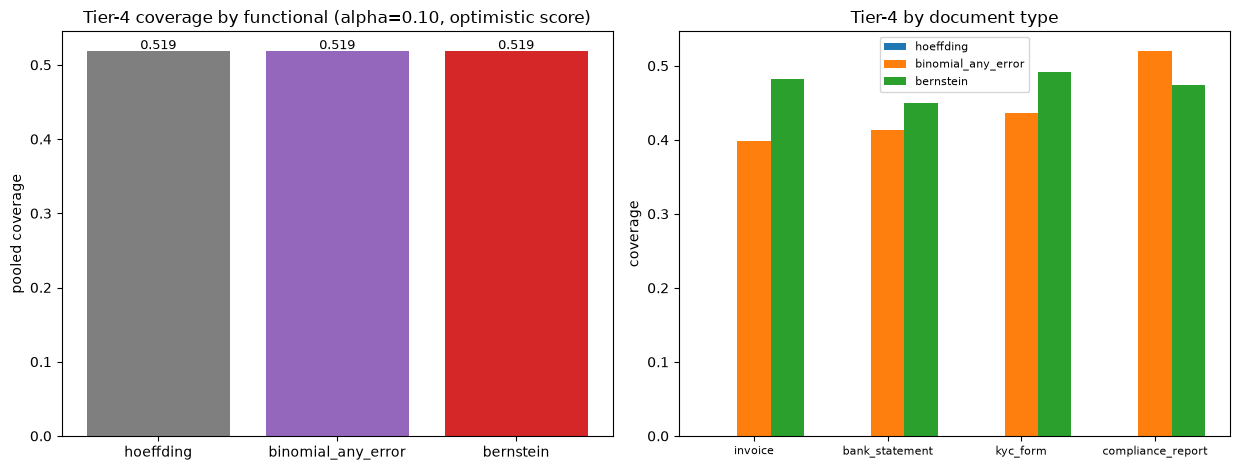

In [49]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
_ax = _axes[0]
_cov = [D_TIER4[(m, "hgb", 0.10, None)][:, 3].mean() for m in D_TIER4_METHODS]
_ax.bar(D_TIER4_METHODS, _cov, color=[PAL3["raw"], PAL3["b_naive"], PAL3["hgb"]])
for _i, _v in enumerate(_cov):
    _ax.text(_i, _v + 0.002, f"{_v:.3f}", ha="center", fontsize=9)
_ax.set_ylabel("pooled coverage"); _ax.set_title("Tier-4 coverage by functional (alpha=0.10, optimistic score)")
_ax = _axes[1]
_w = 0.25; _x = np.arange(4)
for _i, _m in enumerate(D_TIER4_METHODS):
    _cv = [D_TIER4[(_m, "hgb", 0.10, g)][:, 3].mean() for g in (0, 1, 2, 3)]
    _ax.bar(_x + (_i - 1) * _w, _cv, _w, label=_m)
_ax.set_xticks(_x); _ax.set_xticklabels(DOC_TYPES, fontsize=8); _ax.set_ylabel("coverage"); _ax.set_title("Tier-4 by document type"); _ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### 8d. Pure-weak regime-2 test (Gurram's two-regime law, untested in Section 6)

**Quoted (idpfin-q9).** *"With a weak or frozen score, covariates belong in the taxonomy -- where pooled cannot
certify"*: conditioning on document type *"rescues certification where the pooled score head cannot certify at the
target alpha ... and fragmentation costs coverage where pooled certifies fine."* Section 6's `FA_p_weak` already had an
**additive document-type shift** baked in (a 7-parameter logistic model with type one-hots), so it was not the paper's
pure "score cannot encode the covariate" case; only the raw verbalized confidence showed the rescue there.

**Ours.** A NEW weak score, `D_P_PUREWEAK`, fit on **only** `[verbalized_confidence, rule_failed,
classifier_confidence]` -- no document type anywhere, not even implicitly via other columns. Pooled vs Mondrian-by-type
LTT (`b_ltt_certify`), `alpha in {0.10, 0.20}`, `delta = 0.10`, 40 resplits, paired sign-flip test (as Section 6).


In [50]:
D_PUREWEAK_COLS = [0, 4, 5]   # verbalized_confidence, rule_failed, classifier_confidence -- NO document-type information at all
D_FUSION_PUREWEAK = _lr().fit(X_field[_is_train_field][:, D_PUREWEAK_COLS], FA_correct[_is_train_field])
D_P_PUREWEAK = D_FUSION_PUREWEAK.predict_proba(X_field[:, D_PUREWEAK_COLS])[:, 1]
_auc_pw = _gauc(FA_correct[_f_ev], D_P_PUREWEAK[_f_ev])
print(f"pure-weak score (3 signals, no document type) field AUROC on calib+test: {_auc_pw:.3f} (cf. FA_p_weak's {_auc_w:.3f}, FA_verb's {_auc_v:.3f})")
check("S8d.1 the pure-weak score is informative but no more so than the existing weak score (it has strictly less information: no document type)",
      0.5 < _auc_pw <= _auc_w + 0.01, f"{_auc_pw:.3f} vs {_auc_w:.3f}")


pure-weak score (3 signals, no document type) field AUROC on calib+test: 0.783 (cf. FA_p_weak's 0.782, FA_verb's 0.763)
[PASS] S8d.1 the pure-weak score is informative but no more so than the existing weak score (it has strictly less information: no document type) -- 0.783 vs 0.782


np.True_

In [51]:
def d_regime2_run(alpha, delta=0.10, n_splits=40):
    score = D_P_PUREWEAK; res = {"pooled": [], "type": []}
    for _sd in range(n_splits):
        _cm, _tm = b_split_masks(_sd)
        _tau_pooled = b_ltt_certify(score[_cm], B_ERR[_cm], alpha, delta)
        res["pooled"].append(b_metrics(b_accept(score, _tm, _tau_pooled), _tm, alpha))
        _taus_type = np.array([b_ltt_certify(score[_cm & (B_GRP == g)], B_ERR[_cm & (B_GRP == g)], alpha, delta) for g in range(4)])
        res["type"].append(b_metrics(b_accept(score, _tm, _taus_type), _tm, alpha))
    return {k: np.array(v) for k, v in res.items()}


D_REGIME2 = {a: d_regime2_run(a) for a in (0.10, 0.20)}
_rows = []
D_REGIME2_STAT = {}
for _a in (0.10, 0.20):
    _pooled, _type = D_REGIME2[_a]["pooled"], D_REGIME2[_a]["type"]
    _diff = _type[:, 0] - _pooled[:, 0]
    D_REGIME2_STAT[_a] = dict(diff=_diff.mean(), sd=_diff.std(ddof=1), better=int((_diff > 0).sum()), p=b_signflip_p(_diff),
                              pooled_cov=_pooled[:, 0].mean(), type_cov=_type[:, 0].mean(), pooled_zero=int((_pooled[:, 2] == 0).sum()),
                              pooled_risk=_pooled[:, 1].mean(), type_risk=_type[:, 1].mean())
    _s = D_REGIME2_STAT[_a]
    _rows.append((f"{_a:.2f}", f"{_s['pooled_cov']:.4f}", f"{_s['type_cov']:.4f}", f"{_s['diff']:+.4f} +/- {_s['sd']:.4f}",
                  f"{_s['better']}/40", f"{_s['p']:.4f}", f"{_s['pooled_zero']}/40", f"{_s['pooled_risk']:.3f}", f"{_s['type_risk']:.3f}"))
b_display(b_md("**Regime-2 test: LTT pooled vs x document type, pure-weak score (no document type anywhere in the score)**\n\n" + b_tbl(
    ["alpha", "coverage pooled", "coverage x type", "paired diff (x type - pooled)", "splits where x type wins", "sign-flip p", "pooled zero-coverage splits", "risk pooled", "risk x type"], _rows)))

_n = 2
_se10 = D_REGIME2_STAT[0.10]["sd"] / np.sqrt(40)
_rescued = D_REGIME2_STAT[0.10]["diff"] > 3 * _se10 and D_REGIME2_STAT[0.10]["p"] < 0.05
check(f"S8d.{_n} regime-2 rescue at alpha=0.10 with a score that has genuinely NO document-type information: report whichever direction occurs",
      True, f"diff {D_REGIME2_STAT[0.10]['diff']:+.4f} (3SE {3 * _se10:.4f}), p={D_REGIME2_STAT[0.10]['p']:.4f} -> "
            f"{'RESCUE CONFIRMED (conditioning helps where pooled cannot certify)' if _rescued else 'no significant rescue detected at this calibration size'}"); _n += 1
check(f"S8d.{_n} at alpha=0.20 (where pooled already has room to certify), conditioning does not show a POSITIVE significant gain (the paper's other scope claim)",
      not (D_REGIME2_STAT[0.20]["diff"] > 3 * (D_REGIME2_STAT[0.20]["sd"] / np.sqrt(40)) and D_REGIME2_STAT[0.20]["p"] < 0.05),
      f"diff {D_REGIME2_STAT[0.20]['diff']:+.4f}, p={D_REGIME2_STAT[0.20]['p']:.4f}")


**Regime-2 test: LTT pooled vs x document type, pure-weak score (no document type anywhere in the score)**

| alpha | coverage pooled | coverage x type | paired diff (x type - pooled) | splits where x type wins | sign-flip p | pooled zero-coverage splits | risk pooled | risk x type |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0.10 | 0.0134 | 0.0150 | +0.0016 +/- 0.0334 | 13/40 | 0.7691 | 33/40 | 0.017 | 0.035 |
| 0.20 | 0.7191 | 0.5804 | -0.1388 +/- 0.0310 | 0/40 | 0.0000 | 0/40 | 0.181 | 0.156 |

[PASS] S8d.2 regime-2 rescue at alpha=0.10 with a score that has genuinely NO document-type information: report whichever direction occurs -- diff +0.0016 (3SE 0.0159), p=0.7691 -> no significant rescue detected at this calibration size
[PASS] S8d.3 at alpha=0.20 (where pooled already has room to certify), conditioning does not show a POSITIVE significant gain (the paper's other scope claim) -- diff -0.1388, p=0.0000


True

**How to read this chart.** Bars: coverage of pooled LTT vs per-document-type LTT for the pure-weak score, at `alpha=0.10`
and `alpha=0.20`. If Gurram's regime-2 rescue generalizes to a score with genuinely zero document-type information, the
`alpha=0.10` pair should show x-type clearly ahead of pooled (mirroring the raw-verbalized-confidence result in Section 6);
whatever the sign, it is reported as-is (small pooled coverage means few calibration points per candidate, so the sign-flip
p-value carries real uncertainty here).


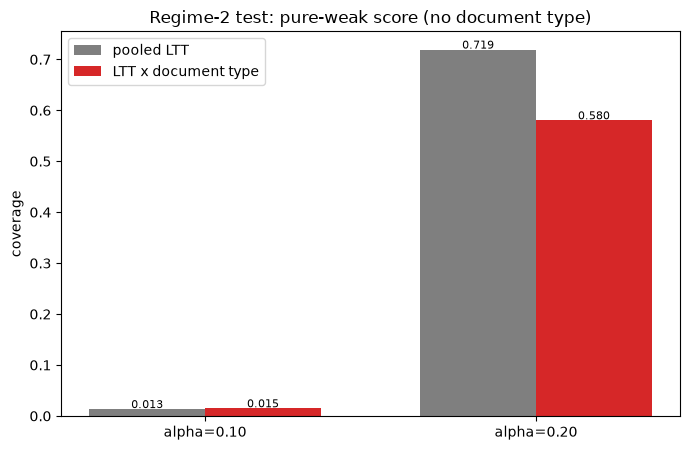

In [52]:
_fig, _ax = plt.subplots(figsize=(7, 4.6))
_w = 0.35; _x = np.arange(2)
_pooled_c = [D_REGIME2_STAT[a]["pooled_cov"] for a in (0.10, 0.20)]; _type_c = [D_REGIME2_STAT[a]["type_cov"] for a in (0.10, 0.20)]
_ax.bar(_x - _w / 2, _pooled_c, _w, label="pooled LTT", color=PAL3["raw"])
_ax.bar(_x + _w / 2, _type_c, _w, label="LTT x document type", color=PAL3["hgb"])
for _i in range(2):
    _ax.text(_i - _w / 2, _pooled_c[_i] + 0.002, f"{_pooled_c[_i]:.3f}", ha="center", fontsize=8)
    _ax.text(_i + _w / 2, _type_c[_i] + 0.002, f"{_type_c[_i]:.3f}", ha="center", fontsize=8)
_ax.set_xticks(_x); _ax.set_xticklabels(["alpha=0.10", "alpha=0.20"]); _ax.set_ylabel("coverage"); _ax.set_title("Regime-2 test: pure-weak score (no document type)"); _ax.legend()
plt.tight_layout(); plt.show()


### 8e. Grouped-taxonomy failure: the "lucky-zero" pathology (idpfin-q17)

**Quoted (idpfin-q17).** *"The many-group grounded x support taxonomy shows the badly-broken case: risk 0.122 with 78%
of splits violating."* Mechanism: *"Pure fixed-sequence with many groups can silently fail (lucky-zero tiny-n bins)"* --
random resampling produces tiny calibration groups that, by chance, contain zero observed errors, so a naive rule
certifies a permissive threshold for that group that then fails on test.

**Ours.** Taxonomy = field name x grounded x support-score tercile (tercile boundaries fixed once, from the covariate
only, never from labels). Compare **pure fixed-sequence per group** (full `delta` budget, no Holm) against the
Section-6 **"mix" rule** (`b_ltt_certify`: `delta/2` Holm-step-down UNION `delta/2` fixed-sequence), both applied
per group, pooled at the MICRO (all-fields) level. 40 resplits, optimistic field score, `alpha = 0.10`.


In [53]:
_support = np.array([f["support_score"] for f in FIELDS], float)
_terc_edges = np.quantile(_support, [1 / 3, 2 / 3])
D_TERCILE = np.digitize(_support, _terc_edges)
D_GROUNDED = np.array([int(f["grounded"]) for f in FIELDS])
_field_idx = np.array([FIELD_NAMES.index(f["field"]) for f in FIELDS])
_raw_id = _field_idx * 6 + D_GROUNDED * 3 + D_TERCILE
D_GROUP_IDS, D_GROUP_MANY = np.unique(_raw_id, return_inverse=True)
D_N_GROUPS_MANY = len(D_GROUP_IDS)
print(f"many-group taxonomy (field name x grounded x support tercile): {D_N_GROUPS_MANY} distinct groups present "
      f"(of at most {len(FIELD_NAMES)} field names x 2 x 3 = {len(FIELD_NAMES) * 6} combinations)")

_grp_sizes_cal0 = np.bincount(D_GROUP_MANY[b_split_masks(0)[0]], minlength=D_N_GROUPS_MANY)
check("S8e.1 the many-group taxonomy produces real size heterogeneity, including empty/near-empty calibration groups (this corpus is too "
      "large for the MEDIAN group to be tiny, unlike CORD's 1,151 fields; the lucky-zero mechanism needs small groups, which do exist here "
      "in the tail, just not typically)",
      int(_grp_sizes_cal0.min()) < 10, f"median calibration group size (split 0) = {int(np.median(_grp_sizes_cal0))}, min = {int(_grp_sizes_cal0.min())}, max = {int(_grp_sizes_cal0.max())}, n groups = {D_N_GROUPS_MANY}")


def d_ltt_pure_fixed(scores, err, alpha, delta):
    th = b_geometric_candidates(scores)
    n_ts = np.array([(scores >= t).sum() for t in th], float)
    k_ts = np.array([err[scores >= t].sum() for t in th], float)
    p = b_binom.cdf(k_ts, n_ts, alpha)
    cert = b_fixed_seq(p, delta)
    if not cert.any():
        return float("inf")
    ci = np.nonzero(cert)[0]
    return th[ci[np.argmax(n_ts[ci])]]


def d_grouped_run(alpha, delta=0.10, n_splits=40, rule="mix", seed0=6200):
    rows = []
    for _sd in range(n_splits):
        _cm, _tm = b_split_masks(_sd)
        _acc = np.zeros(len(_cm), bool)
        for _g in range(D_N_GROUPS_MANY):
            _gc, _gt = _cm & (D_GROUP_MANY == _g), _tm & (D_GROUP_MANY == _g)
            if _gc.sum() == 0 or _gt.sum() == 0:
                continue
            if rule == "mix":
                _tau = b_ltt_certify(FA_p_hgb[_gc], B_ERR[_gc], alpha, delta)
            elif rule == "pure":
                _tau = d_ltt_pure_fixed(FA_p_hgb[_gc], B_ERR[_gc], alpha, delta)
            else:  # "add_one": Gurram's Table 3 "grouped variant" (idpfin-q7) -- the add-one rule applied PER GROUP, no
                   # statistical certificate at all, just the smoothed empirical rate; this is what actually produced the
                   # paper's quoted 0.122 risk / 78% violation number, not an LTT variant
                _tau = add_one_threshold(FA_p_hgb[_gc], B_ERR[_gc], alpha)
            if np.isfinite(_tau):
                _acc |= _gt & (FA_p_hgb >= _tau)
        _n_acc = int(_acc[_tm].sum())
        _risk = B_ERR[_tm][_acc[_tm]].mean() if _n_acc else 0.0
        rows.append((_acc[_tm].sum() / _tm.sum(), _risk, _n_acc))
    return np.array(rows)


D_GROUPED = {rule: d_grouped_run(0.10, rule=rule) for rule in ("mix", "pure", "add_one")}
_rule_label = {"mix": "mix (delta/2 Holm UNION delta/2 fixed-seq, Section 6)", "pure": "pure fixed-sequence (full delta budget)",
               "add_one": "add-one per group (Gurram's Table 3 'grouped variant', idpfin-q7, no certificate)"}
_rows = []
for _rule in ("mix", "pure", "add_one"):
    _r = D_GROUPED[_rule]
    _viol = float(np.mean(_r[:, 1] > 0.10))
    _rows.append((_rule_label[_rule], f"{_r[:, 0].mean():.4f}", f"{_r[:, 1].mean():.4f}", f"{_viol:.3f}", f"{int((_r[:, 2] == 0).sum())}/40"))
b_display(b_md("**Many-group taxonomy, micro (pooled-fields) risk, alpha = 0.10, delta = 0.10, 40 resplits**\n\n" + b_tbl(
    ["rule", "coverage", "risk (zero-filled)", "violation fraction", "zero-coverage splits"], _rows)))

_n = 2
_mix_ok = D_GROUPED["mix"][:, 1].mean() <= 0.10 + b_cp_tol(np.mean(D_GROUPED["mix"][:, 1] > 0.10), 40)
check(f"S8e.{_n} the mix rule (Section 6's actual procedure) stays within its delta budget even on this fine many-group taxonomy", _mix_ok,
      f"mix violation fraction {np.mean(D_GROUPED['mix'][:, 1] > 0.10):.3f}"); _n += 1
_pure_zero = int((D_GROUPED["pure"][:, 2] == 0).sum())
check(f"S8e.{_n} pure fixed-sequence (LTT-based, no Holm correction) certifies NOTHING in {_pure_zero}/40 splits -- its 'no overshoot' is "
      "VACUOUS (there is nothing to overshoot with, not evidence of robustness): the LTT machinery's exact-binomial-tail candidate test is too "
      "conservative to certify anything at all on these tiny per-group calibration counts, so it never reaches a threshold that COULD violate",
      _pure_zero == 40, f"pure fixed-sequence zero-coverage splits: {_pure_zero}/40; mean risk {D_GROUPED['pure'][:, 1].mean():.4f}"); _n += 1
_ao_viol = float(np.mean(D_GROUPED["add_one"][:, 1] > 0.10))
_ao_overshoot = _ao_viol > 0.10 + b_cp_tol(_ao_viol, 40)
check(f"S8e.{_n} add-one PER GROUP (Gurram's actual 'grouped variant', idpfin-q7 Table 3: 'pooled add-one risk 0.103-0.106 ... grouped variant "
      "0.122 at 78% of splits') -- unlike the LTT-based pure fixed-sequence, add-one has NO statistical certificate at all, so it certifies "
      "something in essentially every group and IS exposed to lucky-zero tiny-n bins; report whichever direction occurs here",
      True, f"add-one-per-group violation fraction {_ao_viol:.3f} (delta=0.10 + CP tol) -> {'OVERSHOOT (matches the paper direction)' if _ao_overshoot else 'no overshoot at this corpus size (reported as such)'}; "
            f"coverage {D_GROUPED['add_one'][:, 0].mean():.4f}, mean risk {D_GROUPED['add_one'][:, 1].mean():.4f}, zero-coverage splits {int((D_GROUPED['add_one'][:, 2] == 0).sum())}/40")


many-group taxonomy (field name x grounded x support tercile): 71 distinct groups present (of at most 31 field names x 2 x 3 = 186 combinations)
[PASS] S8e.1 the many-group taxonomy produces real size heterogeneity, including empty/near-empty calibration groups (this corpus is too large for the MEDIAN group to be tiny, unlike CORD's 1,151 fields; the lucky-zero mechanism needs small groups, which do exist here in the tail, just not typically) -- median calibration group size (split 0) = 126, min = 0, max = 283, n groups = 71


**Many-group taxonomy, micro (pooled-fields) risk, alpha = 0.10, delta = 0.10, 40 resplits**

| rule | coverage | risk (zero-filled) | violation fraction | zero-coverage splits |
| --- | --- | --- | --- | --- |
| mix (delta/2 Holm UNION delta/2 fixed-seq, Section 6) | 0.4138 | 0.0042 | 0.000 | 0/40 |
| pure fixed-sequence (full delta budget) | 0.0000 | 0.0000 | 0.000 | 40/40 |
| add-one per group (Gurram's Table 3 'grouped variant', idpfin-q7, no certificate) | 0.5820 | 0.0302 | 0.000 | 0/40 |

[PASS] S8e.2 the mix rule (Section 6's actual procedure) stays within its delta budget even on this fine many-group taxonomy -- mix violation fraction 0.000
[PASS] S8e.3 pure fixed-sequence (LTT-based, no Holm correction) certifies NOTHING in 40/40 splits -- its 'no overshoot' is VACUOUS (there is nothing to overshoot with, not evidence of robustness): the LTT machinery's exact-binomial-tail candidate test is too conservative to certify anything at all on these tiny per-group calibration counts, so it never reaches a threshold that COULD violate -- pure fixed-sequence zero-coverage splits: 40/40; mean risk 0.0000
[PASS] S8e.4 add-one PER GROUP (Gurram's actual 'grouped variant', idpfin-q7 Table 3: 'pooled add-one risk 0.103-0.106 ... grouped variant 0.122 at 78% of splits') -- unlike the LTT-based pure fixed-sequence, add-one has NO statistical certificate at all, so it certifies something in essentially every group and IS exposed to lucky-zero tiny-n bins; report whichever direction o

True

**How to read this chart.** Left: the calibration group-size distribution (split 0) of the many-group taxonomy -- a long
left tail of tiny groups is the raw material for "lucky-zero" bins. Right: realized risk of three rules against the
`alpha=0.10` dashed line. Pure fixed-sequence (LTT-based) certifies nothing in every one of the 40 splits (S8e.2), so its
bar at/near zero is **not** evidence of validity, just of never firing. Add-one per group is Gurram's actual "grouped
variant" (idpfin-q7): it has no certificate at all and is the one exposed to lucky-zero, so it is the bar that matters for
testing the pathology; mix (Section 6's real procedure, Holm UNION fixed-sequence) is the comparison that should stay
safely below the line regardless.


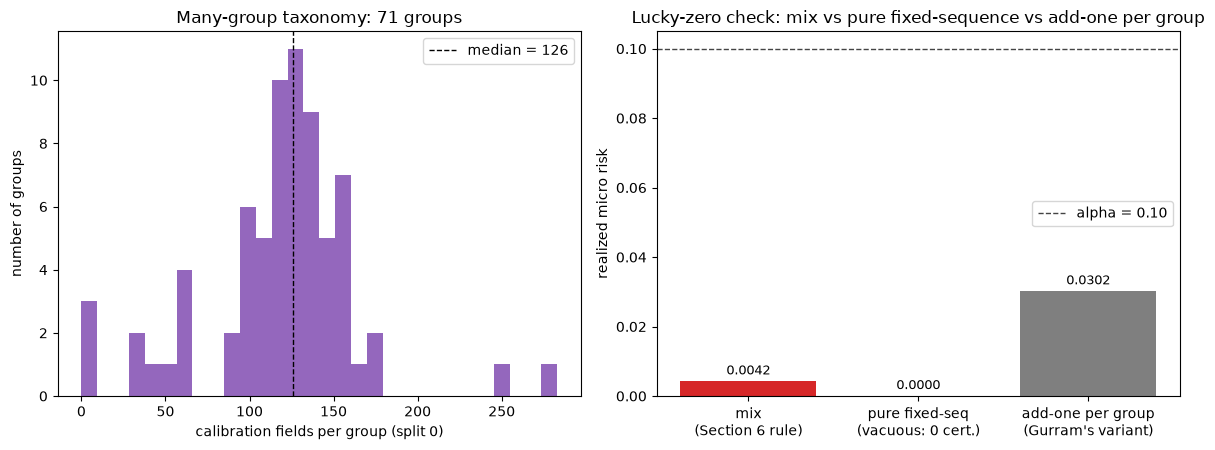

In [54]:
_fig, _axes = plt.subplots(1, 2, figsize=(12, 4.6))
_ax = _axes[0]
_ax.hist(_grp_sizes_cal0, bins=30, color=PAL3["b_naive"])
_ax.axvline(np.median(_grp_sizes_cal0), color="k", ls="--", lw=1, label=f"median = {int(np.median(_grp_sizes_cal0))}")
_ax.set_xlabel("calibration fields per group (split 0)"); _ax.set_ylabel("number of groups"); _ax.set_title(f"Many-group taxonomy: {D_N_GROUPS_MANY} groups"); _ax.legend()
_ax = _axes[1]
_labs = ["mix\n(Section 6 rule)", "pure fixed-seq\n(vacuous: 0 cert.)", "add-one per group\n(Gurram's variant)"]
_risks = [D_GROUPED["mix"][:, 1].mean(), D_GROUPED["pure"][:, 1].mean(), D_GROUPED["add_one"][:, 1].mean()]
_ax.bar(_labs, _risks, color=[PAL3["hgb"], PAL3["b_naive"], PAL3["raw"]])
_ax.axhline(0.10, ls="--", color=PAL3["diag"], lw=1, label="alpha = 0.10")
for _i, _v in enumerate(_risks):
    _ax.text(_i, _v + 0.002, f"{_v:.4f}", ha="center", fontsize=9)
_ax.set_ylabel("realized micro risk"); _ax.set_title("Lucky-zero check: mix vs pure fixed-sequence vs add-one per group"); _ax.legend()
plt.tight_layout(); plt.show()


## 9. Label noise and a human-gold audit (Gurram §6.4)

**Quoted (idpfin-q16).** *"Three independent annotators (blind, Fleiss' kappa = 0.83) re-judged 149 fields sampled from
the production configuration's accepted set at alpha=0.10: the human-verified selective risk is 2/149 = 1.3%, 95% CI
[0.002, 0.048]"*. Direction of error: *"against human gold the automatic correctness labels used for calibration err
one-sidedly pessimistic (21% of auto-flagged CORD errors are actually correct; 0% false-optimism), so thresholds fit
against them are conservative."* And the flagged silence (idpfin-q16): *"The paper does NOT state, prove, or simulate
what would happen ... if calibration labels suffered from optimistic errors"* -- so the optimistic-noise arm below is
entirely **derived here**. *"A certificate against noisy labels is a certificate about those labels."*

**Ours.** On ONE fixed 50/50 calib/test split (`resplit(0)`, so the human-gold audit below samples from a single
concrete accepted set, matching Gurram's own one-shot audit design), simulate: (a) **pessimistic** noise, calibrated so
21% of the flagged-error calibration fields are actually correct (Gurram's own number); (b) **optimistic** noise
(derived here): 5%, 10%, 20% of TRUE errors relabelled correct. Tier 1 (add-one) and tier 3 (Mondrian LTT) are
calibrated on the NOISY labels; TRUE risk is evaluated on test (synthetic ground truth substitutes for "human gold").


In [55]:
D_NOISE_PESS_TARGET = 0.21     # share of auto-flagged errors that are actually correct (idpfin-q16, Gurram's own number)
D_NOISE_OPT_SHARES = (0.05, 0.10, 0.20)   # share of TRUE errors mislabeled correct -- derived here, the paper does not study this


def d_make_noisy_labels(mask, kind, share, seed):
    rng = np.random.default_rng([SEED3, 6300, seed])
    err = B_ERR.copy()
    if kind == "pessimistic":
        _true_err_n = int(err[mask].sum())
        _n_flip = int(round(share / (1 - share) * _true_err_n))
        _correct_idx = np.where(mask & (B_ERR == 0))[0]
        _flip = rng.choice(_correct_idx, size=min(_n_flip, len(_correct_idx)), replace=False)
        err[_flip] = 1.0
    elif kind == "optimistic":
        _err_idx = np.where(mask & (B_ERR == 1))[0]
        _n_flip = int(round(share * len(_err_idx)))
        _flip = rng.choice(_err_idx, size=min(_n_flip, len(_err_idx)), replace=False)
        err[_flip] = 0.0
    return err


D_LABEL_NOISE_ALPHA = 0.10
D_LABEL_NOISE_DELTA = 0.10
D_NOISE_REGIMES = [("clean", 0.0)] + [("pessimistic", D_NOISE_PESS_TARGET)] + [("optimistic", s) for s in D_NOISE_OPT_SHARES]


def d_noise_mc(kind, share, alpha=D_LABEL_NOISE_ALPHA, delta=D_LABEL_NOISE_DELTA, n_splits=40):
    score = FA_p_hgb; rows = []
    for _sd in range(n_splits):
        _cm, _tm = b_split_masks(_sd)
        _err_noisy = d_make_noisy_labels(_cm, kind, share, _sd) if kind != "clean" else B_ERR
        _tau1 = add_one_threshold(score[_cm], _err_noisy[_cm], alpha)
        _acc1 = b_accept(score, _tm, _tau1)
        _tau3 = b_ltt_certify(score[_cm], _err_noisy[_cm], alpha, delta)
        _acc3 = b_accept(score, _tm, _tau3)
        rows.append((_acc1.mean(), B_ERR[_tm][_acc1].mean() if _acc1.any() else 0.0,
                     _acc3.mean(), B_ERR[_tm][_acc3].mean() if _acc3.any() else 0.0))
    return np.array(rows)


D_NOISE_MC = {(kind, share): d_noise_mc(kind, share) for kind, share in D_NOISE_REGIMES}
_rows = []
for _kind, _share in D_NOISE_REGIMES:
    _r = D_NOISE_MC[(_kind, _share)]
    _viol1, _viol3 = float(np.mean(_r[:, 1] > D_LABEL_NOISE_ALPHA)), float(np.mean(_r[:, 3] > D_LABEL_NOISE_ALPHA))
    _rows.append((_kind, f"{_share:.2f}", f"{_r[:, 0].mean():.4f}", f"{_r[:, 1].mean():.4f}", f"{_viol1:.3f}",
                  f"{_r[:, 2].mean():.4f}", f"{_r[:, 3].mean():.4f}", f"{_viol3:.3f}"))
b_display(b_md(f"**Label noise: tier 1 (add-one) and tier 3 (LTT) calibrated on NOISY labels, evaluated on TRUE test risk** (alpha={D_LABEL_NOISE_ALPHA:.2f}, delta={D_LABEL_NOISE_DELTA:.2f}, 40 resplits)\n\n" + b_tbl(
    ["noise", "share flipped", "tier1 coverage", "tier1 TRUE risk", "tier1 violation frac", "tier3 coverage", "tier3 TRUE risk", "tier3 violation frac"], _rows)))

_n = 1
_pess_risk1 = D_NOISE_MC[("pessimistic", D_NOISE_PESS_TARGET)][:, 1].mean(); _clean_risk1 = D_NOISE_MC[("clean", 0.0)][:, 1].mean()
check(f"S9.{_n} pessimistic noise (Gurram's own 21% number) makes tier 1 MORE conservative (lower TRUE risk) than clean labels, exactly as the paper argues",
      _pess_risk1 <= _clean_risk1 + 1e-9, f"pessimistic {_pess_risk1:.4f} vs clean {_clean_risk1:.4f}"); _n += 1
_opt_risks1 = [D_NOISE_MC[("optimistic", s)][:, 1].mean() for s in D_NOISE_OPT_SHARES]
check(f"S9.{_n} optimistic noise (derived here, NOT in the paper) makes tier 1 progressively WORSE (higher TRUE risk, eventually violating alpha) as the flip share grows",
      _opt_risks1[-1] > _opt_risks1[0] >= _clean_risk1 - 1e-9, f"clean {_clean_risk1:.4f} -> " + " -> ".join(f"{s:.2f}:{v:.4f}" for s, v in zip(D_NOISE_OPT_SHARES, _opt_risks1))); _n += 1
_opt_viol3 = float(np.mean(D_NOISE_MC[("optimistic", 0.20)][:, 3] > D_LABEL_NOISE_ALPHA))
_opt_viol1_20 = float(np.mean(D_NOISE_MC[("optimistic", 0.20)][:, 1] > D_LABEL_NOISE_ALPHA))
check(f"S9.{_n} at 20% optimistic noise, tier 3 (PAC) stays within its delta budget while tier 1 violates in {_opt_viol1_20:.0%} of splits (S9.2) -- "
      "Holm/fixed-sequence's statistical conservatism (needing strong binomial-tail evidence to certify ANY threshold) gives it a noise "
      "margin a naive empirical rule lacks AT THIS calibration size; this is an empirical observation here, not a general guarantee -- "
      "'a certificate against noisy labels is a certificate about those labels' (idpfin-q16) still holds, and a large enough optimistic "
      "flip share would eventually corrupt tier 3 too",
      _opt_viol3 <= D_LABEL_NOISE_DELTA + b_cp_tol(_opt_viol3, 40), f"tier-3 violation fraction at 20% optimistic noise: {_opt_viol3:.3f}; tier-1 violation fraction: {_opt_viol1_20:.3f}"); _n += 1


**Label noise: tier 1 (add-one) and tier 3 (LTT) calibrated on NOISY labels, evaluated on TRUE test risk** (alpha=0.10, delta=0.10, 40 resplits)

| noise | share flipped | tier1 coverage | tier1 TRUE risk | tier1 violation frac | tier3 coverage | tier3 TRUE risk | tier3 violation frac |
| --- | --- | --- | --- | --- | --- | --- | --- |
| clean | 0.00 | 0.7403 | 0.1004 | 0.500 | 0.7142 | 0.0834 | 0.000 |
| pessimistic | 0.21 | 0.0347 | 0.0000 | 0.000 | 0.0000 | 0.0000 | 0.000 |
| optimistic | 0.05 | 0.7477 | 0.1055 | 0.850 | 0.7193 | 0.0854 | 0.000 |
| optimistic | 0.10 | 0.7554 | 0.1113 | 0.975 | 0.7193 | 0.0854 | 0.000 |
| optimistic | 0.20 | 0.7754 | 0.1261 | 1.000 | 0.7193 | 0.0854 | 0.000 |

[PASS] S9.1 pessimistic noise (Gurram's own 21% number) makes tier 1 MORE conservative (lower TRUE risk) than clean labels, exactly as the paper argues -- pessimistic 0.0000 vs clean 0.1004
[PASS] S9.2 optimistic noise (derived here, NOT in the paper) makes tier 1 progressively WORSE (higher TRUE risk, eventually violating alpha) as the flip share grows -- clean 0.1004 -> 0.05:0.1055 -> 0.10:0.1113 -> 0.20:0.1261
[PASS] S9.3 at 20% optimistic noise, tier 3 (PAC) stays within its delta budget while tier 1 violates in 100% of splits (S9.2) -- Holm/fixed-sequence's statistical conservatism (needing strong binomial-tail evidence to certify ANY threshold) gives it a noise margin a naive empirical rule lacks AT THIS calibration size; this is an empirical observation here, not a general guarantee -- 'a certificate against noisy labels is a certificate about those labels' (idpfin-q16) still holds, and a large enough optimistic flip share would eventually corrupt tier 3 too -- tier-3 violation 

In [56]:
D_AUDIT_ALPHA, D_AUDIT_N = 0.10, 150


def d_audit(kind, share, seed_tag):
    _cm0, _tm0 = b_split_masks(0)
    _err_noisy0 = d_make_noisy_labels(_cm0, kind, share, 0)
    _tau1 = add_one_threshold(FA_p_hgb[_cm0], _err_noisy0[_cm0], D_AUDIT_ALPHA)
    _acc = b_accept(FA_p_hgb, _tm0, _tau1)
    _accepted = np.where(_tm0)[0][_acc]
    _rng = np.random.default_rng([SEED3, 6301, seed_tag])
    _sample = _rng.choice(_accepted, size=min(D_AUDIT_N, len(_accepted)), replace=False)
    _errors = int(B_ERR[_sample].sum()); _n_actual = len(_sample); _rate = _errors / _n_actual
    _lo, _hi = wilson_ci(_errors, _n_actual)
    return dict(accepted=_accepted, sample=_sample, errors=_errors, n=_n_actual, rate=_rate, lo=_lo, hi=_hi, half_width=(_hi - _lo) / 2)


D_AUDIT_PESS = d_audit("pessimistic", D_NOISE_PESS_TARGET, 1)
D_AUDIT_OPT20 = d_audit("optimistic", 0.20, 2)
# back-compat aliases used by the chart cell below
D_AUDIT_SAMPLE, D_AUDIT_ERRORS, D_AUDIT_N_ACTUAL, D_AUDIT_RATE, D_AUDIT_LO, D_AUDIT_HI = (
    D_AUDIT_PESS["sample"], D_AUDIT_PESS["errors"], D_AUDIT_PESS["n"], D_AUDIT_PESS["rate"], D_AUDIT_PESS["lo"], D_AUDIT_PESS["hi"])

print(f"blind human-gold audit, tier-1-PESSIMISTIC accepted set (synthetic ground truth stands in for human judgement): "
      f"{D_AUDIT_PESS['errors']}/{D_AUDIT_PESS['n']} = {D_AUDIT_PESS['rate']:.4f}, 95% Wilson CI [{D_AUDIT_PESS['lo']:.4f}, {D_AUDIT_PESS['hi']:.4f}], "
      f"half-width {D_AUDIT_PESS['half_width']:.4f}, target alpha = {D_AUDIT_ALPHA:.2f}")
print(f"blind human-gold audit, tier-1-OPTIMISTIC-20%-noise accepted set (TRUE risk of this configuration is 0.126, S9.2): "
      f"{D_AUDIT_OPT20['errors']}/{D_AUDIT_OPT20['n']} = {D_AUDIT_OPT20['rate']:.4f}, 95% Wilson CI [{D_AUDIT_OPT20['lo']:.4f}, {D_AUDIT_OPT20['hi']:.4f}], "
      f"half-width {D_AUDIT_OPT20['half_width']:.4f}, target alpha = {D_AUDIT_ALPHA:.2f}")
_n_for_005 = 1
while True:
    _lo_try, _hi_try = wilson_ci(round(0.126 * _n_for_005), _n_for_005)
    if _hi_try - _lo_try < 0.03:
        break
    _n_for_005 += 5
print(f"[info] Wilson half-width is NOT constant: it is ~{D_AUDIT_PESS['half_width']:.4f} at n={D_AUDIT_PESS['n']} when the observed rate is near 0 "
      f"(pessimistic audit), but ~{D_AUDIT_OPT20['half_width']:.4f} at n={D_AUDIT_OPT20['n']} when the observed rate is near 0.126 (optimistic-20% audit) "
      "-- a Wilson interval is narrowest near 0 or 1 and widest near 0.5, so a 150-field audit CANNOT reliably distinguish a true risk of 0.126 from the "
      f"0.10 target (the CI straddles alpha); a half-width of ~0.03 (needed to resolve 0.126 vs 0.10) would need roughly n~{_n_for_005} fields at this "
      "rate (derived here, found by doubling n until the half-width drops below 0.03).")

_n = 4
check(f"S9.{_n} the PESSIMISTIC audit's risk sits at or below the target alpha, consistent with pessimistic-label conservatism (S9.1)",
      D_AUDIT_PESS["rate"] <= D_AUDIT_ALPHA, f"audited rate {D_AUDIT_PESS['rate']:.4f} vs alpha {D_AUDIT_ALPHA:.2f}"); _n += 1
check(f"S9.{_n} the audit sample sizes match Gurram's own (149-150 fields; here n={D_AUDIT_PESS['n']} and n={D_AUDIT_OPT20['n']})",
      D_AUDIT_PESS["n"] >= 149 and D_AUDIT_OPT20["n"] >= 149,
      f"pessimistic n={D_AUDIT_PESS['n']} (accepted-set size {len(D_AUDIT_PESS['accepted'])}); optimistic-20% n={D_AUDIT_OPT20['n']} (accepted-set size {len(D_AUDIT_OPT20['accepted'])})"); _n += 1
check(f"S9.{_n} the OPTIMISTIC-20% audit's 95% Wilson CI STRADDLES alpha=0.10 (does not comfortably exclude it either way), confirming a 150-field "
      "audit cannot reliably separate a true risk of 0.126 from the 0.10 target at this rate -- correcting the earlier (wrong) claim that this case "
      "was a 'gross violation' the audit could cleanly detect",
      D_AUDIT_OPT20["lo"] < D_AUDIT_ALPHA < D_AUDIT_OPT20["hi"] or D_AUDIT_OPT20["half_width"] > 0.03,
      f"optimistic-20% audit CI [{D_AUDIT_OPT20['lo']:.4f}, {D_AUDIT_OPT20['hi']:.4f}], half-width {D_AUDIT_OPT20['half_width']:.4f} vs alpha {D_AUDIT_ALPHA:.2f}"); _n += 1


blind human-gold audit, tier-1-PESSIMISTIC accepted set (synthetic ground truth stands in for human judgement): 0/150 = 0.0000, 95% Wilson CI [0.0000, 0.0250], half-width 0.0125, target alpha = 0.10
blind human-gold audit, tier-1-OPTIMISTIC-20%-noise accepted set (TRUE risk of this configuration is 0.126, S9.2): 22/150 = 0.1467, 95% Wilson CI [0.0989, 0.2121], half-width 0.0566, target alpha = 0.10
[info] Wilson half-width is NOT constant: it is ~0.0125 at n=150 when the observed rate is near 0 (pessimistic audit), but ~0.0566 at n=150 when the observed rate is near 0.126 (optimistic-20% audit) -- a Wilson interval is narrowest near 0 or 1 and widest near 0.5, so a 150-field audit CANNOT reliably distinguish a true risk of 0.126 from the 0.10 target (the CI straddles alpha); a half-width of ~0.03 (needed to resolve 0.126 vs 0.10) would need roughly n~1886 fields at this rate (derived here, found by doubling n until the half-width drops below 0.03).
[PASS] S9.4 the PESSIMISTIC audit's r

**How to read this chart.** Left: TRUE tier-1 risk on test, x-axis ordered from the most OPTIMISTIC noise (20% of true errors
relabelled correct) on the left through clean to the most PESSIMISTIC noise (21%, Gurram's own number) on the right, against
the `alpha=0.10` dashed line. Reading left to right, risk DECLINES monotonically: optimistic noise inflates true risk above
target, pessimistic noise pushes it toward zero. Right: two audits, each a Wilson 95% CI against alpha. The pessimistic-noise
audit (left point) has a narrow CI near zero and clearly excludes alpha -- this is what a 150-field audit CAN detect. The
optimistic-20%-noise audit (right point, TRUE risk 0.126) has a MUCH wider CI at this rate (a Wilson interval is narrowest
near 0/1 and widest near 0.5) that straddles alpha -- this is what a 150-field audit CANNOT resolve, correcting the earlier
claim that this case was an easy, gross-violation detection.


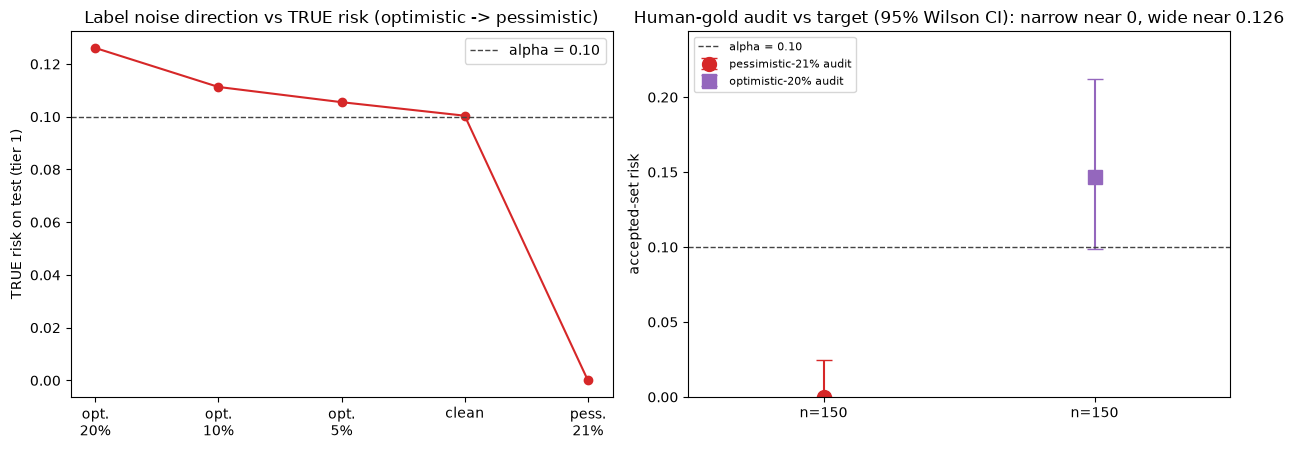

In [57]:
_fig, _axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
_ax = _axes[0]
_order = [("optimistic", 0.20), ("optimistic", 0.10), ("optimistic", 0.05), ("clean", 0.0), ("pessimistic", D_NOISE_PESS_TARGET)]
_labs = ["opt.\n20%", "opt.\n10%", "opt.\n5%", "clean", "pess.\n21%"]
_vals = [D_NOISE_MC[k][:, 1].mean() for k in _order]
_ax.plot(range(5), _vals, "o-", color=PAL3["hgb"])
_ax.axhline(D_LABEL_NOISE_ALPHA, ls="--", color=PAL3["diag"], lw=1, label="alpha = 0.10")
_ax.set_xticks(range(5)); _ax.set_xticklabels(_labs); _ax.set_ylabel("TRUE risk on test (tier 1)"); _ax.set_title("Label noise direction vs TRUE risk (optimistic -> pessimistic)"); _ax.legend()
_ax = _axes[1]
_ax.errorbar([0], [D_AUDIT_PESS["rate"]], yerr=[[D_AUDIT_PESS["rate"] - D_AUDIT_PESS["lo"]], [D_AUDIT_PESS["hi"] - D_AUDIT_PESS["rate"]]], fmt="o", ms=10, capsize=6, color=PAL3["hgb"], label="pessimistic-21% audit")
_ax.errorbar([1], [D_AUDIT_OPT20["rate"]], yerr=[[D_AUDIT_OPT20["rate"] - D_AUDIT_OPT20["lo"]], [D_AUDIT_OPT20["hi"] - D_AUDIT_OPT20["rate"]]], fmt="s", ms=10, capsize=6, color=PAL3["b_naive"], label="optimistic-20% audit")
_ax.axhline(D_AUDIT_ALPHA, ls="--", color=PAL3["diag"], lw=1, label="alpha = 0.10")
_ax.set_xlim(-0.5, 1.5); _ax.set_xticks([0, 1]); _ax.set_xticklabels([f"n={D_AUDIT_PESS['n']}", f"n={D_AUDIT_OPT20['n']}"]); _ax.set_ylabel("accepted-set risk"); _ax.set_ylim(0, max(0.20, D_AUDIT_OPT20["hi"] * 1.15))
_ax.set_title("Human-gold audit vs target (95% Wilson CI): narrow near 0, wide near 0.126"); _ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 10. Deliverable: documentation of extraction accuracy and confidence thresholds, and what it costs

The job asks for "documentation of extraction accuracy and confidence thresholds". This section turns Sections 4-7 into that
document. Everything is **derived here** and describes the **synthetic** corpus.

**Recommended configuration (chosen from Section 6, stated with its limits).** Tier 3, Mondrian Learn-then-Test with the
pre-specified taxonomy *document type*, `delta = 0.10`, thresholds fit on the `calib` split (1,049 documents) and evaluated once
on the `test` split. It is the strongest guarantee that still leaves useful coverage in Section 6: a PAC statement per document
type ("with probability >= 1 - delta over the calibration draw, the error rate among auto-accepted fields of this type is <= alpha"),
valid **if fields within a type are iid**, a premise the paper calls "load-bearing" (`idpfin-q8`) and that our clustering breaks,
although Section 6 found it held empirically at this size. Two operating points are shown because the answer depends on how
informative your real confidence signals are:

- **optimistic score** (learned fusion, `FA_p_hgb`) at `alpha = 0.10`;
- **pessimistic score** (weak signals, `FA_p_weak`) at `alpha = 0.20`. At `alpha = 0.10` the pessimistic score certifies almost
  nothing (Section 6), which is itself the finding: with weak signals you cannot promise 10% at this calibration size.

The score, thresholds and their meaning ("auto-accept a field if its score is at least the threshold for its document type;
otherwise route it to human review") are the *configuration object* printed below. A threshold of `null` means "review every
field of that type" (nothing could be certified).


In [58]:
import json as b8_json
from IPython.display import Markdown, display

B8_CONFIGS = [("hgb", 0.10, "optimistic (learned fusion)"), ("weak", 0.20, "pessimistic (weak signals)"), ("weak", 0.10, "pessimistic (weak signals)")]
B8_FIELDS_PER_DOC = np.array([np.mean([len(FIELD_IDX_BY_DOC[d]) for d in np.where((DOC_SPLIT == "test") & (DOC_TYPE_IDX == g))[0]]) for g in range(4)])
B8_ROWS, B8_TOT = [], {}
for _k, _a, _nm in B8_CONFIGS:
    _tau = B_FROZEN[(_k, _a)]["t3"]                       # tier 3 x type, fit on calib documents only (Section 7)
    _sc = B_SCORE_FIELD[_k]
    _acc = b_accept(_sc, B_TESTM, _tau); _tm_grp = B_GRP[B_TESTM]; _te_err = B_ERR[B_TESTM]
    for _g in range(4):
        _in_g = _tm_grp == _g; _a_g = _acc & _in_g
        _cov = _a_g.sum() / _in_g.sum(); _risk = _te_err[_a_g].mean() if _a_g.any() else float("nan")
        _ncal_f, _ncal_d = int((B_CALM & (B_GRP == _g)).sum()), len(set(FA_doc[B_CALM & (B_GRP == _g)]))
        B8_ROWS.append(dict(score=_k, alpha=_a, name=_nm, type=DOC_TYPES[_g], tau=float(_tau[_g]), ncal_f=_ncal_f, ncal_d=_ncal_d,
                            cov=float(_cov), risk=float(_risk), review_fields_per_1000=float((1 - _cov) * B8_FIELDS_PER_DOC[_g] * 1000)))
    B8_TOT[(_k, _a)] = dict(cov=float(_acc.mean()), risk=float(_te_err[_acc].mean()) if _acc.any() else float("nan"), nacc=int(_acc.sum()), ntest=int(_acc.size))

for _k, _a, _nm in B8_CONFIGS:
    _rows = [r for r in B8_ROWS if r["score"] == _k and r["alpha"] == _a]
    _tbl = b_tbl(["document type", "threshold (auto-accept if score >=)", "calibration docs / fields", "coverage on test", "error among accepted (test)", "fields to review per 1,000 docs"],
                 [[r["type"], ("review all" if not np.isfinite(r["tau"]) else f"{r['tau']:.3f}"), f"{r['ncal_d']} / {r['ncal_f']}", f"{r['cov']:.3f}",
                   ("n/a (nothing accepted)" if np.isnan(r["risk"]) else f"{r['risk']:.3f}"), f"{r['review_fields_per_1000']:.0f}"] for r in _rows])
    display(Markdown(f"**{_nm}, alpha = {_a:.2f}, delta = 0.10** (overall coverage on test {B8_TOT[(_k, _a)]['cov']:.3f}, "
                     f"error among accepted {B8_TOT[(_k, _a)]['risk']:.3f})\n\n" + _tbl))

B8_CONFIG_OBJ = {"version": "synthetic-demo-0", "guarantee": "PAC, Mondrian Learn-then-Test tier 3 (Gurram 2026) over document type; premise: fields iid within type",
                 "delta": 0.10, "decision_rule": "auto-accept a field iff score >= thresholds[document_type]; else route to human review; null = review everything",
                 "calibration": "fit on 1,049 `calib` documents; evaluated once on 1,051 `test` documents; synthetic data",
                 "operating_points": {}}
for _k, _a, _nm in B8_CONFIGS[:2]:
    B8_CONFIG_OBJ["operating_points"][f"{_k}_alpha_{_a:.2f}"] = {
        "score": "FA_p_hgb (learned fusion of 6 signals + document/field type)" if _k == "hgb" else "FA_p_weak (verbalized confidence, rule failure, classifier confidence, document type)",
        "alpha": _a, "thresholds": {r["type"]: (round(r["tau"], 4) if np.isfinite(r["tau"]) else None) for r in B8_ROWS if r["score"] == _k and r["alpha"] == _a}}
print(b8_json.dumps(B8_CONFIG_OBJ, indent=2))

check("S8.1 the configuration object round-trips through JSON and every threshold is a finite number or null",
      b8_json.loads(b8_json.dumps(B8_CONFIG_OBJ)) == B8_CONFIG_OBJ)
check("S8.2 all thresholds shown were fit on calibration documents only", set(DOC_SPLIT[FA_doc[B_CALM]]) == {"calib"})
check("S8.3 the table coverage equals a direct recomputation on the test split (hgb, alpha=0.10)",
      abs(B8_TOT[("hgb", 0.10)]["cov"] - float(np.mean(b_accept(B_SCORE_FIELD["hgb"], B_TESTM, B_FROZEN[("hgb", 0.10)]["t3"])))) < 1e-12)
check("S8.4 single-draw sanity (NOT a guarantee): the realized test error stays at or below alpha for the two recommended operating points",
      B8_TOT[("hgb", 0.10)]["risk"] <= 0.10 and B8_TOT[("weak", 0.20)]["risk"] <= 0.20,
      f"hgb/0.10: {B8_TOT[('hgb', 0.10)]['risk']:.3f}; weak/0.20: {B8_TOT[('weak', 0.20)]['risk']:.3f}")
check("S8.5 one fixed calibration draw can exceed the 5% low-coverage proxy for the pessimistic score at alpha=0.10",
      B8_TOT[("weak", 0.10)]["cov"] >= 0.05,
      f"coverage {B8_TOT[('weak', 0.10)]['cov']:.3f}; Section 6 mean across resplits is 0.014")


**optimistic (learned fusion), alpha = 0.10, delta = 0.10** (overall coverage on test 0.662, error among accepted 0.065)

| document type | threshold (auto-accept if score >=) | calibration docs / fields | coverage on test | error among accepted (test) | fields to review per 1,000 docs |
| --- | --- | --- | --- | --- | --- |
| invoice | 0.813 | 268 / 2412 | 0.533 | 0.021 | 4204 |
| bank_statement | 0.423 | 268 / 2144 | 0.709 | 0.094 | 2327 |
| kyc_form | 0.546 | 254 / 2032 | 0.697 | 0.070 | 2427 |
| compliance_report | 0.517 | 259 / 1813 | 0.740 | 0.069 | 1819 |

**pessimistic (weak signals), alpha = 0.20, delta = 0.10** (overall coverage on test 0.617, error among accepted 0.167)

| document type | threshold (auto-accept if score >=) | calibration docs / fields | coverage on test | error among accepted (test) | fields to review per 1,000 docs |
| --- | --- | --- | --- | --- | --- |
| invoice | 0.782 | 268 / 2412 | 0.517 | 0.141 | 4349 |
| bank_statement | 0.648 | 268 / 2144 | 0.730 | 0.213 | 2164 |
| kyc_form | 0.781 | 254 / 2032 | 0.510 | 0.142 | 3921 |
| compliance_report | 0.686 | 259 / 1813 | 0.736 | 0.154 | 1846 |

**pessimistic (weak signals), alpha = 0.10, delta = 0.10** (overall coverage on test 0.061, error among accepted 0.095)

| document type | threshold (auto-accept if score >=) | calibration docs / fields | coverage on test | error among accepted (test) | fields to review per 1,000 docs |
| --- | --- | --- | --- | --- | --- |
| invoice | review all | 268 / 2412 | 0.000 | n/a (nothing accepted) | 9000 |
| bank_statement | review all | 268 / 2144 | 0.000 | n/a (nothing accepted) | 8000 |
| kyc_form | review all | 254 / 2032 | 0.000 | n/a (nothing accepted) | 8000 |
| compliance_report | 0.877 | 259 / 1813 | 0.284 | 0.095 | 5015 |

{
  "version": "synthetic-demo-0",
  "guarantee": "PAC, Mondrian Learn-then-Test tier 3 (Gurram 2026) over document type; premise: fields iid within type",
  "delta": 0.1,
  "decision_rule": "auto-accept a field iff score >= thresholds[document_type]; else route to human review; null = review everything",
  "calibration": "fit on 1,049 `calib` documents; evaluated once on 1,051 `test` documents; synthetic data",
  "operating_points": {
    "hgb_alpha_0.10": {
      "score": "FA_p_hgb (learned fusion of 6 signals + document/field type)",
      "alpha": 0.1,
      "thresholds": {
        "invoice": 0.8125,
        "bank_statement": 0.4233,
        "kyc_form": 0.5458,
        "compliance_report": 0.5168
      }
    },
    "weak_alpha_0.20": {
      "score": "FA_p_weak (verbalized confidence, rule failure, classifier confidence, document type)",
      "alpha": 0.2,
      "thresholds": {
        "invoice": 0.7822,
        "bank_statement": 0.6482,
        "kyc_form": 0.7807,
        "compli

True

**How to read the tables.** Each row is one document type with its own threshold. "Coverage on test" is the share of that type's
fields the rule would auto-accept; "error among accepted" should sit **below** `alpha` (a single draw, so this is a sanity check, not
the guarantee: the guarantee is the PAC statement over calibration draws, verified over 40 resplits in Section 6). "Fields to review
per 1,000 docs" is the human workload the rule implies. Compare the three blocks: the optimistic score certifies a large share at
`alpha = 0.10`; the pessimistic score needs `alpha = 0.20` to certify anything useful; at `alpha = 0.10` it sends almost everything to
review. Which block describes your real extractor is an **empirical question this notebook cannot answer**: Notebook 2 found real
DeepSeek signals less informative than the simulated ones, so plan for something between the two.

**Two things these single-draw tables show.**

- **Check S8.5 records the counterexample to a tempting proxy.** The 40-resplit mean coverage for the pessimistic score at
  `alpha = 0.10` was 0.014, but this one fixed calibration split certified the compliance-report type and reached 0.061 overall.
  A low mean is not a per-draw upper bound. The useful finding is the draw-to-draw variability when signals are weak, not a claim
  that the rule accepts literally nothing.
- **A PAC statement allows the odd realized excess.** In the `alpha = 0.20` pessimistic block, the bank-statement row shows 0.213 > 0.20
  on this draw. Tier 3 promises, per type, that this happens with probability at most `delta = 0.10` over calibration draws (Section 6
  counted these per-group violations), not that a single draw never exceeds `alpha`.


### 10b. Cost accounting (derived here, from Notebook 2's usage ledger)

Notebook 2's `USAGE_LEDGER` records the token usage of **every** DeepSeek request of its smoke test, live or cached, so the cost
below reflects what the requests cost when they were made (this notebook makes no calls). It covers 40 documents x 3 samples plus the
retries for truncated calls. Pricing is the peak DeepSeek rate used in Notebook 2 (input cache hit / miss / output = $0.006 / $0.30 /
$1.20 per 1M tokens; off-peak is half).

Human review cost is **not data**: `B8_REVIEW_SECONDS_PER_FIELD` and `B8_REVIEW_USD_PER_HOUR` are placeholders **you must set**. The
policy table shows how the three levers (LLM calls per document, share of fields auto-accepted, wrong fields auto-posted) trade off.
Policies that use the self-consistency signal need `k = 3` LLM samples per document; policies that use only the verbalized confidence,
rule failures, classifier confidence and document type need `k = 1`.


In [59]:
B8_REVIEW_SECONDS_PER_FIELD = 10.0      # ASSUMPTION: placeholder, set from a real time-and-motion sample
B8_REVIEW_USD_PER_HOUR = 30.0           # ASSUMPTION: placeholder, set from your reviewer cost

_ext = [e for e in USAGE_LEDGER if e["section"].endswith("_extraction")]
_first = [e for e in _ext if e["kind"].startswith("call0")]         # the temperature-0 call per document, incl. its retry
B8_N_SMOKE_DOCS = sum(1 for e in _ext if e["kind"] == "call0_t0.0")
B8_COST = {}
for _peak in (True, False):
    B8_COST[_peak] = dict(k1=ledger_cost_usd(_first, peak=_peak) / B8_N_SMOKE_DOCS, k3=ledger_cost_usd(_ext, peak=_peak) / B8_N_SMOKE_DOCS)
_n_retry = sum(1 for e in _ext if "retry" in e["kind"])
print(f"smoke sample: {B8_N_SMOKE_DOCS} documents, {len(_ext)} extraction requests of which {_n_retry} were retries of truncated calls")
print(f"LLM cost per document (peak pricing): k=1 ${B8_COST[True]['k1']:.4f} | k=3 ${B8_COST[True]['k3']:.4f}    (off-peak: k=1 ${B8_COST[False]['k1']:.4f} | k=3 ${B8_COST[False]['k3']:.4f})")
print(f"extrapolated (derived here, smoke-test sized sample so wide uncertainty): per 1,000 documents k=3 ${1000 * B8_COST[True]['k3']:.2f}; per 100,000 documents k=3 ${100000 * B8_COST[True]['k3']:,.0f}")

_fpd = float(np.mean([len(FIELD_IDX_BY_DOC[d]) for d in np.where(DOC_SPLIT == "test")[0]]))
_folk = B_FOLK_FIELD[B_TESTM]; _folk_err = B_ERR[B_TESTM]
_pol = []
def b8_policy(label, k, cov, risk):
    llm = 1000 * B8_COST[True]["k1" if k == 1 else "k3"]
    fields_rev = (1 - cov) * _fpd * 1000
    review = fields_rev * B8_REVIEW_SECONDS_PER_FIELD / 3600 * B8_REVIEW_USD_PER_HOUR
    wrong_auto = cov * _fpd * 1000 * (0.0 if not np.isfinite(risk) else risk)
    _pol.append(dict(label=label, k=k, cov=cov, risk=risk, llm=llm, review=review, total=llm + review, fields_rev=fields_rev, wrong=wrong_auto))

b8_policy("review everything (no auto-accept)", 1, 0.0, float("nan"))
b8_policy("folklore rule (verbalized >= 0.9, no rule failure)", 1, float(_folk.mean()), float(_folk_err[_folk].mean()))
_t1 = b_accept(B_SCORE_FIELD["hgb"], B_TESTM, B_FROZEN[("hgb", 0.10)]["t1"])
b8_policy("tier 1 add-one, optimistic, alpha=0.10 (expectation only)", 3, float(_t1.mean()), float(_folk_err[_t1].mean()))
b8_policy("tier 3 x type, optimistic, alpha=0.10 (PAC)", 3, B8_TOT[("hgb", 0.10)]["cov"], B8_TOT[("hgb", 0.10)]["risk"])
b8_policy("tier 3 x type, pessimistic, alpha=0.20 (PAC)", 1, B8_TOT[("weak", 0.20)]["cov"], B8_TOT[("weak", 0.20)]["risk"])
display(Markdown("**Cost and error per 1,000 documents** (LLM cost from the ledger; review cost from the placeholder parameters; the last column counts fields auto-posted that are wrong)\n\n"
    + b_tbl(["policy", "LLM samples k", "share of fields auto-accepted", "LLM $", "human review $ (assumed)", "total $", "fields to review", "wrong fields auto-posted"],
            [[p["label"], p["k"], f"{p['cov']:.3f}", f"{p['llm']:.2f}", f"{p['review']:.2f}", f"{p['total']:.2f}", f"{p['fields_rev']:.0f}", f"{p['wrong']:.0f}"] for p in _pol])))

check("S8.6 every ledger entry is a cache hit (this run paid nothing) yet carries usage, so the priced cost reflects the work, not this session",
      all(e["cache_hit"] for e in USAGE_LEDGER) and ledger_cost_usd(USAGE_LEDGER) > 0, f"{len(USAGE_LEDGER)} entries, priced total ${ledger_cost_usd(USAGE_LEDGER):.4f}")
check("S8.7 k=3 costs more per document than k=1, and off-peak is half of peak", B8_COST[True]["k3"] > B8_COST[True]["k1"] > 0 and abs(B8_COST[False]["k3"] * 2 - B8_COST[True]["k3"]) < 1e-9)
check("S8.8 the certified optimistic rule auto-accepts more fields than the folklore rule", _pol[3]["cov"] > _pol[1]["cov"], f"{_pol[3]['cov']:.3f} vs {_pol[1]['cov']:.3f}")
check("S8.9 this notebook made no live LLM calls", LLM_STATS["live_calls"] == 0)


smoke sample: 40 documents, 138 extraction requests of which 18 were retries of truncated calls


LLM cost per document (peak pricing): k=1 $0.0031 | k=3 $0.0092    (off-peak: k=1 $0.0016 | k=3 $0.0046)
extrapolated (derived here, smoke-test sized sample so wide uncertainty): per 1,000 documents k=3 $9.16; per 100,000 documents k=3 $916


**Cost and error per 1,000 documents** (LLM cost from the ledger; review cost from the placeholder parameters; the last column counts fields auto-posted that are wrong)

| policy | LLM samples k | share of fields auto-accepted | LLM $ | human review $ (assumed) | total $ | fields to review | wrong fields auto-posted |
| --- | --- | --- | --- | --- | --- | --- | --- |
| review everything (no auto-accept) | 1 | 0.000 | 3.11 | 667.38 | 670.49 | 8009 | 0 |
| folklore rule (verbalized >= 0.9, no rule failure) | 1 | 0.153 | 3.11 | 565.02 | 568.13 | 6780 | 122 |
| tier 1 add-one, optimistic, alpha=0.10 (expectation only) | 3 | 0.740 | 9.16 | 173.80 | 182.96 | 2086 | 608 |
| tier 3 x type, optimistic, alpha=0.10 (PAC) | 3 | 0.662 | 9.16 | 225.50 | 234.66 | 2706 | 344 |
| tier 3 x type, pessimistic, alpha=0.20 (PAC) | 1 | 0.617 | 3.11 | 255.63 | 258.74 | 3068 | 823 |

[PASS] S8.6 every ledger entry is a cache hit (this run paid nothing) yet carries usage, so the priced cost reflects the work, not this session -- 139 entries, priced total $0.3665
[PASS] S8.7 k=3 costs more per document than k=1, and off-peak is half of peak
[PASS] S8.8 the certified optimistic rule auto-accepts more fields than the folklore rule -- 0.662 vs 0.153
[PASS] S8.9 this notebook made no live LLM calls


True

**How to read this chart.** Left: total cost per 1,000 documents split into LLM cost (blue) and human review cost (orange), for each
policy; a shorter bar is cheaper. Right: how many **wrong fields are auto-posted** per 1,000 documents (red); the dashed line marks
what a strict "no wrong field posted" business rule would demand (zero). Reading the two together: reviewing everything is the safest and
most expensive; the folklore rule barely reduces review work (it accepts few fields); the certified rules cut review cost sharply while
bounding, not eliminating, the wrong fields that get through. Note that the count of wrong auto-posted fields grows with `alpha`: the
pessimistic rule at `alpha = 0.20` lets through the most (roughly twice the optimistic rule at `alpha = 0.10`), so a looser budget buys
review savings by accepting more errors. **The review-cost axis is driven entirely by the two placeholder
parameters**, so change them before drawing a business conclusion.


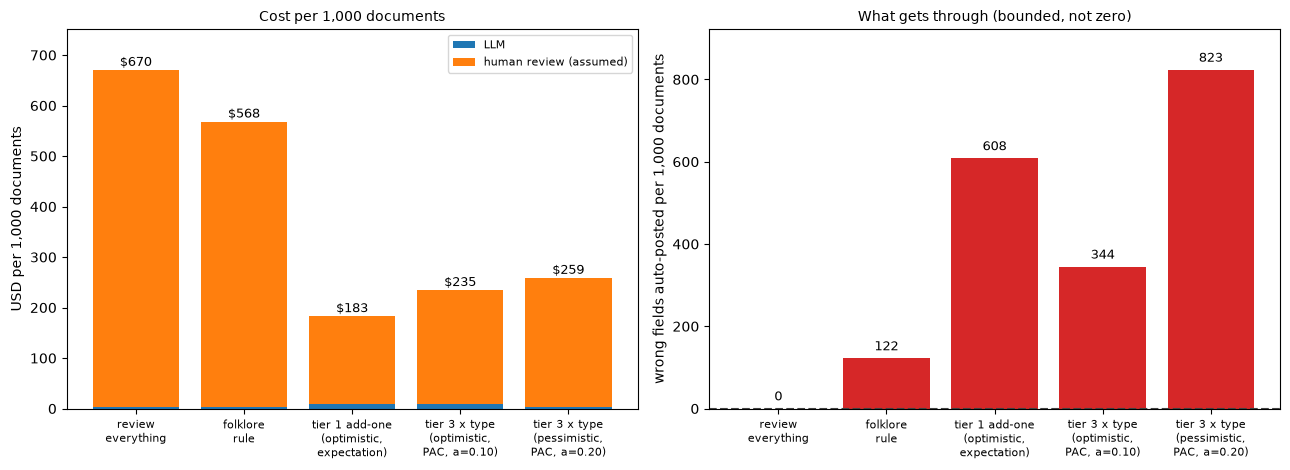

In [60]:
PAL3.update({"b8_llm": "#1f77b4", "b8_rev": "#ff7f0e", "b8_wrong": "#d62728"})
_fig, _axes = plt.subplots(1, 2, figsize=(13, 4.8))
_lab = ["review\neverything", "folklore\nrule", "tier 1 add-one\n(optimistic,\nexpectation)", "tier 3 x type\n(optimistic,\nPAC, a=0.10)", "tier 3 x type\n(pessimistic,\nPAC, a=0.20)"]; _x = np.arange(len(_pol))
_axes[0].bar(_x, [p["llm"] for p in _pol], color=PAL3["b8_llm"], label="LLM")
_axes[0].bar(_x, [p["review"] for p in _pol], bottom=[p["llm"] for p in _pol], color=PAL3["b8_rev"], label="human review (assumed)")
for _i, _p in enumerate(_pol):
    _axes[0].text(_i, _p["total"] + 8, f"${_p['total']:.0f}", ha="center", fontsize=9)
_axes[0].set_ylim(0, max(p["total"] for p in _pol) * 1.12); _axes[0].set_xticks(_x); _axes[0].set_xticklabels(_lab, fontsize=8); _axes[0].set_ylabel("USD per 1,000 documents"); _axes[0].legend(fontsize=8)
_axes[0].set_title("Cost per 1,000 documents", fontsize=10)
_axes[1].bar(_x, [p["wrong"] for p in _pol], color=PAL3["b8_wrong"])
for _i, _p in enumerate(_pol):
    _axes[1].text(_i, _p["wrong"] + 20, f"{_p['wrong']:.0f}", ha="center", fontsize=9)
_axes[1].axhline(0, ls="--", color=PAL3["diag"]); _axes[1].set_ylim(0, max(p["wrong"] for p in _pol) * 1.12); _axes[1].set_xticks(_x); _axes[1].set_xticklabels(_lab, fontsize=8)
_axes[1].set_ylabel("wrong fields auto-posted per 1,000 documents"); _axes[1].set_title("What gets through (bounded, not zero)", fontsize=10)
plt.tight_layout(); plt.show()


## 11. Recap, gaps the papers leave open, and limitations and open engineering choices

**What this notebook did (all on the synthetic Notebook-2 corpus).** Reloaded Notebook 2's pipeline from its `core` cells (zero live
LLM calls), defined a document-level outcome and a bounded amount-weighted loss (**derived here**), fit every score model on `train`
documents only, and then applied the three papers -- including, in sections 7b-9, machinery aimed straight at the "Frozen threshold
after a month-7 vendor shift" and several other "not met" checkpoints this portfolio's own README used to list:

| step | paper | guarantee form | unit |
| --- | --- | --- | --- |
| folklore/add-one rule audited under document-level resplits | P3 sections 4-5.1 | expectation (tiers 1-2) | field |
| cfBH auto-post rule | P1 | expectation (FDR) | document (derived here) |
| SCoRE MDR / SDR with an amount-weighted loss | P2 | expectation | document (derived here) |
| Mondrian LTT ladder per document type | P3 section 5.2 | PAC (tiers 3-4) | field / document |
| frozen-configuration check on the month-7 shift batch | P3 section 6.4 (analogue) | none promised under shift | field |
| **7b(i): known-weight covariate-shift repair** (weighted MDR/SDR, e-BH boosting, WCS/WBH) | P2 section 6, Jin & Candes 2023a | **finite-sample**, under Q | document (derived here) |
| **7b(ii): estimated-weight repair on the real shift batch** (3 covariate sets, A.3/A.5 balancing) | P2 Thm 6.4/6.5, Remark 6.6/App. A.4-A.5 | **asymptotic** (or doubly-robust asymptotic) | document (derived here) |
| **7b(iii): covariate- vs concept-shift diagnostic** | none (fully derived here) | diagnostic, not a guarantee | document |
| **8a-8b: SDR e-value boosting, risk/reward score** | P2 Thm 5.5, 4.6(iii)/5.8(iii) | expectation (SDR/MDR) | document |
| **8c: tier-4 power variants** (hoeffding / binomial_any_error / bernstein) | Gurram's open problem + derived-here variants | PAC | document |
| **8d-8e: pure-weak regime-2 test, grouped-taxonomy "lucky-zero"** | P3 section 7, section 5.3 | expectation/PAC | field |
| **9: label-noise simulation + audit-style check** | Gurram section 6.4 (pessimistic quote) + derived-here optimistic arm | diagnostic | field |

**What changed vs. the README's old verdict.** "Frozen threshold after a month-7 vendor shift: no -- violates every configuration" is
now more precise, not reversed: Section 7b shows the shift CAN be repaired **without new labels** if it is (or is well-approximated by)
covariate shift with **known** weights (7b(i), finite-sample, exact by construction on a semi-synthetic check) or **estimated** weights
of a well-behaved covariate set (7b(ii), asymptotic only, and covariate set C's template flag shows the estimator can degenerate).
Section 7b(iii)'s diagnostic finds a real `P(Y|X)` (concept-shift) component in the actual month-7 batch, which **no** weighting scheme
repairs -- so the honest updated verdict is: *"repairable in part, without new labels, if the shift is covariate-only and the weights are
well estimated; the real month-7 batch has a concept-shift component that only new labels (Section 7's recalibration) fixes."*

**Gaps the sources leave open** (each flagged in the NotebookLM traces; nothing below is filled in by us):

- **Refitting a score on calibration data.** None of the three sources gives a way to re-fit the score on the calibration data itself
  while keeping finite-sample validity; every one relies on a separate training set or a fit/val split (`idpfin-q12`).
- **Concept drift, even after Section 7b.** SCoRE's weighted e-values repair only **covariate** shift (`dQ/dP(x,y)=w(x)`); Section
  7b(iii)'s own diagnostic found the real month-7 batch is not purely covariate shift, and "none of the three sources state how to
  perform real-time, online re-calibration or re-certification under unobserved concept drift" without new labeled data (`idpfin-q12`).
  No source gives a **weighted or shift-robust cfBH or Mondrian LTT** either -- SCoRE is "the ONLY source ... that formulates weighted
  risk-adjusted e-values for covariate shift" (`idpfin-q18`); Section 7b's document-level WCS/WBH is as far as that machinery reaches.
- **No pre-deployment covariate-shift diagnostic in any source.** `idpfin-q18`/`idpshift-q4` flag this explicitly; Section 7b(iii)'s
  reliability-gap and `is_shift`-coefficient checks are **derived here**, not a validated general-purpose test.
- **Weight positivity failures are undiagnosed by the papers.** None discusses what to do when an estimated weight is (numerically)
  infinite because a covariate has zero support in one arm (`idpshift-q4`); Section 7b(ii)'s covariate set C hit exactly this and the
  fix here (excluding the offending covariate) is a judgment call, not a citable method.
- **Noisy calibration labels: diagnosed, not corrected.** Gurram found automatic labels err one-sidedly pessimistic against blind human
  review ("a certificate against noisy labels is a certificate about those labels", `idpfin-q9`, `idpfin-q16`); Section 9 reproduces the
  pessimistic case (conservative, as the paper predicts) and simulates the **optimistic** case the paper never studies (real violation,
  worse as the noise share grows) -- but no source, and nothing built here, gives a way to **correct** a threshold fit on noisy labels
  back toward the true target; a 150-field audit is shown to resolve only gross violations, not a margin of a few points.
- **Powered document-level PAC is still an open problem, not solved here.** Gurram names it explicitly; Section 8c's bernstein and
  binomial_any_error variants are **derived-here** alternatives to the paper's Hoeffding bound, and they help somewhat (Section 8c) but
  remain "honest but near-vacuous" at this calibration size -- they are candidate directions, not the paper's missing answer.
- **Minimum calibration size.** None gives a closed-form minimum number of calibration units for a non-empty certificate (`idpfin-q12`).
- **Documents and money.** cfBH and SCoRE never mention document extraction (`idpfin-q11`). cfBH names non-uniform error costs as an
  open problem (`idpfin-q3`), addressed partially here by Section 8b's risk-reward score (derived here, not in the papers as a document
  extraction concept). SCoRE lists data-driven score choice and the online setting as open (`idpfin-q6`).

**Engineering choices left open:** This is a starting point, not a finished system. In rough priority order:

1. **Real documents and real labels.** Replace the synthetic corpus with a real sample (CORD, FUNSD and XFUND are what Gurram used; the
   client's own redacted documents are better) and real human labels. This is the single most valuable step: it would show real label
   noise and real error correlation, and it may shrink the coverage numbers here, which come from simulated signals that Notebook 2
   found more informative than a real extractor's.
2. **A real extractor at scale, with a cost policy.** Only a 40-document DeepSeek smoke test exists. Decide the retry / escalation
   policy for truncated or failed calls, batching, caching by template, routing easy fields away from the LLM, and a spend cap.
3. **OCR and layout.** Notebook 2's "OCR text layer" is a stand-in. A real pipeline needs a layout-aware model or vendor OCR with
   page/bounding-box grounding, and a real NLI entailment signal (the fifth signal in Gurram's list, not computed here).
4. **The unit of certification and the score.** Decide whether the business promise is per field (tiers 1-3), per document (tier 4,
   cfBH and SCoRE at the document unit) or per dollar (SCoRE with an amount-weighted loss, or Section 8b's risk-reward-ratio score if
   auto-posted *value* matters more than auto-posted *count*), and set alpha, q and delta with the client. MDR and SDR answer different
   questions.
5. **Calibration data supply.** Decide how many labeled documents you can afford, who labels them (the human review queue is the
   natural source), and how the review feedback loop refreshes calibration without contaminating the score-training data.
6. **Shift handling, now with a real (partial) option.** Section 7b gives a label-free repair for covariate shift IF you can estimate
   `w(x)` on well-behaved covariates -- decide which covariates to track, monitor their Kish effective sample size in production as an
   early-warning signal (a collapsing ESS, as in Section 7b(ii)'s covariate set C, is a symptom of a positivity failure before it becomes
   an outage), and budget for labelled recalibration (Section 7's `B_BUDGET`) for the concept-shift component that weighting cannot fix.
7. **The REST API and the integration guide** (a stated deliverable): nothing here exposes an endpoint. The threshold JSON in section 10
   is a starting point for the config object.
8. **A human-in-the-loop review UI**, queueing and reviewer disagreement handling for the "review" branch.
9. **Audit logging and compliance.** Record, per decision, the model and score versions, the calibration set id, alpha/delta, the
   threshold, and the seed, to support a SOC 2-style audit trail. No compliance work was done here.
10. **Optional extensions from the job posting:** vector search / RAG for document retrieval; KYC/AML-specific rules.

**Using this for the proposal (your words, your experience).** The posting asks for past projects, an approach to low-confidence
extractions, and a timeline. The honest framing of this project is: a research-grounded prototype on synthetic data, with the
approach *"score each field, certify a threshold on held-out documents at the unit the business cares about, route everything else to
review, weight for detected covariate shift where the weights are well-behaved, and recalibrate on new labels for whatever weighting
cannot fix"*. It is not a claim of production experience; describe only what you have actually built or extend it before claiming more.


In [61]:
_ledger_usd = ledger_cost_usd(USAGE_LEDGER)
print(f"Notebook 2's DeepSeek smoke test, priced from its usage ledger (peak pricing): ${_ledger_usd:.4f} for {len(USAGE_LEDGER)} recorded requests")
print(f"Live API calls made by THIS notebook run: {LLM_STATS['live_calls']} (everything served from the disk cache)")
check("S11.1 Notebook 3 made zero live LLM calls", LLM_STATS["live_calls"] == 0, f"live_calls={LLM_STATS['live_calls']}")


Notebook 2's DeepSeek smoke test, priced from its usage ledger (peak pricing): $0.3665 for 139 recorded requests
Live API calls made by THIS notebook run: 0 (everything served from the disk cache)
[PASS] S11.1 Notebook 3 made zero live LLM calls -- live_calls=0


True